# Domainübersicht

In [3]:
import pandas as pd

# TSV einlesen (so ähnlich machst du es ja schon)
df = pd.read_csv(
    "own_datasets/train_binary_labels_balanced.csv",
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# 1) Alle Subjects in einzelne Domains aufsplitten
domains_series = (
    df["subjects"]
    .dropna()                     # NaNs raus
    .astype(str)                  # zur Sicherheit als String
    .str.split(",")               # in Listen splitten
    .explode()                    # jede Domain in eigene Zeile
    .str.strip()                  # Whitespace trimmen
)

# 2) Einzigartige Domains (alphabetisch sortiert)
unique_domains = sorted(domains_series.unique())
print("Einzigartige Domains:")
for d in unique_domains:
    print("-", d)

# 3) Häufigkeiten pro einzelner Domain
domain_counts = domains_series.value_counts().sort_index()
print("\nHäufigkeiten pro Domain:")
print(domain_counts)


Einzigartige Domains:
- 10-news-tampa-bay
- Alcohol
- abc-news-week
- abortion
- afghanistan
- after-the-fact
- agriculture
- animals
- autism
- bankruptcy
- baseball
- bipartisanship
- bush-administration
- campaign-advertising
- campaign-finance
- candidates-biography
- cap-and-trade
- census
- children
- china
- city-budget
- city-government
- civil-rights
- climate-change
- colbert-report
- congress
- congressional-rules
- consumer-safety
- corporations
- corrections-and-updates
- county-budget
- county-government
- crime
- criminal-justice
- death-penalty
- debates
- debt
- deficit
- disability
- diversity
- drugs
- ebola
- economy
- education
- elections
- energy
- environment
- ethics
- fake-news
- families
- federal-budget
- financial-regulation
- florida
- florida-amendments
- food
- food-safety
- foreign-policy
- gambling
- gas-prices
- gays-and-lesbians
- government-efficiency
- government-regulation
- guns
- health-care
- history
- homeland-security
- homeless
- housing
- h

# Unterteilung in 8 Kategorien

In [9]:
domain_to_super_8 = {
    # ----- 1. economy -----
    "Alcohol": "economy",
    "agriculture": "economy",
    "bankruptcy": "economy",
    "corporations": "economy",
    "consumer-safety": "economy",
    "debt": "economy",
    "deficit": "economy",
    "economy": "economy",
    "financial-regulation": "economy",
    "gas-prices": "economy",
    "gambling": "economy",
    "housing": "economy",
    "income": "economy",
    "infrastructure": "economy",
    "job-accomplishments": "economy",
    "jobs": "economy",
    "labor": "economy",
    "market-regulation": "economy",
    "medicaid": "economy",
    "pensions": "economy",
    "poverty": "economy",
    "retirement": "economy",
    "small-business": "economy",
    "social-security": "economy",
    "stimulus": "economy",
    "taxes": "economy",
    "tourism": "economy",
    "trade": "economy",
    "unions": "economy",
    "wealth": "economy",
    "workers": "economy",
    "food": "economy",

    # ----- 2. health_social -----
    "health-care": "health_social",
    "medicare": "health_social",
    "public-health": "health_social",
    "food-safety": "health_social",
    "drugs": "health_social",
    "marijuana": "health_social",
    "ebola": "health_social",
    "hunger": "health_social",
    "disability": "health_social",
    "women": "health_social",
    "families": "health_social",
    "sexuality": "health_social",
    "veterans": "health_social",
    "children": "health_social",
    "autism": "health_social",
    "homeless": "health_social",

    # ----- 3. foreign_security -----
    "afghanistan": "foreign_security",
    "foreign-policy": "foreign_security",
    "iraq": "foreign_security",
    "israel": "foreign_security",
    "china": "foreign_security",
    "military": "foreign_security",
    "homeland-security": "foreign_security",
    "terrorism": "foreign_security",
    "nuclear": "foreign_security",
    "patriotism": "foreign_security",
    "natural-disasters": "foreign_security",
    "public-safety": "foreign_security",

    # ----- 4. law_rights -----
    "abortion": "law_rights",
    "civil-rights": "law_rights",
    "crime": "law_rights",
    "criminal-justice": "law_rights",
    "guns": "law_rights",
    "legal-issues": "law_rights",
    "privacy": "law_rights",
    "human-rights": "law_rights",
    "supreme-court": "law_rights",
    "kagan-nomination": "law_rights",
    "sotomayor-nomination": "law_rights",
    "islam": "law_rights",
    "immigration": "law_rights",

    # ----- 5. politics_government -----
    "bipartisanship": "politics_government",
    "bush-administration": "politics_government",
    "campaign-advertising": "politics_government",
    "campaign-finance": "politics_government",
    "candidates-biography": "politics_government",
    "congress": "politics_government",
    "congressional-rules": "politics_government",
    "corrections-and-updates": "politics_government",
    "county-government": "politics_government",
    "county-budget": "politics_government",
    "city-government": "politics_government",
    "city-budget": "politics_government",
    "debates": "politics_government",
    "elections": "politics_government",
    "ethics": "politics_government",
    "fake-news": "politics_government",
    "government-efficiency": "politics_government",
    "government-regulation": "politics_government",
    "message-machine": "politics_government",
    "message-machine-2012": "politics_government",
    "message-machine-2014": "politics_government",
    "new-hampshire-2012": "politics_government",
    "occupy-wall-street": "politics_government",
    "politifacts-top-promises": "politics_government",
    "polls": "politics_government",
    "public-service": "politics_government",
    "redistricting": "politics_government",
    "transparency": "politics_government",
    "states": "politics_government",
    "state-budget": "politics_government",
    "state-finances": "politics_government",
    "voting-record": "politics_government",

    # ----- 6. environment_energy -----
    "cap-and-trade": "environment_energy",
    "climate-change": "environment_energy",
    "environment": "environment_energy",
    "energy": "environment_energy",
    "oil-spill": "environment_energy",
    "water": "environment_energy",
    "weather": "environment_energy",
    "transportation": "environment_energy",
    "urban": "environment_energy",
    "recreation": "environment_energy",

    # ----- 7. society_culture -----
    "education": "society_culture",
    "gays-and-lesbians": "society_culture",
    "diversity": "society_culture",
    "religion": "society_culture",
    "marriage": "society_culture",
    "population": "society_culture",
    "pop-culture": "society_culture",
    "sports": "society_culture",
    "nightlife": "society_culture",
    "history": "society_culture",

    # ----- 8. misc -----
    "abc-news-week": "misc",
    "pundits": "misc",
    "obama-birth-certificate": "misc",
    "space": "misc",
    "technology": "misc",
    "10-news-tampa-bay": "misc",
    "after-the-fact": "misc",
    "lottery": "misc",
}

## Domainmodel trainieren - Model bekommt Subjects

In [1]:
# =========================
# 0. Environment & Imports
# =========================
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")
# Für Debugging bei seltsamen CUDA-Fehlern:
# os.environ.setdefault("CUDA_LAUNCH_BLOCKING", "1")

import logging
import torch
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
)

from peft import LoraConfig, get_peft_model, TaskType

logging.basicConfig(level=logging.INFO)

# =======================================
# 1. Superlabels & domain_to_super mapping
# =======================================

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]



def map_subjects_to_super(subjects_str: str) -> str:
    """
    Map LIAR 'subjects' (comma-separated topics) to exactly one super label.
    """
    if not isinstance(subjects_str, str) or not subjects_str.strip():
        return "misc"

    domains = [s.strip() for s in subjects_str.split(",") if s.strip()]
    super_labels = {domain_to_super.get(d, "misc") for d in domains}

    for label in SUPER_LABELS:
        if label in super_labels:
            return label
    return "misc"


# ==============================
# 2. Load LIAR TSV and prepare DF
# ==============================

liar_path = "own_datasets/train_binary_labels_balanced.csv"   # <-- Pfad ggf. anpassen

df = pd.read_csv(
    liar_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

df["super_domain"] = df["subjects"].apply(map_subjects_to_super)

print("Super label distribution:")
print(df["super_domain"].value_counts())


# =======================================
# 3. Build Dataset & chat-based prompt fn
# =======================================

SYSTEM_PROMPT = """You are a label mapping assistant.

You receive fine-grained topic labels from the LIAR dataset and must map them
to exactly ONE high-level domain label.

You must answer with exactly one label from this list:

- economy
- health_social
- foreign_security
- law_rights
- politics_government
- environment_energy
- society_culture
- media_meta
- misc

Return ONLY the label string, without explanations or extra text.
"""


def build_chat_example(example):
    user_content = (
        f"Original LIAR topics: {example['subjects']}\n\n"
        "What is the best high-level domain label for these topics?"
    )
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": example["super_domain"]},
    ]
    return messages


# ============================
# 4. Tokenizer & tokenization
# ============================

base_model_id = "meta-llama/Llama-3.1-8B-Instruct"  # <-- dein Llama-Modell

tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

dataset = Dataset.from_pandas(df[["subjects", "super_domain"]])
dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_ds = dataset["train"]
val_ds = dataset["test"]


def tokenize_example(example):
    messages = build_chat_example(example)
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    return tokenizer(
        text,
        max_length=256,
        truncation=True,
    )


train_tokenized = train_ds.map(
    tokenize_example,
    batched=False,
    remove_columns=train_ds.column_names,
)
val_tokenized = val_ds.map(
    tokenize_example,
    batched=False,
    remove_columns=val_ds.column_names,
)

print("Example tokenized sample:", train_tokenized[0].keys())


# ============================
# 5. Base Model + LoRA-Adapter
# ============================

# Base-Modell in FP16, Sharding automatisch
model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

# LoRA-Konfig (typische Einstellungen für LLaMA)
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)


# ============================
# 6. TrainingArguments & Trainer
# ============================

training_args = TrainingArguments(
    output_dir="./Multi_Agent_Results/llama-liar-domain-mapper-lora",
    per_device_train_batch_size=4,   # LoRA + FP16 ⇒ 4 sollte gut passen
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    learning_rate=5e-4,              # LoRA kann etwas höhere LR ab
    weight_decay=0.01,
    logging_steps=20,
    save_steps=500,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),  # FP16 für Training
    no_cuda=not torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
)

trainer.train()

# ============================
# 7. Save LoRA-Adapter & tokenizer
# ============================

save_dir = "./Multi_Agent_Models/llama-liar-domain-mapper-lora"
os.makedirs(save_dir, exist_ok=True)
trainer.model.save_pretrained(save_dir)   # speichert NUR die LoRA-Adapter
tokenizer.save_pretrained(save_dir)

print(f"LoRA adapter & tokenizer saved to: {save_dir}")


# ============================
# 8. Inference helper (mit LoRA)
# ============================

# Für Inference musst du wieder Base + LoRA laden:
def load_lora_model(base_id: str, lora_dir: str):
    from peft import PeftModel
    base = AutoModelForCausalLM.from_pretrained(
        base_id,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
    )
    peft_model = PeftModel.from_pretrained(base, lora_dir)
    peft_model.eval()
    return peft_model

E0000 00:00:1763189137.366999  182283 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763189137.373658  182283 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763189137.391775  182283 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763189137.391793  182283 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763189137.391795  182283 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763189137.391797  182283 computation_placer.cc:177] computation placer already registered. Please check linka

Super label distribution:
super_domain
economy                3302
politics_government    1502
health_social          1252
law_rights             1110
foreign_security        872
society_culture         402
environment_energy      359
misc                    177
Name: count, dtype: int64


Map:   0%|          | 0/8078 [00:00<?, ? examples/s]

Map:   0%|          | 0/898 [00:00<?, ? examples/s]

Example tokenized sample: dict_keys(['input_ids', 'attention_mask'])


INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

trainable params: 20,971,520 || all params: 8,051,232,768 || trainable%: 0.2605


Step,Training Loss
20,0.709100
40,0.101000
60,0.083600
80,0.087800
100,0.081900
120,0.084500
140,0.085500
160,0.076600
180,0.081900
200,0.080100


LoRA adapter & tokenizer saved to: ./Multi_Agent_Models/llama-liar-domain-mapper-lora


### test

In [3]:
# ========= 0) Imports & Environment =========
import os
import torch
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from tqdm import tqdm


os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")

# ========= 1) Superlabels, Mapping & Helfer =========

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]


def map_subjects_to_super(subjects_str: str) -> str:
    """
    Map LIAR 'subjects' (comma-separated topics) to exactly one super label.
    """
    if not isinstance(subjects_str, str) or not subjects_str.strip():
        return "misc"

    domains = [s.strip() for s in subjects_str.split(",") if s.strip()]
    super_labels = {domain_to_super.get(d, "misc") for d in domains}

    for label in SUPER_LABELS:
        if label in super_labels:
            return label
    return "misc"

# ========= 2) Tokenizer & Modell + LoRA laden =========

base_model_id = "meta-llama/Llama-3.1-8B-Instruct"   # dein Basis-LLaMA
lora_dir = "./Multi_Agent_Models/llama-liar-domain-mapper-lora"  # dein LoRA-Ordner

tokenizer = AutoTokenizer.from_pretrained(lora_dir, use_fast=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

model = PeftModel.from_pretrained(base_model, lora_dir)
model.eval()
if torch.cuda.is_available():
    model = model.to("cuda")

# ========= 3) Inference-Funktion =========

def map_labels_with_llama(subjects_str: str) -> str:
    label_list = ", ".join(SUPER_LABELS)

    user_content = (
        "You are a strict domain classifier.\n\n"
        f"Valid labels:\n{label_list}\n\n"
        f"Given these LIAR topics:\n{subjects_str}\n\n"
        "Return ONLY ONE label from the list above.\n"
        "Respond ONLY with the label.\n\n"
        "Label:"
    )

    messages = [
        {"role": "system", "content": "You classify topics into fixed super labels."},
        {"role": "user", "content": user_content},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
    )

    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        gen_out = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            pad_token_id=tokenizer.pad_token_id,
            max_new_tokens=8,
            do_sample=False,
        )

    generated_ids = gen_out[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    answer_lower = answer.lower()

    if not answer_lower:
        return "misc"

    # 1) exaktes Wort-Matching mit Wortgrenzen
    import re
    for L in SUPER_LABELS:
        pattern = r"\b" + re.escape(L.lower()) + r"\b"
        if re.search(pattern, answer_lower):
            return L

    # 2) Fallback: erste Übereinstimmung als Substring
    for L in SUPER_LABELS:
        if L.lower() in answer_lower:
            return L

    # 3) Gar nichts gefunden -> misc
    return "misc"


# ========= 4) Kurzer Sanity-Test =========

test_subjects = "health-care,medicare,public-health"
print("Sanity test:", test_subjects, "->", map_labels_with_llama(test_subjects))

# ========= 5) Testdaten laden & evaluieren =========

test_path = "own_datasets/test_binary_labels.csv"  # Pfad anpassen

df_test = pd.read_csv(
    test_path,
    sep="\t",            # falls es wirklich TSV ist; sonst ',' für klassisches CSV
    quotechar='"',
    engine="python",
    dtype=str,
)

print("Testset size:", len(df_test))

# True-Superlabels aus 'subjects'
df_test["super_domain_true"] = df_test["subjects"].apply(map_subjects_to_super)
print("True label distribution (test):")
print(df_test["super_domain_true"].value_counts())

# Vorhersagen
preds = []
bar = tqdm(
    df_test.itertuples(),
    total=len(df_test),
    desc="🧠 Classifying test samples",
    dynamic_ncols=True,
    smoothing=0.1,
    mininterval=0.1,
)

for row in bar:
    subjects = getattr(row, "subjects")
    pred_label = map_labels_with_llama(subjects)
    preds.append(pred_label)



df_test["super_domain_pred"] = preds

print("Predicted label distribution (test):")
print(df_test["super_domain_pred"].value_counts())

# Metriken
y_true = df_test["super_domain_true"]
y_pred = df_test["super_domain_pred"]

acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy (super_domain) on test set: {acc:.3f}\n")

print("Classification report (per superlabel):")
print(classification_report(y_true, y_pred, labels=SUPER_LABELS, zero_division=0))

print("Confusion matrix (rows = true, cols = pred):")
cm = confusion_matrix(y_true, y_pred, labels=SUPER_LABELS)
print("Labels order:", SUPER_LABELS)
print(cm)



Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Sanity test: health-care,medicare,public-health -> health_social
Testset size: 1267
True label distribution (test):
super_domain_true
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64


🧠 Classifying test samples: 100%|██████████| 1267/1267 [09:52<00:00,  2.14it/s]

Predicted label distribution (test):
super_domain_pred
economy                776
health_social          142
law_rights             108
misc                   105
foreign_security        86
environment_energy      27
politics_government     18
society_culture          5
Name: count, dtype: int64

Accuracy (super_domain) on test set: 0.696

Classification report (per superlabel):
                     precision    recall  f1-score   support

            economy       0.61      1.00      0.76       473
      health_social       1.00      0.99      1.00       143
   foreign_security       1.00      0.70      0.83       122
         law_rights       1.00      0.74      0.85       145
politics_government       1.00      0.08      0.14       233
 environment_energy       1.00      0.48      0.65        56
    society_culture       1.00      0.08      0.15        61
               misc       0.22      0.68      0.33        34

           accuracy                           0.70      1267
      

In [4]:
# ========= 0) Imports & Environment =========
import os
import torch
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from tqdm import tqdm
import re

os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")

# ========= 1) Superlabels, Mapping & Helfer =========

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

# ausführlicher Systemprompt mit Klassendefinitionen
SYSTEM_PROMPT = """You are a strict domain classifier.

You receive fine-grained LIAR topics and must map them
to exactly ONE high-level domain label from this list:

- economy: money, jobs, taxes, trade, business, budget, social security, pensions, stimulus
- health_social: healthcare, medicare, medicaid, public health, drugs, families, women, children, veterans, hunger, disability
- foreign_security: foreign policy, wars, military, terrorism, homeland security, nuclear weapons, international relations
- law_rights: crime, courts, civil rights, guns, immigration, legal issues, human rights, abortion, constitutional questions
- politics_government: elections, campaigns, candidates, parties, congress, political promises, redistricting, government rules and procedures
- environment_energy: climate, environment, energy, oil, gas, water, weather, transportation, pollution, natural resources
- society_culture: education, religion, diversity, LGBT, marriage, sports, pop culture, social norms, demographics
- misc: everything that does not clearly fit any of the above

You MUST answer with EXACTLY ONE label string from this list.
Do NOT explain. Only output the label.
"""

def map_subjects_to_super(subjects_str: str) -> str:
    """
    Map LIAR 'subjects' (comma-separated topics) to exactly one super label.
    """
    if not isinstance(subjects_str, str) or not subjects_str.strip():
        return "misc"

    # domain_to_super MUSS vorher definiert sein (z.B. in einer anderen Zelle)
    domains = [s.strip() for s in subjects_str.split(",") if s.strip()]
    super_labels = {domain_to_super.get(d, "misc") for d in domains}

    for label in SUPER_LABELS:
        if label in super_labels:
            return label
    return "misc"

# ========= 2) Tokenizer & Modell + LoRA laden =========

base_model_id = "meta-llama/Llama-3.1-8B-Instruct"   # dein Basis-LLaMA
lora_dir = "./Multi_Agent_Models/llama-liar-domain-mapper-lora"  # dein LoRA-Ordner

tokenizer = AutoTokenizer.from_pretrained(lora_dir, use_fast=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

model = PeftModel.from_pretrained(base_model, lora_dir)
model.eval()
if torch.cuda.is_available():
    model = model.to("cuda")

# ========= 3) Inference-Funktion =========

def map_labels_with_llama(subjects_str: str) -> str:
    """
    Nutzt das LoRA-Modell + Klassendefinitionen, um aus LIAR-Subjects ein Superlabel zu erzeugen.
    """
    label_list = ", ".join(SUPER_LABELS)

    user_content = (
        f"Valid labels:\n{label_list}\n\n"
        f"Given these LIAR topics:\n{subjects_str}\n\n"
        "Return ONLY ONE label from the list above.\n"
        "Respond ONLY with the label.\n\n"
        "Label:"
    )

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
    )

    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        gen_out = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            pad_token_id=tokenizer.pad_token_id,
            max_new_tokens=8,
            do_sample=False,
        )

    # Nur die neu generierten Tokens
    generated_ids = gen_out[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    answer_lower = answer.lower()

    if not answer_lower:
        return "misc"

    # 1) exaktes Wort-Matching mit Wortgrenzen
    for L in SUPER_LABELS:
        pattern = r"\b" + re.escape(L.lower()) + r"\b"
        if re.search(pattern, answer_lower):
            return L

    # 2) Fallback: erste Übereinstimmung als Substring
    for L in SUPER_LABELS:
        if L.lower() in answer_lower:
            return L

    # 3) Gar nichts gefunden -> misc
    return "misc"


def postprocess_label(subjects_str: str, raw_label: str) -> str:
    """
    Kleine Heuristik speziell für politics_government & society_culture,
    um typische Verwechslungen mit economy/misc etwas zu korrigieren,
    ohne neu zu trainieren.
    """
    subs = subjects_str.lower()

    # economy, aber Topics klar politisch: -> politics_government
    if raw_label == "economy":
        if any(k in subs for k in [
            "elections", "election", "campaign", "congress", "voting-record",
            "redistricting", "polls", "message-machine", "candidates-biography"
        ]):
            return "politics_government"

    # misc, aber klassische "society_culture"-Topics
    if raw_label == "misc":
        if any(k in subs for k in [
            "education", "religion", "gays-and-lesbians", "marriage",
            "sports", "pop-culture", "diversity"
        ]):
            return "society_culture"

    return raw_label

# ========= 4) Kurzer Sanity-Test =========

test_subjects = "health-care,medicare,public-health"
print("Sanity test:", test_subjects, "->", map_labels_with_llama(test_subjects))

# ========= 5) Testdaten laden & evaluieren =========

test_path = "own_datasets/test_binary_labels.csv"  # Pfad anpassen

df_test = pd.read_csv(
    test_path,
    sep="\t",            # falls es wirklich TSV ist; sonst ',' für klassisches CSV
    quotechar='"',
    engine="python",
    dtype=str,
)

print("Testset size:", len(df_test))

# True-Superlabels aus 'subjects'
df_test["super_domain_true"] = df_test["subjects"].apply(map_subjects_to_super)
print("True label distribution (test):")
print(df_test["super_domain_true"].value_counts())

# Vorhersagen
preds = []
bar = tqdm(
    df_test.itertuples(),
    total=len(df_test),
    desc="🧠 Classifying test samples",
    dynamic_ncols=True,
    smoothing=0.1,
    mininterval=0.1,
)

for row in bar:
    subjects = getattr(row, "subjects")
    raw_pred = map_labels_with_llama(subjects)
    pred_label = postprocess_label(subjects, raw_pred)
    preds.append(pred_label)

df_test["super_domain_pred"] = preds

print("Predicted label distribution (test):")
print(df_test["super_domain_pred"].value_counts())

# Metriken
y_true = df_test["super_domain_true"]
y_pred = df_test["super_domain_pred"]

acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy (super_domain) on test set: {acc:.3f}\n")

print("Classification report (per superlabel):")
print(classification_report(y_true, y_pred, labels=SUPER_LABELS, zero_division=0))

print("Confusion matrix (rows = true, cols = pred):")
cm = confusion_matrix(y_true, y_pred, labels=SUPER_LABELS)
print("Labels order:", SUPER_LABELS)
print(cm)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Sanity test: health-care,medicare,public-health -> health_social
Testset size: 1267
True label distribution (test):
super_domain_true
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64


🧠 Classifying test samples: 100%|██████████| 1267/1267 [10:01<00:00,  2.11it/s]

Predicted label distribution (test):
super_domain_pred
economy                467
politics_government    293
health_social          141
law_rights             137
foreign_security       115
environment_energy      56
society_culture         53
misc                     5
Name: count, dtype: int64

Accuracy (super_domain) on test set: 0.857

Classification report (per superlabel):
                     precision    recall  f1-score   support

            economy       0.83      0.82      0.83       473
      health_social       1.00      0.99      0.99       143
   foreign_security       1.00      0.94      0.97       122
         law_rights       1.00      0.94      0.97       145
politics_government       0.68      0.85      0.75       233
 environment_energy       1.00      1.00      1.00        56
    society_culture       0.96      0.84      0.89        61
               misc       0.00      0.00      0.00        34

           accuracy                           0.86      1267
      

## Domainmodel traineren - Model bekommt Statement

In [5]:

from train_domain_expert_domain_config import DomainConfig
from train_domain_expert_domain_classifier import train_domain_classifier, evaluate_on_testset


domain_config = DomainConfig(
    domain_to_super=domain_to_super_8,
    # Falls du die Reihenfolge explizit festlegen willst:
    super_labels=[
        "economy",
        "health_social",
        "foreign_security",
        "law_rights",
        "politics_government",
        "environment_energy",
        "society_culture",
        "misc",
    ]
)

# ========= 2) Pfade & Modell-ID =========

base_model_id = "meta-llama/Llama-3.1-8B-Instruct"
train_path = "own_datasets/train_binary_labels_balanced.csv"
test_path = "own_datasets/test_binary_labels.csv"
output_dir = "./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes"

# ========= 3) Training starten =========

if __name__ == "__main__":
    # Train
    train_domain_classifier(
        train_path=train_path,
        domain_config=domain_config,
        base_model_id=base_model_id,
        output_dir=output_dir,
        num_train_epochs=3,
        learning_rate=5e-4,
        per_device_train_batch_size=4,
        max_length=256,
    )

    # Eval
    evaluate_on_testset(
        test_path=test_path,
        domain_config=domain_config,
        base_model_id=base_model_id,
        lora_dir=output_dir,
    )


Super label distribution (train):
super_domain
economy                3302
politics_government    1502
health_social          1252
law_rights             1110
foreign_security        872
society_culture         402
environment_energy      359
misc                    177
Name: count, dtype: int64


Map:   0%|          | 0/8976 [00:00<?, ? examples/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Example tokenized sample keys: dict_keys(['input_ids', 'attention_mask'])
Input length: 168


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

Step,Training Loss
50,0.616600
100,0.378900
150,0.386800
200,0.384200
250,0.381700
300,0.363200
350,0.383000
400,0.384200
450,0.376600
500,0.391800


LoRA adapter & tokenizer saved to: ./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes
Testset size: 1267
True label distribution (test):
super_domain_true
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
🧠 Classifying test samples (statements): 100%|██████████| 1267/1267 [10:41<00:00,  1.97it/s]

Predicted label distribution (test):
super_domain_pred
economy                425
politics_government    330
health_social          190
law_rights             116
foreign_security       111
society_culture         54
environment_energy      33
misc                     8
Name: count, dtype: int64

Accuracy (super_domain) on test set: 0.706

Classification report (per superlabel):
                     precision    recall  f1-score   support

            economy       0.83      0.75      0.79       473
      health_social       0.62      0.83      0.71       143
   foreign_security       0.84      0.76      0.80       122
         law_rights       0.78      0.62      0.69       145
politics_government       0.54      0.76      0.63       233
 environment_energy       0.76      0.45      0.56        56
    society_culture       0.57      0.51      0.54        61
               misc       0.75      0.18      0.29        34

           accuracy                           0.71      1267
      

In [5]:
# =========================
# 0. Environment & Imports
# =========================
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")
# Für Debugging bei seltsamen CUDA-Fehlern:
# os.environ.setdefault("CUDA_LAUNCH_BLOCKING", "1")

import logging
import torch
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
)

from peft import LoraConfig, get_peft_model, TaskType

logging.basicConfig(level=logging.INFO)

# =======================================
# 1. Superlabels & domain_to_super mapping
# =======================================

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]



def map_subjects_to_super(subjects_str: str) -> str:
    """
    Map LIAR 'subjects' (comma-separated topics) to exactly one super label.
    """
    if not isinstance(subjects_str, str) or not subjects_str.strip():
        return "misc"

    domains = [s.strip() for s in subjects_str.split(",") if s.strip()]
    super_labels = {domain_to_super.get(d, "misc") for d in domains}

    for label in SUPER_LABELS:
        if label in super_labels:
            return label
    return "misc"


# ==============================
# 2. Load LIAR data and prepare DF
# ==============================

liar_path = "own_datasets/train_binary_labels_balanced.csv"   # <-- Pfad ggf. anpassen

df = pd.read_csv(
    liar_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# super_domain aus subjects berechnen (Ground Truth für Training)
df["super_domain"] = df["subjects"].apply(map_subjects_to_super)

# Sicherstellen, dass statement und super_domain nicht leer sind
df = df.dropna(subset=["statement", "super_domain"])
df = df[df["statement"].str.strip() != ""]

print("Super label distribution (train):")
print(df["super_domain"].value_counts())


# =======================================
# 3. Build Dataset & chat-based prompt fn
# =======================================

SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a short political or public policy claim (a 'statement') and must map it
to exactly ONE high-level domain label from this list:

- economy
- health_social
- foreign_security
- law_rights
- politics_government
- environment_energy
- society_culture
- misc

You MUST answer with EXACTLY ONE of these labels.
Do NOT explain. Do NOT add any extra words. Only output the label.
"""


def build_chat_example(example):
    user_content = (
        f"Claim:\n{example['statement']}\n\n"
        "What is the best high-level domain label for this claim?"
    )
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": example["super_domain"]},
    ]
    return messages


# ============================
# 4. Tokenizer & tokenization
# ============================

base_model_id = "meta-llama/Llama-3.1-8B-Instruct"  # <-- dein Llama-Modell

tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Kein Train/Val-Split → alles als ein Trainings-Dataset
dataset = Dataset.from_pandas(df[["statement", "super_domain"]])


def tokenize_example(example):
    messages = build_chat_example(example)
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    return tokenizer(
        text,
        max_length=256,
        truncation=True,
    )


train_tokenized = dataset.map(
    tokenize_example,
    batched=False,
    remove_columns=dataset.column_names,
)

print("Example tokenized sample:", train_tokenized[0].keys())
print("Input length:", len(train_tokenized[0]["input_ids"]))


# ============================
# 5. Base Model + LoRA-Adapter
# ============================

model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

# LoRA-Konfig
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)


# ============================
# 6. TrainingArguments & Trainer
# ============================

training_args = TrainingArguments(
    output_dir="./Multi_Agent_Results/llama-liar-statement-domain-lora",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    learning_rate=5e-4,              # LoRA kann etwas höhere LR ab
    weight_decay=0.01,
    logging_steps=50,
    save_steps=500,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    no_cuda=not torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=None,          # kein Val
    data_collator=data_collator,
)

trainer.train()


# ============================
# 7. Save LoRA-Adapter & tokenizer
# ============================

save_dir = "./Multi_Agent_Models/llama-liar-statement-domain-lora"
os.makedirs(save_dir, exist_ok=True)
trainer.model.save_pretrained(save_dir)   # speichert NUR die LoRA-Adapter
tokenizer.save_pretrained(save_dir)

print(f"LoRA adapter & tokenizer saved to: {save_dir}")





Super label distribution (train):
super_domain
economy                3302
politics_government    1502
health_social          1252
law_rights             1110
foreign_security        872
society_culture         402
environment_energy      359
misc                    177
Name: count, dtype: int64


Map:   0%|          | 0/8976 [00:00<?, ? examples/s]

INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Example tokenized sample: dict_keys(['input_ids', 'attention_mask'])
Input length: 174


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

trainable params: 20,971,520 || all params: 8,051,232,768 || trainable%: 0.2605


Step,Training Loss
50,0.606100
100,0.365600
150,0.373500
200,0.370400
250,0.368300
300,0.349500
350,0.369700
400,0.370400
450,0.363900
500,0.377500


LoRA adapter & tokenizer saved to: ./Multi_Agent_Models/llama-liar-statement-domain-lora


In [6]:
# ============================
# 8. Inference helper (mit LoRA)
# ============================

from peft import PeftModel
import re

def load_lora_model(base_id: str, lora_dir: str):
    base = AutoModelForCausalLM.from_pretrained(
        base_id,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
    )
    peft_model = PeftModel.from_pretrained(base, lora_dir)
    peft_model.eval()
    if torch.cuda.is_available():
        peft_model = peft_model.to("cuda")
    return peft_model


def classify_statement_domain(statement: str, model_inf=None) -> str:
    """
    Nimmt ein Claim-Statement und gibt ein Superlabel zurück.
    """
    global model  # falls du im gleichen Kernel bist wie beim Training
    if model_inf is None:
        model_inf = model

    label_list = ", ".join(SUPER_LABELS)

    user_content = (
        f"Valid labels: {label_list}\n\n"
        f"Claim:\n{statement}\n\n"
        "Return ONLY ONE label from the list above.\n"
        "Respond ONLY with the label.\n\n"
        "Label:"
    )

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
    )

    if torch.cuda.is_available():
        inputs = {k: v.to(model_inf.device) for k, v in inputs.items()}

    with torch.no_grad():
        gen_out = model_inf.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            pad_token_id=tokenizer.pad_token_id,
            max_new_tokens=8,
            do_sample=False,
        )

    gen_ids = gen_out[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(gen_ids, skip_special_tokens=True).strip().lower()

    if not answer:
        return "misc"

    # robustes Label-Matching
    for L in SUPER_LABELS:
        pattern = r"\b" + re.escape(L.lower()) + r"\b"
        if re.search(pattern, answer):
            return L

    for L in SUPER_LABELS:
        if L.lower() in answer:
            return L

    return "misc"


# Kurzer Test (nach dem Training):
test_claim = "Building a wall on the U.S.-Mexico border will take literally years."
print("Claim:", test_claim)
print("Predicted super domain:", classify_statement_domain(test_claim))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Claim: Building a wall on the U.S.-Mexico border will take literally years.
Predicted super domain: law_rights


In [8]:
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ======================================
# 1) Testdaten laden
# ======================================

test_path = "own_datasets/test_binary_labels.csv"

df_test = pd.read_csv(
    test_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

print("Testset size:", len(df_test))

# ======================================
# 2) Ground-Truth aus SUBJECTS bauen
# ======================================

df_test["super_domain_true"] = df_test["subjects"].apply(map_subjects_to_super)

print("\nTrue label distribution:")
print(df_test["super_domain_true"].value_counts())

# ======================================
# 3) Vorhersagen mit Statement-LoRA-Modell (mit tqdm)
# ======================================

preds = []

bar = tqdm(
    df_test.itertuples(),
    total=len(df_test),
    desc="🧠 Classifying statements",
    dynamic_ncols=True,
    smoothing=0.1,
    mininterval=0.1
)

for row in bar:
    claim = getattr(row, "statement")
    pred_label = classify_statement_domain(claim)  # <-- deine LoRA-Inference-Funktion
    preds.append(pred_label)

df_test["super_domain_pred"] = preds

print("\nPredicted label distribution:")
print(df_test["super_domain_pred"].value_counts())

# ======================================
# 4) Metriken
# ======================================

y_true = df_test["super_domain_true"]
y_pred = df_test["super_domain_pred"]

acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {acc:.3f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, labels=SUPER_LABELS, zero_division=0))

print("\nConfusion Matrix (rows = true, cols = pred):")
cm = confusion_matrix(y_true, y_pred, labels=SUPER_LABELS)
print("Labels order:", SUPER_LABELS)
print(cm)


Testset size: 1267

True label distribution:
super_domain_true
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64


🧠 Classifying statements: 100%|██████████| 1267/1267 [08:18<00:00,  2.54it/s]


Predicted label distribution:
super_domain_pred
economy                412
politics_government    313
health_social          176
law_rights             143
foreign_security       105
society_culture         62
environment_energy      49
misc                     7
Name: count, dtype: int64

Accuracy: 0.720

Classification Report:
                     precision    recall  f1-score   support

            economy       0.85      0.74      0.80       473
      health_social       0.65      0.80      0.71       143
   foreign_security       0.85      0.73      0.78       122
         law_rights       0.74      0.73      0.74       145
politics_government       0.56      0.75      0.64       233
 environment_energy       0.69      0.61      0.65        56
    society_culture       0.63      0.64      0.63        61
               misc       0.43      0.09      0.15        34

           accuracy                           0.72      1267
          macro avg       0.68      0.64      0.64      

### Test

In [9]:
# ========= 0) Imports & Environment =========
import os
import torch
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from tqdm import tqdm
import re

os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")

# ========= 1) Superlabels, Mapping & Helfer =========

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

# ausführlicher Systemprompt mit Klassendefinitionen – jetzt für STATEMENTS
SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a short political or public policy claim (a 'statement') and must map it
to exactly ONE high-level domain label from this list:

- economy: money, jobs, taxes, trade, business, budget, social security, pensions, stimulus
- health_social: healthcare, medicare, medicaid, public health, drugs, families, women, children, veterans, hunger, disability
- foreign_security: foreign policy, wars, military, terrorism, homeland security, nuclear weapons, international relations
- law_rights: crime, courts, civil rights, guns, immigration, legal issues, human rights, abortion, constitutional questions
- politics_government: elections, campaigns, candidates, parties, congress, political promises, redistricting, government rules and procedures
- environment_energy: climate, environment, energy, oil, gas, water, weather, transportation, pollution, natural resources
- society_culture: education, religion, diversity, LGBT, marriage, sports, pop culture, social norms, demographics
- misc: everything that does not clearly fit any of the above

You MUST answer with EXACTLY ONE label string from this list.
Do NOT explain. Only output the label.
"""

def map_subjects_to_super(subjects_str: str) -> str:
    """
    Map LIAR 'subjects' (comma-separated topics) to exactly one super label.
    Ground Truth für Evaluation.
    """
    if not isinstance(subjects_str, str) or not subjects_str.strip():
        return "misc"

    # domain_to_super MUSS vorher definiert sein (z.B. in einer anderen Zelle)
    domains = [s.strip() for s in subjects_str.split(",") if s.strip()]
    super_labels = {domain_to_super.get(d, "misc") for d in domains}

    for label in SUPER_LABELS:
        if label in super_labels:
            return label
    return "misc"

# ========= 2) Tokenizer & Modell + LoRA laden =========

base_model_id = "meta-llama/Llama-3.1-8B-Instruct"   # dein Basis-LLaMA
lora_dir = "./Multi_Agent_Models/llama-liar-statement-domain-lora"  # <-- STATEMENT-LoRA

# Tokenizer vom LoRA-Ordner laden (dort hast du ihn beim Training gespeichert)
tokenizer = AutoTokenizer.from_pretrained(lora_dir, use_fast=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Basis-Modell
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

# LoRA-Adapter auf Basis-Modell laden
model = PeftModel.from_pretrained(base_model, lora_dir)
model.eval()
if torch.cuda.is_available():
    model = model.to("cuda")

# ========= 3) Inference-Funktion für STATEMENTS =========

def classify_statement_domain(statement: str) -> str:
    """
    Nutzt das LoRA-Modell + Klassendefinitionen, um aus einem Claim-Statement
    ein Superlabel zu erzeugen.
    """
    label_list = ", ".join(SUPER_LABELS)

    user_content = (
        f"Valid labels:\n{label_list}\n\n"
        f"Claim:\n{statement}\n\n"
        "Return ONLY ONE label from the list above.\n"
        "Respond ONLY with the label.\n\n"
        "Label:"
    )

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
    )

    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        gen_out = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            pad_token_id=tokenizer.pad_token_id,
            max_new_tokens=8,
            do_sample=False,
        )

    # Nur die neu generierten Tokens
    generated_ids = gen_out[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    answer_lower = answer.lower()

    if not answer_lower:
        return "misc"

    # 1) exaktes Wort-Matching mit Wortgrenzen
    for L in SUPER_LABELS:
        pattern = r"\b" + re.escape(L.lower()) + r"\b"
        if re.search(pattern, answer_lower):
            return L

    # 2) Fallback: erste Übereinstimmung als Substring
    for L in SUPER_LABELS:
        if L.lower() in answer_lower:
            return L

    # 3) Gar nichts gefunden -> misc
    return "misc"


def postprocess_label(subjects_str: str, raw_label: str) -> str:
    """
    Kleine Heuristik speziell für politics_government & society_culture,
    um typische Verwechslungen mit economy/misc etwas zu korrigieren,
    ohne neu zu trainieren.
    Nutzt weiterhin die SUBJECTS-Spalte, weil die thematisch sehr explizit ist.
    """
    subs = subjects_str.lower()

    # economy, aber Topics klar politisch: -> politics_government
    if raw_label == "economy":
        if any(k in subs for k in [
            "elections", "election", "campaign", "congress", "voting-record",
            "redistricting", "polls", "message-machine", "candidates-biography"
        ]):
            return "politics_government"

    # misc, aber klassische "society_culture"-Topics
    if raw_label == "misc":
        if any(k in subs for k in [
            "education", "religion", "gays-and-lesbians", "marriage",
            "sports", "pop-culture", "diversity"
        ]):
            return "society_culture"

    return raw_label

# ========= 4) Kurzer Sanity-Test =========

test_claim = "Building a wall on the U.S.-Mexico border will take literally years."
print("Sanity test:", test_claim, "->", classify_statement_domain(test_claim))

# ========= 5) Testdaten laden & evaluieren =========

test_path = "own_datasets/test_binary_labels.csv"  # Pfad anpassen

df_test = pd.read_csv(
    test_path,
    sep="\t",            # falls es wirklich TSV ist; sonst ',' für klassisches CSV
    quotechar='"',
    engine="python",
    dtype=str,
)

print("Testset size:", len(df_test))

# True-Superlabels aus 'subjects' (Ground Truth)
df_test["super_domain_true"] = df_test["subjects"].apply(map_subjects_to_super)
print("True label distribution (test):")
print(df_test["super_domain_true"].value_counts())

# Vorhersagen (Statement → Label, danach Heuristik mit Subjects)
preds = []
bar = tqdm(
    df_test.itertuples(),
    total=len(df_test),
    desc="🧠 Classifying test samples (statements)",
    dynamic_ncols=True,
    smoothing=0.1,
    mininterval=0.1,
)

for row in bar:
    claim = getattr(row, "statement")
    subjects = getattr(row, "subjects")

    raw_pred = classify_statement_domain(claim)
    pred_label = postprocess_label(subjects, raw_pred)
    preds.append(pred_label)

df_test["super_domain_pred"] = preds

print("Predicted label distribution (test):")
print(df_test["super_domain_pred"].value_counts())

# Metriken
y_true = df_test["super_domain_true"]
y_pred = df_test["super_domain_pred"]

acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy (super_domain) on test set: {acc:.3f}\n")

print("Classification report (per superlabel):")
print(classification_report(y_true, y_pred, labels=SUPER_LABELS, zero_division=0))

print("Confusion matrix (rows = true, cols = pred):")
cm = confusion_matrix(y_true, y_pred, labels=SUPER_LABELS)
print("Labels order:", SUPER_LABELS)
print(cm)


INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Sanity test: Building a wall on the U.S.-Mexico border will take literally years. -> law_rights
Testset size: 1267
True label distribution (test):
super_domain_true
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64


🧠 Classifying test samples (statements): 100%|██████████| 1267/1267 [07:29<00:00,  2.82it/s]

Predicted label distribution (test):
super_domain_pred
politics_government    363
economy                349
health_social          178
law_rights             148
foreign_security       108
society_culture         64
environment_energy      50
misc                     7
Name: count, dtype: int64

Accuracy (super_domain) on test set: 0.697

Classification report (per superlabel):
                     precision    recall  f1-score   support

            economy       0.86      0.63      0.73       473
      health_social       0.65      0.81      0.72       143
   foreign_security       0.85      0.75      0.80       122
         law_rights       0.74      0.76      0.75       145
politics_government       0.51      0.80      0.62       233
 environment_energy       0.70      0.62      0.66        56
    society_culture       0.62      0.66      0.64        61
               misc       0.57      0.12      0.20        34

           accuracy                           0.70      1267
      

## Experten Trainieren

In [12]:
SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

In [13]:
import pandas as pd

def map_subjects_to_super(subjects_str: str) -> str:
    """
    Map LIAR 'subjects' (comma-separated topics) to exactly one super label.
    """
    if not isinstance(subjects_str, str) or not subjects_str.strip():
        return "misc"

    domains = [s.strip() for s in subjects_str.split(",") if s.strip()]
    super_labels = {domain_to_super_8.get(d, "misc") for d in domains}

    # priorisierte Reihenfolge: erstes vorkommendes Label aus SUPER_LABELS
    for label in SUPER_LABELS:
        if label in super_labels:
            return label
    return "misc"

data_path = "own_datasets/train_binary_labels_balanced.csv"  # anpassen falls nötig

df_all = pd.read_csv(
    data_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# super_domain aus subjects erzeugen
df_all["super_domain"] = df_all["subjects"].apply(map_subjects_to_super)

# Aufräumen
df_all = df_all.dropna(subset=["statement", "label", "super_domain"])
df_all = df_all[df_all["statement"].str.strip() != ""]
df_all = df_all[df_all["label"].isin(["True", "False"])]

print("Super-Domain-Verteilung:")
print(df_all["super_domain"].value_counts())


Super-Domain-Verteilung:
super_domain
economy                3302
politics_government    1502
health_social          1252
law_rights             1110
foreign_security        872
society_culture         402
environment_energy      359
misc                    177
Name: count, dtype: int64


In [17]:
df_all.to_csv("own_datasets/train_binary_labels_balanced_with_super_domain.csv", sep="\t", index=False)


In [1]:
import pandas as pd

data_path = "own_datasets/train_binary_labels_balanced_with_super_domain.csv"

df_all = pd.read_csv(
    data_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# Sicherstellen, dass wir nur sinnvolle Zeilen haben
df_all = df_all.dropna(subset=["statement", "label", "super_domain"])
df_all = df_all[df_all["statement"].str.strip() != ""]
df_all = df_all[df_all["label"].isin(["True", "False"])]

print("Gesamtverteilung super_domain:")
print(df_all["super_domain"].value_counts())

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

# Pro Domain ein DataFrame
domain_dfs = {
    domain: df_all[df_all["super_domain"] == domain].reset_index(drop=True)
    for domain in SUPER_LABELS
}

for dom, df_dom in domain_dfs.items():
    print(f"\nDomain: {dom} -> {len(df_dom)} Beispiele")


Gesamtverteilung super_domain:
super_domain
economy                3302
politics_government    1502
health_social          1252
law_rights             1110
foreign_security        872
society_culture         402
environment_energy      359
misc                    177
Name: count, dtype: int64

Domain: economy -> 3302 Beispiele

Domain: health_social -> 1252 Beispiele

Domain: foreign_security -> 872 Beispiele

Domain: law_rights -> 1110 Beispiele

Domain: politics_government -> 1502 Beispiele

Domain: environment_energy -> 359 Beispiele

Domain: society_culture -> 402 Beispiele

Domain: misc -> 177 Beispiele


In [1]:
import os
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
    TrainerCallback
)
from peft import LoraConfig, get_peft_model, TaskType
from tqdm.auto import tqdm


os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")

base_model_id = "meta-llama/Llama-3.1-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

def build_expert_system_prompt(domain_name: str) -> str:
    """
    Domain-spezifischer System-Prompt für den Fact-Checking-Experten.
    Du kannst den Text pro Domain später noch anpassen (z.B. Economy/Health etc.).
    """
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive short political or public policy claims (statements) and must decide if they are factually correct.

Answer STRICTLY with one of these two labels:
- True  (the claim is factually correct)
- False (the claim is factually incorrect)

Do NOT explain. Do NOT add any extra text. Only output 'True' or 'False'.
"""

def make_tokenize_fn_expert(domain_name: str):
    system_prompt = build_expert_system_prompt(domain_name)

    def tokenize_example(example):
        user_content = (
            f"Claim:\n{example['statement']}\n\n"
            "Is this claim factually correct? Answer strictly with 'True' or 'False'."
        )
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
            {"role": "assistant", "content": example["label"]},
        ]
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        return tokenizer(
            text,
            max_length=384,   # reicht für Statement + Prompt
            truncation=True,
        )

    return tokenize_example


base_model_id = "meta-llama/Llama-3.1-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id


# ===== Callback für schöne tqdm-Ausgabe =====
class TQDMProgressCallback(TrainerCallback):
    def __init__(self):
        self.progress_bar = None

    def on_train_begin(self, args, state, control, **kwargs):
        if state.max_steps is None or state.max_steps == 0:
            return
        self.progress_bar = tqdm(total=state.max_steps,
                                 desc="🚀 Training",
                                 dynamic_ncols=True)

    def on_step_end(self, args, state, control, **kwargs):
        if self.progress_bar is not None:
            self.progress_bar.update(1)

    def on_train_end(self, args, state, control, **kwargs):
        if self.progress_bar is not None:
            self.progress_bar.close()


def train_expert_lora(domain_name: str, df_domain: pd.DataFrame, output_root: str):
    """
    Trainiert ein LoRA-Modell für EINE Domain (ohne Validation-Split).
    """
    import os
    import torch
    from transformers import (
        AutoModelForCausalLM,
        AutoTokenizer,
        TrainingArguments,
        Trainer,
        DataCollatorForLanguageModeling,
    )
    from datasets import Dataset
    from peft import LoraConfig, get_peft_model

    # 1) Basis-Modell
    base_model_id = "meta-llama/Llama-3.1-8B-Instruct"

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    # 2) Train-Dataset (100%)
    ds = Dataset.from_pandas(df_domain[["statement", "label"]])

    # 3) Chat-Template
    SYSTEM_PROMPT = f"""
You are a domain-specific fact-checking expert for {domain_name}.
Respond strictly with 'True' or 'False'. No explanations.
"""

    def build_chat(example):
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT.strip()},
            {"role": "user", "content": f"Claim: {example['statement']}\nAnswer:"},
            {"role": "assistant", "content": example["label"]},
        ]
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        tokenized = tokenizer(
            text,
            max_length=256,
            truncation=True,
        )
        return tokenized

    # 4) Tokenisierung (mit TQDM automatisch bei map)
    train_tok = ds.map(build_chat, remove_columns=ds.column_names)

    # 5) Base-Model + LoRA konfigurieren
    model = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16,
        device_map="auto",
    )

    lora_cfg = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        target_modules=[
            "q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"
        ],
        task_type="CAUSAL_LM",
    )

    model = get_peft_model(model, lora_cfg)

    # 6) Collator
    collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False,
    )

    # 7) TrainingArguments — ohne Evaluation
    out_dir = f"{output_root}/{domain_name}"

    args = TrainingArguments(
        output_dir=out_dir,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=2,
        num_train_epochs=3,
        learning_rate=5e-4,
        fp16=True,
        logging_steps=25,
        save_steps=500,
        save_total_limit=2,
        report_to="none",  # kein WandB, kein TensorBoard
    )

    # 8) Trainer (nur train_dataset!)
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        data_collator=collator,
    )

    trainer.train()

    # 9) Speichern
    os.makedirs(out_dir, exist_ok=True)
    model.save_pretrained(out_dir)
    tokenizer.save_pretrained(out_dir)

    print(f"✔️ Expert-LoRA saved to {out_dir}")



2025-11-15 13:30:42.720186: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763209842.741763  188758 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763209842.748418  188758 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763209842.767383  188758 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763209842.767402  188758 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763209842.767405  188758 computation_placer.cc:177] computation placer alr

In [8]:
output_root = "./Multi_Agent_Models/experts"

for domain_name, df_dom in domain_dfs.items():
    print(f"=== Training expert for: {domain_name} ===")
    train_expert_lora(domain_name, df_dom, output_root)


=== Training expert for: economy ===


Map:   0%|          | 0/3302 [00:00<?, ? examples/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Step,Training Loss
25,1.311600
50,0.741200
75,0.675800
100,0.709600
125,0.711800
150,0.707800
175,0.694600
200,0.690800
225,0.721700
250,0.704000


✔️ Expert-LoRA saved to ./Multi_Agent_Models/experts/economy
=== Training expert for: health_social ===


...

✔️ Expert-LoRA saved to ./Multi_Agent_Models/experts/society_culture
=== Training expert for: misc ===


Map:   0%|          | 0/177 [00:00<?, ? examples/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Step,Training Loss
25,1.275700
50,0.578100


✔️ Expert-LoRA saved to ./Multi_Agent_Models/experts/misc


### Test

In [3]:
import os
import torch
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")

BASE_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
EXPERT_ROOT = "./Multi_Agent_Models/experts"  # da liegen expert_<domain> drin


SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]


In [4]:
def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive short political or public policy claims (statements) and must decide if they are factually correct.

Answer STRICTLY with one of these two labels:
- True
- False

Do NOT explain. Only output 'True' or 'False'.
"""


def load_expert_model(domain_name: str):
    """
    Lädt Base LLaMA + passenden LoRA-Adapter für die Domain.
    """
    expert_dir = os.path.join(EXPERT_ROOT, f"{domain_name}")
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory not found: {expert_dir}")

    # Base-Modell
    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
    )

    # LoRA-Adapter drauf
    model = PeftModel.from_pretrained(base_model, expert_dir)
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    if torch.cuda.is_available():
        model = model.to("cuda")

    return model, tokenizer


def predict_with_expert(statement: str, domain_name: str, model, tokenizer) -> str:
    """
    Nutzt ein geladenes Expertenmodell, um für ein Statement True/False zu predicten.
    """
    system_prompt = build_expert_system_prompt(domain_name)
    user_content = f"Claim:\n{statement}\n\nAnswer:"

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
    )

    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        gen = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            pad_token_id=tokenizer.pad_token_id,
            max_new_tokens=4,
            do_sample=False,
        )

    new_tokens = gen[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    # Normalisieren
    first = answer.split()[0].strip().strip(".,:;!?)(").lower() if answer else ""

    if first.startswith("true"):
        return "True"
    if first.startswith("false"):
        return "False"

    # Fallback
    return "False"


In [5]:
test_path = "own_datasets/test_binary_labels_with_super_domain.csv"

df_test = pd.read_csv(
    test_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# Aufräumen
df_test = df_test.dropna(subset=["statement", "label", "super_domain"])
df_test = df_test[df_test["statement"].str.strip() != ""]
df_test = df_test[df_test["label"].isin(["True", "False"])]

print("Testset size:", len(df_test))
print("Super-Domain-Verteilung (Test):")
print(df_test["super_domain"].value_counts())


Testset size: 1267
Super-Domain-Verteilung (Test):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64


In [6]:
all_results = []
all_rows_with_pred = []  # später für Gesamtauswertung

for domain in SUPER_LABELS:
    df_dom = df_test[df_test["super_domain"] == domain].copy()
    if df_dom.empty:
        print(f"\n⚠️ Domain '{domain}': keine Testbeispiele – wird übersprungen.")
        continue

    print(f"\n===== Evaluating expert for domain: {domain} =====")
    print(f"# Testbeispiele: {len(df_dom)}")
    print("Label-Verteilung (true):")
    print(df_dom["label"].value_counts())

    # Modell laden
    model, tok = load_expert_model(domain)

    preds = []
    for _, row in tqdm(df_dom.iterrows(), total=len(df_dom), desc=f"🧠 {domain}", dynamic_ncols=True):
        statement = row["statement"]
        pred = predict_with_expert(statement, domain, model, tok)
        preds.append(pred)

    df_dom["pred"] = preds
    all_rows_with_pred.append(df_dom)

    y_true = df_dom["label"]
    y_pred = df_dom["pred"]

    acc = accuracy_score(y_true, y_pred)
    print(f"\nAccuracy ({domain}): {acc:.3f}")

    report = classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0)
    print("Classification report:")
    print(report)

    cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
    print("Confusion matrix [rows=true, cols=pred] (True, False):")
    print(cm)

    all_results.append({
        "domain": domain,
        "n": len(df_dom),
        "accuracy": acc,
    })

    # Speicher freigeben
    del model
    torch.cuda.empty_cache()


`torch_dtype` is deprecated! Use `dtype` instead!



===== Evaluating expert for domain: economy =====
# Testbeispiele: 473
Label-Verteilung (true):
label
True     266
False    207
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
🧠 economy: 100%|██████████| 473/473 [01:48<00:00,  4.35it/s]



Accuracy (economy): 0.660
Classification report:
              precision    recall  f1-score   support

        True       0.74      0.61      0.67       266
       False       0.59      0.73      0.65       207

    accuracy                           0.66       473
   macro avg       0.67      0.67      0.66       473
weighted avg       0.68      0.66      0.66       473

Confusion matrix [rows=true, cols=pred] (True, False):
[[161 105]
 [ 56 151]]

===== Evaluating expert for domain: health_social =====
# Testbeispiele: 143
Label-Verteilung (true):
label
True     82
False    61
Name: count, dtype: int64


...

🧠 society_culture: 100%|██████████| 61/61 [00:13<00:00,  4.63it/s]



Accuracy (society_culture): 0.639
Classification report:
              precision    recall  f1-score   support

        True       0.71      0.68      0.69        37
       False       0.54      0.58      0.56        24

    accuracy                           0.64        61
   macro avg       0.63      0.63      0.63        61
weighted avg       0.65      0.64      0.64        61

Confusion matrix [rows=true, cols=pred] (True, False):
[[25 12]
 [10 14]]

===== Evaluating expert for domain: misc =====
# Testbeispiele: 34
Label-Verteilung (true):
label
True     23
False    11
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🧠 misc: 100%|██████████| 34/34 [00:04<00:00,  6.86it/s]



Accuracy (misc): 0.706
Classification report:
              precision    recall  f1-score   support

        True       0.74      0.87      0.80        23
       False       0.57      0.36      0.44        11

    accuracy                           0.71        34
   macro avg       0.66      0.62      0.62        34
weighted avg       0.69      0.71      0.68        34

Confusion matrix [rows=true, cols=pred] (True, False):
[[20  3]
 [ 7  4]]


In [7]:
df_all_pred = pd.concat(all_rows_with_pred, ignore_index=True)

print("\n===== Gesamt-Performance über alle Domains =====")
y_true_all = df_all_pred["label"]
y_pred_all = df_all_pred["pred"]

acc_all = accuracy_score(y_true_all, y_pred_all)
print(f"Overall accuracy: {acc_all:.3f}")

print("Overall classification report:")
print(classification_report(y_true_all, y_pred_all, labels=["True", "False"], zero_division=0))

print("Overall confusion matrix (True, False):")
print(confusion_matrix(y_true_all, y_pred_all, labels=["True", "False"]))

# Optional: pro Domain Accuracy-Tabelle
print("\nPer-domain accuracy summary:")
for r in all_results:
    print(f"{r['domain']:20s}  n={r['n']:4d}  acc={r['accuracy']:.3f}")



===== Gesamt-Performance über alle Domains =====
Overall accuracy: 0.657
Overall classification report:
              precision    recall  f1-score   support

        True       0.73      0.62      0.67       714
       False       0.59      0.71      0.64       553

    accuracy                           0.66      1267
   macro avg       0.66      0.66      0.66      1267
weighted avg       0.67      0.66      0.66      1267

Overall confusion matrix (True, False):
[[443 271]
 [163 390]]

Per-domain accuracy summary:
economy               n= 473  acc=0.660
health_social         n= 143  acc=0.608
foreign_security      n= 122  acc=0.672
law_rights            n= 145  acc=0.655
politics_government   n= 233  acc=0.682
environment_energy    n=  56  acc=0.625
society_culture       n=  61  acc=0.639
misc                  n=  34  acc=0.706


## On Demand - API für einzelne Statements

In [5]:
# ========= 0) Imports & Environment =========
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")

import json
import torch
from typing import Literal, Dict, Any

from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import pipeline as hf_pipeline
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer


# ========= 1) Konstanten & Superlabels =========

BASE_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# Router-LoRA, der aus dem Statement die super_domain vorhersagt
ROUTER_LORA_DIR = "./Multi_Agent_Models/llama-liar-statement-domain-lora"  # <--- ANPASSEN

# Root-Ordner für Experten-LoRA-Modelle (Ordnernamen = Domainnamen, z.B. "economy")
EXPERT_ROOT = "./Multi_Agent_Models/experts"

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

# ========= 2) JSON-Schema für Expert-Antwort =========

class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2-4 sentences, brief, no stepwise reasoning")

JSON_SCHEMA = ClaimVerdict.schema()


def extract_first_json(text: str) -> Dict[str, Any]:
    """
    Robuste JSON-Extraktion: erstes JSON-Objekt im Text suchen.
    """
    dec = json.JSONDecoder()
    s = text.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue
    raise ValueError("No JSON object found in model output")


# ========= 3) Router-Modell: Statement -> super_domain =========

_router_model = None
_router_tokenizer = None

ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from this list:

- economy: money, jobs, taxes, trade, business, budget, social security, pensions, stimulus
- health_social: healthcare, medicare, medicaid, public health, drugs, families, women, children, veterans, hunger, disability
- foreign_security: foreign policy, wars, military, terrorism, homeland security, nuclear weapons, international relations
- law_rights: crime, courts, civil rights, guns, immigration, legal issues, human rights, abortion, constitutional questions
- politics_government: elections, campaigns, candidates, parties, congress, political promises, redistricting, government rules and procedures
- environment_energy: climate, environment, energy, oil, gas, water, weather, transportation, pollution, natural resources
- society_culture: education, religion, diversity, LGBT, marriage, sports, pop culture, social norms, demographics
- misc: everything that does not clearly fit any of the above

You MUST answer with EXACTLY ONE label string from this list.
Do NOT explain. Only output the label.
"""


def load_router_model():
    """
    Lädt Base LLaMA + Router-LoRA (für Statements -> super_domain).
    Nutzt einfachen globalen Cache.
    """
    global _router_model, _router_tokenizer
    if _router_model is not None and _router_tokenizer is not None:
        return _router_model, _router_tokenizer

    # Tokenizer aus dem LoRA-Ordner laden (falls dort gespeichert), sonst aus Base
    try:
        tok = AutoTokenizer.from_pretrained(ROUTER_LORA_DIR, use_fast=True)
    except Exception:
        tok = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)

    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
    )
    model = PeftModel.from_pretrained(base, ROUTER_LORA_DIR)
    model.eval()
    if torch.cuda.is_available():
        model = model.to("cuda")

    _router_model = model
    _router_tokenizer = tok
    return model, tok


def route_statement_to_super_domain(statement: str) -> str:
    """
    Verwendet den Router-LoRA, um aus einem Statement genau EIN super_domain-Label zu bestimmen.
    """
    model, tokenizer = load_router_model()

    label_list = ", ".join(SUPER_LABELS)

    user_content = (
        f"Valid labels:\n{label_list}\n\n"
        f"Statement:\n{statement}\n\n"
        "Return ONLY ONE label from the list above.\n"
        "Respond ONLY with the label.\n\n"
        "Label:"
    )

    messages = [
        {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
    )
    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        gen = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            pad_token_id=tokenizer.pad_token_id,
            max_new_tokens=8,
            do_sample=False,
        )

    new_tokens = gen[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

    if not answer:
        return "misc"

    # Erst exakte Wort-Matches (mit Wortgrenzen), dann Substring-Fallback
    import re
    for L in SUPER_LABELS:
        pattern = r"\b" + re.escape(L.lower()) + r"\b"
        if re.search(pattern, answer):
            return L

    for L in SUPER_LABELS:
        if L.lower() in answer:
            return L

    return "misc"


# ========= 4) Experten mit LMFormatEnforcer =========

_expert_bundles: Dict[str, Dict[str, Any]] = {}


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences. 
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


def load_expert_bundle(domain_name: str):
    """
    Lädt (und cached) für eine Domain:
    - Base LLaMA + Experten-LoRA
    - Tokenizer
    - HF pipeline
    - LMFormatEnforcer-Wrapper
    """
    if domain_name in _expert_bundles:
        return _expert_bundles[domain_name]

    expert_dir = os.path.join(EXPERT_ROOT, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    # Tokenizer
    try:
        tok = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tok = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)

    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    # Base + LoRA
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
    )
    model = PeftModel.from_pretrained(base, expert_dir)
    model.eval()

    # HF-Pipeline
    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tok,
        do_sample=False,
        return_full_text=False,
    )

    # LMFormatEnforcer
    enforced_llm = LMFormatEnforcer(
        pipeline=gen_pipe,
        json_schema=JSON_SCHEMA,
    )

    bundle = {
        "model": model,
        "tokenizer": tok,
        "pipeline": gen_pipe,
        "enforced_llm": enforced_llm,
    }
    _expert_bundles[domain_name] = bundle
    return bundle


def expert_fact_check_json(statement: str, domain_name: str) -> Dict[str, Any]:
    """
    Ruft den passenden Experten auf und erzwingt JSON-Ausgabe (ClaimVerdict).
    """
    bundle = load_expert_bundle(domain_name)
    tok = bundle["tokenizer"]
    enforced_llm = bundle["enforced_llm"]

    system_prompt = build_expert_system_prompt(domain_name)

    user_content = (
        f"Claim:\n{statement}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt_text = tok.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        # Fallback, falls kein Chat-Template vorhanden
        prompt_text = (
            f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
            f"User:\n{user_content}\nAssistant (JSON only):"
        )

    raw = enforced_llm.invoke(prompt_text, max_new_tokens=256)
    parsed = extract_first_json(raw)

    # Minimal-Validierung
    verdict = parsed.get("verdict")
    expl = parsed.get("explanation", "").strip()

    if verdict not in ["True", "False"]:
        verdict = "False"  # konservativer Fallback

    if not expl:
        expl = "No explanation was provided."

    return {"verdict": verdict, "explanation": expl}


# ========= 5) Komplett-Pipeline: Statement -> Domain -> Experte -> JSON =========

def fact_check_pipeline(statement: str) -> Dict[str, Any]:
    """
    End-to-end Pipeline:
    1) Router identifiziert Super-Domain aus dem Statement
    2) Passender Experten-LoRA wird geladen
    3) Experte liefert JSON {verdict, explanation} via LMFormatEnforcer
    """
    statement = statement.strip()
    if not statement:
        return {
            "domain": "misc",
            "verdict": "False",
            "explanation": "Empty statement provided.",
        }

    # 1) Route
    domain = route_statement_to_super_domain(statement)
    if domain not in SUPER_LABELS:
        domain = "misc"

    # 2) Experten-Fact-Check
    verdict_obj = expert_fact_check_json(statement, domain)

    # 3) Kombiniertes Ergebnis
    return {
        "domain": domain,
        "verdict": verdict_obj["verdict"],
        "explanation": verdict_obj["explanation"],
    }


## Expert Pipeline Sequenziell

In [1]:
# =========================
# 0) Environment & Imports
# =========================
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")  # eine GPU auswählen

import json
import torch
import pandas as pd
from typing import Literal, Dict, Any
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 1) Konstanten & Labels
# =========================

BASE_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# Router-LoRA (Statement -> super_domain)
ROUTER_LORA_DIR = "./Multi_Agent_Models/llama-liar-statement-domain-lora"  # <--- ANPASSEN

# Experten-LoRAs: je Domain ein Unterordner in EXPERT_ROOT
EXPERT_ROOT = "./Multi_Agent_Models/experts"  # <--- ANPASSEN

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

# =========================
# 2) JSON-Schema & Helper
# =========================

class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")

JSON_SCHEMA = ClaimVerdict.schema()


def extract_first_json(text_or_obj):
    """
    Versucht robust, ein JSON-Objekt zu extrahieren.
    - Falls schon ein dict: direkt zurückgeben
    - Falls Liste mit dicts: ersten dict nehmen
    - Falls String: ersten JSON-Block via JSONDecoder finden
    """
    # Falls LMFormatEnforcer schon ein Dict zurückgibt
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        # evtl. Liste von Strings / Dicts
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    # Wenn wir hier ankommen, ist wirklich kein JSON drin
    raise ValueError("No JSON object found in model output")


def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Router: Statement -> super_domain
# =========================

ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from this list:

- economy: money, jobs, taxes, trade, business, budget, social security, pensions, stimulus
- health_social: healthcare, medicare, medicaid, public health, drugs, families, women, children, veterans, hunger, disability
- foreign_security: foreign policy, wars, military, terrorism, homeland security, nuclear weapons, international relations
- law_rights: crime, courts, civil rights, guns, immigration, legal issues, human rights, abortion, constitutional questions
- politics_government: elections, campaigns, candidates, parties, congress, political promises, redistricting, government rules and procedures
- environment_energy: climate, environment, energy, oil, gas, water, weather, transportation, pollution, natural resources
- society_culture: education, religion, diversity, LGBT, marriage, sports, pop culture, social norms, demographics
- misc: everything that does not clearly fit any of the above

You MUST answer with EXACTLY ONE label string from this list.
Do NOT explain. Only output the label.
"""


def run_router(df: pd.DataFrame) -> pd.Series:
    """
    Phase 1: Router-LoRA laden, alle Statements routen, danach Modell freigeben.
    """
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    # Tokenizer
    try:
        tokenizer = AutoTokenizer.from_pretrained(ROUTER_LORA_DIR, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    # Base + LoRA auf *eine* GPU (oder CPU)
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, ROUTER_LORA_DIR)
    model = model.to(device)
    model.eval()

    import re

    preds = []

    label_list = ", ".join(SUPER_LABELS)

    for row in tqdm(df.itertuples(), total=len(df),
                   desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, "statement")

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            padding=True,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        # 1) exakte Wort-Matches
        pred_dom = "misc"
        for L in SUPER_LABELS:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            # 2) substring fallback
            for L in SUPER_LABELS:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    # Router-Modell freigeben
    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experten + LMFormatEnforcer
# =========================

def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences. 
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


def run_expert_for_domain(df: pd.DataFrame, domain_name: str):
    """
    Phase 2 (pro Domain):
    - Experten-LoRA für 'domain_name' laden
    - alle Zeilen dieser Domain fact-checken (mit LMFormatEnforcer)
    - Modell danach freigeben
    """
    expert_dir = os.path.join(EXPERT_ROOT, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Experten-Fact-Check für Domain '{domain_name}' (n={len(df)}) ===")

    # Tokenizer
    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    # Base + LoRA
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, expert_dir)
    model = model.to(device)
    model.eval()

    # HF-Pipeline
    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        do_sample=False,
        return_full_text=False,
    )

    # LMFormatEnforcer
    enforced_llm = LMFormatEnforcer(
        pipeline=gen_pipe,
        json_schema=JSON_SCHEMA,
    )

    def fact_check_one(statement: str) -> Dict[str, Any]:
        """
        Ruft den Experten + LMFormatEnforcer auf und gibt IMMER ein dict mit
        verdict ("True"/"False") und explanation (str) zurück.
        Jede Art von Parsing-/Enforcer-Fehler wird abgefangen.
        """
        system_prompt = build_expert_system_prompt(domain_name)
        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."

        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        try:
            raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
            parsed = extract_first_json(raw)
            verdict = parsed.get("verdict")
            expl = parsed.get("explanation", "").strip()
        except Exception as e:
            # Hier landen wir, wenn entweder invoke oder JSON-Parsing schiefgeht
            print(f"[WARN] JSON parse failed for domain '{domain_name}': {e}")
            verdict = "False"
            expl = f"Fallback due to parsing error: {str(e)[:200]}"

        if verdict not in ["True", "False"]:
            verdict = "False"
        if not expl:
            expl = "No explanation was provided."

        return {"verdict": verdict, "explanation": expl}

    verdicts = []
    explanations = []

    for row in tqdm(df.itertuples(), total=len(df),
                   desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, "statement")
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])

    # Modell freigeben
    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(verdicts, index=df.index), pd.Series(explanations, index=df.index)


# =========================
# 5) Test-CSV einlesen
# =========================

test_path = "own_datasets/test_binary_labels_with_super_domain.csv"  # <--- ANPASSEN

df_test = pd.read_csv(
    test_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

df_test = df_test.dropna(subset=["statement", "label"])
df_test = df_test[df_test["statement"].str.strip() != ""]
df_test = df_test[df_test["label"].isin(["True", "False"])]

print("Testset size:", len(df_test))
if "super_domain" in df_test.columns:
    print("Super-Domain-Verteilung (true):")
    print(df_test["super_domain"].value_counts())


# =========================
# 6) Phase 1: Router laufen lassen
# =========================

df_test["domain_pred_router"] = run_router(df_test)

print("\nRouting-only Verteilung:")
print(df_test["domain_pred_router"].value_counts())


# =========================
# 7) Phase 2: Experten pro Domain
# =========================

df_test["domain_pred"] = df_test["domain_pred_router"]
df_test["verdict_pred"] = "False"
df_test["explanation_pred"] = ""

for dom in SUPER_LABELS:
    idxs = df_test.index[df_test["domain_pred_router"] == dom].tolist()
    if not idxs:
        print(f"\n⚠️ Keine vom Router zugewiesenen Beispiele für Domain '{dom}'.")
        continue

    df_dom = df_test.loc[idxs]
    v_dom, e_dom = run_expert_for_domain(df_dom, dom)

    df_test.loc[idxs, "verdict_pred"] = v_dom
    df_test.loc[idxs, "explanation_pred"] = e_dom


# =========================
# 8) Metriken
# =========================

print("\nBeispiel-Zeilen mit Predictions:")
cols_show = ["statement", "super_domain", "domain_pred", "label", "verdict_pred"]
print(df_test[[c for c in cols_show if c in df_test.columns]].head())

# 8a) Domain-Routing-Accuracy
if "super_domain" in df_test.columns:
    true_dom = df_test["super_domain"]
    pred_dom = df_test["domain_pred"]
    dom_acc = accuracy_score(true_dom, pred_dom)
    print(f"\n🌍 Domain-Routing Accuracy: {dom_acc:.3f}")
    print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
    print("Domain label order:", SUPER_LABELS)

# 8b) Verdict-Accuracy gesamt
y_true = df_test["label"].map(norm_bool_label)
y_pred = df_test["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Verdict Accuracy (gesamt): {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

# 8c) Per-Domain Verdict-Accuracy
if "super_domain" in df_test.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_test[df_test["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")


# =========================
# 9) Ergebnisse speichern
# =========================

out_path = "Results/test_predictions_with_experts_sequential.csv"  # <--- ANPASSEN
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_test.to_csv(out_path, index=False, encoding="utf-8")
print(f"\n💾 Predictions gespeichert unter:\n{out_path}")


E0000 00:00:1763277744.931522  198855 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763277744.938547  198855 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763277744.958005  198855 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763277744.958034  198855 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763277744.958036  198855 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763277744.958039  198855 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda
Testset size: 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Phase 1: Routing (Statement -> super_domain) ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
🌍 Routing-only: 100%|██████████| 1267/1267 [07:30<00:00,  2.81it/s]


...

🧠 society_culture: 100%|██████████| 61/61 [13:12<00:00, 12.99s/it]



=== Experten-Fact-Check für Domain 'misc' (n=5) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 5/5 [00:53<00:00, 10.78s/it]


Beispiel-Zeilen mit Predictions:
                                           statement   super_domain  \
0  Building a wall on the U.S . Mexico border wil...     law_rights   
1  Wisconsin is on pace to double the number of l...        economy   
2  Says John McCain has done nothing to help the ...  health_social   
3  Suzanne Bonamici supports a plan that will cut...  health_social   
4  When asked by a reporter whether hes at the ce...     law_rights   

     domain_pred  label verdict_pred  
0     law_rights   True        False  
1        economy  False        False  
2  health_social  False        False  
3  health_social   True        False  
4     law_rights  False        False  

🌍 Domain-Routing Accuracy: 0.727
Domain-Routing Confusion Matrix (rows=true, cols=pred):
[[356  41   1   9  55   4   6   1]
 [  4 116   1  14   5   0   3   0]
 [  3   2  93   8  12   2   2   0]
 [  2  11   6 110  13   0   3   0]
 [ 33   6   6   2 170   8   7   1]
 [ 10   0   1   0  10  34   1   0]
 [  5

## Expert Pipeline mit gecached Modellen

In [6]:
# =========================
# 0) Environment & Imports
# =========================
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import json
import torch
import pandas as pd
from typing import Literal, Dict, Any
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer


# =========================
# 1) Konstanten & Labels
# =========================

BASE_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# Router-LoRA: Statement -> super_domain
ROUTER_LORA_DIR = "./Multi_Agent_Models/llama-liar-statement-domain-lora"  # <--- ggf. anpassen

# Experten-Root: je Domain ein Ordner mit LoRA-Adapter
EXPERT_ROOT = "./Multi_Agent_Models/experts"  # erwartet z.B. ./experts/economy, ./experts/health_social, ...

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]


# =========================
# 2) JSON-Schema & Helper
# =========================

class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")

JSON_SCHEMA = ClaimVerdict.schema()


def extract_first_json(text: str) -> Dict[str, Any]:
    """
    Robuste JSON-Extraktion: erstes JSON-Objekt im Text finden.
    """
    dec = json.JSONDecoder()
    s = text.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue
    raise ValueError("No JSON object found in model output")


def norm_bool_label(x: str) -> str:
    """
    Macht aus Variationen wie 'true', 'True.', 'FALSE,' saubere 'True' / 'False'.
    Alles andere wird zu 'False' gefaltet (konservativ).
    """
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Router: Statement -> super_domain
# =========================

_router_model = None
_router_tokenizer = None

ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from this list:

- economy: money, jobs, taxes, trade, business, budget, social security, pensions, stimulus
- health_social: healthcare, medicare, medicaid, public health, drugs, families, women, children, veterans, hunger, disability
- foreign_security: foreign policy, wars, military, terrorism, homeland security, nuclear weapons, international relations
- law_rights: crime, courts, civil rights, guns, immigration, legal issues, human rights, abortion, constitutional questions
- politics_government: elections, campaigns, candidates, parties, congress, political promises, redistricting, government rules and procedures
- environment_energy: climate, environment, energy, oil, gas, water, weather, transportation, pollution, natural resources
- society_culture: education, religion, diversity, LGBT, marriage, sports, pop culture, social norms, demographics
- misc: everything that does not clearly fit any of the above

You MUST answer with EXACTLY ONE label string from this list.
Do NOT explain. Only output the label.
"""


def load_router_model():
    """
    Lädt Base LLaMA + Router-LoRA (für Statements -> super_domain) auf EINE GPU (oder CPU).
    Nutzt globalen Cache.
    """
    global _router_model, _router_tokenizer
    if _router_model is not None and _router_tokenizer is not None:
        return _router_model, _router_tokenizer

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Tokenizer
    try:
        tok = AutoTokenizer.from_pretrained(ROUTER_LORA_DIR, use_fast=True)
    except Exception:
        tok = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    # Base ohne device_map="auto"
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
        device_map=None,          # <--- ganz wichtig: nicht "auto"
    ).to(device)

    # LoRA drauf
    model = PeftModel.from_pretrained(base, ROUTER_LORA_DIR)
    model = model.to(device)
    model.eval()

    _router_model = model
    _router_tokenizer = tok
    return model, tok

def route_statement_to_super_domain(statement: str) -> str:
    """
    Verwendet den Router-LoRA, um aus einem Statement genau EIN super_domain-Label zu bestimmen.
    """
    import re

    model, tokenizer = load_router_model()

    label_list = ", ".join(SUPER_LABELS)

    user_content = (
        f"Valid labels:\n{label_list}\n\n"
        f"Statement:\n{statement}\n\n"
        "Return ONLY ONE label from the list above.\n"
        "Respond ONLY with the label.\n\n"
        "Label:"
    )

    messages = [
        {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
    )
    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        gen = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            pad_token_id=tokenizer.pad_token_id,
            max_new_tokens=8,
            do_sample=False,
        )

    new_tokens = gen[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

    if not answer:
        return "misc"

    # Erst exakte Wort-Matches (mit Wortgrenzen), dann Substring-Fallback
    for L in SUPER_LABELS:
        pattern = r"\b" + re.escape(L.lower()) + r"\b"
        if re.search(pattern, answer):
            return L

    for L in SUPER_LABELS:
        if L.lower() in answer:
            return L

    return "misc"


# =========================
# 4) Experten + LMFormatEnforcer
# =========================

_expert_bundles: Dict[str, Dict[str, Any]] = {}


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences. 
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""

def load_expert_bundle(domain_name: str):
    """
    Lädt (und cached) für eine Domain:
    - Base LLaMA + Experten-LoRA
    - Tokenizer
    - HF pipeline
    - LMFormatEnforcer-Wrapper

    Alles auf EINE GPU (oder CPU), kein device_map="auto".
    """
    if domain_name in _expert_bundles:
        return _expert_bundles[domain_name]

    expert_dir = os.path.join(EXPERT_ROOT, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Tokenizer
    try:
        tok = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tok = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    # Base ohne device_map="auto"
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
        device_map=None,
    ).to(device)

    # LoRA-Adapter drauf
    model = PeftModel.from_pretrained(base, expert_dir)
    model = model.to(device)
    model.eval()

    # HF-Pipeline
    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tok,
        do_sample=False,
        return_full_text=False,
    )

    # LMFormatEnforcer
    enforced_llm = LMFormatEnforcer(
        pipeline=gen_pipe,
        json_schema=JSON_SCHEMA,
    )

    bundle = {
        "model": model,
        "tokenizer": tok,
        "pipeline": gen_pipe,
        "enforced_llm": enforced_llm,
    }
    _expert_bundles[domain_name] = bundle
    return bundle


def expert_fact_check_json(statement: str, domain_name: str) -> Dict[str, Any]:
    """
    Ruft den passenden Experten auf und erzwingt JSON-Ausgabe (ClaimVerdict).
    """
    bundle = load_expert_bundle(domain_name)
    tok = bundle["tokenizer"]
    enforced_llm = bundle["enforced_llm"]

    system_prompt = build_expert_system_prompt(domain_name)

    user_content = (
        f"Claim:\n{statement}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt_text = tok.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        prompt_text = (
            f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
            f"User:\n{user_content}\nAssistant (JSON only):"
        )

    raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
    parsed = extract_first_json(raw)

    verdict = parsed.get("verdict")
    expl = parsed.get("explanation", "").strip()

    if verdict not in ["True", "False"]:
        verdict = "False"
    if not expl:
        expl = "No explanation was provided."

    return {"verdict": verdict, "explanation": expl}



# =========================
# 5) Test-CSV einlesen
# =========================

test_path = "own_datasets/test_binary_labels_with_super_domain.csv"  # <--- ggf. anpassen

df_test = pd.read_csv(
    test_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

df_test = df_test.dropna(subset=["statement", "label"])
df_test = df_test[df_test["statement"].str.strip() != ""]
df_test = df_test[df_test["label"].isin(["True", "False"])]

print("Testset size:", len(df_test))
if "super_domain" in df_test.columns:
    print("Super-Domain-Verteilung (true):")
    print(df_test["super_domain"].value_counts())


# =========================
# 6) Phase 1: Nur Routing (Statement -> domain_pred_router)
# =========================

router_domains = []

for row in tqdm(df_test.itertuples(), total=len(df_test),
               desc="🌍 Routing-only", dynamic_ncols=True):
    statement = getattr(row, "statement")
    dom = route_statement_to_super_domain(statement)
    if dom not in SUPER_LABELS:
        dom = "misc"
    router_domains.append(dom)

df_test["domain_pred_router"] = router_domains

print("\nRouting-only Verteilung:")
print(df_test["domain_pred_router"].value_counts())


# =========================
# 7) Phase 2: Experten-Fact-Check pro Domain
# =========================

pred_verdicts = ["False"] * len(df_test)
pred_explanations = [""] * len(df_test)

for dom in SUPER_LABELS:
    idxs = df_test.index[df_test["domain_pred_router"] == dom].tolist()
    if not idxs:
        print(f"\n⚠️ Keine vom Router zugewiesenen Beispiele für Domain '{dom}'.")
        continue

    print(f"\n===== Experten-Fact-Check für Domain: {dom} (n={len(idxs)}) =====")
    _ = load_expert_bundle(dom)  # lädt & cached Bundle

    for idx in tqdm(idxs, desc=f"🧠 {dom}", dynamic_ncols=True):
        statement = df_test.at[idx, "statement"]
        res = expert_fact_check_json(statement, dom)
        pred_verdicts[idx] = norm_bool_label(res["verdict"])
        pred_explanations[idx] = res["explanation"]

df_test["domain_pred"] = df_test["domain_pred_router"]
df_test["verdict_pred"] = pred_verdicts
df_test["explanation_pred"] = pred_explanations


# =========================
# 8) Metriken
# =========================

print("\nBeispiel-Zeilen mit Predictions:")
cols_show = ["statement", "super_domain", "domain_pred", "label", "verdict_pred"]
for c in cols_show:
    if c not in df_test.columns:
        print(f"Spalte fehlt: {c}")
print(df_test[[c for c in cols_show if c in df_test.columns]].head())

# 8a) Domain-Routing-Accuracy
if "super_domain" in df_test.columns:
    true_dom = df_test["super_domain"]
    pred_dom = df_test["domain_pred"]
    dom_acc = accuracy_score(true_dom, pred_dom)
    print(f"\n🌍 Domain-Routing Accuracy: {dom_acc:.3f}")
    print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
    print("Domain label order:", SUPER_LABELS)

# 8b) Verdict-Accuracy gesamt
y_true = df_test["label"].map(norm_bool_label)
y_pred = df_test["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Verdict Accuracy (gesamt): {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

# 8c) Per-Domain Verdict-Accuracy
if "super_domain" in df_test.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom = df_test[df_test["super_domain"] == dom]
        if df_dom.empty:
            continue
        yt = df_dom["label"].map(norm_bool_label)
        yp = df_dom["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom):4d} acc={acc_dom:.3f}")


# =========================
# 9) Ergebnisse speichern
# =========================

out_path = "Results/test_predictions_with_experts.csv"  # <--- Pfad anpassen
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_test.to_csv(out_path, index=False, encoding="utf-8")
print(f"\n💾 Predictions (inkl. domain_pred, verdict_pred, explanation_pred) gespeichert unter:\n{out_path}")

Testset size: 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64


🌍 Routing-only:   0%|          | 0/1267 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🌍 Routing-only: 100%|██████████| 1267/1267 [08:36<00:00,  2.45it/s]



Routing-only Verteilung:
domain_pred_router
economy                423
politics_government    290
health_social          182
law_rights             147
foreign_security       110
society_culture         61
environment_energy      49
misc                     5
Name: count, dtype: int64

===== Experten-Fact-Check für Domain: economy (n=423) =====


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 32.00 MiB is free. Process 3366519 has 2.33 GiB memory in use. Process 3625657 has 37.12 GiB memory in use. Of the allocated memory 36.34 GiB is allocated by PyTorch, and 292.66 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Test auf anderem Dataset

In [9]:
import pandas as pd

# === 1. Pfade zu deinen CSV-Dateien anpassen ===
fake_path = "Datasets/FakeNewsNet/politifact_fake.csv"   # CSV mit Fake News
real_path = "Datasets/FakeNewsNet/politifact_real.csv"   # CSV mit echten News

# === 2. CSVs einlesen ===
df_fake = pd.read_csv(fake_path)
df_real = pd.read_csv(real_path)

# === 3. Label-Spalte hinzufügen ===
# Wichtig: exakt "True"/"False", wie im alten Dataset
df_fake["label"] = "False"   # Fake -> False
df_real["label"] = "True"    # Real -> True

# === 4. Überflüssige Spalten droppen ===
cols_to_drop = ["id", "news_url", "tweet_ids"]
df_fake = df_fake.drop(columns=cols_to_drop, errors="ignore")
df_real = df_real.drop(columns=cols_to_drop, errors="ignore")

# === 5. Vereinheitlichen: title -> statement
# falls dein CSV die Spalte "title" enthält
df_fake = df_fake.rename(columns={"title": "statement"})
df_real = df_real.rename(columns={"title": "statement"})

# Optional: leere Spalten für Kompatibilität mit altem Code
for col in ["subjects", "super_domain"]:
    if col not in df_fake.columns:
        df_fake[col] = ""
    if col not in df_real.columns:
        df_real[col] = ""

# Nur die Spalten behalten, die du wirklich brauchst
# (Reihenfolge wie im alten Beispiel)
df_fake = df_fake[["label", "statement", "subjects", "super_domain"]]
df_real = df_real[["label", "statement", "subjects", "super_domain"]]

# === 6. Beide DataFrames zusammenführen ===
df_test = pd.concat([df_fake, df_real], ignore_index=True)

# Durchmischen
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

# === 7. Neues Test-Dataset speichern ===
# WICHTIG: Da du später mit sep="\t" einliest, speichern wir als TSV
output_path = "Datasets/politifact_test_dataset_combined.tsv"
df_test.to_csv(output_path, index=False, sep="\t")

print(f"Fertiges Test-Dataset gespeichert unter: {output_path}")
df_test


Fertiges Test-Dataset gespeichert unter: Datasets/politifact_test_dataset_combined.tsv


,label,statement,subjects,super_domain
0,False,World's most popular candy to be removed from ...,,
1,True,Browse Congressional Bills,,
2,True,Supreme Court Vacancy Video,,
3,True,U.S. Imports & Exports,,
4,False,Dying 78 Year Old CIA Agent Admits To Killing ...,,
...,...,...,...,...
1051,False,Malia Obama Arrested With A Gang Of Thugs In C...,,
1052,True,"Employment, Hours, and Earnings from the Curre...",,
1053,False,HOLLYWOOD CELEBS: WE WILL GO ON ‘TOTAL STRIKE’...,,
1054,True,testimony submitted to the Congressional Overs...,,


In [1]:
# =========================
# 0) Environment & Imports
# =========================
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")  # eine GPU auswählen

import json
import torch
import pandas as pd
from typing import Literal, Dict, Any
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 1) Konstanten & Labels
# =========================

BASE_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# Router-LoRA (Statement -> super_domain)
ROUTER_LORA_DIR = "./Multi_Agent_Models/llama-liar-statement-domain-lora"  # <--- ANPASSEN

# Experten-LoRAs: je Domain ein Unterordner in EXPERT_ROOT
EXPERT_ROOT = "./Multi_Agent_Models/experts"  # <--- ANPASSEN

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

# =========================
# 2) JSON-Schema & Helper
# =========================

class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")

JSON_SCHEMA = ClaimVerdict.schema()


def extract_first_json(text_or_obj):
    """
    Versucht robust, ein JSON-Objekt zu extrahieren.
    - Falls schon ein dict: direkt zurückgeben
    - Falls Liste mit dicts: ersten dict nehmen
    - Falls String: ersten JSON-Block via JSONDecoder finden
    """
    # Falls LMFormatEnforcer schon ein Dict zurückgibt
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        # evtl. Liste von Strings / Dicts
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    # Wenn wir hier ankommen, ist wirklich kein JSON drin
    raise ValueError("No JSON object found in model output")


def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Router: Statement -> super_domain
# =========================

ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from this list:

- economy: money, jobs, taxes, trade, business, budget, social security, pensions, stimulus
- health_social: healthcare, medicare, medicaid, public health, drugs, families, women, children, veterans, hunger, disability
- foreign_security: foreign policy, wars, military, terrorism, homeland security, nuclear weapons, international relations
- law_rights: crime, courts, civil rights, guns, immigration, legal issues, human rights, abortion, constitutional questions
- politics_government: elections, campaigns, candidates, parties, congress, political promises, redistricting, government rules and procedures
- environment_energy: climate, environment, energy, oil, gas, water, weather, transportation, pollution, natural resources
- society_culture: education, religion, diversity, LGBT, marriage, sports, pop culture, social norms, demographics
- misc: everything that does not clearly fit any of the above

You MUST answer with EXACTLY ONE label string from this list.
Do NOT explain. Only output the label.
"""


def run_router(df: pd.DataFrame) -> pd.Series:
    """
    Phase 1: Router-LoRA laden, alle Statements routen, danach Modell freigeben.
    """
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    # Tokenizer
    try:
        tokenizer = AutoTokenizer.from_pretrained(ROUTER_LORA_DIR, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    # Base + LoRA auf *eine* GPU (oder CPU)
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, ROUTER_LORA_DIR)
    model = model.to(device)
    model.eval()

    import re

    preds = []

    label_list = ", ".join(SUPER_LABELS)

    for row in tqdm(df.itertuples(), total=len(df),
                   desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, "statement")

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            padding=True,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        # 1) exakte Wort-Matches
        pred_dom = "misc"
        for L in SUPER_LABELS:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            # 2) substring fallback
            for L in SUPER_LABELS:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    # Router-Modell freigeben
    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experten + LMFormatEnforcer
# =========================

def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences. 
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


def run_expert_for_domain(df: pd.DataFrame, domain_name: str):
    """
    Phase 2 (pro Domain):
    - Experten-LoRA für 'domain_name' laden
    - alle Zeilen dieser Domain fact-checken (mit LMFormatEnforcer)
    - Modell danach freigeben
    """
    expert_dir = os.path.join(EXPERT_ROOT, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Experten-Fact-Check für Domain '{domain_name}' (n={len(df)}) ===")

    # Tokenizer
    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    # Base + LoRA
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, expert_dir)
    model = model.to(device)
    model.eval()

    # HF-Pipeline
    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        do_sample=False,
        return_full_text=False,
    )

    # LMFormatEnforcer
    enforced_llm = LMFormatEnforcer(
        pipeline=gen_pipe,
        json_schema=JSON_SCHEMA,
    )

    def fact_check_one(statement: str) -> Dict[str, Any]:
        """
        Ruft den Experten + LMFormatEnforcer auf und gibt IMMER ein dict mit
        verdict ("True"/"False") und explanation (str) zurück.
        Jede Art von Parsing-/Enforcer-Fehler wird abgefangen.
        """
        system_prompt = build_expert_system_prompt(domain_name)
        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."

        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        try:
            raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
            parsed = extract_first_json(raw)
            verdict = parsed.get("verdict")
            expl = parsed.get("explanation", "").strip()
        except Exception as e:
            # Hier landen wir, wenn entweder invoke oder JSON-Parsing schiefgeht
            print(f"[WARN] JSON parse failed for domain '{domain_name}': {e}")
            verdict = "False"
            expl = f"Fallback due to parsing error: {str(e)[:200]}"

        if verdict not in ["True", "False"]:
            verdict = "False"
        if not expl:
            expl = "No explanation was provided."

        return {"verdict": verdict, "explanation": expl}

    verdicts = []
    explanations = []

    for row in tqdm(df.itertuples(), total=len(df),
                   desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, "statement")
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])

    # Modell freigeben
    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(verdicts, index=df.index), pd.Series(explanations, index=df.index)


# =========================
# 5) Test-CSV einlesen
# =========================

test_path = "Datasets/politifact_test_dataset_combined.tsv"  # <--- Pfad anpassen, falls nötig

df_test = pd.read_csv(
    test_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

df_test = df_test.dropna(subset=["statement", "label"])
df_test = df_test[df_test["statement"].str.strip() != ""]
df_test = df_test[df_test["label"].isin(["True", "False"])]

print("Testset size:", len(df_test))
if "super_domain" in df_test.columns:
    print("Super-Domain-Verteilung (true):")
    print(df_test["super_domain"].value_counts())


# =========================
# 6) Phase 1: Router laufen lassen
# =========================

df_test["domain_pred_router"] = run_router(df_test)

print("\nRouting-only Verteilung:")
print(df_test["domain_pred_router"].value_counts())


# =========================
# 7) Phase 2: Experten pro Domain
# =========================

df_test["domain_pred"] = df_test["domain_pred_router"]
df_test["verdict_pred"] = "False"
df_test["explanation_pred"] = ""

for dom in SUPER_LABELS:
    idxs = df_test.index[df_test["domain_pred_router"] == dom].tolist()
    if not idxs:
        print(f"\n⚠️ Keine vom Router zugewiesenen Beispiele für Domain '{dom}'.")
        continue

    df_dom = df_test.loc[idxs]
    v_dom, e_dom = run_expert_for_domain(df_dom, dom)

    df_test.loc[idxs, "verdict_pred"] = v_dom
    df_test.loc[idxs, "explanation_pred"] = e_dom


# =========================
# 8) Metriken
# =========================

print("\nBeispiel-Zeilen mit Predictions:")
cols_show = ["statement", "super_domain", "domain_pred", "label", "verdict_pred"]
print(df_test[[c for c in cols_show if c in df_test.columns]].head())

# 8a) Domain-Routing-Accuracy (robust, nur gültige Labels)
if "super_domain" in df_test.columns:
    mask_dom = (
        df_test["super_domain"].isin(SUPER_LABELS)
        & df_test["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_test[mask_dom].copy()

    if not df_dom_eval.empty:
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]

        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"\n🌍 Domain-Routing Accuracy (gültige Labels): {dom_acc:.3f}")
        print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain label order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy vorhanden (super_domain/domain_pred ∉ SUPER_LABELS).")

# 8b) Verdict-Accuracy gesamt
y_true = df_test["label"].map(norm_bool_label)
y_pred = df_test["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Verdict Accuracy (gesamt): {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

# 8c) Per-Domain Verdict-Accuracy
if "super_domain" in df_test.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_test[df_test["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")


# =========================
# 9) Ergebnisse speichern
# =========================

out_path = "Results/test_predictions_with_experts_sequential_politifact.csv"  # <--- ANPASSEN
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_test.to_csv(out_path, index=False, encoding="utf-8")
print(f"\n💾 Predictions gespeichert unter:\n{out_path}")


E0000 00:00:1765016296.652538  216104 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765016296.659366  216104 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765016296.678309  216104 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765016296.678333  216104 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765016296.678336  216104 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765016296.678338  216104 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda
Testset size: 1056
Super-Domain-Verteilung (true):
Series([], Name: count, dtype: int64)

=== Phase 1: Routing (Statement -> super_domain) ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
🌍 Routing-only: 100%|██████████| 1056/1056 [06:24<00:00,  2.75it/s]


...

🧠 society_culture: 100%|██████████| 43/43 [11:20<00:00, 15.82s/it]



=== Experten-Fact-Check für Domain 'misc' (n=9) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 9/9 [01:27<00:00,  9.74s/it]



Beispiel-Zeilen mit Predictions:
                                           statement super_domain  \
0  World's most popular candy to be removed from ...          NaN   
1                         Browse Congressional Bills          NaN   
2                        Supreme Court Vacancy Video          NaN   
3                             U.S. Imports & Exports          NaN   
4  Dying 78 Year Old CIA Agent Admits To Killing ...          NaN   

           domain_pred  label verdict_pred  
0              economy  False        False  
1  politics_government   True        False  
2           law_rights   True        False  
3              economy   True         True  
4  politics_government  False        False  

⚠️ Keine gültigen Domain-Labels für Routing-Accuracy vorhanden (super_domain/domain_pred ∉ SUPER_LABELS).

✅ Verdict Accuracy (gesamt): 0.561

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.84      0.32      0.46   

# Goldstandard ChatGPT 5.1

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DATEI = r"results/Test_Chat_GPT5_1.csv"

# CSV robust einlesen:
# - encoding="cp1252" (typisch Windows / Excel)
# - sep=None  => Pandas/Csv-Sniffer erkennt das Trennzeichen automatisch
# - engine="python"  => nötig für sep=None
# - on_bad_lines="skip"  => Zeilen mit falscher Spaltenanzahl werden übersprungen
df = pd.read_csv(
    DATEI,
    encoding="cp1252",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)

# Spaltennamen aufräumen
df.columns = df.columns.str.strip().str.replace("\ufeff", "")

print("Spalten im DataFrame:", df.columns.tolist())
print("Erste Zeilen:")
print(df.head())


Spalten im DataFrame: ['label', 'statement', 'Spalte2', 'Spalte3', 'subjects', 'Spalte1', 'Unnamed: 6']
Erste Zeilen:
    label                                          statement  \
0    WAHR  Building a wall on the U.S . Mexico border wil...   
1  FALSCH  Wisconsin is on pace to double the number of l...   
2  FALSCH  Says John McCain has done nothing to help the ...   
3    WAHR  Suzanne Bonamici supports a plan that will cut...   
4  FALSCH  When asked by a reporter whether hes at the ce...   

                                             Spalte2 Spalte3  \
0  is this statement true or false, only anwser w...    true   
1  is this statement true or false, only anwser w...   false   
2  is this statement true or false, only anwser w...   false   
3  is this statement true or false, only anwser w...   false   
4  is this statement true or false, only anwser w...   false   

                                            subjects Spalte1 Unnamed: 6  
0                                     

In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DATEI = r"results/Test_Chat_GPT5_1.csv"

# CSV einlesen (Trennzeichen wird automatisch erkannt, kaputte Zeilen werden übersprungen)
df = pd.read_csv(
    DATEI,
    encoding="cp1252",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)

# Spaltennamen aufräumen (falls BOM etc.)
df.columns = df.columns.str.strip().str.replace("\ufeff", "")
print("Spalten:", df.columns.tolist())

# ---- Ground Truth (label: WAHR/FALSCH → true/false) ----
label_mapping = {
    "WAHR": "true",
    "FALSCH": "false"
}

y_true = (
    df["label"]
    .astype(str)
    .str.strip()
    .map(label_mapping)
)

# ---- Vorhersagen: Spalte3 (true/false) ----
y_pred = (
    df["Spalte3"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Nur Zeilen behalten, wo beide Werte gültig sind
mask = y_true.isin(["true", "false"]) & y_pred.isin(["true", "false"])
y_true_clean = y_true[mask]
y_pred_clean = y_pred[mask]

print(f"Anzahl gültiger Zeilen für Auswertung: {mask.sum()}")

# ---- Metriken ----
# Accuracy
acc = accuracy_score(y_true_clean, y_pred_clean)
print(f"\nAccuracy: {acc:.4f}")

# Precision, Recall, F1
print("\nClassification Report:")
print(classification_report(y_true_clean, y_pred_clean, labels=["false", "true"]))

# Confusion Matrix
print("\nConfusion Matrix (Zeilen = true labels, Spalten = predictions):")
print(confusion_matrix(y_true_clean, y_pred_clean, labels=["false", "true"]))


Spalten: ['label', 'statement', 'Spalte2', 'Spalte3', 'subjects', 'Spalte1', 'Unnamed: 6']
Anzahl gültiger Zeilen für Auswertung: 1223

Accuracy: 0.6321

Classification Report:
              precision    recall  f1-score   support

       false       0.55      0.90      0.68       535
        true       0.85      0.42      0.56       688

    accuracy                           0.63      1223
   macro avg       0.70      0.66      0.62      1223
weighted avg       0.72      0.63      0.62      1223


Confusion Matrix (Zeilen = true labels, Spalten = predictions):
[[483  52]
 [398 290]]


# Umgang mit Personalpronomen oder unklaren statements

In [1]:
# =========================
# 0) Environment & Imports
# =========================
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import torch
import pandas as pd
from typing import Literal, Dict, Any
from tqdm import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
)
from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer

print("Torch device available CUDA:", torch.cuda.is_available())

# =========================
# 1) Konstanten
# =========================

BASE_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# =========================
# 2) JSON-Schema & Helper
# =========================

class CheckabilityGate(BaseModel):
    category: Literal[
        "fact_checkable",          # klarer, objektiv prüfbarer Fakt
        "non_claim",               # nur Thema/Titel/Fragment
        "opinion_or_ambiguous",    # Meinung, Wertung, zu vage
        "needs_additional_context",# ohne Who/When/Where nicht prüfbar
        "sensitive_selfharm",      # suizid-/selbstverletzungsbezogen
    ] = Field(..., description="Single category label")
    explanation: str = Field(
        ...,
        description="2–4 kurze Sätze, warum diese Kategorie passt."
    )

CHECKABILITY_SCHEMA = CheckabilityGate.schema()


def extract_first_json(text_or_obj):
    """
    Versucht robust, ein JSON-Objekt zu extrahieren.
    """
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


# =========================
# 3) Checkability-Gate Agent (GPU falls vorhanden, sonst CPU)
# =========================

CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable":
  A concrete, factual claim that can be verified with objective evidence
  (e.g., numbers, votes, events, dates, laws).

- "non_claim":
  No clear factual proposition. Examples: topic headings, fragments,
  descriptions like "On residency requirements for public workers".

- "opinion_or_ambiguous":
  Mainly opinions, value judgements, vague or causal blame
  (e.g., "we have this mess because of X", "this is the worst ever"),
  where no clear factual benchmark exists.

- "needs_additional_context":
  The statement could in principle be checked, but only if we know
  exactly who, when, where, or which entity it refers to.
  Examples: heavy use of "you", "they", "we" without clear reference,
  quotes in a debate where speaker and time need to be resolved.

- "sensitive_selfharm":
  Statements primarily about suicide or self-harm, especially generalizations
  like "if someone is determined to commit suicide, X doesn't matter".
  These are ethically sensitive and should be excluded from automatic
  true/false classification.

Return ONLY a JSON object with fields:
{
  "category": "...",
}
No markdown, no extra keys, no stepwise reasoning.
"""


def run_checkability_gate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Läuft einmal über das DataFrame und erzeugt:
    - checkability_category
    - checkability_explanation

    Nutzt GPU, falls verfügbar (FP16), sonst CPU (FP32).
    """
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? (GPU falls verfügbar) ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    # Modell laden
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch_dtype,
    ).to(gate_device)

    # Huggingface-Pipeline: device=0 für erste GPU, -1 für CPU
    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(
        pipeline=gen_pipe,
        json_schema=CHECKABILITY_SCHEMA,
    )

    cats = []
    exps = []

    for row in tqdm(
        df.itertuples(),
        total=len(df),
        desc="🔎 Checkability",
        dynamic_ncols=True,
    ):
        statement = getattr(row, "statement")

        user_content = (
            f"Statement:\n{statement}\n\n"
            "Return the JSON object now."
        )

        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        try:
            raw = enforced_llm.invoke(prompt_text, max_new_tokens=160)
            obj = extract_first_json(raw)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    # Modell freigeben
    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {
            "checkability_category": cats,
            "checkability_explanation": exps,
        },
        index=df.index,
    )


# =========================
# 4) Dataset laden & Gate ausführen
# =========================

# Pfad anpassen: z.B. LIAR oder dein eigenes Test-Set
test_path = "own_datasets/test_binary_labels_with_super_domain.csv"  # <--- ANPASSEN
out_path  = "Results/test_binary_labels_with_super_domain_with_checkability.csv"  # <--- ANPASSEN

df = pd.read_csv(
    test_path,
    sep="\t",          # falls TSV, sonst sep="," für CSV
    quotechar='"',
    engine="python",
    dtype=str,
)

# Sicherstellen, dass wir eine Statement-Spalte haben
if "statement" not in df.columns:
    raise RuntimeError(f"Spalte 'statement' nicht im Dataset gefunden. Spalten sind: {df.columns.tolist()}")

df = df.dropna(subset=["statement"])
df = df[df["statement"].str.strip() != ""]

print("Dataset-Größe nach Filtern:", len(df))

# Checkability-Agent laufen lassen (jetzt GPU-unterstützt)
gate_df = run_checkability_gate(df)

# Spalten anhängen
df_out = pd.concat([df, gate_df], axis=1)

print("\nCheckability-Kategorien:")
print(df_out["checkability_category"].value_counts())

print("\nBeispiel-Zeilen:")
print(df_out[["statement", "checkability_category", "checkability_explanation"]].head())

# Speichern
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_out.to_csv(out_path, index=False, encoding="utf-8")
print(f"\n💾 Datei mit Checkability-Labels gespeichert unter:\n{out_path}")


E0000 00:00:1765105770.779807     159 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765105770.786513     159 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765105770.804888     159 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765105770.804916     159 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765105770.804918     159 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765105770.804920     159 computation_placer.cc:177] computation placer already registered. Please check linka

Torch device available CUDA: True
Dataset-Größe nach Filtern: 1267

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? (GPU falls verfügbar) ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
🔎 Checkability:   0%|          | 3/1267 [00:24<2:54:06,  8.26s/it]


KeyboardInterrupt: 

In [2]:
# =========================
# Nur Ergebnisse einlesen & anzeigen
# =========================
import os
import pandas as pd

# Pfad zur bereits fertigen Datei (muss zu deinem Speicherpfad passen)
RESULT_PATH = "Results/test_binary_labels_with_super_domain_with_checkability.csv"

if not os.path.exists(RESULT_PATH):
    raise FileNotFoundError(f"Datei nicht gefunden: {RESULT_PATH}")

# CSV einlesen
df = pd.read_csv(RESULT_PATH, encoding="utf-8")

print("Spalten in der Datei:")
print(df.columns.tolist())
print()

# Anzahl Zeilen
print(f"Anzahl Zeilen insgesamt: {len(df)}\n")

# Verteilung der Kategorien
if "checkability_category" in df.columns:
    print("Verteilung der Checkability-Kategorien:")
    print(df["checkability_category"].value_counts())
    print()

# Optional: Beispielzeilen anzeigen
cols_to_show = [c for c in ["statement", "checkability_category", "checkability_explanation"] if c in df.columns]

print("Beispiel-Zeilen:")
print(df[cols_to_show].head(10))  # zeige 10 Beispielzeilen


Spalten in der Datei:
['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation']

Anzahl Zeilen insgesamt: 1267

Verteilung der Checkability-Kategorien:
checkability_category
fact_checkable              1135
opinion_or_ambiguous          86
non_claim                     41
needs_additional_context       4
sensitive_selfharm             1
Name: count, dtype: int64

Beispiel-Zeilen:
                                           statement checkability_category  \
0  Building a wall on the U.S . Mexico border wil...        fact_checkable   
1  Wisconsin is on pace to double the number of l...        fact_checkable   
2  Says John McCain has done nothing to help the ...        fact_checkable   
3  Suzanne Bonamici supports a plan that will cut...        fact_checkable   
4  When asked by a reporter whether hes at the ce...        fact_checkable   
5  Over the past five years the federal governmen...        fact_checkable   
6  Says that Tennessee la

## checkability ohne LMFormat enforcer

In [1]:
# =========================
# 0) Environment & Imports
# =========================
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import torch
import pandas as pd
from typing import Literal, Dict, Any
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer

# device für Router/Experten
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 1) Konstanten & Labels
# =========================

BASE_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# Router-LoRA (Statement -> super_domain)
ROUTER_LORA_DIR = "./Multi_Agent_Models/llama-liar-statement-domain-lora"  # <--- ANPASSEN

# Experten-LoRAs: je Domain ein Unterordner in EXPERT_ROOT
EXPERT_ROOT = "./Multi_Agent_Models/experts"  # <--- ANPASSEN

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

# =========================
# 2) JSON-Schema & Helper für Experten
# =========================

class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")

JSON_SCHEMA = ClaimVerdict.schema()


def extract_first_json(text_or_obj):
    """
    Versucht robust, ein JSON-Objekt zu extrahieren.
    """
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 2b) Checkability-Gate mit 5 Kategorien (GPU, falls vorhanden)
# =========================

class CheckabilityGate(BaseModel):
    category: Literal[
        "fact_checkable",          # klarer, objektiv prüfbarer Fakt
        "non_claim",               # nur Thema/Titel/Fragment
        "opinion_or_ambiguous",    # Meinung, Wertung, zu vage
        "needs_additional_context",# ohne Who/When/Where nicht prüfbar
        "sensitive_selfharm",      # suizid-/selbstverletzungsbezogen
    ] = Field(..., description="Single category label")
    explanation: str = Field(
        ...,
        description="2–4 kurze Sätze, warum diese Kategorie passt."
    )

CHECKABILITY_SCHEMA = CheckabilityGate.schema()

CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable":
  A concrete, factual claim that can be verified with objective evidence
  (e.g., numbers, votes, events, dates, laws).

- "non_claim":
  No clear factual proposition. Examples: topic headings, fragments,
  descriptions like "On residency requirements for public workers".

- "opinion_or_ambiguous":
  Mainly opinions, value judgements, vague or causal blame
  (e.g., "we have this mess because of X", "this is the worst ever"),
  where no clear factual benchmark exists.

- "needs_additional_context":
  The statement could in principle be checked, but only if we know
  exactly who, when, where, or which entity it refers to.
  Examples: heavy use of "you", "they", "we" without clear reference,
  quotes in a debate where speaker and time need to be resolved.

- "sensitive_selfharm":
  Statements primarily about suicide or self-harm, especially generalizations
  like "if someone is determined to commit suicide, X doesn't matter".
  These are ethically sensitive and should be excluded from automatic
  true/false classification.

Return ONLY a JSON object with fields:
{
  "category": "...",
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


def run_checkability_gate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Läuft einmal über das DataFrame und erzeugt:
    - checkability_category
    - checkability_explanation (hier meist Leer/Fallback,
      weil der Prompt nur category verlangt)

    Nutzt GPU, falls verfügbar (FP16), sonst CPU (FP32).
    Kein LMFormatEnforcer, JSON wird per extract_first_json geparst.
    """
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? (GPU falls verfügbar, ohne LMFormatEnforcer) ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch_dtype,
    ).to(gate_device)

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats = []
    exps = []

    for row in tqdm(
        df.itertuples(),
        total=len(df),
        desc="🔎 Checkability",
        dynamic_ncols=True,
    ):
        statement = getattr(row, "statement")
        user_content = (
            f"Statement:\n{statement}\n\n"
            "Return the JSON object now."
        )

        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        try:
            # direkt über die HF-Pipeline generieren
            out = gen_pipe(prompt_text, max_new_tokens=80)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            # Erklärung wird vom Prompt eigentlich nicht geliefert,
            # wir lesen sie trotzdem, falls das Modell doch eine setzt:
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {
            "checkability_category": cats,
            "checkability_explanation": exps,
        },
        index=df.index,
    )



# =========================
# 3) Router: Statement -> super_domain
# =========================

ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from this list:

- economy: money, jobs, taxes, trade, business, budget, social security, pensions, stimulus
- health_social: healthcare, medicare, medicaid, public health, drugs, families, women, children, veterans, hunger, disability
- foreign_security: foreign policy, wars, military, terrorism, homeland security, nuclear weapons, international relations
- law_rights: crime, courts, civil rights, guns, immigration, legal issues, human rights, abortion, constitutional questions
- politics_government: elections, campaigns, candidates, parties, congress, political promises, redistricting, government rules and procedures
- environment_energy: climate, environment, energy, oil, gas, water, weather, transportation, pollution, natural resources
- society_culture: education, religion, diversity, LGBT, marriage, sports, pop culture, social norms, demographics
- misc: everything that does not clearly fit any of the above

You MUST answer with EXACTLY ONE label string from this list.
Do NOT explain. Only output the label.
"""


def run_router(df: pd.DataFrame) -> pd.Series:
    """
    Phase 1: Router-LoRA laden, alle Statements routen, danach Modell freigeben.
    Läuft auf `device` (GPU, wenn frei).
    """
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(ROUTER_LORA_DIR, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, ROUTER_LORA_DIR)
    model = model.to(device)
    model.eval()

    import re

    preds = []
    label_list = ", ".join(SUPER_LABELS)

    for row in tqdm(df.itertuples(), total=len(df),
                   desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, "statement")

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            padding=True,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in SUPER_LABELS:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in SUPER_LABELS:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experten + LMFormatEnforcer
# =========================

def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences. 
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


def run_expert_for_domain(df: pd.DataFrame, domain_name: str):
    """
    Phase 2 (pro Domain): Experten-LoRA auf `device`.
    """
    expert_dir = os.path.join(EXPERT_ROOT, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Experten-Fact-Check für Domain '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, expert_dir)
    model = model.to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=False,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(
        pipeline=gen_pipe,
        json_schema=JSON_SCHEMA,
    )

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)
        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."

        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        try:
            raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
            parsed = extract_first_json(raw)
            verdict = parsed.get("verdict")
            expl = parsed.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] JSON parse failed for domain '{domain_name}': {e}")
            verdict = "False"
            expl = f"Fallback due to parsing error: {str(e)[:200]}"

        if verdict not in ["True", "False"]:
            verdict = "False"
        if not expl:
            expl = "No explanation was provided."

        return {"verdict": verdict, "explanation": expl}

    verdicts = []
    explanations = []

    for row in tqdm(df.itertuples(), total=len(df),
                   desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, "statement")
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])

    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(verdicts, index=df.index), pd.Series(explanations, index=df.index)


# =========================
# 5) Test-CSV einlesen
# =========================

test_path = "own_datasets/test_binary_labels_with_super_domain.csv"  # <--- ANPASSEN

df_test = pd.read_csv(
    test_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

df_test = df_test.dropna(subset=["statement", "label"])
df_test = df_test[df_test["statement"].str.strip() != ""]
df_test = df_test[df_test["label"].isin(["True", "False"])]

print("Testset size (nach Initial-Filtern):", len(df_test))
if "super_domain" in df_test.columns:
    print("Super-Domain-Verteilung (true):")
    print(df_test["super_domain"].value_counts())

# =========================
# 5b) NEUES Checkability-Gate
# =========================

gate_df = run_checkability_gate(df_test)
df_test = pd.concat([df_test, gate_df], axis=1)

print("\nCheckability-Kategorien:")
print(df_test["checkability_category"].value_counts())

# Nur fact_checkable Claims weiter in die Fact-Checking-Pipeline
mask_fact = df_test["checkability_category"] == "fact_checkable"
df_fact = df_test[mask_fact].copy()

print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df_test) - len(df_fact)}")

if df_fact.empty:
    raise RuntimeError("Keine fact_checkable Claims gefunden – Checkability-Gate ist zu streng oder Datenproblem.")

# =========================
# 6) Phase 1: Router laufen lassen (nur bewertbar)
# =========================

df_fact["domain_pred_router"] = run_router(df_fact)

print("\nRouting-only Verteilung (nur fact_checkable):")
print(df_fact["domain_pred_router"].value_counts())

# =========================
# 7) Phase 2: Experten pro Domain (nur bewertbar)
# =========================

df_fact["domain_pred"] = df_fact["domain_pred_router"]
df_fact["verdict_pred"] = "False"
df_fact["explanation_pred"] = ""

for dom in SUPER_LABELS:
    idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
    if not idxs:
        print(f"\n⚠️ Keine vom Router zugewiesenen Beispiele für Domain '{dom}'.")
        continue

    df_dom = df_fact.loc[idxs]
    v_dom, e_dom = run_expert_for_domain(df_dom, dom)

    df_fact.loc[idxs, "verdict_pred"] = v_dom
    df_fact.loc[idxs, "explanation_pred"] = e_dom

# =========================
# 8) Metriken (nur auf fact_checkable)
# =========================

print("\nBeispiel-Zeilen mit Predictions (fact_checkable):")
cols_show = ["statement", "super_domain", "domain_pred", "label", "verdict_pred", "checkability_category"]
print(df_fact[[c for c in cols_show if c in df_fact.columns]].head())

# 8a) Domain-Routing-Accuracy (robust)
if "super_domain" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"\n🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): {dom_acc:.3f}")
        print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain label order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy vorhanden.")

# 8b) Verdict-Accuracy gesamt
y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Verdict Accuracy (gesamt, fact_checkable): {verdict_acc:.3f}\n")

print("Classification report (True/False, fact_checkable):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False, fact_checkable):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

# 8c) Per-Domain Verdict-Accuracy
if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

# =========================
# 9) Ergebnisse speichern (alle Claims, inkl. Checkability)
# =========================

for col in ["domain_pred_router", "domain_pred", "verdict_pred", "explanation_pred"]:
    if col in df_fact.columns:
        df_test.loc[df_fact.index, col] = df_fact[col]

out_path = "Results/test_predictions_with_experts_sequential_with_gate.csv"  # <--- ANPASSEN
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_test.to_csv(out_path, index=False, encoding="utf-8")
print(f"\n💾 Predictions gespeichert unter:\n{out_path}")


E0000 00:00:1765106564.803457    1070 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765106564.810157    1070 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765106564.828496    1070 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765106564.828520    1070 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765106564.828523    1070 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765106564.828525    1070 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda
Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? (GPU falls verfügbar, ohne LMFormatEnforcer) ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:35<00:00,  2.78it/s]


...

🧠 society_culture: 100%|██████████| 52/52 [10:51<00:00, 12.52s/it]



=== Experten-Fact-Check für Domain 'misc' (n=3) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 3/3 [00:33<00:00, 11.13s/it]


Beispiel-Zeilen mit Predictions (fact_checkable):
                                           statement   super_domain  \
0  Building a wall on the U.S . Mexico border wil...     law_rights   
1  Wisconsin is on pace to double the number of l...        economy   
2  Says John McCain has done nothing to help the ...  health_social   
3  Suzanne Bonamici supports a plan that will cut...  health_social   
4  When asked by a reporter whether hes at the ce...     law_rights   

     domain_pred  label verdict_pred checkability_category  
0     law_rights   True        False        fact_checkable  
1        economy  False        False        fact_checkable  
2  health_social  False        False        fact_checkable  
3  health_social   True        False        fact_checkable  
4     law_rights  False        False        fact_checkable  

🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): 0.731
Domain-Routing Confusion Matrix (rows=true, cols=pred):
[[330  36   1   9  50   3   4   

### Test mit meinem Code

In [6]:
import sys, os
import pandas as pd
from multi_agent_full_pipeline import run_full_pipeline_with_gate

SUPER_LABELS_8 = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]


df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    out_path="Results/test_predictions_with_experts_8.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    sep="\t",
)


Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🔎 Checkability: 100%|██████████| 1267/1267 [07:25<00:00,  2.85it/s]



Checkability-Kategorien:
checkability_category
fact_checkable          1140
opinion_or_ambiguous      76
non_claim                 50
sensitive_selfharm         1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1140
Ausgeschlossene Claims (nicht fact_checkable): 127

=== Phase 1: Routing (Statement -> super_domain) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

🧠 society_culture: 100%|██████████| 51/51 [10:39<00:00, 12.53s/it]



=== Experten-Fact-Check für Domain 'misc' (n=9) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 9/9 [01:26<00:00,  9.62s/it]


Beispiel-Zeilen mit Predictions (fact_checkable):
                                           statement   super_domain  \
0  Building a wall on the U.S . Mexico border wil...     law_rights   
1  Wisconsin is on pace to double the number of l...        economy   
2  Says John McCain has done nothing to help the ...  health_social   
3  Suzanne Bonamici supports a plan that will cut...  health_social   
4  When asked by a reporter whether hes at the ce...     law_rights   

           domain_pred  label verdict_pred checkability_category  
0           law_rights   True        False        fact_checkable  
1              economy  False        False        fact_checkable  
2        health_social  False        False        fact_checkable  
3        health_social   True        False        fact_checkable  
4  politics_government  False        False        fact_checkable  

🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): 0.727
Domain-Routing Confusion Matrix (rows=true, cols=pre

## komplett ohne LMFormatEnforcer

In [1]:
# =========================
# 0) Environment & Imports
# =========================
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import torch
import pandas as pd
from typing import Literal, Dict, Any
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
# LMFormatEnforcer wird hier nicht mehr genutzt, kann aber importiert bleiben
# from langchain_experimental.llms import LMFormatEnforcer

# device für Router/Experten
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 1) Konstanten & Labels
# =========================

BASE_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# Router-LoRA (Statement -> super_domain)
ROUTER_LORA_DIR = "./Multi_Agent_Models/llama-liar-statement-domain-lora"  # <--- ANPASSEN

# Experten-LoRAs: je Domain ein Unterordner in EXPERT_ROOT
EXPERT_ROOT = "./Multi_Agent_Models/experts"  # <--- ANPASSEN

SUPER_LABELS = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

# =========================
# 2) JSON-Schema & Helper für Experten
# =========================

class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")

JSON_SCHEMA = ClaimVerdict.schema()


def extract_first_json(text_or_obj):
    """
    Versucht robust, ein JSON-Objekt zu extrahieren.
    """
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 2b) Checkability-Gate mit 5 Kategorien (GPU, falls vorhanden) – ohne LMFormatEnforcer
# =========================

class CheckabilityGate(BaseModel):
    category: Literal[
        "fact_checkable",          # klarer, objektiv prüfbarer Fakt
        "non_claim",               # nur Thema/Titel/Fragment
        "opinion_or_ambiguous",    # Meinung, Wertung, zu vage
        "needs_additional_context",# ohne Who/When/Where nicht prüfbar
        "sensitive_selfharm",      # suizid-/selbstverletzungsbezogen
    ] = Field(..., description="Single category label")
    explanation: str = Field(
        ...,
        description="2–4 kurze Sätze, warum diese Kategorie passt."
    )

CHECKABILITY_SCHEMA = CheckabilityGate.schema()

CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable":
  A concrete, factual claim that can be verified with objective evidence
  (e.g., numbers, votes, events, dates, laws).

- "non_claim":
  No clear factual proposition. Examples: topic headings, fragments,
  descriptions like "On residency requirements for public workers".

- "opinion_or_ambiguous":
  Mainly opinions, value judgements, vague or causal blame
  (e.g., "we have this mess because of X", "this is the worst ever"),
  where no clear factual benchmark exists.

- "needs_additional_context":
  The statement could in principle be checked, but only if we know
  exactly who, when, where, or which entity it refers to.
  Examples: heavy use of "you", "they", "we" without clear reference,
  quotes in a debate where speaker and time need to be resolved.

- "sensitive_selfharm":
  Statements primarily about suicide or self-harm, especially generalizations
  like "if someone is determined to commit suicide, X doesn't matter".
  These are ethically sensitive and should be excluded from automatic
  true/false classification.

Return ONLY a JSON object with fields:
{
  "category": "...",
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


def run_checkability_gate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Läuft einmal über das DataFrame und erzeugt:
    - checkability_category
    - checkability_explanation (hier meist Fallback,
      da der Prompt keine Erklärung fordert)

    Nutzt GPU, falls verfügbar (FP16), sonst CPU (FP32).
    Kein LMFormatEnforcer, JSON wird per extract_first_json geparst.
    """
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? (GPU falls verfügbar, ohne LMFormatEnforcer) ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch_dtype,
    ).to(gate_device)

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats = []
    exps = []

    for row in tqdm(
        df.itertuples(),
        total=len(df),
        desc="🔎 Checkability",
        dynamic_ncols=True,
    ):
        statement = getattr(row, "statement")

        user_content = (
            f"Statement:\n{statement}\n\n"
            "Return the JSON object now."
        )

        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        try:
            out = gen_pipe(prompt_text, max_new_tokens=80)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            # Erklärung nur lesen, falls das Modell doch eine liefert:
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {
            "checkability_category": cats,
            "checkability_explanation": exps,
        },
        index=df.index,
    )


# =========================
# 3) Router: Statement -> super_domain
# =========================

ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from this list:

- economy: money, jobs, taxes, trade, business, budget, social security, pensions, stimulus
- health_social: healthcare, medicare, medicaid, public health, drugs, families, women, children, veterans, hunger, disability
- foreign_security: foreign policy, wars, military, terrorism, homeland security, nuclear weapons, international relations
- law_rights: crime, courts, civil rights, guns, immigration, legal issues, human rights, abortion, constitutional questions
- politics_government: elections, campaigns, candidates, parties, congress, political promises, redistricting, government rules and procedures
- environment_energy: climate, environment, energy, oil, gas, water, weather, transportation, pollution, natural resources
- society_culture: education, religion, diversity, LGBT, marriage, sports, pop culture, social norms, demographics
- misc: everything that does not clearly fit any of the above

You MUST answer with EXACTLY ONE label string from this list.
Do NOT explain. Only output the label.
"""


def run_router(df: pd.DataFrame) -> pd.Series:
    """
    Phase 1: Router-LoRA laden, alle Statements routen, danach Modell freigeben.
    Läuft auf `device` (GPU, wenn frei).
    """
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(ROUTER_LORA_DIR, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, ROUTER_LORA_DIR)
    model = model.to(device)
    model.eval()

    import re

    preds = []
    label_list = ", ".join(SUPER_LABELS)

    for row in tqdm(df.itertuples(), total=len(df),
                   desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, "statement")

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            padding=True,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in SUPER_LABELS:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in SUPER_LABELS:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experten (ohne LMFormatEnforcer)
# =========================

def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences. 
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


def run_expert_for_domain(df: pd.DataFrame, domain_name: str):
    """
    Phase 2 (pro Domain): Experten-LoRA auf `device`.
    Kein LMFormatEnforcer, JSON wird manuell geparst.
    """
    expert_dir = os.path.join(EXPERT_ROOT, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Experten-Fact-Check für Domain '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, expert_dir)
    model = model.to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=False,
        return_full_text=False,
    )

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)
        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."

        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        try:
            out = gen_pipe(prompt_text, max_new_tokens=192)[0]["generated_text"]
            parsed = extract_first_json(out)
            verdict = parsed.get("verdict")
            expl = parsed.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] JSON parse failed for domain '{domain_name}': {e}")
            verdict = "False"
            expl = f"Fallback due to parsing error: {str(e)[:200]}"

        if verdict not in ["True", "False"]:
            verdict = "False"
        if not expl:
            expl = "No explanation was provided."

        return {"verdict": verdict, "explanation": expl}

    verdicts = []
    explanations = []

    for row in tqdm(df.itertuples(), total=len(df),
                   desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, "statement")
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])

    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(verdicts, index=df.index), pd.Series(explanations, index=df.index)


# =========================
# 5) Test-CSV einlesen
# =========================

test_path = "own_datasets/test_binary_labels_with_super_domain.csv"  # <--- ANPASSEN

df_test = pd.read_csv(
    test_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

df_test = df_test.dropna(subset=["statement", "label"])
df_test = df_test[df_test["statement"].str.strip() != ""]
df_test = df_test[df_test["label"].isin(["True", "False"])]

print("Testset size (nach Initial-Filtern):", len(df_test))
if "super_domain" in df_test.columns:
    print("Super-Domain-Verteilung (true):")
    print(df_test["super_domain"].value_counts())

# =========================
# 5b) Checkability-Gate
# =========================

gate_df = run_checkability_gate(df_test)
df_test = pd.concat([df_test, gate_df], axis=1)

print("\nCheckability-Kategorien:")
print(df_test["checkability_category"].value_counts())

# Nur fact_checkable Claims weiter in die Fact-Checking-Pipeline
mask_fact = df_test["checkability_category"] == "fact_checkable"
df_fact = df_test[mask_fact].copy()

print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df_test) - len(df_fact)}")

if df_fact.empty:
    raise RuntimeError("Keine fact_checkable Claims gefunden – Checkability-Gate ist zu streng oder Datenproblem.")

# =========================
# 6) Phase 1: Router laufen lassen (nur bewertbar)
# =========================

df_fact["domain_pred_router"] = run_router(df_fact)

print("\nRouting-only Verteilung (nur fact_checkable):")
print(df_fact["domain_pred_router"].value_counts())

# =========================
# 7) Phase 2: Experten pro Domain (nur bewertbar)
# =========================

df_fact["domain_pred"] = df_fact["domain_pred_router"]
df_fact["verdict_pred"] = "False"
df_fact["explanation_pred"] = ""

for dom in SUPER_LABELS:
    idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
    if not idxs:
        print(f"\n⚠️ Keine vom Router zugewiesenen Beispiele für Domain '{dom}'.")
        continue

    df_dom = df_fact.loc[idxs]
    v_dom, e_dom = run_expert_for_domain(df_dom, dom)

    df_fact.loc[idxs, "verdict_pred"] = v_dom
    df_fact.loc[idxs, "explanation_pred"] = e_dom

# =========================
# 8) Metriken (nur auf fact_checkable)
# =========================

print("\nBeispiel-Zeilen mit Predictions (fact_checkable):")
cols_show = ["statement", "super_domain", "domain_pred", "label", "verdict_pred", "checkability_category"]
print(df_fact[[c for c in cols_show if c in df_fact.columns]].head())

# 8a) Domain-Routing-Accuracy (robust)
if "super_domain" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"\n🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): {dom_acc:.3f}")
        print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain label order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy vorhanden.")

# 8b) Verdict-Accuracy gesamt
y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Verdict Accuracy (gesamt, fact_checkable): {verdict_acc:.3f}\n")

print("Classification report (True/False, fact_checkable):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False, fact_checkable):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

# 8c) Per-Domain Verdict-Accuracy
if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

# =========================
# 9) Ergebnisse speichern (alle Claims, inkl. Checkability)
# =========================

for col in ["domain_pred_router", "domain_pred", "verdict_pred", "explanation_pred"]:
    if col in df_fact.columns:
        df_test.loc[df_fact.index, col] = df_fact[col]

out_path = "Results/test_predictions_with_experts_sequential_with_gate_noLMEnforcer.csv"  # <--- ANPASSEN
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_test.to_csv(out_path, index=False, encoding="utf-8")
print(f"\n💾 Predictions gespeichert unter:\n{out_path}")


E0000 00:00:1765170510.548589    4518 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765170510.555340    4518 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765170510.574288    4518 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765170510.574316    4518 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765170510.574318    4518 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765170510.574321    4518 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda
Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? (GPU falls verfügbar, ohne LMFormatEnforcer) ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [09:36<00:00,  2.20it/s]


...

🧠 society_culture: 100%|██████████| 52/52 [09:32<00:00, 11.00s/it]



=== Experten-Fact-Check für Domain 'misc' (n=3) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 3/3 [00:32<00:00, 10.95s/it]



Beispiel-Zeilen mit Predictions (fact_checkable):
                                           statement   super_domain  \
0  Building a wall on the U.S . Mexico border wil...     law_rights   
1  Wisconsin is on pace to double the number of l...        economy   
2  Says John McCain has done nothing to help the ...  health_social   
3  Suzanne Bonamici supports a plan that will cut...  health_social   
4  When asked by a reporter whether hes at the ce...     law_rights   

     domain_pred  label verdict_pred checkability_category  
0     law_rights   True        False        fact_checkable  
1        economy  False        False        fact_checkable  
2  health_social  False        False        fact_checkable  
3  health_social   True        False        fact_checkable  
4     law_rights  False        False        fact_checkable  

🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): 0.731
Domain-Routing Confusion Matrix (rows=true, cols=pred):
[[330  36   1   9  50   3   4   

## test

In [1]:
import sys, os
import pandas as pd
from multi_agent_full_pipeline import run_full_pipeline_with_gate

SUPER_LABELS_8 = [
        "economy",
        "health_social",
        "foreign_security",
        "law_rights",
        "politics_government",
        "environment_energy",
        "society_culture",
        "misc",
]


df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    out_path="Results/test_predictions_with_experts_8_test_aktuell.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    sep="\t",
)


Using device: cuda
Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
🔎 Checkability: 100%|██████████| 1267/1267 [07:19<00:00,  2.88it/s]



Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099
Ausgeschlossene Claims (nicht fact_checkable): 168

=== Phase 1: Routing (Statement -> super_domain) ===


...

🧠 society_culture: 100%|██████████| 47/47 [09:27<00:00, 12.08s/it]



=== Experten-Fact-Check für Domain 'misc' (n=8) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 8/8 [01:13<00:00,  9.16s/it]


Beispiel-Zeilen mit Predictions (fact_checkable):
                                           statement   super_domain  \
0  Building a wall on the U.S . Mexico border wil...     law_rights   
1  Wisconsin is on pace to double the number of l...        economy   
3  Suzanne Bonamici supports a plan that will cut...  health_social   
4  When asked by a reporter whether hes at the ce...     law_rights   
5  Over the past five years the federal governmen...        economy   

           domain_pred  label verdict_pred checkability_category  
0           law_rights   True        False        fact_checkable  
1              economy  False        False        fact_checkable  
3        health_social   True        False        fact_checkable  
4  politics_government  False        False        fact_checkable  
5              economy   True         True        fact_checkable  

🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): 0.725
Domain-Routing Confusion Matrix (rows=true, cols=pre

# Weniger Experten

In [3]:
domain_to_super_5 = {
    # ----- 1. socioeconomic_policy -----
    "Alcohol": "socioeconomic_policy",
    "agriculture": "socioeconomic_policy",
    "bankruptcy": "socioeconomic_policy",
    "corporations": "socioeconomic_policy",
    "consumer-safety": "socioeconomic_policy",
    "debt": "socioeconomic_policy",
    "deficit": "socioeconomic_policy",
    "economy": "socioeconomic_policy",
    "financial-regulation": "socioeconomic_policy",
    "gas-prices": "socioeconomic_policy",
    "gambling": "socioeconomic_policy",
    "housing": "socioeconomic_policy",
    "income": "socioeconomic_policy",
    "infrastructure": "socioeconomic_policy",
    "job-accomplishments": "socioeconomic_policy",
    "jobs": "socioeconomic_policy",
    "labor": "socioeconomic_policy",
    "market-regulation": "socioeconomic_policy",
    "medicaid": "socioeconomic_policy",
    "pensions": "socioeconomic_policy",
    "poverty": "socioeconomic_policy",
    "retirement": "socioeconomic_policy",
    "small-business": "socioeconomic_policy",
    "social-security": "socioeconomic_policy",
    "stimulus": "socioeconomic_policy",
    "taxes": "socioeconomic_policy",
    "tourism": "socioeconomic_policy",
    "trade": "socioeconomic_policy",
    "unions": "socioeconomic_policy",
    "wealth": "socioeconomic_policy",
    "workers": "socioeconomic_policy",
    "food": "socioeconomic_policy",

    # health_social domains → socioeconomic_policy
    "health-care": "socioeconomic_policy",
    "medicare": "socioeconomic_policy",
    "public-health": "socioeconomic_policy",
    "food-safety": "socioeconomic_policy",
    "drugs": "socioeconomic_policy",
    "marijuana": "socioeconomic_policy",
    "ebola": "socioeconomic_policy",
    "hunger": "socioeconomic_policy",
    "disability": "socioeconomic_policy",
    "women": "socioeconomic_policy",
    "families": "socioeconomic_policy",
    "sexuality": "socioeconomic_policy",
    "veterans": "socioeconomic_policy",
    "children": "socioeconomic_policy",
    "autism": "socioeconomic_policy",
    "homeless": "socioeconomic_policy",

    # ----- 2. foreign_security -----
    "afghanistan": "foreign_security",
    "foreign-policy": "foreign_security",
    "iraq": "foreign_security",
    "israel": "foreign_security",
    "china": "foreign_security",
    "military": "foreign_security",
    "homeland-security": "foreign_security",
    "terrorism": "foreign_security",
    "nuclear": "foreign_security",
    "patriotism": "foreign_security",
    "natural-disasters": "foreign_security",
    "public-safety": "foreign_security",

    # ----- 3. governance_law -----
    "abortion": "governance_law",
    "civil-rights": "governance_law",
    "crime": "governance_law",
    "criminal-justice": "governance_law",
    "guns": "governance_law",
    "legal-issues": "governance_law",
    "privacy": "governance_law",
    "human-rights": "governance_law",
    "supreme-court": "governance_law",
    "kagan-nomination": "governance_law",
    "sotomayor-nomination": "governance_law",
    "islam": "governance_law",
    "immigration": "governance_law",

    "bipartisanship": "governance_law",
    "bush-administration": "governance_law",
    "campaign-advertising": "governance_law",
    "campaign-finance": "governance_law",
    "candidates-biography": "governance_law",
    "congress": "governance_law",
    "congressional-rules": "governance_law",
    "corrections-and-updates": "governance_law",
    "county-government": "governance_law",
    "county-budget": "governance_law",
    "city-government": "governance_law",
    "city-budget": "governance_law",
    "debates": "governance_law",
    "elections": "governance_law",
    "ethics": "governance_law",
    "fake-news": "governance_law",
    "government-efficiency": "governance_law",
    "government-regulation": "governance_law",
    "message-machine": "governance_law",
    "message-machine-2012": "governance_law",
    "message-machine-2014": "governance_law",
    "new-hampshire-2012": "governance_law",
    "occupy-wall-street": "governance_law",
    "politifacts-top-promises": "governance_law",
    "polls": "governance_law",
    "public-service": "governance_law",
    "redistricting": "governance_law",
    "transparency": "governance_law",
    "states": "governance_law",
    "state-budget": "governance_law",
    "state-finances": "governance_law",
    "voting-record": "governance_law",

    # ----- 4. environment_science -----
    "cap-and-trade": "environment_science",
    "climate-change": "environment_science",
    "environment": "environment_science",
    "energy": "environment_science",
    "oil-spill": "environment_science",
    "water": "environment_science",
    "weather": "environment_science",
    "transportation": "environment_science",
    "urban": "environment_science",
    "recreation": "environment_science",

    # frühere misc → environment_science
    "space": "environment_science",
    "technology": "environment_science",

    # ----- 5. society_culture -----
    "education": "society_culture",
    "gays-and-lesbians": "society_culture",
    "diversity": "society_culture",
    "religion": "society_culture",
    "marriage": "society_culture",
    "population": "society_culture",
    "pop-culture": "society_culture",
    "sports": "society_culture",
    "nightlife": "society_culture",
    "history": "society_culture",

    # ----- misc bleibt misc (Medien & irrelevante Kategorien) -----
    "abc-news-week": "misc",
    "pundits": "misc",
    "obama-birth-certificate": "misc",
    "10-news-tampa-bay": "misc",
    "after-the-fact": "misc",
    "lottery": "misc",
}


## Domainexpert trainieren

In [2]:

from train_domain_expert_domain_config import DomainConfig
from train_domain_expert_domain_classifier import train_domain_classifier, evaluate_on_testset


domain_config = DomainConfig(
    domain_to_super=domain_to_super_5,
    # Falls du die Reihenfolge explizit festlegen willst:
    super_labels=[
        "socioeconomic_policy",
        "foreign_security",
        "governance_law",
        "environment_science",
        "society_culture",
        "misc",
    ]
)

# ========= 2) Pfade & Modell-ID =========

base_model_id = "meta-llama/Llama-3.1-8B-Instruct"
train_path = "own_datasets/train_binary_labels_balanced.csv"
test_path = "own_datasets/test_binary_labels.csv"
output_dir = "./Multi_Agent_Models/llama-liar-statement-domain-lora_5Classes"

# ========= 3) Training starten =========

if __name__ == "__main__":
    # Train
    train_domain_classifier(
        train_path=train_path,
        domain_config=domain_config,
        base_model_id=base_model_id,
        output_dir=output_dir,
        num_train_epochs=3,
        learning_rate=5e-4,
        per_device_train_batch_size=4,
        max_length=256,
    )

    # Eval
    evaluate_on_testset(
        test_path=test_path,
        domain_config=domain_config,
        base_model_id=base_model_id,
        lora_dir=output_dir,
    )


2025-12-08 10:16:54.540332: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765185414.562048    9547 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765185414.568700    9547 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765185414.587884    9547 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765185414.587901    9547 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765185414.587903    9547 computation_placer.cc:177] computation placer alr

Super label distribution (train):
super_domain
socioeconomic_policy    4554
governance_law          2612
foreign_security         872
society_culture          397
environment_science      373
misc                     168
Name: count, dtype: int64


Map:   0%|          | 0/8976 [00:00<?, ? examples/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Example tokenized sample keys: dict_keys(['input_ids', 'attention_mask'])
Input length: 162


...

Step,Training Loss
50,0.633600
100,0.390300
150,0.396800
200,0.393400
250,0.390800
300,0.372600
350,0.394100
400,0.393400
450,0.385800
500,0.400000


LoRA adapter & tokenizer saved to: ./Multi_Agent_Models/llama-liar-statement-domain-lora_5Classes
Testset size: 1267
True label distribution (test):
super_domain_true
socioeconomic_policy    616
governance_law          378
foreign_security        122
society_culture          61
environment_science      57
misc                     33
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
🧠 Classifying test samples (statements): 100%|██████████| 1267/1267 [10:30<00:00,  2.01it/s]

Predicted label distribution (test):
super_domain_pred
socioeconomic_policy    630
governance_law          414
foreign_security         96
environment_science      54
society_culture          48
misc                     25
Name: count, dtype: int64

Accuracy (super_domain) on test set: 0.771

Classification report (per superlabel):
                      precision    recall  f1-score   support

socioeconomic_policy       0.83      0.85      0.84       616
    foreign_security       0.89      0.70      0.78       122
      governance_law       0.70      0.77      0.73       378
 environment_science       0.63      0.60      0.61        57
     society_culture       0.58      0.46      0.51        61
                misc       0.52      0.39      0.45        33

            accuracy                           0.77      1267
           macro avg       0.69      0.63      0.66      1267
        weighted avg       0.77      0.77      0.77      1267

Confusion matrix (rows = true, cols = pred)

## Experten Trainieren

In [11]:
import pandas as pd
SUPER_LABELS = [
        "socioeconomic_policy",
        "foreign_security",
        "governance_law",
        "environment_science",
        "society_culture",
        "misc",
]
def map_subjects_to_super(subjects_str: str) -> str:
    """
    Map LIAR 'subjects' (comma-separated topics) to exactly one super label.
    """
    if not isinstance(subjects_str, str) or not subjects_str.strip():
        return "misc"

    domains = [s.strip() for s in subjects_str.split(",") if s.strip()]
    super_labels = {domain_to_super_5.get(d, "misc") for d in domains}

    # priorisierte Reihenfolge: erstes vorkommendes Label aus SUPER_LABELS
    for label in SUPER_LABELS:
        if label in super_labels:
            return label
    return "misc"

data_path = "own_datasets/train_binary_labels_balanced.csv"  # anpassen falls nötig

df_all = pd.read_csv(
    data_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# super_domain aus subjects erzeugen
df_all["super_domain"] = df_all["subjects"].apply(map_subjects_to_super)

# Aufräumen
df_all = df_all.dropna(subset=["statement", "label", "super_domain"])
df_all = df_all[df_all["statement"].str.strip() != ""]
df_all = df_all[df_all["label"].isin(["True", "False"])]

print("Super-Domain-Verteilung:")
print(df_all["super_domain"].value_counts())


Super-Domain-Verteilung:
super_domain
socioeconomic_policy    4554
governance_law          2612
foreign_security         872
society_culture          397
environment_science      373
misc                     168
Name: count, dtype: int64


In [12]:
df_all.to_csv("own_datasets/train_binary_labels_balanced_with_super_domain_5.csv", sep="\t", index=False)


In [13]:
import pandas as pd

data_path = "own_datasets/train_binary_labels_balanced_with_super_domain_5.csv"

df_all = pd.read_csv(
    data_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# Sicherstellen, dass wir nur sinnvolle Zeilen haben
df_all = df_all.dropna(subset=["statement", "label", "super_domain"])
df_all = df_all[df_all["statement"].str.strip() != ""]
df_all = df_all[df_all["label"].isin(["True", "False"])]

print("Gesamtverteilung super_domain:")
print(df_all["super_domain"].value_counts())

SUPER_LABELS = [
        "socioeconomic_policy",
        "foreign_security",
        "governance_law",
        "environment_science",
        "society_culture",
        "misc",
]

# Pro Domain ein DataFrame
domain_dfs = {
    domain: df_all[df_all["super_domain"] == domain].reset_index(drop=True)
    for domain in SUPER_LABELS
}

for dom, df_dom in domain_dfs.items():
    print(f"\nDomain: {dom} -> {len(df_dom)} Beispiele")


Gesamtverteilung super_domain:
super_domain
socioeconomic_policy    4554
governance_law          2612
foreign_security         872
society_culture          397
environment_science      373
misc                     168
Name: count, dtype: int64

Domain: socioeconomic_policy -> 4554 Beispiele

Domain: foreign_security -> 872 Beispiele

Domain: governance_law -> 2612 Beispiele

Domain: environment_science -> 373 Beispiele

Domain: society_culture -> 397 Beispiele

Domain: misc -> 168 Beispiele


In [1]:
# run_train_experts.py (oder Notebook-Zelle)
import sys, os
import pandas as pd

# falls du in Jupyter bist:
sys.path.append(os.getcwd())

from train_expert_expert_config import ExpertConfig
from train_expert_expert_trainer import train_all_experts

# 1) Trainingsdaten laden – EIN gemeinsamer DataFrame
train_path = "own_datasets/train_binary_labels_balanced_with_super_domain_5.csv"

df_train = pd.read_csv(
    train_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# 2) Konfiguration der Experten (Superdomains + Spaltennamen)
config = ExpertConfig(
    super_domains=[
        "socioeconomic_policy",
        "foreign_security",
        "governance_law",
        "environment_science",
        "society_culture",
        "misc",
    ],
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    text_column="statement",
    label_column="label",
    domain_column="super_domain",
    max_length=256,
    num_train_epochs=3,
    learning_rate=5e-4,
    per_device_train_batch_size=4,
)

# 3) Output-Root – dort bekommt jede Domain seinen eigenen Unterordner
output_root = "./Multi_Agent_Models/experts_5Classes"

saved_paths = train_all_experts(
    df=df_train,
    config=config,
    output_root=output_root,
)

print("\nFertig! Modelle gespeichert unter:")
for dom, p in saved_paths.items():
    print(f"  {dom}: {p}")


2025-12-08 13:24:51.167719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765196691.189564   12060 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765196691.196643   12060 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765196691.215072   12060 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765196691.215093   12060 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765196691.215096   12060 computation_placer.cc:177] computation placer alr


=== Training expert for domain: socioeconomic_policy ===
Samples: 4554


Map:   0%|          | 0/4554 [00:00<?, ? examples/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

trainable params: 20,971,520 || all params: 8,051,232,768 || trainable%: 0.2605


🚀 Training:   0%|          | 0/63 [00:00<?, ?it/s]

Step,Training Loss
25,0.824300
50,0.306100


✔️ Expert-LoRA for 'misc' saved to ./Multi_Agent_Models/experts_5Classes/misc

Fertig! Modelle gespeichert unter:
  socioeconomic_policy: ./Multi_Agent_Models/experts_5Classes/socioeconomic_policy
  foreign_security: ./Multi_Agent_Models/experts_5Classes/foreign_security
  governance_law: ./Multi_Agent_Models/experts_5Classes/governance_law
  environment_science: ./Multi_Agent_Models/experts_5Classes/environment_science
  society_culture: ./Multi_Agent_Models/experts_5Classes/society_culture
  misc: ./Multi_Agent_Models/experts_5Classes/misc


## Test

In [4]:
import pandas as pd
SUPER_LABELS = [
        "socioeconomic_policy",
        "foreign_security",
        "governance_law",
        "environment_science",
        "society_culture",
        "misc",
]
def map_subjects_to_super(subjects_str: str) -> str:
    """
    Map LIAR 'subjects' (comma-separated topics) to exactly one super label.
    """
    if not isinstance(subjects_str, str) or not subjects_str.strip():
        return "misc"

    domains = [s.strip() for s in subjects_str.split(",") if s.strip()]
    super_labels = {domain_to_super_5.get(d, "misc") for d in domains}

    # priorisierte Reihenfolge: erstes vorkommendes Label aus SUPER_LABELS
    for label in SUPER_LABELS:
        if label in super_labels:
            return label
    return "misc"

data_path = "own_datasets/test_binary_labels.csv"  # anpassen falls nötig

df_all = pd.read_csv(
    data_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# super_domain aus subjects erzeugen
df_all["super_domain"] = df_all["subjects"].apply(map_subjects_to_super)

# Aufräumen
df_all = df_all.dropna(subset=["statement", "label", "super_domain"])
df_all = df_all[df_all["statement"].str.strip() != ""]
df_all = df_all[df_all["label"].isin(["True", "False"])]

print("Super-Domain-Verteilung:")
print(df_all["super_domain"].value_counts())
df_all.to_csv("own_datasets/test_binary_labels_with_super_domain_5.csv", sep="\t", index=False)



Super-Domain-Verteilung:
super_domain
socioeconomic_policy    616
governance_law          378
foreign_security        122
society_culture          61
environment_science      57
misc                     33
Name: count, dtype: int64


In [7]:
import sys, os
import pandas as pd

sys.path.append(os.getcwd())  # falls nötig, damit expert_eval gefunden wird

from expert_eval import evaluate_experts_with_lmfe

SUPER_LABELS_5 = [
    "socioeconomic_policy",
    "foreign_security",
    "governance_law",
    "environment_science",
    "society_culture",
    "misc",
]

df_all_pred_5, results_5 = evaluate_experts_with_lmfe(
    super_labels=SUPER_LABELS_5,
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    expert_root="./Multi_Agent_Models/experts_5Classes",
    test_paths="own_datasets/test_binary_labels_with_super_domain_5.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    sep="\t",
)


Testset size: 1267
Super-Domain-Verteilung (Test):
super_domain
socioeconomic_policy    616
governance_law          378
foreign_security        122
society_culture          61
environment_science      57
misc                     33
Name: count, dtype: int64

===== Evaluating expert for domain: socioeconomic_policy =====
# Testbeispiele: 616
Label-Verteilung (true):
label
True     348
False    268
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🧠 socioeconomic_policy: 100%|██████████| 616/616 [50:23<00:00,  4.91s/it]



Accuracy (socioeconomic_policy): 0.643
Classification report:
              precision    recall  f1-score   support

        True       0.69      0.67      0.68       348
       False       0.59      0.61      0.60       268

    accuracy                           0.64       616
   macro avg       0.64      0.64      0.64       616
weighted avg       0.64      0.64      0.64       616

Confusion matrix [rows=true, cols=pred] (True, False):
[[232 116]
 [104 164]]

===== Evaluating expert for domain: foreign_security =====
# Testbeispiele: 122
Label-Verteilung (true):
label
True     65
False    57
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

Device set to use cuda:0
🧠 society_culture: 100%|██████████| 61/61 [05:00<00:00,  4.93s/it]



Accuracy (society_culture): 0.607
Classification report:
              precision    recall  f1-score   support

        True       0.71      0.59      0.65        37
       False       0.50      0.62      0.56        24

    accuracy                           0.61        61
   macro avg       0.60      0.61      0.60        61
weighted avg       0.63      0.61      0.61        61

Confusion matrix [rows=true, cols=pred] (True, False):
[[22 15]
 [ 9 15]]

===== Evaluating expert for domain: misc =====
# Testbeispiele: 33
Label-Verteilung (true):
label
True     22
False    11
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 33/33 [02:43<00:00,  4.94s/it]


Accuracy (misc): 0.667
Classification report:
              precision    recall  f1-score   support

        True       0.67      1.00      0.80        22
       False       0.00      0.00      0.00        11

    accuracy                           0.67        33
   macro avg       0.33      0.50      0.40        33
weighted avg       0.44      0.67      0.53        33

Confusion matrix [rows=true, cols=pred] (True, False):
[[22  0]
 [11  0]]

===== Gesamt-Performance über alle Domains =====
Overall accuracy: 0.659
Overall classification report:
              precision    recall  f1-score   support

        True       0.70      0.70      0.70       714
       False       0.61      0.61      0.61       553

    accuracy                           0.66      1267
   macro avg       0.65      0.65      0.65      1267
weighted avg       0.66      0.66      0.66      1267

Overall confusion matrix (True, False):
[[500 214]
 [218 335]]

Per-domain accuracy summary:
socioeconomic_policy       

## Full Pipeline-Test

In [ ]:
import sys, os
import pandas as pd
from multi_agent_full_pipeline import run_full_pipeline_with_gate

SUPER_LABELS_5 = [
    "socioeconomic_policy",
    "foreign_security",
    "governance_law",
    "environment_science",
    "society_culture",
    "misc",
]


df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_5Classes",
    expert_root="./Multi_Agent_Models/experts_5Classes",
    super_labels=SUPER_LABELS_5,
    test_path="own_datasets/test_binary_labels_with_super_domain_5.csv",
    out_path="Results/test_predictions_with_experts_5.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    sep="\t",
)


E0000 00:00:1765214728.839751   16346 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765214728.846616   16346 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765214728.864720   16346 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765214728.864749   16346 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765214728.864751   16346 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765214728.864753   16346 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda
Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
socioeconomic_policy    616
governance_law          378
foreign_security        122
society_culture          61
environment_science      57
misc                     33
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [08:51<00:00,  2.38it/s]


...

🧠 socioeconomic_policy:  56%|█████▋    | 334/592 [58:48<59:28, 13.83s/it]  

[WARN] JSON parse failed for domain 'socioeconomic_policy': No JSON object found in model output


🧠 socioeconomic_policy:  72%|███████▏  | 426/592 [1:14:30<40:22, 14.60s/it]

[WARN] JSON parse failed for domain 'socioeconomic_policy': No JSON object found in model output


🧠 socioeconomic_policy:  74%|███████▍  | 438/592 [1:16:38<26:35, 10.36s/it]

In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/test_predictions_with_experts_5.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [
    "socioeconomic_policy",
    "foreign_security",
    "governance_law",
    "environment_science",
    "society_culture",
    "misc",
]

# Falls du die 5er-Variante hattest, nimm z.B.:
# SUPER_LABELS = [
#     "socioeconomic_policy",
#     "foreign_security",
#     "governance_law",
#     "environment_science",
#     "society_culture",
#     "misc",
# ]


# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/test_predictions_with_experts_5.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'verdict_pred', 'explanation_pred']

Checkability-Kategorien:
checkability_category
fact_checkable          1138
opinion_or_ambiguous      75
non_claim                 53
sensitive_selfharm         1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1138

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.639

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.70      0.67      0.68       663
       False       0.56      0.59      0.58       475

    accuracy                           0.64      1138
   macro avg       0.63      0.63      0.63      1138
weighted avg       0.64      0.64      0.64      1138

Confusion matrix [rows=true, cols=pred] (True, False):
[[445 21

# Mehr Experten

In [2]:
domain_to_super_12 = {

    # ----- 1. macro_econ -----
    "economy": "macro_econ",
    "deficit": "macro_econ",
    "debt": "macro_econ",
    "stimulus": "macro_econ",
    "taxes": "macro_econ",
    "trade": "macro_econ",

    # ----- 2. jobs_labor -----
    "jobs": "jobs_labor",
    "job-accomplishments": "jobs_labor",
    "labor": "jobs_labor",
    "unions": "jobs_labor",
    "workers": "jobs_labor",
    "income": "jobs_labor",

    # ----- 3. business_finance -----
    "corporations": "business_finance",
    "bankruptcy": "business_finance",
    "financial-regulation": "business_finance",
    "market-regulation": "business_finance",
    "small-business": "business_finance",

    # ----- 4. cost_of_living_housing -----
    "housing": "cost_of_living_housing",
    "gas-prices": "cost_of_living_housing",
    "poverty": "cost_of_living_housing",
    "wealth": "cost_of_living_housing",
    "retirement": "cost_of_living_housing",
    "pensions": "cost_of_living_housing",
    "social-security": "cost_of_living_housing",
    "tourism": "cost_of_living_housing",

    # ----- 5. healthcare_policy -----
    "health-care": "healthcare_policy",
    "medicare": "healthcare_policy",
    "medicaid": "healthcare_policy",
    "public-health": "healthcare_policy",

    # ----- 6. public_health_crises -----
    "ebola": "public_health_crises",
    "natural-disasters": "public_health_crises",
    "public-safety": "public_health_crises",
    "food-safety": "public_health_crises",
    "consumer-safety": "public_health_crises",

    # ----- 7. substances_gambling -----
    "drugs": "substances_gambling",
    "marijuana": "substances_gambling",
    "Alcohol": "substances_gambling",
    "gambling": "substances_gambling",
    "lottery": "substances_gambling",

    # ----- 8. family_demographics -----
    "women": "family_demographics",
    "families": "family_demographics",
    "children": "family_demographics",
    "veterans": "family_demographics",
    "disability": "family_demographics",
    "autism": "family_demographics",
    "homeless": "family_demographics",
    "hunger": "family_demographics",
    "population": "family_demographics",
    "food": "family_demographics",

    # ----- 9. law_crime_rights -----
    "crime": "law_crime_rights",
    "criminal-justice": "law_crime_rights",
    "guns": "law_crime_rights",
    "abortion": "law_crime_rights",
    "civil-rights": "law_crime_rights",
    "human-rights": "law_crime_rights",
    "privacy": "law_crime_rights",
    "immigration": "law_crime_rights",
    "islam": "law_crime_rights",

    # ----- 10. institutions_elections -----
    "congress": "institutions_elections",
    "congressional-rules": "institutions_elections",
    "elections": "institutions_elections",
    "polls": "institutions_elections",
    "debates": "institutions_elections",
    "campaign-finance": "institutions_elections",
    "campaign-advertising": "institutions_elections",
    "redistricting": "institutions_elections",
    "voting-record": "institutions_elections",
    "candidates-biography": "institutions_elections",
    "ethics": "institutions_elections",
    "transparency": "institutions_elections",
    "bipartisanship": "institutions_elections",
    "government-regulation": "institutions_elections",
    "government-efficiency": "institutions_elections",
    "public-service": "institutions_elections",
    "states": "institutions_elections",
    "state-budget": "institutions_elections",
    "state-finances": "institutions_elections",
    "county-government": "institutions_elections",
    "county-budget": "institutions_elections",
    "city-government": "institutions_elections",
    "city-budget": "institutions_elections",
    "bush-administration": "institutions_elections",

    # ----- 11. foreign_affairs_security -----
    "foreign-policy": "foreign_affairs_security",
    "afghanistan": "foreign_affairs_security",
    "iraq": "foreign_affairs_security",
    "israel": "foreign_affairs_security",
    "china": "foreign_affairs_security",
    "military": "foreign_affairs_security",
    "terrorism": "foreign_affairs_security",
    "homeland-security": "foreign_affairs_security",
    "nuclear": "foreign_affairs_security",
    "patriotism": "foreign_affairs_security",

    # ----- 12. environment_energy_infra -----
    "climate-change": "environment_energy_infra",
    "cap-and-trade": "environment_energy_infra",
    "environment": "environment_energy_infra",
    "energy": "environment_energy_infra",
    "oil-spill": "environment_energy_infra",
    "water": "environment_energy_infra",
    "weather": "environment_energy_infra",
    "transportation": "environment_energy_infra",
    "urban": "environment_energy_infra",
    "infrastructure": "environment_energy_infra",
    "recreation": "environment_energy_infra",

    # ----- media / meta (optional separate handling) -----
    "abc-news-week": "media_meta",
    "pundits": "media_meta",
    "after-the-fact": "media_meta",
    "corrections-and-updates": "media_meta",
    "fake-news": "media_meta",
    "message-machine": "media_meta",
    "message-machine-2012": "media_meta",
    "message-machine-2014": "media_meta",
    "new-hampshire-2012": "media_meta",
    "occupy-wall-street": "media_meta",
    "politifacts-top-promises": "media_meta",
    "10-news-tampa-bay": "media_meta",
    "obama-birth-certificate": "media_meta",
    "technology": "media_meta",
    "space": "media_meta",
    "history": "media_meta",
    "education": "media_meta",
    "religion": "media_meta",
    "marriage": "media_meta",
    "gays-and-lesbians": "media_meta",
    "diversity": "media_meta",
    "pop-culture": "media_meta",
    "sports": "media_meta",
    "nightlife": "media_meta",
}


## Domainexperten Trainieren

In [2]:

from train_domain_expert_domain_config import DomainConfig
from train_domain_expert_domain_classifier import train_domain_classifier, evaluate_on_testset


domain_config = DomainConfig(
    domain_to_super=domain_to_super_12,
    # Falls du die Reihenfolge explizit festlegen willst:
    super_labels = [
        "macro_econ",
        "jobs_labor",
        "business_finance",
        "cost_of_living_housing",
        "healthcare_policy",
        "public_health_crises",
        "substances_gambling",
        "family_demographics",
        "law_crime_rights",
        "institutions_elections",
        "foreign_affairs_security",
        "environment_energy_infra",
        "media_meta",
    ]

)

# ========= 2) Pfade & Modell-ID =========

base_model_id = "meta-llama/Llama-3.1-8B-Instruct"
train_path = "own_datasets/train_binary_labels_balanced.csv"
test_path = "own_datasets/test_binary_labels.csv"
output_dir = "./Multi_Agent_Models/llama-liar-statement-domain-lora_12Classes"

# ========= 3) Training starten =========

if __name__ == "__main__":
    # Train
    train_domain_classifier(
        train_path=train_path,
        domain_config=domain_config,
        base_model_id=base_model_id,
        output_dir=output_dir,
        num_train_epochs=3,
        learning_rate=5e-4,
        per_device_train_batch_size=4,
        max_length=256,
    )

    # Eval
    evaluate_on_testset(
        test_path=test_path,
        domain_config=domain_config,
        base_model_id=base_model_id,
        lora_dir=output_dir,
    )


2025-12-13 06:37:29.239300: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765604249.297109   18613 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765604249.315260   18613 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765604249.416351   18613 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765604249.416381   18613 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765604249.416383   18613 computation_placer.cc:177] computation placer alr

Super label distribution (train):
super_domain
macro_econ                  2232
institutions_elections      1598
law_crime_rights            1094
healthcare_policy            978
jobs_labor                   678
foreign_affairs_security     579
media_meta                   484
environment_energy_infra     409
family_demographics          271
cost_of_living_housing       263
business_finance             174
public_health_crises         119
substances_gambling           97
Name: count, dtype: int64


Map:   0%|          | 0/8976 [00:00<?, ? examples/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Example tokenized sample keys: dict_keys(['input_ids', 'attention_mask'])
Input length: 209


...

Step,Training Loss
50,0.549200
100,0.309200
150,0.312300
200,0.307700
250,0.306200
300,0.290500
350,0.305100
400,0.308100
450,0.300400
500,0.311400


LoRA adapter & tokenizer saved to: ./Multi_Agent_Models/llama-liar-statement-domain-lora_12Classes
Testset size: 1267
True label distribution (test):
super_domain_true
macro_econ                  316
institutions_elections      256
law_crime_rights            131
healthcare_policy           114
jobs_labor                  107
foreign_affairs_security     81
media_meta                   79
environment_energy_infra     61
cost_of_living_housing       44
family_demographics          28
business_finance             23
public_health_crises         14
substances_gambling          13
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.
/home/jovyan/.local/lib/python3.10/site-packages/accelerate/utils/modeling.py:1582: UserWarning: Current model requires 256 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
🧠 Classifying test samples (statements): 100%|██████████| 1267/1267 [09:14<00:00,  2.28it/s]

Predicted label distribution (test):
super_domain_pred
institutions_elections      296
macro_econ                  295
law_crime_rights            157
healthcare_policy           147
media_meta                  103
foreign_affairs_security     68
environment_energy_infra     66
jobs_labor                   63
family_demographics          22
cost_of_living_housing       18
business_finance             17
substances_gambling          13
public_health_crises          2
Name: count, dtype: int64

Accuracy (super_domain) on test set: 0.657

Classification report (per superlabel):
                          precision    recall  f1-score   support

              macro_econ       0.76      0.71      0.73       316
              jobs_labor       0.60      0.36      0.45       107
        business_finance       0.41      0.30      0.35        23
  cost_of_living_housing       0.56      0.23      0.32        44
       healthcare_policy       0.69      0.89      0.78       114
    public_health_cri

## Experten Trainieren

In [4]:
import pandas as pd
SUPER_LABELS = [
        "macro_econ",
        "jobs_labor",
        "business_finance",
        "cost_of_living_housing",
        "healthcare_policy",
        "public_health_crises",
        "substances_gambling",
        "family_demographics",
        "law_crime_rights",
        "institutions_elections",
        "foreign_affairs_security",
        "environment_energy_infra",
        "media_meta",
    ]
def map_subjects_to_super(subjects_str: str) -> str:
    """
    Map LIAR 'subjects' (comma-separated topics) to exactly one super label.
    """
    if not isinstance(subjects_str, str) or not subjects_str.strip():
        return "misc"

    domains = [s.strip() for s in subjects_str.split(",") if s.strip()]
    super_labels = {domain_to_super_12.get(d, "misc") for d in domains}

    # priorisierte Reihenfolge: erstes vorkommendes Label aus SUPER_LABELS
    for label in SUPER_LABELS:
        if label in super_labels:
            return label
    return "misc"

data_path = "own_datasets/train_binary_labels_balanced.csv"  # anpassen falls nötig

df_all = pd.read_csv(
    data_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# super_domain aus subjects erzeugen
df_all["super_domain"] = df_all["subjects"].apply(map_subjects_to_super)

# Aufräumen
df_all = df_all.dropna(subset=["statement", "label", "super_domain"])
df_all = df_all[df_all["statement"].str.strip() != ""]
df_all = df_all[df_all["label"].isin(["True", "False"])]

print("Super-Domain-Verteilung:")
print(df_all["super_domain"].value_counts())


Super-Domain-Verteilung:
super_domain
macro_econ                  2015
institutions_elections      1598
law_crime_rights            1094
healthcare_policy            978
jobs_labor                   678
foreign_affairs_security     579
media_meta                   484
environment_energy_infra     409
family_demographics          271
cost_of_living_housing       263
misc                         217
business_finance             174
public_health_crises         119
substances_gambling           97
Name: count, dtype: int64


In [5]:
df_all.to_csv("own_datasets/train_binary_labels_balanced_with_super_domain_12.csv", sep="\t", index=False)


In [6]:
import pandas as pd

data_path = "own_datasets/train_binary_labels_balanced_with_super_domain_12.csv"

df_all = pd.read_csv(
    data_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# Sicherstellen, dass wir nur sinnvolle Zeilen haben
df_all = df_all.dropna(subset=["statement", "label", "super_domain"])
df_all = df_all[df_all["statement"].str.strip() != ""]
df_all = df_all[df_all["label"].isin(["True", "False"])]

print("Gesamtverteilung super_domain:")
print(df_all["super_domain"].value_counts())

SUPER_LABELS =  [
        "macro_econ",
        "jobs_labor",
        "business_finance",
        "cost_of_living_housing",
        "healthcare_policy",
        "public_health_crises",
        "substances_gambling",
        "family_demographics",
        "law_crime_rights",
        "institutions_elections",
        "foreign_affairs_security",
        "environment_energy_infra",
        "media_meta",
    ]

# Pro Domain ein DataFrame
domain_dfs = {
    domain: df_all[df_all["super_domain"] == domain].reset_index(drop=True)
    for domain in SUPER_LABELS
}

for dom, df_dom in domain_dfs.items():
    print(f"\nDomain: {dom} -> {len(df_dom)} Beispiele")


Gesamtverteilung super_domain:
super_domain
macro_econ                  2015
institutions_elections      1598
law_crime_rights            1094
healthcare_policy            978
jobs_labor                   678
foreign_affairs_security     579
media_meta                   484
environment_energy_infra     409
family_demographics          271
cost_of_living_housing       263
misc                         217
business_finance             174
public_health_crises         119
substances_gambling           97
Name: count, dtype: int64

Domain: macro_econ -> 2015 Beispiele

Domain: jobs_labor -> 678 Beispiele

Domain: business_finance -> 174 Beispiele

Domain: cost_of_living_housing -> 263 Beispiele

Domain: healthcare_policy -> 978 Beispiele

Domain: public_health_crises -> 119 Beispiele

Domain: substances_gambling -> 97 Beispiele

Domain: family_demographics -> 271 Beispiele

Domain: law_crime_rights -> 1094 Beispiele

Domain: institutions_elections -> 1598 Beispiele

Domain: foreign_affairs_

In [1]:
# run_train_experts.py (oder Notebook-Zelle)
import sys, os
import pandas as pd

# falls du in Jupyter bist:
sys.path.append(os.getcwd())

from train_expert_expert_config import ExpertConfig
from train_expert_expert_trainer import train_all_experts

# 1) Trainingsdaten laden – EIN gemeinsamer DataFrame
train_path = "own_datasets/train_binary_labels_balanced_with_super_domain_12.csv"

df_train = pd.read_csv(
    train_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# 2) Konfiguration der Experten (Superdomains + Spaltennamen)
config = ExpertConfig(
    super_domains= [
        "macro_econ",
        "jobs_labor",
        "business_finance",
        "cost_of_living_housing",
        "healthcare_policy",
        "public_health_crises",
        "substances_gambling",
        "family_demographics",
        "law_crime_rights",
        "institutions_elections",
        "foreign_affairs_security",
        "environment_energy_infra",
        "media_meta",
    ],
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    text_column="statement",
    label_column="label",
    domain_column="super_domain",
    max_length=256,
    num_train_epochs=3,
    learning_rate=5e-4,
    per_device_train_batch_size=4,
)

# 3) Output-Root – dort bekommt jede Domain seinen eigenen Unterordner
output_root = "./Multi_Agent_Models/experts_12Classes"

saved_paths = train_all_experts(
    df=df_train,
    config=config,
    output_root=output_root,
)

print("\nFertig! Modelle gespeichert unter:")
for dom, p in saved_paths.items():
    print(f"  {dom}: {p}")


2025-12-13 07:59:35.267084: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765609175.288071   21766 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765609175.294499   21766 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765609175.312528   21766 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765609175.312547   21766 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765609175.312549   21766 computation_placer.cc:177] computation placer alr


=== Training expert for domain: macro_econ ===
Samples: 2015


Map:   0%|          | 0/2015 [00:00<?, ? examples/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

trainable params: 20,971,520 || all params: 8,051,232,768 || trainable%: 0.2605


🚀 Training:   0%|          | 0/183 [00:00<?, ?it/s]

Step,Training Loss
25,0.803100
50,0.374100
75,0.319500
100,0.278200
125,0.254100
150,0.151100
175,0.146000


✔️ Expert-LoRA for 'media_meta' saved to ./Multi_Agent_Models/experts_12Classes/media_meta

Fertig! Modelle gespeichert unter:
  macro_econ: ./Multi_Agent_Models/experts_12Classes/macro_econ
  jobs_labor: ./Multi_Agent_Models/experts_12Classes/jobs_labor
  business_finance: ./Multi_Agent_Models/experts_12Classes/business_finance
  cost_of_living_housing: ./Multi_Agent_Models/experts_12Classes/cost_of_living_housing
  healthcare_policy: ./Multi_Agent_Models/experts_12Classes/healthcare_policy
  public_health_crises: ./Multi_Agent_Models/experts_12Classes/public_health_crises
  substances_gambling: ./Multi_Agent_Models/experts_12Classes/substances_gambling
  family_demographics: ./Multi_Agent_Models/experts_12Classes/family_demographics
  law_crime_rights: ./Multi_Agent_Models/experts_12Classes/law_crime_rights
  institutions_elections: ./Multi_Agent_Models/experts_12Classes/institutions_elections
  foreign_affairs_security: ./Multi_Agent_Models/experts_12Classes/foreign_affairs_security

## Test

In [3]:
import pandas as pd
SUPER_LABELS = [
         "macro_econ",
        "jobs_labor",
        "business_finance",
        "cost_of_living_housing",
        "healthcare_policy",
        "public_health_crises",
        "substances_gambling",
        "family_demographics",
        "law_crime_rights",
        "institutions_elections",
        "foreign_affairs_security",
        "environment_energy_infra",
        "media_meta",
]
def map_subjects_to_super(subjects_str: str) -> str:
    """
    Map LIAR 'subjects' (comma-separated topics) to exactly one super label.
    """
    if not isinstance(subjects_str, str) or not subjects_str.strip():
        return "misc"

    domains = [s.strip() for s in subjects_str.split(",") if s.strip()]
    super_labels = {domain_to_super_12.get(d, "misc") for d in domains}

    # priorisierte Reihenfolge: erstes vorkommendes Label aus SUPER_LABELS
    for label in SUPER_LABELS:
        if label in super_labels:
            return label
    return "misc"

data_path = "own_datasets/test_binary_labels.csv"  # anpassen falls nötig

df_all = pd.read_csv(
    data_path,
    sep="\t",
    quotechar='"',
    engine="python",
    dtype=str,
)

# super_domain aus subjects erzeugen
df_all["super_domain"] = df_all["subjects"].apply(map_subjects_to_super)

# Aufräumen
df_all = df_all.dropna(subset=["statement", "label", "super_domain"])
df_all = df_all[df_all["statement"].str.strip() != ""]
df_all = df_all[df_all["label"].isin(["True", "False"])]

print("Super-Domain-Verteilung:")
print(df_all["super_domain"].value_counts())
df_all.to_csv("own_datasets/test_binary_labels_with_super_domain_12.csv", sep="\t", index=False)



Super-Domain-Verteilung:
super_domain
macro_econ                  279
institutions_elections      256
law_crime_rights            131
healthcare_policy           114
jobs_labor                  107
foreign_affairs_security     81
media_meta                   79
environment_energy_infra     61
cost_of_living_housing       44
misc                         37
family_demographics          28
business_finance             23
public_health_crises         14
substances_gambling          13
Name: count, dtype: int64


In [4]:
import sys, os
import pandas as pd

sys.path.append(os.getcwd())  # falls nötig, damit expert_eval gefunden wird

from expert_eval import evaluate_experts_with_lmfe

SUPER_LABELS_12 = [
         "macro_econ",
        "jobs_labor",
        "business_finance",
        "cost_of_living_housing",
        "healthcare_policy",
        "public_health_crises",
        "substances_gambling",
        "family_demographics",
        "law_crime_rights",
        "institutions_elections",
        "foreign_affairs_security",
        "environment_energy_infra",
        "media_meta",
]

df_all_pred_12, results_12 = evaluate_experts_with_lmfe(
    super_labels=SUPER_LABELS_12,
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    expert_root="./Multi_Agent_Models/experts_12Classes",
    test_paths="own_datasets/test_binary_labels_with_super_domain_12.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    sep="\t",
)


expert_eval :: using device: cuda
Testset size: 1267
Super-Domain-Verteilung (Test):
super_domain
macro_econ                  279
institutions_elections      256
law_crime_rights            131
healthcare_policy           114
jobs_labor                  107
foreign_affairs_security     81
media_meta                   79
environment_energy_infra     61
cost_of_living_housing       44
misc                         37
family_demographics          28
business_finance             23
public_health_crises         14
substances_gambling          13
Name: count, dtype: int64

===== Evaluating expert for domain: macro_econ =====
# Testbeispiele: 279
Label-Verteilung (true):
label
True     162
False    117
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🧠 macro_econ: 100%|██████████| 279/279 [25:13<00:00,  5.43s/it]



Accuracy (macro_econ): 0.627
Classification report:
              precision    recall  f1-score   support

        True       0.75      0.54      0.63       162
       False       0.54      0.75      0.63       117

    accuracy                           0.63       279
   macro avg       0.64      0.64      0.63       279
weighted avg       0.66      0.63      0.63       279

Confusion matrix [rows=true, cols=pred] (True, False):
[[87 75]
 [29 88]]

===== Evaluating expert for domain: jobs_labor =====
# Testbeispiele: 107
Label-Verteilung (true):
label
True     57
False    50
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

Device set to use cuda:0
🧠 environment_energy_infra: 100%|██████████| 61/61 [05:09<00:00,  5.08s/it]



Accuracy (environment_energy_infra): 0.672
Classification report:
              precision    recall  f1-score   support

        True       0.68      0.63      0.66        30
       False       0.67      0.71      0.69        31

    accuracy                           0.67        61
   macro avg       0.67      0.67      0.67        61
weighted avg       0.67      0.67      0.67        61

Confusion matrix [rows=true, cols=pred] (True, False):
[[19 11]
 [ 9 22]]

===== Evaluating expert for domain: media_meta =====
# Testbeispiele: 79
Label-Verteilung (true):
label
True     46
False    33
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 media_meta: 100%|██████████| 79/79 [06:43<00:00,  5.10s/it]


Accuracy (media_meta): 0.684
Classification report:
              precision    recall  f1-score   support

        True       0.71      0.76      0.74        46
       False       0.63      0.58      0.60        33

    accuracy                           0.68        79
   macro avg       0.67      0.67      0.67        79
weighted avg       0.68      0.68      0.68        79

Confusion matrix [rows=true, cols=pred] (True, False):
[[35 11]
 [14 19]]

===== Gesamt-Performance über alle Domains =====
Overall accuracy: 0.647
Overall classification report:
              precision    recall  f1-score   support

        True       0.69      0.68      0.68       689
       False       0.60      0.60      0.60       541

    accuracy                           0.65      1230
   macro avg       0.64      0.64      0.64      1230
weighted avg       0.65      0.65      0.65      1230

Overall confusion matrix (True, False):
[[469 220]
 [214 327]]

Per-domain accuracy summary:
macro_econ           

## Full-Pipeline-Test

In [1]:
import sys, os
import pandas as pd
from multi_agent_full_pipeline import run_full_pipeline_with_gate

SUPER_LABELS_12 = [
         "macro_econ",
        "jobs_labor",
        "business_finance",
        "cost_of_living_housing",
        "healthcare_policy",
        "public_health_crises",
        "substances_gambling",
        "family_demographics",
        "law_crime_rights",
        "institutions_elections",
        "foreign_affairs_security",
        "environment_energy_infra",
        "media_meta",
]


df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_12Classes",
    expert_root="./Multi_Agent_Models/experts_12Classes",
    super_labels=SUPER_LABELS_12,
    test_path="own_datasets/test_binary_labels_with_super_domain_12.csv",
    out_path="Results/test_predictions_with_experts_12.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    sep="\t",
)


Using device: cuda
Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
macro_econ                  279
institutions_elections      256
law_crime_rights            131
healthcare_policy           114
jobs_labor                  107
foreign_affairs_security     81
media_meta                   79
environment_energy_infra     61
cost_of_living_housing       44
misc                         37
family_demographics          28
business_finance             23
public_health_crises         14
substances_gambling          13
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


KeyboardInterrupt: 

In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/test_predictions_with_experts_12.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [
         "macro_econ",
        "jobs_labor",
        "business_finance",
        "cost_of_living_housing",
        "healthcare_policy",
        "public_health_crises",
        "substances_gambling",
        "family_demographics",
        "law_crime_rights",
        "institutions_elections",
        "foreign_affairs_security",
        "environment_energy_infra",
        "media_meta",
]

# Falls du die 5er-Variante hattest, nimm z.B.:
# SUPER_LABELS = [
#     "socioeconomic_policy",
#     "foreign_security",
#     "governance_law",
#     "environment_science",
#     "society_culture",
#     "misc",
# ]


# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/test_predictions_with_experts_12.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'verdict_pred', 'explanation_pred']

Checkability-Kategorien:
checkability_category
fact_checkable          1143
opinion_or_ambiguous      75
non_claim                 48
sensitive_selfharm         1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1143

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.643

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.71      0.65      0.68       666
       False       0.56      0.64      0.60       477

    accuracy                           0.64      1143
   macro avg       0.64      0.64      0.64      1143
weighted avg       0.65      0.64      0.65      1143

Confusion matrix [rows=true, cols=pred] (True, False):
[[432 2

# Test - Verbesserungen

## Testen ob es am Routing liegt

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import json
import torch
import pandas as pd
from typing import Literal, Dict, Any, List, Optional
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer

# === Environment-Settings (optional wie bei dir) ===
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1) Hilfsfunktionen & Schemas
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


def extract_first_json(text_or_obj):
    """
    Versucht robust, ein JSON-Objekt zu extrahieren.
    """
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


# =========================
# 2) Checkability-Gate (schnell, ohne LMFormatEnforcer)
# =========================

CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable":
  A concrete, factual claim that can be verified with objective evidence
  (e.g., numbers, votes, events, dates, laws).

- "non_claim":
  No clear factual proposition. Examples: topic headings, fragments,
  descriptions like "On residency requirements for public workers".

- "opinion_or_ambiguous":
  Mainly opinions, value judgements, vague or causal blame
  (e.g., "we have this mess because of X", "this is the worst ever"),
  where no clear factual benchmark exists.

- "needs_additional_context":
  The statement could in principle be checked, but only if we know
  exactly who, when, where, or which entity it refers to.

- "sensitive_selfharm":
  Statements primarily about suicide or self-harm, especially generalizations
  like "if someone is determined to commit suicide, X doesn't matter".
  These are ethically sensitive and should be excluded from automatic
  true/false classification.

Return ONLY a JSON object with fields:
{
  "category": "..."
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


# ----- Verdict-Schema für Experten -----

class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")

JSON_SCHEMA = ClaimVerdict.schema()


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences. 
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from a given list.

You MUST answer with EXACTLY ONE label string from the list.
Do NOT explain. Only output the label.
"""


# =========================
# 2) Checkability-Gate
# =========================

def run_checkability_gate(
    df: pd.DataFrame,
    base_model_id: str,
    text_col: str = "statement",
    domain_col: str = "super_domain",
) -> pd.DataFrame:
    """
    Läuft einmal über das DataFrame und erzeugt:
    - checkability_category
    - checkability_explanation

    Nutzt nur das Base-Modell (kein LoRA), auf GPU falls verfügbar.
    """
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
    ).to(gate_device)

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats = []
    exps = []

    for row in tqdm(
        df.itertuples(),
        total=len(df),
        desc="🔎 Checkability",
        dynamic_ncols=True,
    ):
        statement = getattr(row, text_col)
        user_content = (
            f"Statement:\n{statement}\n\n"
            "Return the JSON object now."
        )

        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        try:
            out = gen_pipe(prompt_text, max_new_tokens=120)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {
            "checkability_category": cats,
            "checkability_explanation": exps,
        },
        index=df.index,
    )


# =========================
# 3) Router: Statement -> super_domain
# =========================

def run_router(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
) -> pd.Series:
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, router_lora_dir)
    model = model.to(device)
    model.eval()

    import re

    preds = []
    label_list = ", ".join(super_labels)

    for row in tqdm(df.itertuples(), total=len(df),
                   desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            padding=True,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in super_labels:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in super_labels:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experten-LoRAs + LMFormatEnforcer
# =========================

def run_expert_for_domain(
    df: pd.DataFrame,
    domain_name: str,
    base_model_id: str,
    expert_root: str,
    text_col: str = "statement",
):
    expert_dir = os.path.join(expert_root, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Experten-Fact-Check für Domain '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, expert_dir)
    model = model.to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=False,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(
        pipeline=gen_pipe,
        json_schema=JSON_SCHEMA,
    )

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)
        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."

        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        try:
            raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
            parsed = extract_first_json(raw)
            verdict = parsed.get("verdict")
            expl = parsed.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] JSON parse failed for domain '{domain_name}': {e}")
            verdict = "False"
            expl = f"Fallback due to parsing error: {str(e)[:200]}"

        if verdict not in ["True", "False"]:
            verdict = "False"
        if not expl:
            expl = "No explanation was provided."

        return {"verdict": verdict, "explanation": expl}

    verdicts = []
    explanations = []

    for row in tqdm(df.itertuples(), total=len(df),
                   desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, text_col)
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])

    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(verdicts, index=df.index), pd.Series(explanations, index=df.index)


# =========================
# 5) Komplettpipeline mit Checkability-Gate
# =========================

def run_full_pipeline_with_gate(
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    test_path: str,
    out_path: Optional[str] = None,
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    sep: str = "\t",
    oracle_routing: bool = False,   # ✅ NEU
) -> pd.DataFrame:
    """
    Vollständige Pipeline:
      1) Testdaten laden
      2) Checkability-Gate -> fact_checkable vs. Rest
      3) Routing:
         - normal: Router nur auf fact_checkable
         - oracle_routing=True: nutze true super_domain direkt (kein Router)
      4) Experten nur auf fact_checkable
      5) Metriken (Routing + Verdict) nur für fact_checkable
      6) Optional alles in CSV schreiben (inkl. Checkability-Spalten)
    """

    # --- Testdaten laden ---
    df = pd.read_csv(
        test_path,
        sep=sep,
        quotechar='"',
        engine="python",
        dtype=str,
    )

    df = df.dropna(subset=[text_col, label_col])
    df = df[df[text_col].str.strip() != ""]
    df = df[df[label_col].isin(["True", "False"])]

    print("Testset size (nach Initial-Filtern):", len(df))
    if domain_col in df.columns:
        print("Super-Domain-Verteilung (true):")
        print(df[domain_col].value_counts())

    # --- Checkability-Gate ---
    gate_df = run_checkability_gate(
        df=df,
        base_model_id=base_model_id,
        text_col=text_col,
        domain_col=domain_col,
    )
    df = pd.concat([df, gate_df], axis=1)

    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts())

    mask_fact = df["checkability_category"] == "fact_checkable"
    df_fact = df[mask_fact].copy()

    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
    print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df) - len(df_fact)}")

    if df_fact.empty:
        raise RuntimeError("Keine fact_checkable Claims gefunden – Checkability-Gate ist zu streng oder Datenproblem.")

    # --- Routing / Oracle-Routing ---
    if oracle_routing:
        print("\n=== Phase 1 (Oracle): Routing wird übersprungen – nutze true super_domain ===")
        if domain_col not in df_fact.columns:
            raise RuntimeError(f"oracle_routing=True, aber Spalte '{domain_col}' fehlt im Testset.")
        # nur gültige Labels erlauben, sonst fallback
        df_fact["domain_pred_router"] = df_fact[domain_col].where(
            df_fact[domain_col].isin(super_labels),
            other="misc" if "misc" in super_labels else super_labels[-1],
        )
    else:
        print("\n=== Phase 1: Routing (Statement -> super_domain) ===")
        df_fact["domain_pred_router"] = run_router(
            df=df_fact,
            base_model_id=base_model_id,
            router_lora_dir=router_lora_dir,
            super_labels=super_labels,
            text_col=text_col,
        )

    print("\nRouting-Verteilung (nur fact_checkable):")
    print(df_fact["domain_pred_router"].value_counts())

    df_fact["domain_pred"] = df_fact["domain_pred_router"]
    df_fact["verdict_pred"] = "False"
    df_fact["explanation_pred"] = ""

    # --- Experten pro Domain ---
    for dom in super_labels:
        idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
        if not idxs:
            print(f"\n⚠️ Keine Beispiele für Domain '{dom}'.")
            continue

        df_dom = df_fact.loc[idxs]
        v_dom, e_dom = run_expert_for_domain(
            df=df_dom,
            domain_name=dom,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
        )

        df_fact.loc[idxs, "verdict_pred"] = v_dom
        df_fact.loc[idxs, "explanation_pred"] = e_dom

    # --- Metriken nur auf fact_checkable ---
    print("\nBeispiel-Zeilen mit Predictions (fact_checkable):")
    cols_show = [text_col, domain_col, "domain_pred", label_col, "verdict_pred", "checkability_category"]
    print(df_fact[[c for c in cols_show if c in df_fact.columns]].head())

    # Routing-Accuracy (optional/skip im Oracle)
    if domain_col in df_fact.columns and not oracle_routing:
        mask_dom_eval = (
            df_fact[domain_col].isin(super_labels)
            & df_fact["domain_pred"].isin(super_labels)
        )
        df_dom_eval = df_fact[mask_dom_eval].copy()

        if not df_dom_eval.empty:
            true_dom = df_dom_eval[domain_col]
            pred_dom = df_dom_eval["domain_pred"]
            dom_acc = accuracy_score(true_dom, pred_dom)
            print(f"\n🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): {dom_acc:.3f}")
            print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
            print(confusion_matrix(true_dom, pred_dom, labels=super_labels))
            print("Domain label order:", super_labels)
        else:
            print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy vorhanden.")
    elif oracle_routing:
        print("\n🌍 Domain-Routing Accuracy: ORACLE (per Definition ~1.0 für gültige Labels)")

    # Verdict-Accuracy
    y_true = df_fact[label_col].map(norm_bool_label)
    y_pred = df_fact["verdict_pred"].map(norm_bool_label)

    verdict_acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Verdict Accuracy (gesamt, fact_checkable): {verdict_acc:.3f}\n")

    print("Classification report (True/False, fact_checkable):")
    print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

    print("Confusion matrix [rows=true, cols=pred] (True, False, fact_checkable):")
    print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

    # per Domain (true super_domain)
    if domain_col in df_fact.columns:
        print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
        for dom in super_labels:
            df_dom_true = df_fact[df_fact[domain_col] == dom]
            if df_dom_true.empty:
                continue
            yt = df_dom_true[label_col].map(norm_bool_label)
            yp = df_dom_true["verdict_pred"].map(norm_bool_label)
            acc_dom = accuracy_score(yt, yp)
            print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

    # Vorhersagen zurück in kompletten df schreiben
    for col in ["domain_pred_router", "domain_pred", "verdict_pred", "explanation_pred"]:
        if col in df_fact.columns:
            df.loc[df_fact.index, col] = df_fact[col]

    # speichern
    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        df.to_csv(out_path, index=False, encoding="utf-8")
        print(f"\n💾 Predictions gespeichert unter:\n{out_path}")

    return df



E0000 00:00:1765710831.764717   33652 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765710831.771304   33652 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765710831.788827   33652 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765710831.788853   33652 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765710831.788855   33652 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765710831.788857   33652 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda


In [2]:
import sys, os
import pandas as pd

SUPER_LABELS_8 = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]


df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    out_path="Results/test_predictions_with_experts_8_auto_superlabel.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    oracle_routing=True,
    sep="\t",
)


Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:18<00:00,  2.89it/s]



Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099
Ausgeschlossene Claims (nicht fact_checkable): 168

=== Phase 1 (Oracle): Routing wird übersprungen – nutze true super_domain ===

Routing-Verteilung (nur fact_checkable):
domain_pred_router
economy                417
politics_government    205
health_social          131
law_rights             125
foreign_security        97
society_culture         55
environment_energy      42
misc                    27
Name: count, dtype: int64

=== Experten-Fact-Check für Domain 'economy' (n=417) ===


...

🧠 society_culture: 100%|██████████| 55/55 [14:10<00:00, 15.46s/it]



=== Experten-Fact-Check für Domain 'misc' (n=27) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 27/27 [04:06<00:00,  9.14s/it]


Beispiel-Zeilen mit Predictions (fact_checkable):
                                           statement   super_domain  \
0  Building a wall on the U.S . Mexico border wil...     law_rights   
1  Wisconsin is on pace to double the number of l...        economy   
3  Suzanne Bonamici supports a plan that will cut...  health_social   
4  When asked by a reporter whether hes at the ce...     law_rights   
5  Over the past five years the federal governmen...        economy   

     domain_pred  label verdict_pred checkability_category  
0     law_rights   True        False        fact_checkable  
1        economy  False        False        fact_checkable  
3  health_social   True        False        fact_checkable  
4     law_rights  False        False        fact_checkable  
5        economy   True         True        fact_checkable  

🌍 Domain-Routing Accuracy: ORACLE (per Definition ~1.0 für gültige Labels)

✅ Verdict Accuracy (gesamt, fact_checkable): 0.652

Classification report (True

## Self-consistency, bei schwachen domains

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import torch
import pandas as pd
from typing import Literal, Dict, Any, List, Optional
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
    set_seed,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer

# =========================
# Global Settings
# =========================

SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1) Hilfsfunktionen
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


def extract_first_json(text_or_obj):
    """Robust: extrahiert erstes JSON-Objekt aus Text/Objekt."""
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


# =========================
# 2) Checkability-Gate (schnell, ohne LMFormatEnforcer)
# =========================

CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable":
  A concrete, factual claim that can be verified with objective evidence
  (e.g., numbers, votes, events, dates, laws).

- "non_claim":
  No clear factual proposition. Examples: topic headings, fragments,
  descriptions like "On residency requirements for public workers".

- "opinion_or_ambiguous":
  Mainly opinions, value judgements, vague or causal blame
  (e.g., "we have this mess because of X", "this is the worst ever"),
  where no clear factual benchmark exists.

- "needs_additional_context":
  The statement could in principle be checked, but only if we know
  exactly who, when, where, or which entity it refers to.

- "sensitive_selfharm":
  Statements primarily about suicide or self-harm, especially generalizations
  like "if someone is determined to commit suicide, X doesn't matter".
  These are ethically sensitive and should be excluded from automatic
  true/false classification.

Return ONLY a JSON object with fields:
{
  "category": "..."
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""

def run_checkability_gate(
    df: pd.DataFrame,
    base_model_id: str,
    text_col: str = "statement",
    domain_col: str = "super_domain",
) -> pd.DataFrame:
    """
    Läuft einmal über das DataFrame und erzeugt:
    - checkability_category
    - checkability_explanation

    Nutzt nur das Base-Modell (kein LoRA), auf GPU falls verfügbar.
    """
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
    ).to(gate_device)

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats = []
    exps = []

    for row in tqdm(
        df.itertuples(),
        total=len(df),
        desc="🔎 Checkability",
        dynamic_ncols=True,
    ):
        statement = getattr(row, text_col)

        user_content = (
            f"Statement:\n{statement}\n\n"
            "Return the JSON object now."
        )

        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        try:
            out = gen_pipe(prompt_text, max_new_tokens=120)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {
            "checkability_category": cats,
            "checkability_explanation": exps,
        },
        index=df.index,
    )



# =========================
# 3) Router
# =========================

ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from a given list.

You MUST answer with EXACTLY ONE label string from the list.
Do NOT explain. Only output the label.
"""


def run_router(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
) -> pd.Series:
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    model.eval()

    import re
    preds = []
    label_list = ", ".join(super_labels)

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in super_labels:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in super_labels:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experten + Self-consistency + Optional Judge
# =========================

class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")


JSON_SCHEMA = ClaimVerdict.schema()


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences.
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


JUDGE_SYSTEM_PROMPT = """You are a strict verifier.

You receive:
- a claim
- a proposed binary verdict ("True" or "False")

Your task: Decide if the proposed verdict is correct.
Return ONLY a JSON object:
{"verdict":"True"} or {"verdict":"False"}
No explanation, no extra keys, no markdown.
"""


def build_judge(base_model_id: str):
    use_cuda = torch.cuda.is_available()
    judge_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
    ).to(judge_device)

    pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tok,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )
    return tok, pipe, base


def judge_verdict(statement: str, proposed: str, judge_tok, judge_pipe) -> str:
    user_content = (
        f"Claim:\n{statement}\n\n"
        f"Proposed verdict: {proposed}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt = judge_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"[SYSTEM]\n{JUDGE_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

    out = judge_pipe(prompt, max_new_tokens=40)[0]["generated_text"]
    try:
        obj = extract_first_json(out)
        v = norm_bool_label(obj.get("verdict", proposed))
        return v if v in ["True", "False"] else proposed
    except Exception:
        return proposed


def run_expert_for_domain(
    df: pd.DataFrame,
    domain_name: str,
    base_model_id: str,
    expert_root: str,
    text_col: str = "statement",
    n_samples: int = 1,
    temperature: float = 0.3,
    top_p: float = 0.9,
    use_judge: bool = False,
    judge_tok=None,
    judge_pipe=None,
    tie_true_domains: Optional[set] = None,
    judge_agreement_threshold: float = 0.67,
):
    expert_dir = os.path.join(expert_root, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Experten-Fact-Check für Domain '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)

    model = PeftModel.from_pretrained(base, expert_dir).to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=(n_samples > 1),
        temperature=temperature,
        top_p=top_p,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(
        pipeline=gen_pipe,
        json_schema=JSON_SCHEMA,
    )

    if tie_true_domains is None:
        tie_true_domains = {"economy", "society_culture", "environment_energy"}

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)
        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."

        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = (
                f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
                f"User:\n{user_content}\nAssistant (JSON only):"
            )

        verdicts_local = []
        explanations_local = []

        for _ in range(max(1, n_samples)):
            try:
                raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
                parsed = extract_first_json(raw)
                v = norm_bool_label(parsed.get("verdict"))
                e = parsed.get("explanation", "").strip()
            except Exception:
                v = "False"
                e = ""

            if v not in ["True", "False"]:
                v = "False"
            verdicts_local.append(v)
            explanations_local.append(e)

        counts = Counter(verdicts_local)
        true_c, false_c = counts["True"], counts["False"]

        if true_c > false_c:
            verdict = "True"
        elif false_c > true_c:
            verdict = "False"
        else:
            verdict = "True" if domain_name in tie_true_domains else "False"

        agreement = max(true_c, false_c) / max(1, len(verdicts_local))

        # Optional judge (nur bei low agreement)
        if use_judge and judge_tok is not None and judge_pipe is not None:
            if agreement < judge_agreement_threshold:
                verdict = judge_verdict(statement, verdict, judge_tok, judge_pipe)

        expl = ""
        for v, e in zip(verdicts_local, explanations_local):
            if v == verdict and e:
                expl = e
                break
        if not expl:
            expl = "No explanation was provided."

        return {"verdict": verdict, "explanation": expl}

    verdicts = []
    explanations = []

    for row in tqdm(df.itertuples(), total=len(df), desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, text_col)
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])

    del model
    del base
    torch.cuda.empty_cache()

    return pd.Series(verdicts, index=df.index), pd.Series(explanations, index=df.index)


# =========================
# 5) Full Pipeline
# =========================

def run_full_pipeline_with_gate(
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    test_path: str,
    out_path: Optional[str] = None,
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    sep: str = "\t",
    consistency_domains: Optional[set] = None,
    n_samples_consistency: int = 3,
    use_judge: bool = False,
    judge_agreement_threshold: float = 0.67,
) -> pd.DataFrame:

    df = pd.read_csv(test_path, sep=sep, quotechar='"', engine="python", dtype=str)
    df = df.dropna(subset=[text_col, label_col])
    df = df[df[text_col].str.strip() != ""]
    df = df[df[label_col].isin(["True", "False"])]

    print("Testset size (nach Initial-Filtern):", len(df))
    if domain_col in df.columns:
        print("Super-Domain-Verteilung (true):")
        print(df[domain_col].value_counts())

    # Checkability gate
    gate_df = run_checkability_gate(df=df, base_model_id=base_model_id, text_col=text_col)
    df = pd.concat([df, gate_df], axis=1)

    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts())

    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
    print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df) - len(df_fact)}")
    if df_fact.empty:
        raise RuntimeError("Keine fact_checkable Claims gefunden – Gate zu streng oder Datenproblem.")

    # Router
    df_fact["domain_pred_router"] = run_router(
        df=df_fact,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        super_labels=super_labels,
        text_col=text_col,
    )

    print("\nRouting-only Verteilung (nur fact_checkable):")
    print(df_fact["domain_pred_router"].value_counts())

    df_fact["domain_pred"] = df_fact["domain_pred_router"]
    df_fact["verdict_pred"] = "False"
    df_fact["explanation_pred"] = ""

    # Optional judge init (einmal!)
    judge_tok = judge_pipe = judge_base = None
    if use_judge:
        print("\n=== Initialisiere Judge (Base Model) ===")
        judge_tok, judge_pipe, judge_base = build_judge(base_model_id)

    if consistency_domains is None:
        consistency_domains = {"economy", "society_culture", "environment_energy"}

    # Experten
    for dom in super_labels:
        idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
        if not idxs:
            print(f"\n⚠️ Keine vom Router zugewiesenen Beispiele für Domain '{dom}'.")
            continue

        df_dom = df_fact.loc[idxs]
        n_samples = n_samples_consistency if dom in consistency_domains else 1

        v_dom, e_dom = run_expert_for_domain(
            df=df_dom,
            domain_name=dom,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.3,
            top_p=0.9,
            use_judge=use_judge,
            judge_tok=judge_tok,
            judge_pipe=judge_pipe,
            judge_agreement_threshold=judge_agreement_threshold,
        )

        df_fact.loc[idxs, "verdict_pred"] = v_dom
        df_fact.loc[idxs, "explanation_pred"] = e_dom

    # free judge base
    if judge_base is not None:
        del judge_base
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Metriken
    print("\nBeispiel-Zeilen mit Predictions (fact_checkable):")
    cols_show = [text_col, domain_col, "domain_pred", label_col, "verdict_pred", "checkability_category"]
    print(df_fact[[c for c in cols_show if c in df_fact.columns]].head())

    if domain_col in df_fact.columns:
        mask_dom_eval = df_fact[domain_col].isin(super_labels) & df_fact["domain_pred"].isin(super_labels)
        df_dom_eval = df_fact[mask_dom_eval].copy()
        if not df_dom_eval.empty:
            dom_acc = accuracy_score(df_dom_eval[domain_col], df_dom_eval["domain_pred"])
            print(f"\n🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): {dom_acc:.3f}")
            print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
            print(confusion_matrix(df_dom_eval[domain_col], df_dom_eval["domain_pred"], labels=super_labels))
            print("Domain label order:", super_labels)

    y_true = df_fact[label_col].map(norm_bool_label)
    y_pred = df_fact["verdict_pred"].map(norm_bool_label)

    verdict_acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Verdict Accuracy (gesamt, fact_checkable): {verdict_acc:.3f}\n")

    print("Classification report (True/False, fact_checkable):")
    print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

    print("Confusion matrix [rows=true, cols=pred] (True, False, fact_checkable):")
    print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

    if domain_col in df_fact.columns:
        print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
        for dom in super_labels:
            df_dom_true = df_fact[df_fact[domain_col] == dom]
            if df_dom_true.empty:
                continue
            acc_dom = accuracy_score(
                df_dom_true[label_col].map(norm_bool_label),
                df_dom_true["verdict_pred"].map(norm_bool_label),
            )
            print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

    # Write preds back to full df
    for col in ["domain_pred_router", "domain_pred", "verdict_pred", "explanation_pred"]:
        if col in df_fact.columns:
            df.loc[df_fact.index, col] = df_fact[col]

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        df.to_csv(out_path, index=False, encoding="utf-8")
        print(f"\n💾 Predictions gespeichert unter:\n{out_path}")

    return df


E0000 00:00:1765811639.152157   45460 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765811639.158900   45460 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765811639.176839   45460 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765811639.176865   45460 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765811639.176867   45460 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765811639.176869   45460 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda


In [ ]:
import sys, os 
import pandas as pd 

SUPER_LABELS_8 = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    out_path="Results/test_predictions_with_experts_8_self_consistency.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    sep="\t",

    # 🔑 WICHTIG
    consistency_domains={
        "economy",
        "society_culture",
        "environment_energy",
        "health_social",
    },
    n_samples_consistency=3,
)


Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:20<00:00,  2.88it/s]



Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099
Ausgeschlossene Claims (nicht fact_checkable): 168

=== Phase 1: Routing (Statement -> super_domain) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🌍 Routing-only: 100%|██████████| 1099/1099 [08:33<00:00,  2.14it/s]



Routing-only Verteilung (nur fact_checkable):
domain_pred_router
economy                373
politics_government    277
health_social          167
law_rights             102
foreign_security        95
society_culture         47
environment_energy      30
misc                     8
Name: count, dtype: int64

=== Experten-Fact-Check für Domain 'economy' (n=373) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 economy:   1%|          | 2/373 [00:56<2:57:25, 28.69s/it]

In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/test_predictions_with_experts_8_self_consistency.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/test_predictions_with_experts_8_self_consistency.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'verdict_pred', 'explanation_pred']

Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.654

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.75      0.63      0.68       648
       False       0.56      0.69      0.62       451

    accuracy                           0.65      1099
   macro avg       0.66      0.66      0.65      1099
weighted avg       0.67      0.65      0.66      109

## Confidence Scores, Generalist, Judge

In [2]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import math
import torch
import pandas as pd
from typing import Literal, Dict, Any, List, Optional, Set, Tuple
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
    set_seed,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer


# =========================
# Global Settings
# =========================
SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1) Utilities
# =========================
def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


def extract_first_json(text_or_obj):
    """Robust: extract first JSON object from text / list / dict."""
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


def _logsumexp(a: float, b: float) -> float:
    m = max(a, b)
    return m + math.log(math.exp(a - m) + math.exp(b - m))


@torch.no_grad()
def sequence_logprob(model, tokenizer, prefix_text: str, continuation_text: str, dev: torch.device) -> float:
    prefix = tokenizer(prefix_text, return_tensors="pt", add_special_tokens=False).to(dev)
    cont = tokenizer(continuation_text, return_tensors="pt", add_special_tokens=False).to(dev)

    input_ids = torch.cat([prefix.input_ids, cont.input_ids], dim=1)
    attention_mask = torch.ones_like(input_ids, device=dev)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits  # [1, seq_len, vocab]

    prefix_len = prefix.input_ids.shape[1]
    cont_len = cont.input_ids.shape[1]

    total_lp = 0.0
    for j in range(cont_len):
        abs_pos = prefix_len + j
        pred_pos = abs_pos - 1
        if pred_pos < 0:
            pred_pos = 0
        token_id = cont.input_ids[0, j]
        log_probs = torch.log_softmax(logits[0, pred_pos, :], dim=-1)
        total_lp += log_probs[token_id].item()

    return float(total_lp)


@torch.no_grad()
def score_true_false(model, tokenizer, prompt_prefix: str, dev: torch.device) -> float:
    lp_true = sequence_logprob(model, tokenizer, prompt_prefix, 'True"', dev)
    lp_false = sequence_logprob(model, tokenizer, prompt_prefix, 'False"', dev)
    denom = _logsumexp(lp_true, lp_false)
    return float(math.exp(lp_true - denom))


def make_scoring_prefix(tokenizer, system_prompt: str, statement: str, spaced: bool) -> str:
    user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    try:
        prefix = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prefix = (
            f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
            f"User:\n{user_content}\nAssistant:"
        )

    stub = '{"verdict": "' if spaced else '{"verdict":"'
    return prefix + stub


def build_generalist(base_model_id: str, device_override: Optional[str] = None):
    """
    Base model (no LoRA) used as generalist second opinion.
    device_override: "cpu" or "cuda" or None (auto).
    """
    use_cuda = torch.cuda.is_available() and (device_override != "cpu")
    gen_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
    ).to(gen_device)
    base.eval()
    return tok, base, gen_device


# =========================
# 2) Checkability Gate (UNVERÄNDERT)
# =========================
CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable":
  A concrete, factual claim that can be verified with objective evidence
  (e.g., numbers, votes, events, dates, laws).

- "non_claim":
  No clear factual proposition. Examples: topic headings, fragments,
  descriptions like "On residency requirements for public workers".

- "opinion_or_ambiguous":
  Mainly opinions, value judgements, vague or causal blame
  (e.g., "we have this mess because of X", "this is the worst ever"),
  where no clear factual benchmark exists.

- "needs_additional_context":
  The statement could in principle be checked, but only if we know
  exactly who, when, where, or which entity it refers to.

- "sensitive_selfharm":
  Statements primarily about suicide or self-harm, especially generalizations
  like "if someone is determined to commit suicide, X doesn't matter".
  These are ethically sensitive and should be excluded from automatic
  true/false classification.

Return ONLY a JSON object with fields:
{
  "category": "..."
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


def run_checkability_gate(
    df: pd.DataFrame,
    base_model_id: str,
    text_col: str = "statement",
    domain_col: str = "super_domain",
) -> pd.DataFrame:
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
    ).to(gate_device)
    base.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats, exps = [], []

    for row in tqdm(df.itertuples(), total=len(df), desc="🔎 Checkability", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = f"Statement:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        try:
            out = gen_pipe(prompt_text, max_new_tokens=120)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {"checkability_category": cats, "checkability_explanation": exps},
        index=df.index,
    )


# =========================
# 3) Router
# =========================
ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from a given list.

You MUST answer with EXACTLY ONE label string from the list.
Do NOT explain. Only output the label.
"""


def run_router(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
) -> pd.Series:
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    model.eval()

    import re
    preds = []
    label_list = ", ".join(super_labels)

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in super_labels:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in super_labels:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experts + Generalist + Judge
# =========================
class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")


JSON_SCHEMA = ClaimVerdict.schema()


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences.
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


GENERALIST_SYSTEM_PROMPT = f"""You are a general fact-checker.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

Reply with JSON only. No markdown, no extra text.
"""


JUDGE_SYSTEM_PROMPT = """You are a strict verifier.

You receive:
- a claim
- a proposed binary verdict ("True" or "False")

Your task: Decide if the proposed verdict is correct.
Return ONLY a JSON object:
{"verdict":"True"} or {"verdict":"False"}
No explanation, no extra keys, no markdown.
"""


def build_judge(base_model_id: str, device_override: str = "cpu"):
    use_cuda = (device_override == "cuda") and torch.cuda.is_available()
    judge_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
        device_map=None,
    ).to(judge_device)
    base.eval()

    pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tok,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )
    return tok, pipe, base, judge_device


def judge_verdict(statement: str, proposed: str, judge_tok, judge_pipe) -> str:
    user_content = (
        f"Claim:\n{statement}\n\n"
        f"Proposed verdict: {proposed}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt = judge_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"[SYSTEM]\n{JUDGE_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

    out = judge_pipe(prompt, max_new_tokens=40)[0]["generated_text"]
    try:
        obj = extract_first_json(out)
        v = norm_bool_label(obj.get("verdict", proposed))
        return v if v in ["True", "False"] else proposed
    except Exception:
        return proposed


def run_expert_for_domain(
    df: pd.DataFrame,
    domain_name: str,
    base_model_id: str,
    expert_root: str,
    text_col: str = "statement",
    n_samples: int = 1,
    temperature: float = 0.2,
    top_p: float = 0.9,

    # A: generalist
    use_generalist: bool = True,
    generalist_tok=None,
    generalist_model=None,
    generalist_device=None,
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # C: judge (passed in, already initialized ONCE)
    use_judge: bool = False,
    judge_tok=None,
    judge_pipe=None,
    judge_agreement_threshold: float = 0.67,
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series]:

    expert_dir = os.path.join(expert_root, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Expert fact-check: '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, expert_dir).to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=(n_samples > 1),
        temperature=temperature,
        top_p=top_p,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(pipeline=gen_pipe, json_schema=JSON_SCHEMA)

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)

        # --- Self-consistency generations (explanation + agreement) ---
        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]
        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        verdicts_local, explanations_local = [], []
        for _ in range(max(1, n_samples)):
            try:
                raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
                parsed = extract_first_json(raw)
                v = norm_bool_label(parsed.get("verdict"))
                e = parsed.get("explanation", "").strip()
            except Exception:
                v, e = "False", ""

            if v not in ["True", "False"]:
                v = "False"
            verdicts_local.append(v)
            explanations_local.append(e)

        counts = Counter(verdicts_local)
        true_c, false_c = counts["True"], counts["False"]
        agreement = max(true_c, false_c) / max(1, len(verdicts_local))
        verdict_majority = "True" if true_c > false_c else ("False" if false_c > true_c else verdicts_local[0])

        # --- Probabilistic score (expert) ---
        try:
            prefix_no = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=False)
            prefix_sp = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=True)
            p_true_expert = 0.5 * (
                score_true_false(model, tokenizer, prefix_no, device) +
                score_true_false(model, tokenizer, prefix_sp, device)
            )
        except Exception:
            p_true_expert = 0.5

        # --- A) Generalist only if expert uncertain ---
        used_generalist = False
        p_true_generalist = ""
        p_true_mix = p_true_expert

        if use_generalist and generalist_tok is not None and generalist_model is not None and generalist_device is not None:
            if abs(p_true_expert - 0.5) < generalist_margin:
                used_generalist = True
                try:
                    g_no = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=False)
                    g_sp = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=True)
                    p_true_g = 0.5 * (
                        score_true_false(generalist_model, generalist_tok, g_no, generalist_device) +
                        score_true_false(generalist_model, generalist_tok, g_sp, generalist_device)
                    )
                except Exception:
                    p_true_g = 0.5

                p_true_generalist = float(p_true_g)
                p_true_mix = mix_weight_expert * p_true_expert + (1.0 - mix_weight_expert) * p_true_g

        verdict_score = "True" if p_true_mix >= 0.5 else "False"

        # --- C) Judge only if uncertain OR low agreement (judge already loaded outside) ---
        used_judge = False
        verdict_final = verdict_score
        if use_judge and judge_tok is not None and judge_pipe is not None:
            if (abs(p_true_mix - 0.5) < 0.05) or (agreement < judge_agreement_threshold):
                used_judge = True
                verdict_final = judge_verdict(statement, verdict_final, judge_tok, judge_pipe)

        # explanation: prefer final verdict explanation, else majority
        expl = ""
        for v, e in zip(verdicts_local, explanations_local):
            if v == verdict_final and e:
                expl = e
                break
        if not expl:
            for v, e in zip(verdicts_local, explanations_local):
                if v == verdict_majority and e:
                    expl = e
                    break
        if not expl:
            expl = "No explanation was provided."

        return {
            "verdict": verdict_final,
            "explanation": expl,
            "p_true_expert": float(p_true_expert),
            "p_true_generalist": (p_true_generalist if p_true_generalist != "" else ""),
            "p_true_mix": float(p_true_mix),
            "used_generalist": bool(used_generalist),
            "used_judge": bool(used_judge),
            "agreement": float(agreement),
        }

    verdicts, explanations = [], []
    pexp_list, pgen_list, pmix_list = [], [], []
    used_gen_list, used_j_list, agree_list = [], [], []

    for row in tqdm(df.itertuples(), total=len(df), desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, text_col)
        res = fact_check_one(statement)

        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])
        pexp_list.append(res["p_true_expert"])
        pgen_list.append(res["p_true_generalist"])
        pmix_list.append(res["p_true_mix"])
        used_gen_list.append(res["used_generalist"])
        used_j_list.append(res["used_judge"])
        agree_list.append(res["agreement"])

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        pd.Series(verdicts, index=df.index),
        pd.Series(explanations, index=df.index),
        pd.Series(pexp_list, index=df.index, name="p_true_expert"),
        pd.Series(pgen_list, index=df.index, name="p_true_generalist"),
        pd.Series(pmix_list, index=df.index, name="p_true_mix"),
        pd.Series(used_gen_list, index=df.index, name="used_generalist"),
        pd.Series(used_j_list, index=df.index, name="used_judge"),
        pd.Series(agree_list, index=df.index, name="agreement"),
    )


# =========================
# 5) Full Pipeline
# =========================
def run_full_pipeline_with_gate(
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    test_path: str,
    out_path: Optional[str] = None,
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    sep: str = "\t",
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,

    # generalist
    use_generalist: bool = True,
    generalist_device: Optional[str] = None,  # set "cpu" if GPU OOM
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # judge
    use_judge: bool = False,
    judge_agreement_threshold: float = 0.67,
    judge_device: str = "cpu",  # CPU recommended

    # quick tests
    max_rows: Optional[int] = None,
    sample_rows: Optional[int] = None,
) -> pd.DataFrame:

    df = pd.read_csv(test_path, sep=sep, quotechar='"', engine="python", dtype=str)
    df = df.dropna(subset=[text_col, label_col])
    df = df[df[text_col].str.strip() != ""]
    df = df[df[label_col].isin(["True", "False"])]

    if sample_rows is not None:
        df = df.sample(sample_rows, random_state=SEED).copy()
    if max_rows is not None:
        df = df.head(max_rows).copy()

    print("Testset size (nach Initial-Filtern):", len(df))
    if domain_col in df.columns:
        print("Super-Domain-Verteilung (true):")
        print(df[domain_col].value_counts())

    # --- Checkability gate ---
    gate_df = run_checkability_gate(df=df, base_model_id=base_model_id, text_col=text_col, domain_col=domain_col)
    df = pd.concat([df, gate_df], axis=1)

    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts())

    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
    print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df) - len(df_fact)}")
    if df_fact.empty:
        raise RuntimeError("Keine fact_checkable Claims gefunden – Gate zu streng oder Datenproblem.")

    # --- Router ---
    df_fact["domain_pred_router"] = run_router(
        df=df_fact,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        super_labels=super_labels,
        text_col=text_col,
    )

    print("\nRouting-only Verteilung (nur fact_checkable):")
    print(df_fact["domain_pred_router"].value_counts())

    df_fact["domain_pred"] = df_fact["domain_pred_router"]
    df_fact["verdict_pred"] = "False"
    df_fact["explanation_pred"] = ""

    # score columns
    df_fact["p_true_expert"] = ""
    df_fact["p_true_generalist"] = ""
    df_fact["p_true_mix"] = ""
    df_fact["used_generalist"] = False
    df_fact["used_judge"] = False
    df_fact["agreement"] = ""

    if consistency_domains is None:
        consistency_domains = {"economy", "society_culture", "environment_energy"}

    # --- init generalist ONCE ---
    generalist_tok = generalist_model = generalist_dev = None
    if use_generalist:
        print("\n=== Initialisiere Generalist ===")
        generalist_tok, generalist_model, generalist_dev = build_generalist(base_model_id, device_override=generalist_device)

    # --- init judge ONCE (optional) ---
    judge_tok = judge_pipe = judge_base = judge_dev = None
    if use_judge:
        print(f"\n=== Initialisiere Judge ({judge_device}) ===")
        judge_tok, judge_pipe, judge_base, judge_dev = build_judge(base_model_id, device_override=judge_device)

    # --- Experts per domain ---
    for dom in super_labels:
        idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
        if not idxs:
            print(f"\n⚠️ Keine vom Router zugewiesenen Beispiele für Domain '{dom}'.")
            continue

        df_dom = df_fact.loc[idxs]
        n_samples = n_samples_consistency if dom in consistency_domains else 1

        (
            v_dom, e_dom,
            pexp, pgen, pmix,
            used_gen, used_j, agree
        ) = run_expert_for_domain(
            df=df_dom,
            domain_name=dom,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.2,
            top_p=0.9,

            use_generalist=use_generalist,
            generalist_tok=generalist_tok,
            generalist_model=generalist_model,
            generalist_device=generalist_dev,
            generalist_margin=generalist_margin,
            mix_weight_expert=mix_weight_expert,

            use_judge=use_judge,
            judge_tok=judge_tok,
            judge_pipe=judge_pipe,
            judge_agreement_threshold=judge_agreement_threshold,
        )

        df_fact.loc[idxs, "verdict_pred"] = v_dom
        df_fact.loc[idxs, "explanation_pred"] = e_dom
        df_fact.loc[idxs, "p_true_expert"] = pexp
        df_fact.loc[idxs, "p_true_generalist"] = pgen
        df_fact.loc[idxs, "p_true_mix"] = pmix
        df_fact.loc[idxs, "used_generalist"] = used_gen
        df_fact.loc[idxs, "used_judge"] = used_j
        df_fact.loc[idxs, "agreement"] = agree

    # free models
    if generalist_model is not None:
        del generalist_model
    if judge_base is not None:
        del judge_base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # --- Metrics (fact_checkable) ---
    print("\nBeispiel-Zeilen mit Predictions (fact_checkable):")
    cols_show = [
        text_col, domain_col, "domain_pred", label_col, "verdict_pred", "checkability_category",
        "p_true_expert", "p_true_generalist", "p_true_mix", "used_generalist", "used_judge", "agreement"
    ]
    print(df_fact[[c for c in cols_show if c in df_fact.columns]].head())

    # routing acc
    if domain_col in df_fact.columns:
        mask_dom_eval = df_fact[domain_col].isin(super_labels) & df_fact["domain_pred"].isin(super_labels)
        df_dom_eval = df_fact[mask_dom_eval].copy()
        if not df_dom_eval.empty:
            dom_acc = accuracy_score(df_dom_eval[domain_col], df_dom_eval["domain_pred"])
            print(f"\n🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): {dom_acc:.3f}")
            print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
            print(confusion_matrix(df_dom_eval[domain_col], df_dom_eval["domain_pred"], labels=super_labels))
            print("Domain label order:", super_labels)

    # verdict acc
    y_true = df_fact[label_col].map(norm_bool_label)
    y_pred = df_fact["verdict_pred"].map(norm_bool_label)
    verdict_acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Verdict Accuracy (gesamt, fact_checkable): {verdict_acc:.3f}\n")
    print("Classification report (True/False, fact_checkable):")
    print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))
    print("Confusion matrix [rows=true, cols=pred] (True, False, fact_checkable):")
    print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

    # per-domain acc
    if domain_col in df_fact.columns:
        print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
        for dom in super_labels:
            df_dom_true = df_fact[df_fact[domain_col] == dom]
            if df_dom_true.empty:
                continue
            acc_dom = accuracy_score(
                df_dom_true[label_col].map(norm_bool_label),
                df_dom_true["verdict_pred"].map(norm_bool_label),
            )
            print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

    # write back into full df
    for col in [
        "checkability_category", "checkability_explanation",
        "domain_pred_router", "domain_pred",
        "verdict_pred", "explanation_pred",
        "p_true_expert", "p_true_generalist", "p_true_mix",
        "used_generalist", "used_judge", "agreement",
    ]:
        if col in df_fact.columns:
            df.loc[df_fact.index, col] = df_fact[col]

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        df.to_csv(out_path, index=False, encoding="utf-8")
        print(f"\n💾 Predictions gespeichert unter:\n{out_path}")

    return df



E0000 00:00:1765962567.121629   58311 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765962567.128149   58311 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765962567.146524   58311 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765962567.146542   58311 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765962567.146545   58311 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765962567.146547   58311 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda


### Generalist ohne Judge

In [ ]:
import pandas as pd

SUPER_LABELS_8 = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    out_path="Results/test_predictions_with_experts_8_A_generalist_scores.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    sep="\t",
    consistency_domains={"economy", "society_culture", "environment_energy"},  # optional
    n_samples_consistency=3,
    use_judge=False,
)


Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:34<00:00,  2.79it/s]



Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099
Ausgeschlossene Claims (nicht fact_checkable): 168

=== Phase 1: Routing (Statement -> super_domain) ===


...


Routing-only Verteilung (nur fact_checkable):
domain_pred_router
economy                373
politics_government    277
health_social          167
law_rights             102
foreign_security        95
society_culture         47
environment_energy      30
misc                     8
Name: count, dtype: int64


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]


=== Expert fact-check: 'economy' (n=373) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 economy:  20%|██        | 76/373 [39:35<2:33:56, 31.10s/it]

In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/test_predictions_with_experts_8_A_generalist_scores.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/test_predictions_with_experts_8_A_generalist_scores.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'verdict_pred', 'explanation_pred', 'p_true_expert', 'p_true_generalist', 'p_true_mix', 'used_generalist', 'used_judge', 'agreement']

Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.603

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.75      0.50      0.60       648
       False       0.51      0.76      0.61       451

    accuracy                           0.60      1099
   ma

### Generalist mit Judge

In [3]:
import pandas as pd

SUPER_LABELS_8 = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    out_path="Results/test_predictions_with_experts_8_C_generalist_plus_judge.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    sep="\t",
    consistency_domains={"economy", "society_culture", "environment_energy"},
    n_samples_consistency=3,
    use_judge=True,
    judge_agreement_threshold=0.67,  # optional
)


Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:34<00:00,  2.79it/s]



Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099
Ausgeschlossene Claims (nicht fact_checkable): 168

=== Phase 1: Routing (Statement -> super_domain) ===


...

Device set to use cuda:0
🧠 society_culture: 100%|██████████| 47/47 [37:39<00:00, 48.07s/it]



=== Expert fact-check: 'misc' (n=8) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 8/8 [01:45<00:00, 13.16s/it]



Beispiel-Zeilen mit Predictions (fact_checkable):
                                           statement   super_domain  \
0  Building a wall on the U.S . Mexico border wil...     law_rights   
1  Wisconsin is on pace to double the number of l...        economy   
3  Suzanne Bonamici supports a plan that will cut...  health_social   
4  When asked by a reporter whether hes at the ce...     law_rights   
5  Over the past five years the federal governmen...        economy   

           domain_pred  label verdict_pred checkability_category  \
0           law_rights   True        False        fact_checkable   
1              economy  False        False        fact_checkable   
3        health_social   True        False        fact_checkable   
4  politics_government  False        False        fact_checkable   
5              economy   True        False        fact_checkable   

  p_true_expert p_true_generalist p_true_mix  used_generalist  used_judge  \
0      0.354215                     

## Experten auf LIAR Trainieren

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import torch
import pandas as pd
from dataclasses import dataclass
from typing import Dict, List, Optional
from transformers import pipeline as hf_pipeline


from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    set_seed,
)

from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# -------------------------
# Config
# -------------------------
SEED = 42
set_seed(SEED)

SYSTEM_PROMPT = """You are a general fact-checker.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:
{
  "title": "ClaimVerdict",
  "type": "object",
  "properties": {
    "verdict": {"type": "string", "enum": ["True", "False"]},
    "explanation": {"type": "string"}
  },
  "required": ["verdict", "explanation"]
}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 1–3 concise sentences.
Reply with JSON only. No markdown, no extra text.
""".strip()

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


def make_example(tokenizer, statement: str, label: str, explanation: Optional[str] = None) -> str:
    """
    Full text = prompt + target completion.
    We train causal LM with next-token prediction, so we concatenate.
    """
    label = norm_bool_label(label)
    if not explanation:
        # simple generic explanation (works fine; main goal is verdict behavior)
        explanation = "Based on available evidence, this claim is " + ("accurate." if label == "True" else "inaccurate.")

    user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    # prompt (assistant turn open)
    try:
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"[SYSTEM]\n{SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

    target = json.dumps({"verdict": label, "explanation": explanation}, ensure_ascii=False)
    # Important: add EOS so model learns to stop
    return prompt + target + (tokenizer.eos_token if tokenizer.eos_token else "")


@dataclass
class TextDataset(torch.utils.data.Dataset):
    texts: List[str]
    tokenizer: AutoTokenizer
    max_length: int = 256

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,
            return_tensors=None,
        )
        return enc


def train_generalist_verdict_lora(
    base_model_id: str,
    train_path: str,
    test_path: Optional[str],
    output_dir: str,
    text_col: str = "statement",
    label_col: str = "label",
    explanation_col: Optional[str] = None,   # set if you have one
    sep: str = "\t",

    num_train_epochs: int = 3,
    learning_rate: float = 5e-4,
    per_device_train_batch_size: int = 2,
    gradient_accumulation_steps: int = 4,
    max_length: int = 256,

    lora_r: int = 16,
    lora_alpha: int = 32,
    lora_dropout: float = 0.05,
):
    os.makedirs(output_dir, exist_ok=True)

    # --- Load data ---
    df_train = pd.read_csv(train_path, sep=sep, engine="python", dtype=str).dropna(subset=[text_col, label_col])
    df_train = df_train[df_train[text_col].str.strip() != ""]
    df_train = df_train[df_train[label_col].isin(["True", "False"])].copy()

    df_test = None
    if test_path:
        df_test = pd.read_csv(test_path, sep=sep, engine="python", dtype=str).dropna(subset=[text_col, label_col])
        df_test = df_test[df_test[text_col].str.strip() != ""]
        df_test = df_test[df_test[label_col].isin(["True", "False"])].copy()

    # --- Tokenizer ---
    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    # --- Build training texts ---
    train_texts = []
    for _, r in df_train.iterrows():
        expl = r.get(explanation_col) if explanation_col else None
        train_texts.append(make_example(tok, r[text_col], r[label_col], expl))

    train_ds = TextDataset(train_texts, tok, max_length=max_length)

    # --- Model ---
    model = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )

    # LoRA config
    peft_cfg = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # good default for Llama
    )

    model = get_peft_model(model, peft_cfg)
    model.print_trainable_parameters()

    # --- Collator ---
    collator = DataCollatorForLanguageModeling(tok, mlm=False)

    # --- Training args ---
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_train_epochs,
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_train_batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,

        fp16=torch.cuda.is_available(),
        logging_steps=20,
        save_steps=500,
        save_total_limit=2,
        report_to="none",
        optim="adamw_torch",
        lr_scheduler_type="cosine",
        warmup_ratio=0.03,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        data_collator=collator,
    )

    trainer.train()

    # Save adapter + tokenizer
    model.save_pretrained(output_dir)
    tok.save_pretrained(output_dir)

    print(f"\n✅ Generalist LoRA saved to: {output_dir}")

    # Optional: quick eval (generation-based, simple)
    if df_test is not None and len(df_test) > 0:
        evaluate_generalist(output_dir, base_model_id, df_test, text_col, label_col, sep=sep)


@torch.no_grad()
def evaluate_generalist(
    lora_dir: str,
    base_model_id: str,
    df_test: pd.DataFrame,
    text_col: str,
    label_col: str,
    sep: str = "\t",
    max_new_tokens: int = 128,
    limit: int = 200,
):
    from peft import PeftModel

    tok = AutoTokenizer.from_pretrained(lora_dir, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )
    model = PeftModel.from_pretrained(base, lora_dir)
    model.eval()

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(dev)

    pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tok,
        device=0 if dev.type == "cuda" else -1,
        do_sample=False,
        return_full_text=False,
    )

    df_eval = df_test.head(limit).copy()
    y_true, y_pred = [], []

    def extract_verdict(text: str) -> str:
        try:
            obj = json.loads(text[text.find("{"): text.rfind("}") + 1])
            return norm_bool_label(obj.get("verdict", "False"))
        except Exception:
            # fallback heuristic
            t = text.lower()
            if '"verdict"' in t and "true" in t:
                return "True"
            return "False"

    for _, r in df_eval.iterrows():
        statement = r[text_col]
        gold = norm_bool_label(r[label_col])

        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]
        prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        out = pipe(prompt, max_new_tokens=max_new_tokens)[0]["generated_text"]
        pred = extract_verdict(out)

        y_true.append(gold)
        y_pred.append(pred)

    acc = sum(a == b for a, b in zip(y_true, y_pred)) / max(1, len(y_true))
    print(f"\n🧪 Quick eval (first {len(y_true)}): acc={acc:.3f}")




E0000 00:00:1766044167.474738   66818 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766044167.481520   66818 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766044167.499296   66818 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766044167.499323   66818 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766044167.499326   66818 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766044167.499327   66818 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
    base_model_id = "meta-llama/Llama-3.1-8B-Instruct"

    train_generalist_verdict_lora(
        base_model_id=base_model_id,
        train_path="own_datasets/train_binary_labels_balanced.csv",
        test_path="own_datasets/test_binary_labels.csv",
        output_dir="./Multi_Agent_Models/generalist_verdict_lora",

        text_col="statement",
        label_col="label",
        sep="\t",

        num_train_epochs=3,
        learning_rate=5e-4,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        max_length=256,
    )

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

trainable params: 13,631,488 || all params: 8,043,892,736 || trainable%: 0.1695


Step,Training Loss
20,2.250700
40,0.548200
60,0.327100
80,0.281800
100,0.265100
120,0.265100
140,0.265200
160,0.258300
180,0.269800
200,0.251900



✅ Generalist LoRA saved to: ./Multi_Agent_Models/generalist_verdict_lora


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



🧪 Quick eval (first 200): acc=0.650


### Generalist Finetuned

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import math
import torch
import pandas as pd
from typing import Literal, Dict, Any, List, Optional, Set, Tuple
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
from peft import PeftModel

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
    set_seed,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer


# =========================
# Global Settings
# =========================
SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1) Utilities
# =========================
def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


def extract_first_json(text_or_obj):
    """Robust: extract first JSON object from text / list / dict."""
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


def _logsumexp(a: float, b: float) -> float:
    m = max(a, b)
    return m + math.log(math.exp(a - m) + math.exp(b - m))


@torch.no_grad()
def sequence_logprob(model, tokenizer, prefix_text: str, continuation_text: str, dev: torch.device) -> float:
    prefix = tokenizer(prefix_text, return_tensors="pt", add_special_tokens=False).to(dev)
    cont = tokenizer(continuation_text, return_tensors="pt", add_special_tokens=False).to(dev)

    input_ids = torch.cat([prefix.input_ids, cont.input_ids], dim=1)
    attention_mask = torch.ones_like(input_ids, device=dev)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits  # [1, seq_len, vocab]

    prefix_len = prefix.input_ids.shape[1]
    cont_len = cont.input_ids.shape[1]

    total_lp = 0.0
    for j in range(cont_len):
        abs_pos = prefix_len + j
        pred_pos = abs_pos - 1
        if pred_pos < 0:
            pred_pos = 0
        token_id = cont.input_ids[0, j]
        log_probs = torch.log_softmax(logits[0, pred_pos, :], dim=-1)
        total_lp += log_probs[token_id].item()

    return float(total_lp)


@torch.no_grad()
def score_true_false(model, tokenizer, prompt_prefix: str, dev: torch.device) -> float:
    lp_true = sequence_logprob(model, tokenizer, prompt_prefix, 'True"', dev)
    lp_false = sequence_logprob(model, tokenizer, prompt_prefix, 'False"', dev)
    denom = _logsumexp(lp_true, lp_false)
    return float(math.exp(lp_true - denom))


def make_scoring_prefix(tokenizer, system_prompt: str, statement: str, spaced: bool) -> str:
    user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    try:
        prefix = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prefix = (
            f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
            f"User:\n{user_content}\nAssistant:"
        )

    stub = '{"verdict": "' if spaced else '{"verdict":"'
    return prefix + stub



def build_generalist_lora(base_model_id: str, generalist_lora_dir: str, device_override: str = "cuda"):
    use_cuda = torch.cuda.is_available() and (device_override != "cpu")
    dev = torch.device("cuda" if use_cuda else "cpu")
    dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(generalist_lora_dir, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=dtype).to(dev)
    model = PeftModel.from_pretrained(base, generalist_lora_dir).to(dev)
    model.eval()

    return tok, model, dev


# =========================
# 2) Checkability Gate (UNVERÄNDERT)
# =========================
CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable":
  A concrete, factual claim that can be verified with objective evidence
  (e.g., numbers, votes, events, dates, laws).

- "non_claim":
  No clear factual proposition. Examples: topic headings, fragments,
  descriptions like "On residency requirements for public workers".

- "opinion_or_ambiguous":
  Mainly opinions, value judgements, vague or causal blame
  (e.g., "we have this mess because of X", "this is the worst ever"),
  where no clear factual benchmark exists.

- "needs_additional_context":
  The statement could in principle be checked, but only if we know
  exactly who, when, where, or which entity it refers to.

- "sensitive_selfharm":
  Statements primarily about suicide or self-harm, especially generalizations
  like "if someone is determined to commit suicide, X doesn't matter".
  These are ethically sensitive and should be excluded from automatic
  true/false classification.

Return ONLY a JSON object with fields:
{
  "category": "..."
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


def run_checkability_gate(
    df: pd.DataFrame,
    base_model_id: str,
    text_col: str = "statement",
    domain_col: str = "super_domain",
) -> pd.DataFrame:
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
    ).to(gate_device)
    base.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats, exps = [], []

    for row in tqdm(df.itertuples(), total=len(df), desc="🔎 Checkability", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = f"Statement:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        try:
            out = gen_pipe(prompt_text, max_new_tokens=120)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {"checkability_category": cats, "checkability_explanation": exps},
        index=df.index,
    )


# =========================
# 3) Router
# =========================
ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from a given list.

You MUST answer with EXACTLY ONE label string from the list.
Do NOT explain. Only output the label.
"""


def run_router(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
) -> pd.Series:
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    model.eval()

    import re
    preds = []
    label_list = ", ".join(super_labels)

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in super_labels:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in super_labels:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experts + Generalist + Judge
# =========================
class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")


JSON_SCHEMA = ClaimVerdict.schema()


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences.
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


GENERALIST_SYSTEM_PROMPT = f"""You are a general fact-checker.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

Reply with JSON only. No markdown, no extra text.
"""


JUDGE_SYSTEM_PROMPT = """You are a strict verifier.

You receive:
- a claim
- a proposed binary verdict ("True" or "False")

Your task: Decide if the proposed verdict is correct.
Return ONLY a JSON object:
{"verdict":"True"} or {"verdict":"False"}
No explanation, no extra keys, no markdown.
"""


def build_judge(base_model_id: str, device_override: str = "cpu"):
    use_cuda = (device_override == "cuda") and torch.cuda.is_available()
    judge_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
        device_map=None,
    ).to(judge_device)
    base.eval()

    pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tok,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )
    return tok, pipe, base, judge_device


def judge_verdict(statement: str, proposed: str, judge_tok, judge_pipe) -> str:
    user_content = (
        f"Claim:\n{statement}\n\n"
        f"Proposed verdict: {proposed}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt = judge_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"[SYSTEM]\n{JUDGE_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

    out = judge_pipe(prompt, max_new_tokens=40)[0]["generated_text"]
    try:
        obj = extract_first_json(out)
        v = norm_bool_label(obj.get("verdict", proposed))
        return v if v in ["True", "False"] else proposed
    except Exception:
        return proposed


def run_expert_for_domain(
    df: pd.DataFrame,
    domain_name: str,
    base_model_id: str,
    expert_root: str,
    text_col: str = "statement",
    n_samples: int = 1,
    temperature: float = 0.2,
    top_p: float = 0.9,

    # A: generalist
    use_generalist: bool = True,
    generalist_tok=None,
    generalist_model=None,
    generalist_device=None,
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # C: judge (passed in, already initialized ONCE)
    use_judge: bool = False,
    judge_tok=None,
    judge_pipe=None,
    judge_agreement_threshold: float = 0.67,
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series]:

    expert_dir = os.path.join(expert_root, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Expert fact-check: '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, expert_dir).to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=(n_samples > 1),
        temperature=temperature,
        top_p=top_p,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(pipeline=gen_pipe, json_schema=JSON_SCHEMA)

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)

        # --- Self-consistency generations (explanation + agreement) ---
        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]
        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        verdicts_local, explanations_local = [], []
        for _ in range(max(1, n_samples)):
            try:
                raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
                parsed = extract_first_json(raw)
                v = norm_bool_label(parsed.get("verdict"))
                e = parsed.get("explanation", "").strip()
            except Exception:
                v, e = "False", ""

            if v not in ["True", "False"]:
                v = "False"
            verdicts_local.append(v)
            explanations_local.append(e)

        counts = Counter(verdicts_local)
        true_c, false_c = counts["True"], counts["False"]
        agreement = max(true_c, false_c) / max(1, len(verdicts_local))
        verdict_majority = "True" if true_c > false_c else ("False" if false_c > true_c else verdicts_local[0])

        # --- Probabilistic score (expert) ---
        try:
            prefix_no = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=False)
            prefix_sp = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=True)
            p_true_expert = 0.5 * (
                score_true_false(model, tokenizer, prefix_no, device) +
                score_true_false(model, tokenizer, prefix_sp, device)
            )
        except Exception:
            p_true_expert = 0.5

        # --- A) Generalist only if expert uncertain ---
        used_generalist = False
        p_true_generalist = ""
        p_true_mix = p_true_expert

        if use_generalist and generalist_tok is not None and generalist_model is not None and generalist_device is not None:
            if abs(p_true_expert - 0.5) < generalist_margin:
                used_generalist = True
                try:
                    g_no = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=False)
                    g_sp = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=True)
                    p_true_g = 0.5 * (
                        score_true_false(generalist_model, generalist_tok, g_no, generalist_device) +
                        score_true_false(generalist_model, generalist_tok, g_sp, generalist_device)
                    )
                except Exception:
                    p_true_g = 0.5

                p_true_generalist = float(p_true_g)
                p_true_mix = mix_weight_expert * p_true_expert + (1.0 - mix_weight_expert) * p_true_g

        verdict_score = "True" if p_true_mix >= 0.5 else "False"

        # --- C) Judge only if uncertain OR low agreement (judge already loaded outside) ---
        used_judge = False
        verdict_final = verdict_score
        if use_judge and judge_tok is not None and judge_pipe is not None:
            if (abs(p_true_mix - 0.5) < 0.05) or (agreement < judge_agreement_threshold):
                used_judge = True
                verdict_final = judge_verdict(statement, verdict_final, judge_tok, judge_pipe)

        # explanation: prefer final verdict explanation, else majority
        expl = ""
        for v, e in zip(verdicts_local, explanations_local):
            if v == verdict_final and e:
                expl = e
                break
        if not expl:
            for v, e in zip(verdicts_local, explanations_local):
                if v == verdict_majority and e:
                    expl = e
                    break
        if not expl:
            expl = "No explanation was provided."

        return {
            "verdict": verdict_final,
            "explanation": expl,
            "p_true_expert": float(p_true_expert),
            "p_true_generalist": (p_true_generalist if p_true_generalist != "" else ""),
            "p_true_mix": float(p_true_mix),
            "used_generalist": bool(used_generalist),
            "used_judge": bool(used_judge),
            "agreement": float(agreement),
        }

    verdicts, explanations = [], []
    pexp_list, pgen_list, pmix_list = [], [], []
    used_gen_list, used_j_list, agree_list = [], [], []

    for row in tqdm(df.itertuples(), total=len(df), desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, text_col)
        res = fact_check_one(statement)

        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])
        pexp_list.append(res["p_true_expert"])
        pgen_list.append(res["p_true_generalist"])
        pmix_list.append(res["p_true_mix"])
        used_gen_list.append(res["used_generalist"])
        used_j_list.append(res["used_judge"])
        agree_list.append(res["agreement"])

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        pd.Series(verdicts, index=df.index),
        pd.Series(explanations, index=df.index),
        pd.Series(pexp_list, index=df.index, name="p_true_expert"),
        pd.Series(pgen_list, index=df.index, name="p_true_generalist"),
        pd.Series(pmix_list, index=df.index, name="p_true_mix"),
        pd.Series(used_gen_list, index=df.index, name="used_generalist"),
        pd.Series(used_j_list, index=df.index, name="used_judge"),
        pd.Series(agree_list, index=df.index, name="agreement"),
    )


# =========================
# 5) Full Pipeline
# =========================
def run_full_pipeline_with_gate(
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    test_path: str,
    out_path: Optional[str] = None,
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    sep: str = "\t",
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,

    # generalist
    use_generalist: bool = True,
    generalist_device: Optional[str] = None,  # set "cpu" if GPU OOM
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # judge
    use_judge: bool = False,
    judge_agreement_threshold: float = 0.67,
    judge_device: str = "cpu",  # CPU recommended

    # quick tests
    max_rows: Optional[int] = None,
    sample_rows: Optional[int] = None,
) -> pd.DataFrame:

    df = pd.read_csv(test_path, sep=sep, quotechar='"', engine="python", dtype=str)
    df = df.dropna(subset=[text_col, label_col])
    df = df[df[text_col].str.strip() != ""]
    df = df[df[label_col].isin(["True", "False"])]

    if sample_rows is not None:
        df = df.sample(sample_rows, random_state=SEED).copy()
    if max_rows is not None:
        df = df.head(max_rows).copy()

    print("Testset size (nach Initial-Filtern):", len(df))
    if domain_col in df.columns:
        print("Super-Domain-Verteilung (true):")
        print(df[domain_col].value_counts())

    # --- Checkability gate ---
    gate_df = run_checkability_gate(df=df, base_model_id=base_model_id, text_col=text_col, domain_col=domain_col)
    df = pd.concat([df, gate_df], axis=1)

    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts())

    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
    print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df) - len(df_fact)}")
    if df_fact.empty:
        raise RuntimeError("Keine fact_checkable Claims gefunden – Gate zu streng oder Datenproblem.")

    # --- Router ---
    df_fact["domain_pred_router"] = run_router(
        df=df_fact,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        super_labels=super_labels,
        text_col=text_col,
    )

    print("\nRouting-only Verteilung (nur fact_checkable):")
    print(df_fact["domain_pred_router"].value_counts())

    df_fact["domain_pred"] = df_fact["domain_pred_router"]
    df_fact["verdict_pred"] = "False"
    df_fact["explanation_pred"] = ""

    # score columns
    df_fact["p_true_expert"] = ""
    df_fact["p_true_generalist"] = ""
    df_fact["p_true_mix"] = ""
    df_fact["used_generalist"] = False
    df_fact["used_judge"] = False
    df_fact["agreement"] = ""

    if consistency_domains is None:
        consistency_domains = {"economy", "society_culture", "environment_energy"}

    # --- init generalist ONCE ---
    generalist_tok = generalist_model = generalist_dev = None
    if use_generalist:
        print("\n=== Initialisiere Generalist ===")
        generalist_tok, generalist_model, generalist_device = build_generalist_lora(
            base_model_id=base_model_id,
            generalist_lora_dir="./Multi_Agent_Models/generalist_verdict_lora",
            device_override="cuda",  # oder "cpu"
        )


    # --- init judge ONCE (optional) ---
    judge_tok = judge_pipe = judge_base = judge_dev = None
    if use_judge:
        print(f"\n=== Initialisiere Judge ({judge_device}) ===")
        judge_tok, judge_pipe, judge_base, judge_dev = build_judge(base_model_id, device_override=judge_device)

    # --- Experts per domain ---
    for dom in super_labels:
        idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
        if not idxs:
            print(f"\n⚠️ Keine vom Router zugewiesenen Beispiele für Domain '{dom}'.")
            continue

        df_dom = df_fact.loc[idxs]
        n_samples = n_samples_consistency if dom in consistency_domains else 1

        (
            v_dom, e_dom,
            pexp, pgen, pmix,
            used_gen, used_j, agree
        ) = run_expert_for_domain(
            df=df_dom,
            domain_name=dom,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.2,
            top_p=0.9,

            use_generalist=use_generalist,
            generalist_tok=generalist_tok,
            generalist_model=generalist_model,
            generalist_device=generalist_dev,
            generalist_margin=generalist_margin,
            mix_weight_expert=mix_weight_expert,

            use_judge=use_judge,
            judge_tok=judge_tok,
            judge_pipe=judge_pipe,
            judge_agreement_threshold=judge_agreement_threshold,
        )

        df_fact.loc[idxs, "verdict_pred"] = v_dom
        df_fact.loc[idxs, "explanation_pred"] = e_dom
        df_fact.loc[idxs, "p_true_expert"] = pexp
        df_fact.loc[idxs, "p_true_generalist"] = pgen
        df_fact.loc[idxs, "p_true_mix"] = pmix
        df_fact.loc[idxs, "used_generalist"] = used_gen
        df_fact.loc[idxs, "used_judge"] = used_j
        df_fact.loc[idxs, "agreement"] = agree

    # free models
    if generalist_model is not None:
        del generalist_model
    if judge_base is not None:
        del judge_base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # --- Metrics (fact_checkable) ---
    print("\nBeispiel-Zeilen mit Predictions (fact_checkable):")
    cols_show = [
        text_col, domain_col, "domain_pred", label_col, "verdict_pred", "checkability_category",
        "p_true_expert", "p_true_generalist", "p_true_mix", "used_generalist", "used_judge", "agreement"
    ]
    print(df_fact[[c for c in cols_show if c in df_fact.columns]].head())

    # routing acc
    if domain_col in df_fact.columns:
        mask_dom_eval = df_fact[domain_col].isin(super_labels) & df_fact["domain_pred"].isin(super_labels)
        df_dom_eval = df_fact[mask_dom_eval].copy()
        if not df_dom_eval.empty:
            dom_acc = accuracy_score(df_dom_eval[domain_col], df_dom_eval["domain_pred"])
            print(f"\n🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): {dom_acc:.3f}")
            print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
            print(confusion_matrix(df_dom_eval[domain_col], df_dom_eval["domain_pred"], labels=super_labels))
            print("Domain label order:", super_labels)

    # verdict acc
    y_true = df_fact[label_col].map(norm_bool_label)
    y_pred = df_fact["verdict_pred"].map(norm_bool_label)
    verdict_acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Verdict Accuracy (gesamt, fact_checkable): {verdict_acc:.3f}\n")
    print("Classification report (True/False, fact_checkable):")
    print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))
    print("Confusion matrix [rows=true, cols=pred] (True, False, fact_checkable):")
    print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

    # per-domain acc
    if domain_col in df_fact.columns:
        print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
        for dom in super_labels:
            df_dom_true = df_fact[df_fact[domain_col] == dom]
            if df_dom_true.empty:
                continue
            acc_dom = accuracy_score(
                df_dom_true[label_col].map(norm_bool_label),
                df_dom_true["verdict_pred"].map(norm_bool_label),
            )
            print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

    # write back into full df
    for col in [
        "checkability_category", "checkability_explanation",
        "domain_pred_router", "domain_pred",
        "verdict_pred", "explanation_pred",
        "p_true_expert", "p_true_generalist", "p_true_mix",
        "used_generalist", "used_judge", "agreement",
    ]:
        if col in df_fact.columns:
            df.loc[df_fact.index, col] = df_fact[col]

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        df.to_csv(out_path, index=False, encoding="utf-8")
        print(f"\n💾 Predictions gespeichert unter:\n{out_path}")

    return df



E0000 00:00:1766064609.395717   69036 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766064609.402587   69036 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766064609.422371   69036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766064609.422408   69036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766064609.422410   69036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766064609.422413   69036 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda


In [ ]:
import pandas as pd

SUPER_LABELS_8 = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    out_path="Results/test_predictions_with_experts_8_A_generalist_finetuned_scores.csv",
    text_col="statement",
    label_col="label",
    domain_col="super_domain",
    sep="\t",
    consistency_domains={"economy", "society_culture", "environment_energy"},  # optional
    n_samples_consistency=3,
    use_judge=False,
)


Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:36<00:00,  2.78it/s]



Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099
Ausgeschlossene Claims (nicht fact_checkable): 168

=== Phase 1: Routing (Statement -> super_domain) ===


...


Routing-only Verteilung (nur fact_checkable):
domain_pred_router
economy                373
politics_government    277
health_social          167
law_rights             102
foreign_security        95
society_culture         47
environment_energy      30
misc                     8
Name: count, dtype: int64

=== Initialisiere Generalist ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]


=== Expert fact-check: 'economy' (n=373) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 economy:   1%|          | 2/373 [00:56<2:53:22, 28.04s/it]

In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/test_predictions_with_experts_8_A_generalist_finetuned_scores.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/test_predictions_with_experts_8_A_generalist_finetuned_scores.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'verdict_pred', 'explanation_pred', 'p_true_expert', 'p_true_generalist', 'p_true_mix', 'used_generalist', 'used_judge', 'agreement']

Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.623

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.73      0.58      0.64       648
       False       0.53      0.69      0.60       451

    accuracy                           0.62      

### anderer threshold

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import math
import torch
import pandas as pd
from typing import Literal, Dict, Any, List, Optional, Set, Tuple
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
from peft import PeftModel

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
    set_seed,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer


# =========================
# Global Settings
# =========================
SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1) Utilities
# =========================
def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"

import numpy as np

def pick_best_threshold_by_accuracy(df_fact: pd.DataFrame,
                                    label_col: str,
                                    score_col: str = "p_true_mix",
                                    t_min: float = 0.35,
                                    t_max: float = 0.65,
                                    t_step: float = 0.01) -> float:
    """Findet Threshold t, der Accuracy auf df_fact maximiert (grid search)."""
    y_true = df_fact[label_col].map(norm_bool_label).values
    scores = df_fact[score_col].astype(float).values

    best_t, best_acc = 0.5, -1.0
    for t in np.arange(t_min, t_max + 1e-9, t_step):
        y_pred = np.where(scores >= t, "True", "False")
        acc = accuracy_score(y_true, y_pred)
        if acc > best_acc:
            best_acc, best_t = acc, float(t)
    return best_t
    
def apply_threshold_predictions(df_fact: pd.DataFrame,
                                threshold: float,
                                score_col: str = "p_true_mix",
                                out_col: str = "verdict_pred") -> None:
    """Setzt verdict_pred anhand score_col und threshold."""
    scores = df_fact[score_col].astype(float)
    df_fact[out_col] = np.where(scores >= threshold, "True", "False")


def extract_first_json(text_or_obj):
    """Robust: extract first JSON object from text / list / dict."""
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


def _logsumexp(a: float, b: float) -> float:
    m = max(a, b)
    return m + math.log(math.exp(a - m) + math.exp(b - m))


@torch.no_grad()
def sequence_logprob(model, tokenizer, prefix_text: str, continuation_text: str, dev: torch.device) -> float:
    prefix = tokenizer(prefix_text, return_tensors="pt", add_special_tokens=False).to(dev)
    cont = tokenizer(continuation_text, return_tensors="pt", add_special_tokens=False).to(dev)

    input_ids = torch.cat([prefix.input_ids, cont.input_ids], dim=1)
    attention_mask = torch.ones_like(input_ids, device=dev)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits  # [1, seq_len, vocab]

    prefix_len = prefix.input_ids.shape[1]
    cont_len = cont.input_ids.shape[1]

    total_lp = 0.0
    for j in range(cont_len):
        abs_pos = prefix_len + j
        pred_pos = abs_pos - 1
        if pred_pos < 0:
            pred_pos = 0
        token_id = cont.input_ids[0, j]
        log_probs = torch.log_softmax(logits[0, pred_pos, :], dim=-1)
        total_lp += log_probs[token_id].item()

    return float(total_lp)


@torch.no_grad()
def score_true_false(model, tokenizer, prompt_prefix: str, dev: torch.device) -> float:
    lp_true = sequence_logprob(model, tokenizer, prompt_prefix, 'True"', dev)
    lp_false = sequence_logprob(model, tokenizer, prompt_prefix, 'False"', dev)
    denom = _logsumexp(lp_true, lp_false)
    return float(math.exp(lp_true - denom))


def make_scoring_prefix(tokenizer, system_prompt: str, statement: str, spaced: bool) -> str:
    user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    try:
        prefix = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prefix = (
            f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
            f"User:\n{user_content}\nAssistant:"
        )

    stub = '{"verdict": "' if spaced else '{"verdict":"'
    return prefix + stub



def build_generalist_lora(base_model_id: str, generalist_lora_dir: str, device_override: str = "cuda"):
    use_cuda = torch.cuda.is_available() and (device_override != "cpu")
    dev = torch.device("cuda" if use_cuda else "cpu")
    dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(generalist_lora_dir, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=dtype).to(dev)
    model = PeftModel.from_pretrained(base, generalist_lora_dir).to(dev)
    model.eval()

    return tok, model, dev


# =========================
# 2) Checkability Gate (UNVERÄNDERT)
# =========================
CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable":
  A concrete, factual claim that can be verified with objective evidence
  (e.g., numbers, votes, events, dates, laws).

- "non_claim":
  No clear factual proposition. Examples: topic headings, fragments,
  descriptions like "On residency requirements for public workers".

- "opinion_or_ambiguous":
  Mainly opinions, value judgements, vague or causal blame
  (e.g., "we have this mess because of X", "this is the worst ever"),
  where no clear factual benchmark exists.

- "needs_additional_context":
  The statement could in principle be checked, but only if we know
  exactly who, when, where, or which entity it refers to.

- "sensitive_selfharm":
  Statements primarily about suicide or self-harm, especially generalizations
  like "if someone is determined to commit suicide, X doesn't matter".
  These are ethically sensitive and should be excluded from automatic
  true/false classification.

Return ONLY a JSON object with fields:
{
  "category": "..."
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


def run_checkability_gate(
    df: pd.DataFrame,
    base_model_id: str,
    text_col: str = "statement",
    domain_col: str = "super_domain",
) -> pd.DataFrame:
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
    ).to(gate_device)
    base.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats, exps = [], []

    for row in tqdm(df.itertuples(), total=len(df), desc="🔎 Checkability", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = f"Statement:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        try:
            out = gen_pipe(prompt_text, max_new_tokens=120)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {"checkability_category": cats, "checkability_explanation": exps},
        index=df.index,
    )


# =========================
# 3) Router
# =========================
ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from a given list.

You MUST answer with EXACTLY ONE label string from the list.
Do NOT explain. Only output the label.
"""


def run_router(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
) -> pd.Series:
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    model.eval()

    import re
    preds = []
    label_list = ", ".join(super_labels)

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in super_labels:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in super_labels:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experts + Generalist + Judge
# =========================
class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")


JSON_SCHEMA = ClaimVerdict.schema()


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences.
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


GENERALIST_SYSTEM_PROMPT = f"""You are a general fact-checker.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

Reply with JSON only. No markdown, no extra text.
"""


JUDGE_SYSTEM_PROMPT = """You are a strict verifier.

You receive:
- a claim
- a proposed binary verdict ("True" or "False")

Your task: Decide if the proposed verdict is correct.
Return ONLY a JSON object:
{"verdict":"True"} or {"verdict":"False"}
No explanation, no extra keys, no markdown.
"""


def build_judge(base_model_id: str, device_override: str = "cpu"):
    use_cuda = (device_override == "cuda") and torch.cuda.is_available()
    judge_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
        device_map=None,
    ).to(judge_device)
    base.eval()

    pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tok,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )
    return tok, pipe, base, judge_device


def judge_verdict(statement: str, proposed: str, judge_tok, judge_pipe) -> str:
    user_content = (
        f"Claim:\n{statement}\n\n"
        f"Proposed verdict: {proposed}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt = judge_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"[SYSTEM]\n{JUDGE_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

    out = judge_pipe(prompt, max_new_tokens=40)[0]["generated_text"]
    try:
        obj = extract_first_json(out)
        v = norm_bool_label(obj.get("verdict", proposed))
        return v if v in ["True", "False"] else proposed
    except Exception:
        return proposed


def run_expert_for_domain(
    df: pd.DataFrame,
    domain_name: str,
    base_model_id: str,
    expert_root: str,
    text_col: str = "statement",
    n_samples: int = 1,
    temperature: float = 0.2,
    top_p: float = 0.9,

    # A: generalist
    use_generalist: bool = True,
    generalist_tok=None,
    generalist_model=None,
    generalist_device=None,
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # C: judge (passed in, already initialized ONCE)
    use_judge: bool = False,
    judge_tok=None,
    judge_pipe=None,
    judge_agreement_threshold: float = 0.67,
    judge_margin: float = 0.03,                 
    judge_use_agreement_gate: bool = False, 
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series]:

    expert_dir = os.path.join(expert_root, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Expert fact-check: '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, expert_dir).to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=(n_samples > 1),
        temperature=temperature,
        top_p=top_p,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(pipeline=gen_pipe, json_schema=JSON_SCHEMA)

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)

        # --- Self-consistency generations (explanation + agreement) ---
        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]
        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        verdicts_local, explanations_local = [], []
        for _ in range(max(1, n_samples)):
            try:
                raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
                parsed = extract_first_json(raw)
                v = norm_bool_label(parsed.get("verdict"))
                e = parsed.get("explanation", "").strip()
            except Exception:
                v, e = "False", ""

            if v not in ["True", "False"]:
                v = "False"
            verdicts_local.append(v)
            explanations_local.append(e)

        counts = Counter(verdicts_local)
        true_c, false_c = counts["True"], counts["False"]
        agreement = max(true_c, false_c) / max(1, len(verdicts_local))
        verdict_majority = "True" if true_c > false_c else ("False" if false_c > true_c else verdicts_local[0])

        # --- Probabilistic score (expert) ---
        try:
            prefix_no = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=False)
            prefix_sp = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=True)
            p_true_expert = 0.5 * (
                score_true_false(model, tokenizer, prefix_no, device) +
                score_true_false(model, tokenizer, prefix_sp, device)
            )
        except Exception:
            p_true_expert = 0.5

        # --- A) Generalist only if expert uncertain ---
        used_generalist = False
        p_true_generalist = ""
        p_true_mix = p_true_expert

        if use_generalist and generalist_tok is not None and generalist_model is not None and generalist_device is not None:
            if abs(p_true_expert - 0.5) < generalist_margin:
                used_generalist = True
                try:
                    g_no = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=False)
                    g_sp = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=True)
                    p_true_g = 0.5 * (
                        score_true_false(generalist_model, generalist_tok, g_no, generalist_device) +
                        score_true_false(generalist_model, generalist_tok, g_sp, generalist_device)
                    )
                except Exception:
                    p_true_g = 0.5

                p_true_generalist = float(p_true_g)
                p_true_mix = mix_weight_expert * p_true_expert + (1.0 - mix_weight_expert) * p_true_g

        # ✅ WICHTIG: Hier NICHT finalisieren – nur score + optional judge.
        verdict_score = "True" if p_true_mix >= 0.5 else "False"

        # --- C) Judge only on hard cases (and optionally low agreement) ---
        used_judge = False
        verdict_final = verdict_score

        if use_judge and judge_tok is not None and judge_pipe is not None:
            hard_case = abs(p_true_mix - 0.5) < judge_margin
            low_agree = (agreement < judge_agreement_threshold) if judge_use_agreement_gate else False

            if hard_case or low_agree:
                used_judge = True
                verdict_final = judge_verdict(statement, verdict_final, judge_tok, judge_pipe)

        # Explanation: prefer final verdict explanation, else majority
        expl = ""
        for v, e in zip(verdicts_local, explanations_local):
            if v == verdict_final and e:
                expl = e
                break
        if not expl:
            for v, e in zip(verdicts_local, explanations_local):
                if v == verdict_majority and e:
                    expl = e
                    break
        if not expl:
            expl = "No explanation was provided."

        return {
            "verdict": verdict_final,
            "explanation": expl,
            "p_true_expert": float(p_true_expert),
            "p_true_generalist": (p_true_generalist if p_true_generalist != "" else ""),
            "p_true_mix": float(p_true_mix),
            "used_generalist": bool(used_generalist),
            "used_judge": bool(used_judge),
            "agreement": float(agreement),
        }

   
    verdicts, explanations = [], []
    pexp_list, pgen_list, pmix_list = [], [], []
    used_gen_list, used_j_list, agree_list = [], [], []

    for row in tqdm(df.itertuples(), total=len(df), desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, text_col)
        res = fact_check_one(statement)

        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])
        pexp_list.append(res["p_true_expert"])
        pgen_list.append(res["p_true_generalist"])
        pmix_list.append(res["p_true_mix"])
        used_gen_list.append(res["used_generalist"])
        used_j_list.append(res["used_judge"])
        agree_list.append(res["agreement"])

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        pd.Series(verdicts, index=df.index),
        pd.Series(explanations, index=df.index),
        pd.Series(pexp_list, index=df.index, name="p_true_expert"),
        pd.Series(pgen_list, index=df.index, name="p_true_generalist"),
        pd.Series(pmix_list, index=df.index, name="p_true_mix"),
        pd.Series(used_gen_list, index=df.index, name="used_generalist"),
        pd.Series(used_j_list, index=df.index, name="used_judge"),
        pd.Series(agree_list, index=df.index, name="agreement"),
    )


# =========================
# 5) Full Pipeline

def run_full_pipeline_with_gate(
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    test_path: str,
    out_path: Optional[str] = None,
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    sep: str = "\t",
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,

    # generalist
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",   # "cpu" falls nötig
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # judge
    use_judge: bool = False,
    judge_agreement_threshold: float = 0.67,
    judge_device: str = "cpu",
    judge_margin: float = 0.03,
    judge_use_agreement_gate: bool = False,

    # thresholding
    verdict_threshold: float = 0.5,
    auto_threshold: bool = False,              # ✅ neu
    auto_threshold_min: float = 0.35,
    auto_threshold_max: float = 0.65,
    auto_threshold_step: float = 0.01,

    # quick tests
    max_rows: Optional[int] = None,
    sample_rows: Optional[int] = None,
) -> pd.DataFrame:

    df = pd.read_csv(test_path, sep=sep, quotechar='"', engine="python", dtype=str)
    df = df.dropna(subset=[text_col, label_col])
    df = df[df[text_col].str.strip() != ""]
    df = df[df[label_col].isin(["True", "False"])]

    if sample_rows is not None:
        df = df.sample(sample_rows, random_state=SEED).copy()
    if max_rows is not None:
        df = df.head(max_rows).copy()

    print("Testset size (nach Initial-Filtern):", len(df))
    if domain_col in df.columns:
        print("Super-Domain-Verteilung (true):")
        print(df[domain_col].value_counts())

    # --- Checkability gate ---
    gate_df = run_checkability_gate(df=df, base_model_id=base_model_id, text_col=text_col, domain_col=domain_col)
    df = pd.concat([df, gate_df], axis=1)

    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts())

    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
    print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df) - len(df_fact)}")
    if df_fact.empty:
        raise RuntimeError("Keine fact_checkable Claims gefunden – Gate zu streng oder Datenproblem.")

    # --- Router ---
    df_fact["domain_pred_router"] = run_router(
        df=df_fact,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        super_labels=super_labels,
        text_col=text_col,
    )

    print("\nRouting-only Verteilung (nur fact_checkable):")
    print(df_fact["domain_pred_router"].value_counts())

    df_fact["domain_pred"] = df_fact["domain_pred_router"]
    df_fact["verdict_pred"] = "False"
    df_fact["explanation_pred"] = ""

    # score columns
    df_fact["p_true_expert"] = ""
    df_fact["p_true_generalist"] = ""
    df_fact["p_true_mix"] = ""
    df_fact["used_generalist"] = False
    df_fact["used_judge"] = False
    df_fact["agreement"] = ""

    if consistency_domains is None:
        consistency_domains = {"economy", "society_culture", "environment_energy"}

    # --- init generalist ONCE ---
    generalist_tok = generalist_model = generalist_dev = None
    if use_generalist:
        print("\n=== Initialisiere Generalist (LoRA) ===")
        if generalist_lora_dir is None:
            raise ValueError("use_generalist=True aber generalist_lora_dir=None")
        generalist_tok, generalist_model, generalist_dev = build_generalist_lora(
            base_model_id=base_model_id,
            generalist_lora_dir=generalist_lora_dir,
            device_override=generalist_device_override,
        )

    # --- init judge ONCE (optional) ---
    judge_tok = judge_pipe = judge_base = judge_dev = None
    if use_judge:
        print(f"\n=== Initialisiere Judge ({judge_device}) ===")
        judge_tok, judge_pipe, judge_base, judge_dev = build_judge(base_model_id, device_override=judge_device)

    # --- Experts per domain ---
    for dom in super_labels:
        idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
        if not idxs:
            print(f"\n⚠️ Keine vom Router zugewiesenen Beispiele für Domain '{dom}'.")
            continue

        df_dom = df_fact.loc[idxs]
        n_samples = n_samples_consistency if dom in consistency_domains else 1

        (
            v_dom, e_dom,
            pexp, pgen, pmix,
            used_gen, used_j, agree
        ) = run_expert_for_domain(
            df=df_dom,
            domain_name=dom,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.2,
            top_p=0.9,

            use_generalist=use_generalist,
            generalist_tok=generalist_tok,
            generalist_model=generalist_model,
            generalist_device=generalist_dev,   # ✅ Bugfix: richtiges dev weitergeben
            generalist_margin=generalist_margin,
            mix_weight_expert=mix_weight_expert,

            use_judge=use_judge,
            judge_tok=judge_tok,
            judge_pipe=judge_pipe,
            judge_agreement_threshold=judge_agreement_threshold,
            judge_margin=judge_margin,
            judge_use_agreement_gate=judge_use_agreement_gate,
        )

        # wir schreiben hier erstmal scores rein
        df_fact.loc[idxs, "explanation_pred"] = e_dom
        df_fact.loc[idxs, "p_true_expert"] = pexp
        df_fact.loc[idxs, "p_true_generalist"] = pgen
        df_fact.loc[idxs, "p_true_mix"] = pmix
        df_fact.loc[idxs, "used_generalist"] = used_gen
        df_fact.loc[idxs, "used_judge"] = used_j
        df_fact.loc[idxs, "agreement"] = agree

        # verdict_pred kommt später über Threshold
        df_fact.loc[idxs, "verdict_pred"] = v_dom  # falls judge genutzt wurde, ist das schon final

    # --- Thresholding (wenn judge=False oder wenn du trotzdem score-basiert willst) ---
    # Wenn Judge True ist, ist verdict_pred bereits final für die judge-cases; wir können trotzdem thresholden:
    # -> hier: wir setzen alles anhand score (einheitlich), *außer* used_judge==True, die lassen wir stehen.
    if auto_threshold:
        best_t = pick_best_threshold_by_accuracy(
            df_fact=df_fact,
            label_col=label_col,
            score_col="p_true_mix",
            t_min=auto_threshold_min,
            t_max=auto_threshold_max,
            t_step=auto_threshold_step,
        )
        verdict_threshold = best_t
        print(f"\n🎯 Auto-Threshold (Accuracy-max): t = {verdict_threshold:.3f}")

    # apply threshold for all rows that were NOT judged (so judge overrides)
    mask_not_judged = (df_fact["used_judge"] == False) if "used_judge" in df_fact.columns else True
    if mask_not_judged is True:
        apply_threshold_predictions(df_fact, verdict_threshold, score_col="p_true_mix", out_col="verdict_pred")
    else:
        tmp = df_fact[mask_not_judged].copy()
        apply_threshold_predictions(tmp, verdict_threshold, score_col="p_true_mix", out_col="verdict_pred")
        df_fact.loc[mask_not_judged, "verdict_pred"] = tmp["verdict_pred"]

    # free models
    if generalist_model is not None:
        del generalist_model
    if judge_base is not None:
        del judge_base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # --- Metrics (fact_checkable) ---
    print("\nBeispiel-Zeilen mit Predictions (fact_checkable):")
    cols_show = [
        text_col, domain_col, "domain_pred", label_col, "verdict_pred", "checkability_category",
        "p_true_expert", "p_true_generalist", "p_true_mix", "used_generalist", "used_judge", "agreement"
    ]
    print(df_fact[[c for c in cols_show if c in df_fact.columns]].head())

    # routing acc
    if domain_col in df_fact.columns:
        mask_dom_eval = df_fact[domain_col].isin(super_labels) & df_fact["domain_pred"].isin(super_labels)
        df_dom_eval = df_fact[mask_dom_eval].copy()
        if not df_dom_eval.empty:
            dom_acc = accuracy_score(df_dom_eval[domain_col], df_dom_eval["domain_pred"])
            print(f"\n🌍 Domain-Routing Accuracy (fact_checkable + gültige Labels): {dom_acc:.3f}")
            print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
            print(confusion_matrix(df_dom_eval[domain_col], df_dom_eval["domain_pred"], labels=super_labels))
            print("Domain label order:", super_labels)

    # verdict acc
    y_true = df_fact[label_col].map(norm_bool_label)
    y_pred = df_fact["verdict_pred"].map(norm_bool_label)
    verdict_acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Verdict Accuracy (gesamt, fact_checkable): {verdict_acc:.3f}\n")
    print("Classification report (True/False, fact_checkable):")
    print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))
    print("Confusion matrix [rows=true, cols=pred] (True, False, fact_checkable):")
    print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

    # per-domain acc
    if domain_col in df_fact.columns:
        print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
        for dom in super_labels:
            df_dom_true = df_fact[df_fact[domain_col] == dom]
            if df_dom_true.empty:
                continue
            acc_dom = accuracy_score(
                df_dom_true[label_col].map(norm_bool_label),
                df_dom_true["verdict_pred"].map(norm_bool_label),
            )
            print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

    # write back into full df
    for col in [
        "checkability_category", "checkability_explanation",
        "domain_pred_router", "domain_pred",
        "verdict_pred", "explanation_pred",
        "p_true_expert", "p_true_generalist", "p_true_mix",
        "used_generalist", "used_judge", "agreement",
    ]:
        if col in df_fact.columns:
            df.loc[df_fact.index, col] = df_fact[col]

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        df.to_csv(out_path, index=False, encoding="utf-8")
        print(f"\n💾 Predictions gespeichert unter:\n{out_path}")

    return df




E0000 00:00:1766294226.941318   74846 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766294226.947780   74846 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766294226.966055   74846 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766294226.966078   74846 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766294226.966080   74846 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766294226.966082   74846 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda


In [ ]:

import pandas as pd

SUPER_LABELS_8 = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    out_path="Results/try_auto_threshold_sparse_judge.csv",
    sep="\t",

    generalist_lora_dir="./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override="cuda",
    use_generalist=True,

    use_judge=True,
    judge_device="cpu",
    judge_margin=0.03,              # ✅ nur harte Fälle
    judge_use_agreement_gate=False, # ✅ erstmal aus (billiger)

    auto_threshold=True,            # ✅ sucht bestes t für Accuracy
    auto_threshold_min=0.40,
    auto_threshold_max=0.65,
    auto_threshold_step=0.01,
)


Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:39<00:00,  2.76it/s]



Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099
Ausgeschlossene Claims (nicht fact_checkable): 168

=== Phase 1: Routing (Statement -> super_domain) ===


...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 economy: 100%|██████████| 373/373 [3:26:08<00:00, 33.16s/it]  



=== Expert fact-check: 'health_social' (n=167) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 health_social:   3%|▎         | 5/167 [00:44<24:26,  9.05s/it]

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/try_auto_threshold_sparse_judge.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/try_auto_threshold_sparse_judge.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'verdict_pred', 'explanation_pred', 'p_true_expert', 'p_true_generalist', 'p_true_mix', 'used_generalist', 'used_judge', 'agreement']

Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.632

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.69      0.68      0.68       648
       False       0.55      0.57      0.56       451

    accuracy                           0.63      1099
   macro avg       0.62  

### größerer treshold

In [ ]:

import pandas as pd

SUPER_LABELS_8 = [
    "economy",
    "health_social",
    "foreign_security",
    "law_rights",
    "politics_government",
    "environment_energy",
    "society_culture",
    "misc",
]

df_results = run_full_pipeline_with_gate(
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    out_path="Results/try_auto_threshold_sparse_2.csv",
    sep="\t",

    generalist_lora_dir="./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override="cuda",
    use_generalist=True,

    use_judge=True,
    judge_device="cpu",
    judge_margin=0.03,              # ✅ nur harte Fälle
    judge_use_agreement_gate=False, # ✅ erstmal aus (billiger)

    auto_threshold=True,            # ✅ sucht bestes t für Accuracy
    auto_threshold_min=0.35,
    auto_threshold_max=0.70,
    auto_threshold_step=0.01,
)


Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:20<00:00,  2.88it/s]



Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099
Ausgeschlossene Claims (nicht fact_checkable): 168

=== Phase 1: Routing (Statement -> super_domain) ===


...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 environment_energy: 100%|██████████| 30/30 [14:59<00:00, 29.99s/it]



=== Expert fact-check: 'society_culture' (n=47) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 society_culture:   4%|▍         | 2/47 [00:58<21:57, 29.28s/it]

In [4]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/try_auto_threshold_sparse_2.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/try_auto_threshold_sparse_2.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'verdict_pred', 'explanation_pred', 'p_true_expert', 'p_true_generalist', 'p_true_mix', 'used_generalist', 'used_judge', 'agreement']

Checkability-Kategorien:
checkability_category
fact_checkable              1099
opinion_or_ambiguous         122
non_claim                     43
sensitive_selfharm             2
needs_additional_context       1
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1099

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.648

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.67      0.80      0.73       648
       False       0.60      0.43      0.50       451

    accuracy                           0.65      1099
   macro avg       0.63      

### per domain threshold

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import math
import torch
import pandas as pd
import numpy as np

from typing import Literal, Dict, Any, List, Optional, Set, Tuple
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score
from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
    set_seed,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer


# =========================
# Global Settings
# =========================
SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1) Utilities
# =========================
def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


def extract_first_json(text_or_obj):
    """Robust: extract first JSON object from text / list / dict."""
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


def _logsumexp(a: float, b: float) -> float:
    m = max(a, b)
    return m + math.log(math.exp(a - m) + math.exp(b - m))


@torch.no_grad()
def sequence_logprob(model, tokenizer, prefix_text: str, continuation_text: str, dev: torch.device) -> float:
    prefix = tokenizer(prefix_text, return_tensors="pt", add_special_tokens=False).to(dev)
    cont = tokenizer(continuation_text, return_tensors="pt", add_special_tokens=False).to(dev)

    input_ids = torch.cat([prefix.input_ids, cont.input_ids], dim=1)
    attention_mask = torch.ones_like(input_ids, device=dev)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits  # [1, seq_len, vocab]

    prefix_len = prefix.input_ids.shape[1]
    cont_len = cont.input_ids.shape[1]

    total_lp = 0.0
    for j in range(cont_len):
        abs_pos = prefix_len + j
        pred_pos = abs_pos - 1
        if pred_pos < 0:
            pred_pos = 0
        token_id = cont.input_ids[0, j]
        log_probs = torch.log_softmax(logits[0, pred_pos, :], dim=-1)
        total_lp += log_probs[token_id].item()

    return float(total_lp)


@torch.no_grad()
def score_true_false(model, tokenizer, prompt_prefix: str, dev: torch.device) -> float:
    lp_true = sequence_logprob(model, tokenizer, prompt_prefix, 'True"', dev)
    lp_false = sequence_logprob(model, tokenizer, prompt_prefix, 'False"', dev)
    denom = _logsumexp(lp_true, lp_false)
    return float(math.exp(lp_true - denom))


def make_scoring_prefix(tokenizer, system_prompt: str, statement: str, spaced: bool) -> str:
    user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    try:
        prefix = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prefix = (
            f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
            f"User:\n{user_content}\nAssistant:"
        )

    stub = '{"verdict": "' if spaced else '{"verdict":"'
    return prefix + stub


def apply_threshold_predictions(df_fact: pd.DataFrame,
                                threshold: float,
                                score_col: str = "p_true_mix",
                                out_col: str = "verdict_pred") -> None:
    scores = df_fact[score_col].astype(float)
    df_fact[out_col] = np.where(scores >= threshold, "True", "False")


def learn_domain_thresholds(
    df_dev: pd.DataFrame,
    label_col: str,
    domain_col: str = "domain_pred_router",
    score_col: str = "p_true_mix",
    t_min: float = 0.35,
    t_max: float = 0.65,
    t_step: float = 0.01,
    metric: str = "accuracy",   # "accuracy" oder "balanced_accuracy"
    min_samples_per_domain: int = 30,
) -> Dict[str, float]:
    """
    Lernt pro Domain einen Threshold (grid search).
    Nutzt domain_pred_router (nicht true super_domain) => kein Leak.
    """
    thresholds: Dict[str, float] = {}
    for dom, df_dom in df_dev.groupby(domain_col):
        if len(df_dom) < min_samples_per_domain:
            continue

        y_true = df_dom[label_col].map(norm_bool_label).values
        scores = df_dom[score_col].astype(float).values

        best_t, best_val = 0.5, -1.0
        for t in np.arange(t_min, t_max + 1e-9, t_step):
            y_pred = np.where(scores >= t, "True", "False")
            if metric == "balanced_accuracy":
                val = balanced_accuracy_score(y_true, y_pred)
            else:
                val = accuracy_score(y_true, y_pred)

            if val > best_val:
                best_val = val
                best_t = float(t)

        thresholds[str(dom)] = float(best_t)

    return thresholds


def apply_domain_thresholds(
    df_fact: pd.DataFrame,
    domain_thresholds: Dict[str, float],
    default_threshold: float = 0.5,
    domain_col: str = "domain_pred_router",
    score_col: str = "p_true_mix",
    out_col: str = "verdict_pred",
    keep_judged: bool = True,
    judged_flag_col: str = "used_judge",
) -> None:
    """
    Setzt verdict_pred pro Zeile basierend auf domain_pred_router -> threshold.
    Wenn keep_judged=True, bleiben used_judge==True unverändert.
    """
    scores = df_fact[score_col].astype(float).values
    domains = df_fact[domain_col].astype(str).values

    if keep_judged and judged_flag_col in df_fact.columns:
        judged_mask = df_fact[judged_flag_col].astype(bool).values
    else:
        judged_mask = np.zeros(len(df_fact), dtype=bool)

    preds = df_fact[out_col].astype(str).values.copy()
    for i in range(len(df_fact)):
        if judged_mask[i]:
            continue
        t = float(domain_thresholds.get(domains[i], default_threshold))
        preds[i] = "True" if scores[i] >= t else "False"

    df_fact[out_col] = preds


# =========================
# 2) Checkability Gate (UNVERÄNDERT)
# =========================
CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable"
- "non_claim"
- "opinion_or_ambiguous"
- "needs_additional_context"
- "sensitive_selfharm"

Return ONLY a JSON object with fields:
{
  "category": "..."
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


def run_checkability_gate(
    df: pd.DataFrame,
    base_model_id: str,
    text_col: str = "statement",
) -> pd.DataFrame:
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=torch_dtype).to(gate_device)
    base.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats, exps = [], []

    for row in tqdm(df.itertuples(), total=len(df), desc="🔎 Checkability", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = f"Statement:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        try:
            out = gen_pipe(prompt_text, max_new_tokens=120)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {"checkability_category": cats, "checkability_explanation": exps},
        index=df.index,
    )


# =========================
# 3) Router
# =========================
ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from a given list.

You MUST answer with EXACTLY ONE label string from the list.
Do NOT explain. Only output the label.
"""


def run_router(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
) -> pd.Series:
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    model.eval()

    import re
    preds = []
    label_list = ", ".join(super_labels)

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in super_labels:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in super_labels:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experts + Generalist + Judge
# =========================
class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")


JSON_SCHEMA = ClaimVerdict.schema()


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences.
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


GENERALIST_SYSTEM_PROMPT = f"""You are a general fact-checker.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

Reply with JSON only. No markdown, no extra text.
"""


JUDGE_SYSTEM_PROMPT = """You are a strict verifier.

You receive:
- a claim
- a proposed binary verdict ("True" or "False")

Your task: Decide if the proposed verdict is correct.
Return ONLY a JSON object:
{"verdict":"True"} or {"verdict":"False"}
No explanation, no extra keys, no markdown.
"""


def build_generalist_lora(base_model_id: str, generalist_lora_dir: str, device_override: str = "cuda"):
    use_cuda = torch.cuda.is_available() and (device_override != "cpu")
    dev = torch.device("cuda" if use_cuda else "cpu")
    dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(generalist_lora_dir, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=dtype).to(dev)
    model = PeftModel.from_pretrained(base, generalist_lora_dir).to(dev)
    model.eval()

    return tok, model, dev


def build_judge(base_model_id: str, device_override: str = "cpu"):
    use_cuda = (device_override == "cuda") and torch.cuda.is_available()
    judge_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
        device_map=None,
    ).to(judge_device)
    base.eval()

    pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tok,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )
    return tok, pipe, base, judge_device


def judge_verdict(statement: str, proposed: str, judge_tok, judge_pipe) -> str:
    user_content = (
        f"Claim:\n{statement}\n\n"
        f"Proposed verdict: {proposed}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt = judge_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"[SYSTEM]\n{JUDGE_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

    out = judge_pipe(prompt, max_new_tokens=40)[0]["generated_text"]
    try:
        obj = extract_first_json(out)
        v = norm_bool_label(obj.get("verdict", proposed))
        return v if v in ["True", "False"] else proposed
    except Exception:
        return proposed


def run_expert_for_domain(
    df: pd.DataFrame,
    domain_name: str,
    base_model_id: str,
    expert_root: str,
    text_col: str = "statement",
    n_samples: int = 1,
    temperature: float = 0.2,
    top_p: float = 0.9,

    # generalist
    use_generalist: bool = True,
    generalist_tok=None,
    generalist_model=None,
    generalist_device=None,
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # judge (already initialized ONCE)
    use_judge: bool = False,
    judge_tok=None,
    judge_pipe=None,
    judge_agreement_threshold: float = 0.67,
    judge_margin: float = 0.03,
    judge_use_agreement_gate: bool = False,
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series]:

    expert_dir = os.path.join(expert_root, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Expert fact-check: '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, expert_dir).to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=(n_samples > 1),
        temperature=temperature,
        top_p=top_p,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(pipeline=gen_pipe, json_schema=JSON_SCHEMA)

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)

        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]
        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        verdicts_local, explanations_local = [], []
        for _ in range(max(1, n_samples)):
            try:
                raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
                parsed = extract_first_json(raw)
                v = norm_bool_label(parsed.get("verdict"))
                e = parsed.get("explanation", "").strip()
            except Exception:
                v, e = "False", ""

            if v not in ["True", "False"]:
                v = "False"
            verdicts_local.append(v)
            explanations_local.append(e)

        counts = Counter(verdicts_local)
        true_c, false_c = counts["True"], counts["False"]
        agreement = max(true_c, false_c) / max(1, len(verdicts_local))
        verdict_majority = "True" if true_c > false_c else ("False" if false_c > true_c else verdicts_local[0])

        # --- Probabilistic score (expert) ---
        try:
            prefix_no = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=False)
            prefix_sp = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=True)
            p_true_expert = 0.5 * (
                score_true_false(model, tokenizer, prefix_no, device) +
                score_true_false(model, tokenizer, prefix_sp, device)
            )
        except Exception:
            p_true_expert = 0.5

        # --- Generalist only if expert uncertain ---
        used_generalist = False
        p_true_generalist = ""
        p_true_mix = p_true_expert

        if use_generalist and generalist_tok is not None and generalist_model is not None and generalist_device is not None:
            if abs(p_true_expert - 0.5) < generalist_margin:
                used_generalist = True
                try:
                    g_no = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=False)
                    g_sp = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=True)
                    p_true_g = 0.5 * (
                        score_true_false(generalist_model, generalist_tok, g_no, generalist_device) +
                        score_true_false(generalist_model, generalist_tok, g_sp, generalist_device)
                    )
                except Exception:
                    p_true_g = 0.5

                p_true_generalist = float(p_true_g)
                p_true_mix = mix_weight_expert * p_true_expert + (1.0 - mix_weight_expert) * p_true_g

        verdict_score = "True" if p_true_mix >= 0.5 else "False"

        # --- Judge only on hard cases ---
        used_judge = False
        verdict_final = verdict_score
        if use_judge and judge_tok is not None and judge_pipe is not None:
            hard_case = abs(p_true_mix - 0.5) < judge_margin
            low_agree = (agreement < judge_agreement_threshold) if judge_use_agreement_gate else False
            if hard_case or low_agree:
                used_judge = True
                verdict_final = judge_verdict(statement, verdict_final, judge_tok, judge_pipe)

        # explanation: prefer final verdict explanation, else majority
        expl = ""
        for v, e in zip(verdicts_local, explanations_local):
            if v == verdict_final and e:
                expl = e
                break
        if not expl:
            for v, e in zip(verdicts_local, explanations_local):
                if v == verdict_majority and e:
                    expl = e
                    break
        if not expl:
            expl = "No explanation was provided."

        return {
            "verdict": verdict_final,
            "explanation": expl,
            "p_true_expert": float(p_true_expert),
            "p_true_generalist": (p_true_generalist if p_true_generalist != "" else ""),
            "p_true_mix": float(p_true_mix),
            "used_generalist": bool(used_generalist),
            "used_judge": bool(used_judge),
            "agreement": float(agreement),
        }

    verdicts, explanations = [], []
    pexp_list, pgen_list, pmix_list = [], [], []
    used_gen_list, used_j_list, agree_list = [], [], []

    for row in tqdm(df.itertuples(), total=len(df), desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, text_col)
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])
        pexp_list.append(res["p_true_expert"])
        pgen_list.append(res["p_true_generalist"])
        pmix_list.append(res["p_true_mix"])
        used_gen_list.append(res["used_generalist"])
        used_j_list.append(res["used_judge"])
        agree_list.append(res["agreement"])

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        pd.Series(verdicts, index=df.index),
        pd.Series(explanations, index=df.index),
        pd.Series(pexp_list, index=df.index, name="p_true_expert"),
        pd.Series(pgen_list, index=df.index, name="p_true_generalist"),
        pd.Series(pmix_list, index=df.index, name="p_true_mix"),
        pd.Series(used_gen_list, index=df.index, name="used_generalist"),
        pd.Series(used_j_list, index=df.index, name="used_judge"),
        pd.Series(agree_list, index=df.index, name="agreement"),
    )


# =========================
# 5) Full Pipeline
# =========================
def run_full_pipeline_with_gate(
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    test_path: str,
    out_path: Optional[str] = None,
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    sep: str = "\t",

    # consistency
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,

    # generalist
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",   # "cpu" falls nötig
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # judge
    use_judge: bool = False,
    judge_device: str = "cpu",
    judge_margin: float = 0.03,
    judge_agreement_threshold: float = 0.67,
    judge_use_agreement_gate: bool = False,

    # thresholding
    use_domain_thresholds: bool = True,
    domain_threshold_metric: str = "accuracy",  # "accuracy" oder "balanced_accuracy"
    domain_threshold_min: float = 0.35,
    domain_threshold_max: float = 0.65,
    domain_threshold_step: float = 0.01,
    domain_threshold_dev_frac: float = 0.2,
    domain_threshold_min_samples: int = 30,
    default_threshold: float = 0.5,

    # quick tests
    max_rows: Optional[int] = None,
    sample_rows: Optional[int] = None,
) -> pd.DataFrame:

    df = pd.read_csv(test_path, sep=sep, quotechar='"', engine="python", dtype=str)
    df = df.dropna(subset=[text_col, label_col])
    df = df[df[text_col].str.strip() != ""]
    df = df[df[label_col].isin(["True", "False"])]

    if sample_rows is not None:
        df = df.sample(sample_rows, random_state=SEED).copy()
    if max_rows is not None:
        df = df.head(max_rows).copy()

    print("Testset size (nach Initial-Filtern):", len(df))
    if domain_col in df.columns:
        print("Super-Domain-Verteilung (true):")
        print(df[domain_col].value_counts())

    # --- Checkability gate ---
    gate_df = run_checkability_gate(df=df, base_model_id=base_model_id, text_col=text_col)
    df = pd.concat([df, gate_df], axis=1)

    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts())

    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
    print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df) - len(df_fact)}")
    if df_fact.empty:
        raise RuntimeError("Keine fact_checkable Claims gefunden – Datenproblem?")

    # --- Router ---
    df_fact["domain_pred_router"] = run_router(
        df=df_fact,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        super_labels=super_labels,
        text_col=text_col,
    )

    print("\nRouting-only Verteilung (nur fact_checkable):")
    print(df_fact["domain_pred_router"].value_counts())

    df_fact["domain_pred"] = df_fact["domain_pred_router"]
    df_fact["verdict_pred"] = "False"
    df_fact["explanation_pred"] = ""

    # score columns
    df_fact["p_true_expert"] = ""
    df_fact["p_true_generalist"] = ""
    df_fact["p_true_mix"] = ""
    df_fact["used_generalist"] = False
    df_fact["used_judge"] = False
    df_fact["agreement"] = ""

    if consistency_domains is None:
        consistency_domains = {"economy", "society_culture", "environment_energy"}

    # --- init generalist ONCE ---
    generalist_tok = generalist_model = generalist_dev = None
    if use_generalist:
        if generalist_lora_dir is None:
            raise ValueError("use_generalist=True aber generalist_lora_dir=None")
        print("\n=== Initialisiere Generalist (LoRA) ===")
        generalist_tok, generalist_model, generalist_dev = build_generalist_lora(
            base_model_id=base_model_id,
            generalist_lora_dir=generalist_lora_dir,
            device_override=generalist_device_override,
        )

    # --- init judge ONCE ---
    judge_tok = judge_pipe = judge_base = judge_dev = None
    if use_judge:
        print(f"\n=== Initialisiere Judge ({judge_device}) ===")
        judge_tok, judge_pipe, judge_base, judge_dev = build_judge(base_model_id, device_override=judge_device)

    # --- Experts per domain ---
    for dom in super_labels:
        idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
        if not idxs:
            print(f"\n⚠️ Keine vom Router zugewiesenen Beispiele für Domain '{dom}'.")
            continue

        df_dom = df_fact.loc[idxs]
        n_samples = n_samples_consistency if dom in consistency_domains else 1

        (
            v_dom, e_dom,
            pexp, pgen, pmix,
            used_gen, used_j, agree
        ) = run_expert_for_domain(
            df=df_dom,
            domain_name=dom,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.2,
            top_p=0.9,

            use_generalist=use_generalist,
            generalist_tok=generalist_tok,
            generalist_model=generalist_model,
            generalist_device=generalist_dev,
            generalist_margin=generalist_margin,
            mix_weight_expert=mix_weight_expert,

            use_judge=use_judge,
            judge_tok=judge_tok,
            judge_pipe=judge_pipe,
            judge_margin=judge_margin,
            judge_agreement_threshold=judge_agreement_threshold,
            judge_use_agreement_gate=judge_use_agreement_gate,
        )

        # store
        df_fact.loc[idxs, "explanation_pred"] = e_dom
        df_fact.loc[idxs, "p_true_expert"] = pexp
        df_fact.loc[idxs, "p_true_generalist"] = pgen
        df_fact.loc[idxs, "p_true_mix"] = pmix
        df_fact.loc[idxs, "used_generalist"] = used_gen
        df_fact.loc[idxs, "used_judge"] = used_j
        df_fact.loc[idxs, "agreement"] = agree
        df_fact.loc[idxs, "verdict_pred"] = v_dom  # judge-cases already final (if any)

    # =========================
    # Thresholding (per-domain) ✅ NACH dem Domain-Loop
    # =========================
    df_eval_for_metrics = df_fact  # default: alles

    if use_domain_thresholds:
        df_fact_shuf = df_fact.sample(frac=1.0, random_state=SEED).reset_index(drop=False)
        n_dev = int(len(df_fact_shuf) * domain_threshold_dev_frac)
        df_dev = df_fact_shuf.iloc[:n_dev].copy()
        df_eval = df_fact_shuf.iloc[n_dev:].copy()

        domain_thresholds = learn_domain_thresholds(
            df_dev=df_dev,
            label_col=label_col,
            domain_col="domain_pred_router",
            score_col="p_true_mix",
            t_min=domain_threshold_min,
            t_max=domain_threshold_max,
            t_step=domain_threshold_step,
            metric=domain_threshold_metric,
            min_samples_per_domain=domain_threshold_min_samples,
        )

        print("\n🎯 Gelernte Domain-Thresholds (aus DEV):")
        for k in sorted(domain_thresholds.keys()):
            print(f"  {k:22s} -> t={domain_thresholds[k]:.3f}")

        # Apply thresholds on EVAL only (no leak)
        apply_domain_thresholds(
            df_fact=df_eval,
            domain_thresholds=domain_thresholds,
            default_threshold=default_threshold,
            domain_col="domain_pred_router",
            score_col="p_true_mix",
            out_col="verdict_pred",
            keep_judged=True,
        )

        # stitch for output
        df_out = pd.concat([df_dev, df_eval], axis=0).sort_values("index").set_index("index")
        df_fact = df_out

        # metrics only on eval
        df_eval_for_metrics = df_eval.set_index("index")
    else:
        # global threshold on all
        mask_not_judged = (~df_fact["used_judge"].astype(bool)) if "used_judge" in df_fact.columns else np.ones(len(df_fact), dtype=bool)
        tmp = df_fact.loc[mask_not_judged].copy()
        apply_threshold_predictions(tmp, default_threshold, score_col="p_true_mix", out_col="verdict_pred")
        df_fact.loc[mask_not_judged, "verdict_pred"] = tmp["verdict_pred"]
        df_eval_for_metrics = df_fact

    # free models
    if generalist_model is not None:
        del generalist_model
    if judge_base is not None:
        del judge_base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # =========================
    # Metrics (fact_checkable)
    # =========================
    print("\nBeispiel-Zeilen mit Predictions (EVAL fact_checkable):")
    cols_show = [
        text_col, domain_col, "domain_pred", label_col, "verdict_pred", "checkability_category",
        "p_true_expert", "p_true_generalist", "p_true_mix", "used_generalist", "used_judge", "agreement"
    ]
    print(df_eval_for_metrics[[c for c in cols_show if c in df_eval_for_metrics.columns]].head())

    # routing acc (optional)
    if domain_col in df_eval_for_metrics.columns:
        mask_dom_eval = df_eval_for_metrics[domain_col].isin(super_labels) & df_eval_for_metrics["domain_pred"].isin(super_labels)
        df_dom_eval = df_eval_for_metrics[mask_dom_eval].copy()
        if not df_dom_eval.empty:
            dom_acc = accuracy_score(df_dom_eval[domain_col], df_dom_eval["domain_pred"])
            print(f"\n🌍 Domain-Routing Accuracy (EVAL): {dom_acc:.3f}")
            print("Domain-Routing Confusion Matrix (rows=true, cols=pred):")
            print(confusion_matrix(df_dom_eval[domain_col], df_dom_eval["domain_pred"], labels=super_labels))

    y_true = df_eval_for_metrics[label_col].map(norm_bool_label)
    y_pred = df_eval_for_metrics["verdict_pred"].map(norm_bool_label)

    verdict_acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Verdict Accuracy (EVAL, fact_checkable): {verdict_acc:.3f}\n")

    print("Classification report (True/False, EVAL fact_checkable):")
    print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

    print("Confusion matrix [rows=true, cols=pred] (True, False, EVAL fact_checkable):")
    print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

    if domain_col in df_eval_for_metrics.columns:
        print("\n===== Per-Domain Verdict-Accuracy (EVAL, nach true super_domain) =====")
        for dom in super_labels:
            df_dom_true = df_eval_for_metrics[df_eval_for_metrics[domain_col] == dom]
            if df_dom_true.empty:
                continue
            acc_dom = accuracy_score(
                df_dom_true[label_col].map(norm_bool_label),
                df_dom_true["verdict_pred"].map(norm_bool_label),
            )
            print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

    # write back into full df (includes non-fact_checkable too)
    for col in [
        "checkability_category", "checkability_explanation",
        "domain_pred_router", "domain_pred",
        "verdict_pred", "explanation_pred",
        "p_true_expert", "p_true_generalist", "p_true_mix",
        "used_generalist", "used_judge", "agreement",
    ]:
        if col in df_fact.columns:
            df.loc[df_fact.index, col] = df_fact[col]

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        df.to_csv(out_path, index=False, encoding="utf-8")
        print(f"\n💾 Predictions gespeichert unter:\n{out_path}")

    return df



E0000 00:00:1766321266.351973   80000 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766321266.358796   80000 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766321266.377118   80000 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766321266.377140   80000 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766321266.377142   80000 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766321266.377144   80000 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda


In [3]:
SUPER_LABELS_8 = [
        "economy",
        "health_social",
        "foreign_security",
        "law_rights",
        "politics_government",
        "environment_energy",
        "society_culture",
        "misc",
    ]

df_results = run_full_pipeline_with_gate(
        base_model_id="meta-llama/Llama-3.1-8B-Instruct",
        router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
        expert_root="./Multi_Agent_Models/experts",
        super_labels=SUPER_LABELS_8,
        test_path="own_datasets/test_binary_labels_with_super_domain.csv",
        out_path="Results/test_predictions_with_experts_domain_thresholds.csv",
        text_col="statement",
        label_col="label",
        domain_col="super_domain",
        sep="\t",

        # consistency
        consistency_domains={"economy", "society_culture", "environment_energy"},
        n_samples_consistency=3,

        # generalist
        use_generalist=True,
        generalist_lora_dir="./Multi_Agent_Models/generalist_verdict_lora",
        generalist_device_override="cuda",  # "cpu" wenn OOM
        generalist_margin=0.08,
        mix_weight_expert=0.75,

        # judge
        use_judge=False,            # optional
        judge_device="cpu",
        judge_margin=0.03,
        judge_agreement_threshold=0.67,
        judge_use_agreement_gate=False,

        # per-domain thresholds
        use_domain_thresholds=True,
        domain_threshold_metric="accuracy",   # oder "balanced_accuracy"
        domain_threshold_min=0.35,
        domain_threshold_max=0.65,
        domain_threshold_step=0.01,
        domain_threshold_dev_frac=0.2,
        domain_threshold_min_samples=30,
        default_threshold=0.5,

        # quick tests
        max_rows=None,
        sample_rows=None,
    )


Testset size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:12<00:00,  2.93it/s]



Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141
Ausgeschlossene Claims (nicht fact_checkable): 126

=== Phase 1: Routing (Statement -> super_domain) ===


...

Device set to use cuda:0
🧠 society_culture: 100%|██████████| 47/47 [31:08<00:00, 39.76s/it]



=== Expert fact-check: 'misc' (n=10) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 10/10 [01:42<00:00, 10.29s/it]



🎯 Gelernte Domain-Thresholds (aus DEV):
  economy                -> t=0.600
  health_social          -> t=0.350
  politics_government    -> t=0.380

Beispiel-Zeilen mit Predictions (EVAL fact_checkable):
                                               statement     super_domain  \
index                                                                       
14          On residency requirements for public workers          economy   
634    Says the fluoride Austin is putting in its dri...    health_social   
637    Emory University students were provided counse...  society_culture   
1143   Mark Warner cast the tiebreaking vote to pass ...    health_social   
350    There is a precedent for not nominating someon...       law_rights   

               domain_pred  label verdict_pred checkability_category  \
index                                                                  
14     politics_government   True         True        fact_checkable   
634          health_social  False      

#### VAl-Datensatz vorbereiten

In [4]:
import pandas as pd

columns = [
    "id", "label", "statement", "subjects", "speaker", "job_title", "state_info", "party_affiliation",
    "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "context"
]

df = pd.read_csv("Datasets/LIAR/valid.tsv", sep="\t", names=columns, header=None)
df.drop(columns=["id", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "job_title", "state_info", "party_affiliation", "context", "speaker"], inplace=True)
df.to_csv("Datasets/LIAR/validation_cleaned.csv", index=False)
df

,label,statement,subjects
0,barely-true,We have less Americans working now than in the...,"economy,jobs"
1,pants-fire,"When Obama was sworn into office, he DID NOT u...","obama-birth-certificate,religion"
2,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes"
3,half-true,Says nearly half of Oregons children are poor.,poverty
4,half-true,On attacks by Republicans that various program...,"economy,stimulus"
...,...,...,...
1279,half-true,"For the first time in more than a decade, impo...","energy,oil-spill,trade"
1280,mostly-true,Says Donald Trump has bankrupted his companies...,candidates-biography
1281,true,"John McCain and George Bush have ""absolutely n...",health-care
1282,false,A new poll shows 62 percent support the presid...,health-care


In [5]:
import re

# Muster für die Textbereinigung
sent_patt = re.compile(r'(?<!\.|\!|\?|\:|\;|\s)\w[.,:;!?]\s+')
multi_sym = re.compile(r'[!.,?=-]{2,}')
time = re.compile(r'([0-2][0-9]:[0-5][0-9]([pm]|[am])*)|([0-2]*[0-9]*:*[0-5][0-9]([pm]|[am])+)|([0-9][0-9]*([pm]|[am])+)')
date = re.compile(r'([0-3]*[0-9]\/[0-9]*\/[0-9]+)')


def remove_emojis(text):
    """
    Entfernt Emojis aus einem gegebenen Text.

    Args:
        text (str): Der zu verarbeitende Text.

    Returns:
        str: Der Text ohne Emojis.
    """
    emoji_pattern = re.compile(
        r"[" 
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbole & Piktogramme
        u"\U0001F680-\U0001F6FF"  # Transport & Karten
        u"\U0001F1E0-\U0001F1FF"  # Flaggen (iOS)
        u"\U00002702-\U000027B0"  # Weitere Symbole
        u"\U000024C2-\U0001F251"  # Diverse Zeichen
        u"\U0000200D"             # Zero Width Joiner
        u"\U0001F926-\U0001F937"  # Gesten
        u"\U00010000-\U0010FFFF"  # Andere Zeichen (Plane 1+)
        u"\u200d"                 # Zero Width Joiner
        u"\u2640-\u2642"          # Geschlechterzeichen
        u"\u2600-\u2B55"          # Diverse Symbole
        u"\u23cf"                 # Eject-Button
        u"\u23e9"                 # Weitere Buttons
        u"\u231a"                 # Uhr
        u"\u3030"                 # Wellenlinie
        u"\ufe0f"                 # Variation Selector
        u"\u2069"                 # Pop Directional Isolate
        u"\u2066"                 # Isolates
        u"\u200c"                 # Zero Width Non-Joiner
        u"\u25aa"                 # Kleine schwarze Quadrate
        u"\u25ab"                 # Kleine weiße Quadrate
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def clean_tweets(df):
    """
    Bereinigt Tweets in einem DataFrame, indem unerwünschte Zeichen, Links, Hashtags, Benutzerkonten und Emojis entfernt werden.

    Args:
        df (DataFrame): Ein DataFrame, der die Tweets enthält.

    Returns:
        DataFrame: Der bereinigte DataFrame.
    """
    for idx in range(len(df)):
        tweet = df.iloc[idx]['statement']
        
        tweet = " " + tweet + " "
        
        tweet = tweet.replace("\n", " ").replace("\"", "").replace(",", "").replace("!", "").replace("?", "").replace("“", "").replace("„", "").replace("”", "").replace("|", " ").replace("`", " ").replace("'", " ").replace(":_", " ").replace("_", " ").replace(" rt ", " retweet ").replace(" mrs. ", " mrs ").replace(" ms. ", " ms ").replace(" mr. ", " mr ").replace(" dr. ", " dr ").replace(" prof. ", " prof ").replace(" dr.-ing. ", " dr.-ing ")  
        tweet = re.sub(r'http\S+', ' hrefl ', tweet)  # links
        tweet = re.sub(r'#\S+', '', tweet)  # hashtag
        tweet = re.sub(r'@\S+', ' usacc ', tweet)  # useraccount
        tweet = remove_emojis(tweet)  # Emojis entfernen
        
        all_sym = multi_sym.finditer(tweet)
        all_time = time.finditer(tweet)
        all_date = date.finditer(tweet)
        
        for m in all_sym:
            tweet = tweet.replace(m.group(), ' ' + m.group()[0] + ' ', 1)
        for m in all_time:
            tweet = tweet.replace(m.group(), ' tiform ', 1)
        for m in all_date:
            tweet = tweet.replace(m.group(), ' dtform ', 1)
        tweet = " " + tweet + " "
        all_pts = sent_patt.finditer(tweet)
        for m in all_pts:
            tweet = tweet.replace(m.group(), m.group()[0] + ' ' + m.group()[1] + ' ', 1)
        
        tweet = re.sub(r"\s\s+", " ", tweet)
        df.iloc[idx, df.columns.get_loc('statement')] = tweet.strip()
    return df

In [6]:
import pandas as pd
df = pd.read_csv(r'Datasets/LIAR/validation_cleaned.csv')

df = clean_tweets(df)
df.to_csv(r'Datasets/LIAR/preprocessed_validation_cleaned.csv', sep='\t', index=False)

In [7]:
df

,label,statement,subjects
0,barely-true,We have less Americans working now than in the...,"economy,jobs"
1,pants-fire,When Obama was sworn into office he DID NOT us...,"obama-birth-certificate,religion"
2,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes"
3,half-true,Says nearly half of Oregons children are poor .,poverty
4,half-true,On attacks by Republicans that various program...,"economy,stimulus"
...,...,...,...
1279,half-true,For the first time in more than a decade impor...,"energy,oil-spill,trade"
1280,mostly-true,Says Donald Trump has bankrupted his companies...,candidates-biography
1281,true,John McCain and George Bush have absolutely no...,health-care
1282,false,A new poll shows 62 percent support the presid...,health-care


In [22]:
import pandas as pd

# Beispiel: df existiert bereits
binary_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "false": "False",
    "barely-true": "False",
    "pants-fire": "False"
}

df["label"] = df["label"].map(binary_map)

# Optional: prüfen
df


,label,statement,subjects
0,False,We have less Americans working now than in the...,"economy,jobs"
1,False,When Obama was sworn into office he DID NOT us...,"obama-birth-certificate,religion"
2,False,Says Having organizations parading as being so...,"campaign-finance,congress,taxes"
3,True,Says nearly half of Oregons children are poor .,poverty
4,True,On attacks by Republicans that various program...,"economy,stimulus"
...,...,...,...
1279,True,For the first time in more than a decade impor...,"energy,oil-spill,trade"
1280,True,Says Donald Trump has bankrupted his companies...,candidates-biography
1281,True,John McCain and George Bush have absolutely no...,health-care
1282,False,A new poll shows 62 percent support the presid...,health-care


In [23]:
df.to_csv(r'Datasets/LIAR/preprocessed_validation_cleaned_binary.csv', sep='\t', index=False)

### thresholds auf val erstellen

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import math
import torch
import pandas as pd
import numpy as np

from typing import Literal, Dict, Any, List, Optional, Set, Tuple
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
    set_seed,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer


# =========================
# Global Settings
# =========================
SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1) Utilities
# =========================
def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


def extract_first_json(text_or_obj):
    """Robust: extract first JSON object from text / list / dict."""
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


def _logsumexp(a: float, b: float) -> float:
    m = max(a, b)
    return m + math.log(math.exp(a - m) + math.exp(b - m))


@torch.no_grad()
def sequence_logprob(model, tokenizer, prefix_text: str, continuation_text: str, dev: torch.device) -> float:
    prefix = tokenizer(prefix_text, return_tensors="pt", add_special_tokens=False).to(dev)
    cont = tokenizer(continuation_text, return_tensors="pt", add_special_tokens=False).to(dev)

    input_ids = torch.cat([prefix.input_ids, cont.input_ids], dim=1)
    attention_mask = torch.ones_like(input_ids, device=dev)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits  # [1, seq_len, vocab]

    prefix_len = prefix.input_ids.shape[1]
    cont_len = cont.input_ids.shape[1]

    total_lp = 0.0
    for j in range(cont_len):
        abs_pos = prefix_len + j
        pred_pos = abs_pos - 1
        if pred_pos < 0:
            pred_pos = 0
        token_id = cont.input_ids[0, j]
        log_probs = torch.log_softmax(logits[0, pred_pos, :], dim=-1)
        total_lp += log_probs[token_id].item()

    return float(total_lp)


@torch.no_grad()
def score_true_false(model, tokenizer, prompt_prefix: str, dev: torch.device) -> float:
    lp_true = sequence_logprob(model, tokenizer, prompt_prefix, 'True"', dev)
    lp_false = sequence_logprob(model, tokenizer, prompt_prefix, 'False"', dev)
    denom = _logsumexp(lp_true, lp_false)
    return float(math.exp(lp_true - denom))


def make_scoring_prefix(tokenizer, system_prompt: str, statement: str, spaced: bool) -> str:
    user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    try:
        prefix = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prefix = (
            f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
            f"User:\n{user_content}\nAssistant:"
        )

    stub = '{"verdict": "' if spaced else '{"verdict":"'
    return prefix + stub


def apply_threshold_predictions(df_fact: pd.DataFrame,
                                threshold: float,
                                score_col: str = "p_true_mix",
                                out_col: str = "verdict_pred") -> None:
    scores = df_fact[score_col].astype(float)
    df_fact[out_col] = np.where(scores >= threshold, "True", "False")


def learn_domain_thresholds(
    df_dev: pd.DataFrame,
    label_col: str,
    domain_col: str = "domain_pred_router",
    score_col: str = "p_true_mix",
    t_min: float = 0.35,
    t_max: float = 0.65,
    t_step: float = 0.01,
    metric: str = "accuracy",   # accuracy | balanced_accuracy | macro_f1 | f1_true | f1_false | youden_j
    min_samples_per_domain: int = 30,
) -> Dict[str, float]:
    """
    Lernt pro Domain einen Threshold (grid search).
    Nutzt domain_pred_router (nicht true super_domain) => kein Leak.
    """

    def compute_metric(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        # y_true/y_pred sind Strings "True"/"False"
        if metric == "accuracy":
            return float(accuracy_score(y_true, y_pred))

        if metric == "balanced_accuracy":
            return float(balanced_accuracy_score(y_true, y_pred))

        if metric == "macro_f1":
            return float(f1_score(y_true, y_pred, labels=["True", "False"], average="macro", zero_division=0))

        if metric == "f1_true":
            # F1 für Klasse "True"
            pr, rc, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, labels=["True"], average=None, zero_division=0
            )
            return float(f1[0])

        if metric == "f1_false":
            # F1 für Klasse "False"
            pr, rc, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, labels=["False"], average=None, zero_division=0
            )
            return float(f1[0])

        if metric == "youden_j":
            # Youden's J = TPR - FPR
            # Positive class = "True"
            y_true_pos = (y_true == "True")
            y_pred_pos = (y_pred == "True")

            tp = np.sum(y_true_pos & y_pred_pos)
            fn = np.sum(y_true_pos & (~y_pred_pos))
            fp = np.sum((~y_true_pos) & y_pred_pos)
            tn = np.sum((~y_true_pos) & (~y_pred_pos))

            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
            return float(tpr - fpr)

        raise ValueError(f"Unknown metric: {metric}")

    thresholds: Dict[str, float] = {}

    # Safety: score float
    df_dev = df_dev.copy()
    df_dev = df_dev[df_dev[score_col] != ""].copy()
    df_dev[score_col] = df_dev[score_col].astype(float)

    for dom, df_dom in df_dev.groupby(domain_col):
        if len(df_dom) < min_samples_per_domain:
            continue

        y_true = df_dom[label_col].map(norm_bool_label).values
        scores = df_dom[score_col].astype(float).values

        best_t, best_val = 0.5, -1e9
        for t in np.arange(t_min, t_max + 1e-9, t_step):
            y_pred = np.where(scores >= t, "True", "False")
            val = compute_metric(y_true, y_pred)

            if val > best_val:
                best_val = val
                best_t = float(t)

        thresholds[str(dom)] = float(best_t)

    return thresholds



def apply_domain_thresholds(
    df_fact: pd.DataFrame,
    domain_thresholds: Dict[str, float],
    default_threshold: float = 0.5,
    domain_col: str = "domain_pred_router",
    score_col: str = "p_true_mix",
    out_col: str = "verdict_pred",
    keep_judged: bool = True,
    judged_flag_col: str = "used_judge",
) -> None:
    """
    Setzt verdict_pred pro Zeile basierend auf domain_pred_router -> threshold.
    Wenn keep_judged=True, bleiben used_judge==True unverändert.
    """
    scores = df_fact[score_col].astype(float).values
    domains = df_fact[domain_col].astype(str).values

    if keep_judged and judged_flag_col in df_fact.columns:
        judged_mask = df_fact[judged_flag_col].astype(bool).values
    else:
        judged_mask = np.zeros(len(df_fact), dtype=bool)

    preds = df_fact[out_col].astype(str).values.copy()
    for i in range(len(df_fact)):
        if judged_mask[i]:
            continue
        t = float(domain_thresholds.get(domains[i], default_threshold))
        preds[i] = "True" if scores[i] >= t else "False"

    df_fact[out_col] = preds

def save_thresholds_json(path: str, domain_thresholds: Dict[str, float], default_threshold: float = 0.5):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {
        "default_threshold": float(default_threshold),
        "domain_thresholds": {str(k): float(v) for k, v in domain_thresholds.items()},
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    print(f"\n💾 Thresholds gespeichert unter: {path}")


def load_thresholds_json(path: str) -> Tuple[Dict[str, float], float]:
    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    default_t = float(payload.get("default_threshold", 0.5))
    domain_thresholds = payload.get("domain_thresholds", {})
    domain_thresholds = {str(k): float(v) for k, v in domain_thresholds.items()}
    print(f"\n📦 Thresholds geladen von: {path}")
    print(f"Default threshold: {default_t}")
    print(f"Domains: {list(domain_thresholds.keys())}")
    return domain_thresholds, default_t



# =========================
# 2) Checkability Gate (UNVERÄNDERT)
# =========================
CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable"
- "non_claim"
- "opinion_or_ambiguous"
- "needs_additional_context"
- "sensitive_selfharm"

Return ONLY a JSON object with fields:
{
  "category": "..."
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


def run_checkability_gate(
    df: pd.DataFrame,
    base_model_id: str,
    text_col: str = "statement",
) -> pd.DataFrame:
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=torch_dtype).to(gate_device)
    base.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats, exps = [], []

    for row in tqdm(df.itertuples(), total=len(df), desc="🔎 Checkability", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = f"Statement:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        try:
            out = gen_pipe(prompt_text, max_new_tokens=120)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {"checkability_category": cats, "checkability_explanation": exps},
        index=df.index,
    )


# =========================
# 3) Router
# =========================
ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from a given list.

You MUST answer with EXACTLY ONE label string from the list.
Do NOT explain. Only output the label.
"""


def run_router(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
) -> pd.Series:
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    model.eval()

    import re
    preds = []
    label_list = ", ".join(super_labels)

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in super_labels:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in super_labels:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experts + Generalist + Judge
# =========================
class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")


JSON_SCHEMA = ClaimVerdict.schema()


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences.
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


GENERALIST_SYSTEM_PROMPT = f"""You are a general fact-checker.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

Reply with JSON only. No markdown, no extra text.
"""


JUDGE_SYSTEM_PROMPT = """You are a strict verifier.

You receive:
- a claim
- a proposed binary verdict ("True" or "False")

Your task: Decide if the proposed verdict is correct.
Return ONLY a JSON object:
{"verdict":"True"} or {"verdict":"False"}
No explanation, no extra keys, no markdown.
"""


def build_generalist_lora(base_model_id: str, generalist_lora_dir: str, device_override: str = "cuda"):
    use_cuda = torch.cuda.is_available() and (device_override != "cpu")
    dev = torch.device("cuda" if use_cuda else "cpu")
    dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(generalist_lora_dir, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=dtype).to(dev)
    model = PeftModel.from_pretrained(base, generalist_lora_dir).to(dev)
    model.eval()

    return tok, model, dev


def build_judge(base_model_id: str, device_override: str = "cpu"):
    use_cuda = (device_override == "cuda") and torch.cuda.is_available()
    judge_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
        device_map=None,
    ).to(judge_device)
    base.eval()

    pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tok,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )
    return tok, pipe, base, judge_device


def judge_verdict(statement: str, proposed: str, judge_tok, judge_pipe) -> str:
    user_content = (
        f"Claim:\n{statement}\n\n"
        f"Proposed verdict: {proposed}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt = judge_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"[SYSTEM]\n{JUDGE_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

    out = judge_pipe(prompt, max_new_tokens=40)[0]["generated_text"]
    try:
        obj = extract_first_json(out)
        v = norm_bool_label(obj.get("verdict", proposed))
        return v if v in ["True", "False"] else proposed
    except Exception:
        return proposed


def run_expert_for_domain(
    df: pd.DataFrame,
    domain_name: str,
    base_model_id: str,
    expert_root: str,
    text_col: str = "statement",
    n_samples: int = 1,
    temperature: float = 0.2,
    top_p: float = 0.9,

    # generalist
    use_generalist: bool = True,
    generalist_tok=None,
    generalist_model=None,
    generalist_device=None,
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # judge (already initialized ONCE)
    use_judge: bool = False,
    judge_tok=None,
    judge_pipe=None,
    judge_agreement_threshold: float = 0.67,
    judge_margin: float = 0.03,
    judge_use_agreement_gate: bool = False,
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series]:

    expert_dir = os.path.join(expert_root, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Expert fact-check: '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, expert_dir).to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=(n_samples > 1),
        temperature=temperature,
        top_p=top_p,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(pipeline=gen_pipe, json_schema=JSON_SCHEMA)

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)

        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]
        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        verdicts_local, explanations_local = [], []
        for _ in range(max(1, n_samples)):
            try:
                raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
                parsed = extract_first_json(raw)
                v = norm_bool_label(parsed.get("verdict"))
                e = parsed.get("explanation", "").strip()
            except Exception:
                v, e = "False", ""

            if v not in ["True", "False"]:
                v = "False"
            verdicts_local.append(v)
            explanations_local.append(e)

        counts = Counter(verdicts_local)
        true_c, false_c = counts["True"], counts["False"]
        agreement = max(true_c, false_c) / max(1, len(verdicts_local))
        verdict_majority = "True" if true_c > false_c else ("False" if false_c > true_c else verdicts_local[0])

        # --- Probabilistic score (expert) ---
        try:
            prefix_no = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=False)
            prefix_sp = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=True)
            p_true_expert = 0.5 * (
                score_true_false(model, tokenizer, prefix_no, device) +
                score_true_false(model, tokenizer, prefix_sp, device)
            )
        except Exception:
            p_true_expert = 0.5

        # --- Generalist only if expert uncertain ---
        used_generalist = False
        p_true_generalist = ""
        p_true_mix = p_true_expert

        if use_generalist and generalist_tok is not None and generalist_model is not None and generalist_device is not None:
            if abs(p_true_expert - 0.5) < generalist_margin:
                used_generalist = True
                try:
                    g_no = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=False)
                    g_sp = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=True)
                    p_true_g = 0.5 * (
                        score_true_false(generalist_model, generalist_tok, g_no, generalist_device) +
                        score_true_false(generalist_model, generalist_tok, g_sp, generalist_device)
                    )
                except Exception:
                    p_true_g = 0.5

                p_true_generalist = float(p_true_g)
                p_true_mix = mix_weight_expert * p_true_expert + (1.0 - mix_weight_expert) * p_true_g

        verdict_score = "True" if p_true_mix >= 0.5 else "False"

        # --- Judge only on hard cases ---
        used_judge = False
        verdict_final = verdict_score
        if use_judge and judge_tok is not None and judge_pipe is not None:
            hard_case = abs(p_true_mix - 0.5) < judge_margin
            low_agree = (agreement < judge_agreement_threshold) if judge_use_agreement_gate else False
            if hard_case or low_agree:
                used_judge = True
                verdict_final = judge_verdict(statement, verdict_final, judge_tok, judge_pipe)

        # explanation: prefer final verdict explanation, else majority
        expl = ""
        for v, e in zip(verdicts_local, explanations_local):
            if v == verdict_final and e:
                expl = e
                break
        if not expl:
            for v, e in zip(verdicts_local, explanations_local):
                if v == verdict_majority and e:
                    expl = e
                    break
        if not expl:
            expl = "No explanation was provided."

        return {
            "verdict": verdict_final,
            "explanation": expl,
            "p_true_expert": float(p_true_expert),
            "p_true_generalist": (p_true_generalist if p_true_generalist != "" else ""),
            "p_true_mix": float(p_true_mix),
            "used_generalist": bool(used_generalist),
            "used_judge": bool(used_judge),
            "agreement": float(agreement),
        }

    verdicts, explanations = [], []
    pexp_list, pgen_list, pmix_list = [], [], []
    used_gen_list, used_j_list, agree_list = [], [], []

    for row in tqdm(df.itertuples(), total=len(df), desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, text_col)
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])
        pexp_list.append(res["p_true_expert"])
        pgen_list.append(res["p_true_generalist"])
        pmix_list.append(res["p_true_mix"])
        used_gen_list.append(res["used_generalist"])
        used_j_list.append(res["used_judge"])
        agree_list.append(res["agreement"])

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        pd.Series(verdicts, index=df.index),
        pd.Series(explanations, index=df.index),
        pd.Series(pexp_list, index=df.index, name="p_true_expert"),
        pd.Series(pgen_list, index=df.index, name="p_true_generalist"),
        pd.Series(pmix_list, index=df.index, name="p_true_mix"),
        pd.Series(used_gen_list, index=df.index, name="used_generalist"),
        pd.Series(used_j_list, index=df.index, name="used_judge"),
        pd.Series(agree_list, index=df.index, name="agreement"),
    )

def score_dataset_fact_checkable(
    dataset_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    # consistency
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
    # generalist
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    # judge (default OFF here; thresholding should be on p_true_mix)
    use_judge: bool = False,
    judge_device: str = "cpu",
    judge_margin: float = 0.03,
    judge_agreement_threshold: float = 0.67,
    judge_use_agreement_gate: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Lädt dataset -> Gate -> Router -> Experts -> Scores
    Returns:
      df_all: komplette Tabelle (inkl. non-fact_checkable) + gate columns
      df_fact: nur fact_checkable mit domain_pred_router + p_true_mix + ggf. explanation etc.
    """

    df = pd.read_csv(dataset_path, sep=sep, quotechar='"', engine="python", dtype=str)
    df = df.dropna(subset=[text_col, label_col])
    df = df[df[text_col].str.strip() != ""]
    df = df[df[label_col].isin(["True", "False"])].copy()

    print(f"\nDataset: {dataset_path}")
    print("Size (nach Initial-Filtern):", len(df))
    if domain_col in df.columns:
        print("Super-Domain-Verteilung (true):")
        print(df[domain_col].value_counts())

    # --- Checkability gate (UNVERÄNDERT, nutzt deine bestehende Funktion + Prompt) ---
    gate_df = run_checkability_gate(df=df, base_model_id=base_model_id, text_col=text_col)
    df = pd.concat([df, gate_df], axis=1)

    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts())

    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
    print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df) - len(df_fact)}")
    if df_fact.empty:
        raise RuntimeError("Keine fact_checkable Claims gefunden – Datenproblem?")

    # --- Router ---
    df_fact["domain_pred_router"] = run_router(
        df=df_fact,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        super_labels=super_labels,
        text_col=text_col,
    )
    df_fact["domain_pred"] = df_fact["domain_pred_router"]

    print("\nRouting-only Verteilung (nur fact_checkable):")
    print(df_fact["domain_pred_router"].value_counts())

    # init columns
    df_fact["verdict_pred"] = "False"
    df_fact["explanation_pred"] = ""
    df_fact["p_true_expert"] = ""
    df_fact["p_true_generalist"] = ""
    df_fact["p_true_mix"] = ""
    df_fact["used_generalist"] = False
    df_fact["used_judge"] = False
    df_fact["agreement"] = ""

    if consistency_domains is None:
        consistency_domains = {"economy", "society_culture", "environment_energy"}

    # --- init generalist ONCE ---
    generalist_tok = generalist_model = generalist_dev = None
    if use_generalist:
        if generalist_lora_dir is None:
            raise ValueError("use_generalist=True aber generalist_lora_dir=None")
        print("\n=== Initialisiere Generalist (LoRA) ===")
        generalist_tok, generalist_model, generalist_dev = build_generalist_lora(
            base_model_id=base_model_id,
            generalist_lora_dir=generalist_lora_dir,
            device_override=generalist_device_override,
        )

    # --- init judge ONCE (optional; meist OFF fürs threshold-learning) ---
    judge_tok = judge_pipe = judge_base = judge_dev = None
    if use_judge:
        print(f"\n=== Initialisiere Judge ({judge_device}) ===")
        judge_tok, judge_pipe, judge_base, judge_dev = build_judge(base_model_id, device_override=judge_device)

    # --- Experts per domain ---
    for dom in super_labels:
        idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
        if not idxs:
            continue

        df_dom = df_fact.loc[idxs]
        n_samples = n_samples_consistency if dom in consistency_domains else 1

        (
            v_dom, e_dom,
            pexp, pgen, pmix,
            used_gen, used_j, agree
        ) = run_expert_for_domain(
            df=df_dom,
            domain_name=dom,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.2,
            top_p=0.9,

            use_generalist=use_generalist,
            generalist_tok=generalist_tok,
            generalist_model=generalist_model,
            generalist_device=generalist_dev,
            generalist_margin=generalist_margin,
            mix_weight_expert=mix_weight_expert,

            use_judge=use_judge,
            judge_tok=judge_tok,
            judge_pipe=judge_pipe,
            judge_margin=judge_margin,
            judge_agreement_threshold=judge_agreement_threshold,
            judge_use_agreement_gate=judge_use_agreement_gate,
        )

        df_fact.loc[idxs, "explanation_pred"] = e_dom
        df_fact.loc[idxs, "p_true_expert"] = pexp
        df_fact.loc[idxs, "p_true_generalist"] = pgen
        df_fact.loc[idxs, "p_true_mix"] = pmix
        df_fact.loc[idxs, "used_generalist"] = used_gen
        df_fact.loc[idxs, "used_judge"] = used_j
        df_fact.loc[idxs, "agreement"] = agree
        df_fact.loc[idxs, "verdict_pred"] = v_dom  # falls judge an war

    # cleanup
    if generalist_model is not None:
        del generalist_model
    if judge_base is not None:
        del judge_base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ensure numeric score (falls irgendwo "" drin)
    df_fact = df_fact[df_fact["p_true_mix"] != ""].copy()
    df_fact["p_true_mix"] = df_fact["p_true_mix"].astype(float)

    return df, df_fact


# =========================
# 5) Full Pipeline
# =========================

def learn_thresholds_on_validation(
    validation_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    thresholds_path: str,
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    # threshold learning
    domain_threshold_metric: str = "balanced_accuracy",
    domain_threshold_min: float = 0.35,
    domain_threshold_max: float = 0.65,
    domain_threshold_step: float = 0.01,
    domain_threshold_min_samples: int = 30,
    default_threshold: float = 0.5,
    # scoring settings (MÜSSEN später identisch sein)
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
) -> Tuple[Dict[str, float], float]:
    """
    Lernt thresholds auf validation (p_true_mix), speichert JSON.
    Judge bleibt hier absichtlich AUS (damit thresholds wirklich nur score->label sind).
    """
    print("\n==============================")
    print("THRESHOLD LEARN (VALIDATION)")
    print("==============================")

    _, df_val_fact = score_dataset_fact_checkable(
        dataset_path=validation_path,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        expert_root=expert_root,
        super_labels=super_labels,
        sep=sep,
        text_col=text_col,
        label_col=label_col,
        # keep same scoring setup
        consistency_domains=consistency_domains,
        n_samples_consistency=n_samples_consistency,
        use_generalist=use_generalist,
        generalist_lora_dir=generalist_lora_dir,
        generalist_device_override=generalist_device_override,
        generalist_margin=generalist_margin,
        mix_weight_expert=mix_weight_expert,
        use_judge=False,
    )

    domain_thresholds = learn_domain_thresholds(
        df_dev=df_val_fact,
        label_col=label_col,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        t_min=domain_threshold_min,
        t_max=domain_threshold_max,
        t_step=domain_threshold_step,
        metric=domain_threshold_metric,
        min_samples_per_domain=domain_threshold_min_samples,
    )

    print("\n🎯 Gelernte Domain-Thresholds (VAL):")
    for k in sorted(domain_thresholds.keys()):
        print(f"  {k:22s} -> t={domain_thresholds[k]:.3f}")

    save_thresholds_json(thresholds_path, domain_thresholds, default_threshold=default_threshold)

    # optional sanity check auf VAL
    tmp = df_val_fact.copy()
    tmp["verdict_pred"] = "False"
    tmp["used_judge"] = False
    apply_domain_thresholds(
        df_fact=tmp,
        domain_thresholds=domain_thresholds,
        default_threshold=default_threshold,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        out_col="verdict_pred",
        keep_judged=False,
    )
    y_true_val = tmp[label_col].map(norm_bool_label)
    y_pred_val = tmp["verdict_pred"].map(norm_bool_label)

    if domain_threshold_metric == "balanced_accuracy":
        sanity = balanced_accuracy_score(y_true_val, y_pred_val)
    elif domain_threshold_metric == "macro_f1":
        sanity = f1_score(y_true_val, y_pred_val, labels=["True", "False"], average="macro", zero_division=0)
    elif domain_threshold_metric == "f1_true":
        sanity = f1_score(y_true_val, y_pred_val, labels=["True"], average="macro", zero_division=0)
    elif domain_threshold_metric == "f1_false":
        sanity = f1_score(y_true_val, y_pred_val, labels=["False"], average="macro", zero_division=0)
    elif domain_threshold_metric == "youden_j":
        # quick compute on val
        y_true_pos = (y_true_val.values == "True")
        y_pred_pos = (y_pred_val.values == "True")
        tp = np.sum(y_true_pos & y_pred_pos)
        fn = np.sum(y_true_pos & (~y_pred_pos))
        fp = np.sum((~y_true_pos) & y_pred_pos)
        tn = np.sum((~y_true_pos) & (~y_pred_pos))
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        sanity = float(tpr - fpr)
    else:
        sanity = accuracy_score(y_true_val, y_pred_val)
    
    print(f"\n✅ VAL Sanity ({domain_threshold_metric}): {sanity:.3f}")


    return domain_thresholds, default_threshold

def predict_on_test_with_thresholds(
    test_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    thresholds_path: str,
    out_path: Optional[str] = None,
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    # scoring settings (MÜSSEN identisch sein)
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
    # judge optional: wenn du judge aktivierst, überschreibt der einige Fälle (keep_judged=True)
    use_judge: bool = False,
    judge_device: str = "cpu",
    judge_margin: float = 0.03,
    judge_agreement_threshold: float = 0.67,
    judge_use_agreement_gate: bool = False,
) -> pd.DataFrame:
    print("\n==============================")
    print("PREDICT (TEST) + APPLY THRESHOLDS")
    print("==============================")

    domain_thresholds, default_t = load_thresholds_json(thresholds_path)

    df_all, df_fact = score_dataset_fact_checkable(
        dataset_path=test_path,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        expert_root=expert_root,
        super_labels=super_labels,
        sep=sep,
        text_col=text_col,
        label_col=label_col,
        domain_col=domain_col,
        consistency_domains=consistency_domains,
        n_samples_consistency=n_samples_consistency,
        use_generalist=use_generalist,
        generalist_lora_dir=generalist_lora_dir,
        generalist_device_override=generalist_device_override,
        generalist_margin=generalist_margin,
        mix_weight_expert=mix_weight_expert,
        use_judge=use_judge,
        judge_device=judge_device,
        judge_margin=judge_margin,
        judge_agreement_threshold=judge_agreement_threshold,
        judge_use_agreement_gate=judge_use_agreement_gate,
    )

    # Thresholds anwenden (judge-Fälle optional behalten)
    # Wenn use_judge=False, ist used_judge überall False -> keep_judged egal.
    apply_domain_thresholds(
        df_fact=df_fact,
        domain_thresholds=domain_thresholds,
        default_threshold=default_t,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        out_col="verdict_pred",
        keep_judged=True,
        judged_flag_col="used_judge",
    )

    # Metrics nur für fact_checkable
    y_true = df_fact[label_col].map(norm_bool_label)
    y_pred = df_fact["verdict_pred"].map(norm_bool_label)

    print(f"\n✅ Verdict Accuracy (fact_checkable): {accuracy_score(y_true, y_pred):.3f}\n")
    print("Classification report (True/False, fact_checkable):")
    print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))
    print("Confusion matrix [rows=true, cols=pred] (True, False):")
    print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

    if domain_col in df_fact.columns:
        print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
        for dom in super_labels:
            df_dom_true = df_fact[df_fact[domain_col] == dom]
            if df_dom_true.empty:
                continue
            acc_dom = accuracy_score(
                df_dom_true[label_col].map(norm_bool_label),
                df_dom_true["verdict_pred"].map(norm_bool_label),
            )
            print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

    # write back into full df
    for col in [
        "checkability_category", "checkability_explanation",
        "domain_pred_router", "domain_pred",
        "verdict_pred", "explanation_pred",
        "p_true_expert", "p_true_generalist", "p_true_mix",
        "used_generalist", "used_judge", "agreement",
    ]:
        if col in df_fact.columns:
            df_all.loc[df_fact.index, col] = df_fact[col]

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        df_all.to_csv(out_path, index=False, encoding="utf-8")
        print(f"\n💾 Predictions gespeichert unter:\n{out_path}")

    return df_all





E0000 00:00:1766684113.464793  122562 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766684113.471778  122562 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766684113.491064  122562 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766684113.491087  122562 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766684113.491089  122562 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766684113.491091  122562 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda


#### thresholds lernen auf balanced_accuracy

In [2]:
SUPER_LABELS_8 = [
    "economy","health_social","foreign_security","law_rights",
    "politics_government","environment_energy","society_culture","misc",
]


# 1) LEARN auf Validation (macht KEIN Test vorher!)
learn_thresholds_on_validation(
    validation_path="own_datasets/validation_binary_labels_with_super_domain.csv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val.json",
    sep="\t",
    domain_threshold_metric="balanced_accuracy",
)


THRESHOLD LEARN (VALIDATION)

Dataset: own_datasets/validation_binary_labels_with_super_domain.csv
Size (nach Initial-Filtern): 1284
Super-Domain-Verteilung (true):
super_domain
economy                470
politics_government    202
health_social          184
law_rights             139
foreign_security       128
society_culture         69
environment_energy      65
misc                    27
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1284/1284 [07:39<00:00,  2.79it/s]



Checkability-Kategorien:
checkability_category
fact_checkable          1169
opinion_or_ambiguous      68
non_claim                 44
sensitive_selfharm         3
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1169
Ausgeschlossene Claims (nicht fact_checkable): 115

=== Phase 1: Routing (Statement -> super_domain) ===


...


=== Expert fact-check: 'misc' (n=10) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 10/10 [01:41<00:00, 10.14s/it]



🎯 Gelernte Domain-Thresholds (VAL):
  economy                -> t=0.590
  environment_energy     -> t=0.650
  foreign_security       -> t=0.590
  health_social          -> t=0.350
  law_rights             -> t=0.650
  politics_government    -> t=0.570
  society_culture        -> t=0.380

💾 Thresholds gespeichert unter: Results/domain_thresholds_val.json

✅ VAL Sanity balanced_accuracy: 0.651


({'economy': 0.5900000000000002,
  'environment_energy': 0.6500000000000002,
  'foreign_security': 0.5900000000000002,
  'health_social': 0.35,
  'law_rights': 0.6500000000000002,
  'politics_government': 0.5700000000000002,
  'society_culture': 0.38},
 0.5)

### anwenden auf test

In [ ]:
df_test = predict_on_test_with_thresholds(
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val.json",
    out_path="Results/test_predictions_with_val_thresholds.csv",
    sep="\t",
    use_judge=False,  # empfehle: aus lassen, bis thresholds stabil sind
)


PREDICT (TEST) + APPLY THRESHOLDS

📦 Thresholds geladen von: Results/domain_thresholds_val.json
Default threshold: 0.5
Domains: ['economy', 'environment_energy', 'foreign_security', 'health_social', 'law_rights', 'politics_government', 'society_culture']

Dataset: own_datasets/test_binary_labels_with_super_domain.csv
Size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🔎 Checkability: 100%|██████████| 1267/1267 [07:37<00:00,  2.77it/s]



Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141
Ausgeschlossene Claims (nicht fact_checkable): 126

=== Phase 1: Routing (Statement -> super_domain) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...


Routing-only Verteilung (nur fact_checkable):
domain_pred_router
economy                397
politics_government    283
health_social          170
law_rights             105
foreign_security        95
society_culture         47
environment_energy      34
misc                    10
Name: count, dtype: int64

=== Initialisiere Generalist (LoRA) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]


=== Expert fact-check: 'economy' (n=397) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 economy:   0%|          | 0/397 [00:00<?, ?it/s]

In [4]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/test_predictions_with_val_thresholds.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/test_predictions_with_val_thresholds.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'verdict_pred', 'explanation_pred', 'p_true_expert', 'p_true_generalist', 'p_true_mix', 'used_generalist', 'used_judge', 'agreement']

Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.642

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.71      0.64      0.68       660
       False       0.57      0.64      0.60       481

    accuracy                           0.64      1141
   macro avg       0.64      0.64      0.64      1141
weighted avg   

### thresholds auf anderen metrics

#### thresholds lernen auf macro_f1

In [ ]:
SUPER_LABELS_8 = [
    "economy","health_social","foreign_security","law_rights",
    "politics_government","environment_energy","society_culture","misc",
]


# 1) LEARN auf Validation (macht KEIN Test vorher!)
learn_thresholds_on_validation(
    validation_path="own_datasets/validation_binary_labels_with_super_domain.csv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val_macro_f1.json",
    sep="\t",
    domain_threshold_metric="macro_f1",
)


THRESHOLD LEARN (VALIDATION)

Dataset: own_datasets/validation_binary_labels_with_super_domain.csv
Size (nach Initial-Filtern): 1284
Super-Domain-Verteilung (true):
super_domain
economy                470
politics_government    202
health_social          184
law_rights             139
foreign_security       128
society_culture         69
environment_energy      65
misc                    27
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1284/1284 [07:32<00:00,  2.84it/s]



Checkability-Kategorien:
checkability_category
fact_checkable          1169
opinion_or_ambiguous      68
non_claim                 44
sensitive_selfharm         3
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1169
Ausgeschlossene Claims (nicht fact_checkable): 115

=== Phase 1: Routing (Statement -> super_domain) ===


...


Routing-only Verteilung (nur fact_checkable):
domain_pred_router
economy                410
politics_government    233
health_social          188
foreign_security       122
law_rights             108
society_culture         53
environment_energy      45
misc                    10
Name: count, dtype: int64

=== Initialisiere Generalist (LoRA) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]


=== Expert fact-check: 'economy' (n=410) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 economy:  26%|██▌       | 107/410 [58:37<2:48:23, 33.34s/it]

In [2]:
SUPER_LABELS_8 = [
    "economy","health_social","foreign_security","law_rights",
    "politics_government","environment_energy","society_culture","misc",
]
df_test = predict_on_test_with_thresholds(
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val_macro_f1.json",
    out_path="Results/test_predictions_with_val_thresholds_macro_f1.csv",
    sep="\t",
    use_judge=False,  # empfehle: aus lassen, bis thresholds stabil sind
)


PREDICT (TEST) + APPLY THRESHOLDS

📦 Thresholds geladen von: Results/domain_thresholds_val_macro_f1.json
Default threshold: 0.5
Domains: ['economy', 'environment_energy', 'foreign_security', 'health_social', 'law_rights', 'politics_government', 'society_culture']

Dataset: own_datasets/test_binary_labels_with_super_domain.csv
Size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:24<00:00,  2.85it/s]



Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141
Ausgeschlossene Claims (nicht fact_checkable): 126

=== Phase 1: Routing (Statement -> super_domain) ===


...

Device set to use cuda:0
🧠 society_culture: 100%|██████████| 47/47 [31:16<00:00, 39.93s/it]



=== Expert fact-check: 'misc' (n=10) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 10/10 [01:42<00:00, 10.29s/it]



✅ Verdict Accuracy (fact_checkable): 0.650

Classification report (True/False, fact_checkable):
              precision    recall  f1-score   support

        True       0.71      0.67      0.69       660
       False       0.58      0.63      0.60       481

    accuracy                           0.65      1141
   macro avg       0.64      0.65      0.64      1141
weighted avg       0.65      0.65      0.65      1141

Confusion matrix [rows=true, cols=pred] (True, False):
[[441 219]
 [180 301]]

===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====
economy                n= 439 acc=0.642
health_social          n= 132 acc=0.667
foreign_security       n= 101 acc=0.673
law_rights             n= 130 acc=0.615
politics_government    n= 205 acc=0.673
environment_energy     n=  50 acc=0.680
society_culture        n=  55 acc=0.600
misc                   n=  29 acc=0.655

💾 Predictions gespeichert unter:
Results/test_predictions_with_val_thresholds_macro_f1.csv


#### thresholds lernen auf youden_j

In [ ]:
SUPER_LABELS_8 = [
    "economy","health_social","foreign_security","law_rights",
    "politics_government","environment_energy","society_culture","misc",
]


# 1) LEARN auf Validation (macht KEIN Test vorher!)
learn_thresholds_on_validation(
    validation_path="own_datasets/validation_binary_labels_with_super_domain.csv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val_youden_j.json",
    sep="\t",
    domain_threshold_metric="youden_j",
)

In [ ]:
SUPER_LABELS_8 = [
    "economy","health_social","foreign_security","law_rights",
    "politics_government","environment_energy","society_culture","misc",
]
df_test = predict_on_test_with_thresholds(
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val_youden_j.json",
    out_path="Results/test_predictions_with_val_thresholds_youden_j.csv",
    sep="\t",
    use_judge=False,  # empfehle: aus lassen, bis thresholds stabil sind
)


PREDICT (TEST) + APPLY THRESHOLDS

📦 Thresholds geladen von: Results/domain_thresholds_val_youden_j.json
Default threshold: 0.5
Domains: ['economy', 'environment_energy', 'foreign_security', 'health_social', 'law_rights', 'politics_government', 'society_culture']

Dataset: own_datasets/test_binary_labels_with_super_domain.csv
Size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🔎 Checkability: 100%|██████████| 1267/1267 [07:35<00:00,  2.78it/s]



Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141
Ausgeschlossene Claims (nicht fact_checkable): 126

=== Phase 1: Routing (Statement -> super_domain) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...


Routing-only Verteilung (nur fact_checkable):
domain_pred_router
economy                397
politics_government    283
health_social          170
law_rights             105
foreign_security        95
society_culture         47
environment_energy      34
misc                    10
Name: count, dtype: int64

=== Initialisiere Generalist (LoRA) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]


=== Expert fact-check: 'economy' (n=397) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 economy:   0%|          | 1/397 [00:35<3:54:49, 35.58s/it]

In [4]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/test_predictions_with_val_thresholds_youden_j.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/test_predictions_with_val_thresholds_youden_j.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'verdict_pred', 'explanation_pred', 'p_true_expert', 'p_true_generalist', 'p_true_mix', 'used_generalist', 'used_judge', 'agreement']

Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.642

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.71      0.64      0.68       660
       False       0.57      0.64      0.60       481

    accuracy                           0.64      1141
   macro avg       0.64      0.64      0.64      1141
weight

### judge aktivieren nach thresholds

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import math
import torch
import pandas as pd
import numpy as np

from typing import Literal, Dict, Any, List, Optional, Set, Tuple
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
    set_seed,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer


# =========================
# Global Settings
# =========================
SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1) Utilities
# =========================
def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


def extract_first_json(text_or_obj):
    """Robust: extract first JSON object from text / list / dict."""
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


def _logsumexp(a: float, b: float) -> float:
    m = max(a, b)
    return m + math.log(math.exp(a - m) + math.exp(b - m))


@torch.no_grad()
def sequence_logprob(model, tokenizer, prefix_text: str, continuation_text: str, dev: torch.device) -> float:
    prefix = tokenizer(prefix_text, return_tensors="pt", add_special_tokens=False).to(dev)
    cont = tokenizer(continuation_text, return_tensors="pt", add_special_tokens=False).to(dev)

    input_ids = torch.cat([prefix.input_ids, cont.input_ids], dim=1)
    attention_mask = torch.ones_like(input_ids, device=dev)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits  # [1, seq_len, vocab]

    prefix_len = prefix.input_ids.shape[1]
    cont_len = cont.input_ids.shape[1]

    total_lp = 0.0
    for j in range(cont_len):
        abs_pos = prefix_len + j
        pred_pos = abs_pos - 1
        if pred_pos < 0:
            pred_pos = 0
        token_id = cont.input_ids[0, j]
        log_probs = torch.log_softmax(logits[0, pred_pos, :], dim=-1)
        total_lp += log_probs[token_id].item()

    return float(total_lp)


@torch.no_grad()
def score_true_false(model, tokenizer, prompt_prefix: str, dev: torch.device) -> float:
    lp_true = sequence_logprob(model, tokenizer, prompt_prefix, 'True"', dev)
    lp_false = sequence_logprob(model, tokenizer, prompt_prefix, 'False"', dev)
    denom = _logsumexp(lp_true, lp_false)
    return float(math.exp(lp_true - denom))


def make_scoring_prefix(tokenizer, system_prompt: str, statement: str, spaced: bool) -> str:
    user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    try:
        prefix = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prefix = (
            f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
            f"User:\n{user_content}\nAssistant:"
        )

    stub = '{"verdict": "' if spaced else '{"verdict":"'
    return prefix + stub


def apply_threshold_predictions(df_fact: pd.DataFrame,
                                threshold: float,
                                score_col: str = "p_true_mix",
                                out_col: str = "verdict_pred") -> None:
    scores = df_fact[score_col].astype(float)
    df_fact[out_col] = np.where(scores >= threshold, "True", "False")


def learn_domain_thresholds(
    df_dev: pd.DataFrame,
    label_col: str,
    domain_col: str = "domain_pred_router",
    score_col: str = "p_true_mix",
    t_min: float = 0.35,
    t_max: float = 0.65,
    t_step: float = 0.01,
    metric: str = "accuracy",   # accuracy | balanced_accuracy | macro_f1 | f1_true | f1_false | youden_j
    min_samples_per_domain: int = 30,
) -> Dict[str, float]:
    """
    Lernt pro Domain einen Threshold (grid search).
    Nutzt domain_pred_router (nicht true super_domain) => kein Leak.
    """

    def compute_metric(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        # y_true/y_pred sind Strings "True"/"False"
        if metric == "accuracy":
            return float(accuracy_score(y_true, y_pred))

        if metric == "balanced_accuracy":
            return float(balanced_accuracy_score(y_true, y_pred))

        if metric == "macro_f1":
            return float(f1_score(y_true, y_pred, labels=["True", "False"], average="macro", zero_division=0))

        if metric == "f1_true":
            # F1 für Klasse "True"
            pr, rc, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, labels=["True"], average=None, zero_division=0
            )
            return float(f1[0])

        if metric == "f1_false":
            # F1 für Klasse "False"
            pr, rc, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, labels=["False"], average=None, zero_division=0
            )
            return float(f1[0])

        if metric == "youden_j":
            # Youden's J = TPR - FPR
            # Positive class = "True"
            y_true_pos = (y_true == "True")
            y_pred_pos = (y_pred == "True")

            tp = np.sum(y_true_pos & y_pred_pos)
            fn = np.sum(y_true_pos & (~y_pred_pos))
            fp = np.sum((~y_true_pos) & y_pred_pos)
            tn = np.sum((~y_true_pos) & (~y_pred_pos))

            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
            return float(tpr - fpr)

        raise ValueError(f"Unknown metric: {metric}")

    thresholds: Dict[str, float] = {}

    # Safety: score float
    df_dev = df_dev.copy()
    df_dev = df_dev[df_dev[score_col] != ""].copy()
    df_dev[score_col] = df_dev[score_col].astype(float)

    for dom, df_dom in df_dev.groupby(domain_col):
        if len(df_dom) < min_samples_per_domain:
            continue

        y_true = df_dom[label_col].map(norm_bool_label).values
        scores = df_dom[score_col].astype(float).values

        best_t, best_val = 0.5, -1e9
        for t in np.arange(t_min, t_max + 1e-9, t_step):
            y_pred = np.where(scores >= t, "True", "False")
            val = compute_metric(y_true, y_pred)

            if val > best_val:
                best_val = val
                best_t = float(t)

        thresholds[str(dom)] = float(best_t)

    return thresholds



def apply_domain_thresholds(
    df_fact: pd.DataFrame,
    domain_thresholds: Dict[str, float],
    default_threshold: float = 0.5,
    domain_col: str = "domain_pred_router",
    score_col: str = "p_true_mix",
    out_col: str = "verdict_pred",
    keep_judged: bool = True,
    judged_flag_col: str = "used_judge",
) -> None:
    """
    Setzt verdict_pred pro Zeile basierend auf domain_pred_router -> threshold.
    Wenn keep_judged=True, bleiben used_judge==True unverändert.
    """
    scores = df_fact[score_col].astype(float).values
    domains = df_fact[domain_col].astype(str).values

    if keep_judged and judged_flag_col in df_fact.columns:
        judged_mask = df_fact[judged_flag_col].astype(bool).values
    else:
        judged_mask = np.zeros(len(df_fact), dtype=bool)

    preds = df_fact[out_col].astype(str).values.copy()
    for i in range(len(df_fact)):
        if judged_mask[i]:
            continue
        t = float(domain_thresholds.get(domains[i], default_threshold))
        preds[i] = "True" if scores[i] >= t else "False"

    df_fact[out_col] = preds

def save_thresholds_json(path: str, domain_thresholds: Dict[str, float], default_threshold: float = 0.5):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {
        "default_threshold": float(default_threshold),
        "domain_thresholds": {str(k): float(v) for k, v in domain_thresholds.items()},
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    print(f"\n💾 Thresholds gespeichert unter: {path}")


def load_thresholds_json(path: str) -> Tuple[Dict[str, float], float]:
    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    default_t = float(payload.get("default_threshold", 0.5))
    domain_thresholds = payload.get("domain_thresholds", {})
    domain_thresholds = {str(k): float(v) for k, v in domain_thresholds.items()}
    print(f"\n📦 Thresholds geladen von: {path}")
    print(f"Default threshold: {default_t}")
    print(f"Domains: {list(domain_thresholds.keys())}")
    return domain_thresholds, default_t



# =========================
# 2) Checkability Gate (UNVERÄNDERT)
# =========================
CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable"
- "non_claim"
- "opinion_or_ambiguous"
- "needs_additional_context"
- "sensitive_selfharm"

Return ONLY a JSON object with fields:
{
  "category": "..."
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


def run_checkability_gate(
    df: pd.DataFrame,
    base_model_id: str,
    text_col: str = "statement",
) -> pd.DataFrame:
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=torch_dtype).to(gate_device)
    base.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats, exps = [], []

    for row in tqdm(df.itertuples(), total=len(df), desc="🔎 Checkability", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = f"Statement:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        try:
            out = gen_pipe(prompt_text, max_new_tokens=120)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {"checkability_category": cats, "checkability_explanation": exps},
        index=df.index,
    )


# =========================
# 3) Router
# =========================
ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from a given list.

You MUST answer with EXACTLY ONE label string from the list.
Do NOT explain. Only output the label.
"""


def run_router(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
) -> pd.Series:
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    model.eval()

    import re
    preds = []
    label_list = ", ".join(super_labels)

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in super_labels:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in super_labels:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")


# =========================
# 4) Experts + Generalist + Judge
# =========================
class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")


JSON_SCHEMA = ClaimVerdict.schema()


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences.
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


GENERALIST_SYSTEM_PROMPT = f"""You are a general fact-checker.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

Reply with JSON only. No markdown, no extra text.
"""


JUDGE_SYSTEM_PROMPT = """You are a strict verifier.

You receive:
- a claim
- a proposed binary verdict ("True" or "False")

Your task: Decide if the proposed verdict is correct.
Return ONLY a JSON object:
{"verdict":"True"} or {"verdict":"False"}
No explanation, no extra keys, no markdown.
"""


def build_generalist_lora(base_model_id: str, generalist_lora_dir: str, device_override: str = "cuda"):
    use_cuda = torch.cuda.is_available() and (device_override != "cpu")
    dev = torch.device("cuda" if use_cuda else "cpu")
    dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(generalist_lora_dir, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=dtype).to(dev)
    model = PeftModel.from_pretrained(base, generalist_lora_dir).to(dev)
    model.eval()

    return tok, model, dev


def build_judge(base_model_id: str, device_override: str = "cpu"):
    use_cuda = (device_override == "cuda") and torch.cuda.is_available()
    judge_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
        device_map=None,
    ).to(judge_device)
    base.eval()

    pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tok,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )
    return tok, pipe, base, judge_device


def judge_verdict(statement: str, proposed: str, judge_tok, judge_pipe) -> str:
    user_content = (
        f"Claim:\n{statement}\n\n"
        f"Proposed verdict: {proposed}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt = judge_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"[SYSTEM]\n{JUDGE_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

    out = judge_pipe(prompt, max_new_tokens=40)[0]["generated_text"]
    try:
        obj = extract_first_json(out)
        v = norm_bool_label(obj.get("verdict", proposed))
        return v if v in ["True", "False"] else proposed
    except Exception:
        return proposed


def run_expert_for_domain(
    df: pd.DataFrame,
    domain_name: str,
    base_model_id: str,
    expert_root: str,
    text_col: str = "statement",
    n_samples: int = 1,
    temperature: float = 0.2,
    top_p: float = 0.9,

    # generalist
    use_generalist: bool = True,
    generalist_tok=None,
    generalist_model=None,
    generalist_device=None,
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # judge (already initialized ONCE)
    use_judge: bool = False,
    judge_tok=None,
    judge_pipe=None,
    judge_agreement_threshold: float = 0.67,
    judge_margin: float = 0.03,
    judge_use_agreement_gate: bool = False,
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series]:

    expert_dir = os.path.join(expert_root, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Expert fact-check: '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, expert_dir).to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=(n_samples > 1),
        temperature=temperature,
        top_p=top_p,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(pipeline=gen_pipe, json_schema=JSON_SCHEMA)

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)

        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]
        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        verdicts_local, explanations_local = [], []
        for _ in range(max(1, n_samples)):
            try:
                raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
                parsed = extract_first_json(raw)
                v = norm_bool_label(parsed.get("verdict"))
                e = parsed.get("explanation", "").strip()
            except Exception:
                v, e = "False", ""

            if v not in ["True", "False"]:
                v = "False"
            verdicts_local.append(v)
            explanations_local.append(e)

        counts = Counter(verdicts_local)
        true_c, false_c = counts["True"], counts["False"]
        agreement = max(true_c, false_c) / max(1, len(verdicts_local))
        verdict_majority = "True" if true_c > false_c else ("False" if false_c > true_c else verdicts_local[0])

        # --- Probabilistic score (expert) ---
        try:
            prefix_no = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=False)
            prefix_sp = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=True)
            p_true_expert = 0.5 * (
                score_true_false(model, tokenizer, prefix_no, device) +
                score_true_false(model, tokenizer, prefix_sp, device)
            )
        except Exception:
            p_true_expert = 0.5

        # --- Generalist only if expert uncertain ---
        used_generalist = False
        p_true_generalist = ""
        p_true_mix = p_true_expert

        if use_generalist and generalist_tok is not None and generalist_model is not None and generalist_device is not None:
            if abs(p_true_expert - 0.5) < generalist_margin:
                used_generalist = True
                try:
                    g_no = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=False)
                    g_sp = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=True)
                    p_true_g = 0.5 * (
                        score_true_false(generalist_model, generalist_tok, g_no, generalist_device) +
                        score_true_false(generalist_model, generalist_tok, g_sp, generalist_device)
                    )
                except Exception:
                    p_true_g = 0.5

                p_true_generalist = float(p_true_g)
                p_true_mix = mix_weight_expert * p_true_expert + (1.0 - mix_weight_expert) * p_true_g

        verdict_score = "True" if p_true_mix >= 0.5 else "False"

        # --- Judge only on hard cases ---
        used_judge = False
        verdict_final = verdict_score
        if use_judge and judge_tok is not None and judge_pipe is not None:
            hard_case = abs(p_true_mix - 0.5) < judge_margin
            low_agree = (agreement < judge_agreement_threshold) if judge_use_agreement_gate else False
            if hard_case or low_agree:
                used_judge = True
                verdict_final = judge_verdict(statement, verdict_final, judge_tok, judge_pipe)

        # explanation: prefer final verdict explanation, else majority
        expl = ""
        for v, e in zip(verdicts_local, explanations_local):
            if v == verdict_final and e:
                expl = e
                break
        if not expl:
            for v, e in zip(verdicts_local, explanations_local):
                if v == verdict_majority and e:
                    expl = e
                    break
        if not expl:
            expl = "No explanation was provided."

        return {
            "verdict": verdict_final,
            "explanation": expl,
            "p_true_expert": float(p_true_expert),
            "p_true_generalist": (p_true_generalist if p_true_generalist != "" else ""),
            "p_true_mix": float(p_true_mix),
            "used_generalist": bool(used_generalist),
            "used_judge": bool(used_judge),
            "agreement": float(agreement),
        }

    verdicts, explanations = [], []
    pexp_list, pgen_list, pmix_list = [], [], []
    used_gen_list, used_j_list, agree_list = [], [], []

    for row in tqdm(df.itertuples(), total=len(df), desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, text_col)
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])
        pexp_list.append(res["p_true_expert"])
        pgen_list.append(res["p_true_generalist"])
        pmix_list.append(res["p_true_mix"])
        used_gen_list.append(res["used_generalist"])
        used_j_list.append(res["used_judge"])
        agree_list.append(res["agreement"])

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        pd.Series(verdicts, index=df.index),
        pd.Series(explanations, index=df.index),
        pd.Series(pexp_list, index=df.index, name="p_true_expert"),
        pd.Series(pgen_list, index=df.index, name="p_true_generalist"),
        pd.Series(pmix_list, index=df.index, name="p_true_mix"),
        pd.Series(used_gen_list, index=df.index, name="used_generalist"),
        pd.Series(used_j_list, index=df.index, name="used_judge"),
        pd.Series(agree_list, index=df.index, name="agreement"),
    )

def score_dataset_fact_checkable(
    dataset_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    # consistency
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
    # generalist
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    # judge (default OFF here; thresholding should be on p_true_mix)
    use_judge: bool = False,
    judge_device: str = "cpu",
    judge_margin: float = 0.03,
    judge_agreement_threshold: float = 0.67,
    judge_use_agreement_gate: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Lädt dataset -> Gate -> Router -> Experts -> Scores
    Returns:
      df_all: komplette Tabelle (inkl. non-fact_checkable) + gate columns
      df_fact: nur fact_checkable mit domain_pred_router + p_true_mix + ggf. explanation etc.
    """

    df = pd.read_csv(dataset_path, sep=sep, quotechar='"', engine="python", dtype=str)
    df = df.dropna(subset=[text_col, label_col])
    df = df[df[text_col].str.strip() != ""]
    df = df[df[label_col].isin(["True", "False"])].copy()

    print(f"\nDataset: {dataset_path}")
    print("Size (nach Initial-Filtern):", len(df))
    if domain_col in df.columns:
        print("Super-Domain-Verteilung (true):")
        print(df[domain_col].value_counts())

    # --- Checkability gate (UNVERÄNDERT, nutzt deine bestehende Funktion + Prompt) ---
    gate_df = run_checkability_gate(df=df, base_model_id=base_model_id, text_col=text_col)
    df = pd.concat([df, gate_df], axis=1)

    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts())

    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
    print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df) - len(df_fact)}")
    if df_fact.empty:
        raise RuntimeError("Keine fact_checkable Claims gefunden – Datenproblem?")

    # --- Router ---
    df_fact["domain_pred_router"] = run_router(
        df=df_fact,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        super_labels=super_labels,
        text_col=text_col,
    )
    df_fact["domain_pred"] = df_fact["domain_pred_router"]

    print("\nRouting-only Verteilung (nur fact_checkable):")
    print(df_fact["domain_pred_router"].value_counts())

    # init columns
    df_fact["verdict_pred"] = "False"
    df_fact["explanation_pred"] = ""
    df_fact["p_true_expert"] = ""
    df_fact["p_true_generalist"] = ""
    df_fact["p_true_mix"] = ""
    df_fact["used_generalist"] = False
    df_fact["used_judge"] = False
    df_fact["agreement"] = ""

    if consistency_domains is None:
        consistency_domains = {"economy", "society_culture", "environment_energy"}

    # --- init generalist ONCE ---
    generalist_tok = generalist_model = generalist_dev = None
    if use_generalist:
        if generalist_lora_dir is None:
            raise ValueError("use_generalist=True aber generalist_lora_dir=None")
        print("\n=== Initialisiere Generalist (LoRA) ===")
        generalist_tok, generalist_model, generalist_dev = build_generalist_lora(
            base_model_id=base_model_id,
            generalist_lora_dir=generalist_lora_dir,
            device_override=generalist_device_override,
        )

    # --- init judge ONCE (optional; meist OFF fürs threshold-learning) ---
    judge_tok = judge_pipe = judge_base = judge_dev = None
    if use_judge:
        print(f"\n=== Initialisiere Judge ({judge_device}) ===")
        judge_tok, judge_pipe, judge_base, judge_dev = build_judge(base_model_id, device_override=judge_device)

    # --- Experts per domain ---
    for dom in super_labels:
        idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
        if not idxs:
            continue

        df_dom = df_fact.loc[idxs]
        n_samples = n_samples_consistency if dom in consistency_domains else 1

        (
            v_dom, e_dom,
            pexp, pgen, pmix,
            used_gen, used_j, agree
        ) = run_expert_for_domain(
            df=df_dom,
            domain_name=dom,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.2,
            top_p=0.9,

            use_generalist=use_generalist,
            generalist_tok=generalist_tok,
            generalist_model=generalist_model,
            generalist_device=generalist_dev,
            generalist_margin=generalist_margin,
            mix_weight_expert=mix_weight_expert,

            use_judge=use_judge,
            judge_tok=judge_tok,
            judge_pipe=judge_pipe,
            judge_margin=judge_margin,
            judge_agreement_threshold=judge_agreement_threshold,
            judge_use_agreement_gate=judge_use_agreement_gate,
        )

        df_fact.loc[idxs, "explanation_pred"] = e_dom
        df_fact.loc[idxs, "p_true_expert"] = pexp
        df_fact.loc[idxs, "p_true_generalist"] = pgen
        df_fact.loc[idxs, "p_true_mix"] = pmix
        df_fact.loc[idxs, "used_generalist"] = used_gen
        df_fact.loc[idxs, "used_judge"] = used_j
        df_fact.loc[idxs, "agreement"] = agree
        df_fact.loc[idxs, "verdict_pred"] = v_dom  # falls judge an war

    # cleanup
    if generalist_model is not None:
        del generalist_model
    if judge_base is not None:
        del judge_base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ensure numeric score (falls irgendwo "" drin)
    df_fact = df_fact[df_fact["p_true_mix"] != ""].copy()
    df_fact["p_true_mix"] = df_fact["p_true_mix"].astype(float)

    return df, df_fact


# =========================
# 5) Full Pipeline
# =========================

def learn_thresholds_on_validation(
    validation_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    thresholds_path: str,
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    # threshold learning
    domain_threshold_metric: str = "balanced_accuracy",
    domain_threshold_min: float = 0.35,
    domain_threshold_max: float = 0.65,
    domain_threshold_step: float = 0.01,
    domain_threshold_min_samples: int = 30,
    default_threshold: float = 0.5,
    # scoring settings (MÜSSEN später identisch sein)
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
) -> Tuple[Dict[str, float], float]:
    """
    Lernt thresholds auf validation (p_true_mix), speichert JSON.
    Judge bleibt hier absichtlich AUS (damit thresholds wirklich nur score->label sind).
    """
    print("\n==============================")
    print("THRESHOLD LEARN (VALIDATION)")
    print("==============================")

    _, df_val_fact = score_dataset_fact_checkable(
        dataset_path=validation_path,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        expert_root=expert_root,
        super_labels=super_labels,
        sep=sep,
        text_col=text_col,
        label_col=label_col,
        # keep same scoring setup
        consistency_domains=consistency_domains,
        n_samples_consistency=n_samples_consistency,
        use_generalist=use_generalist,
        generalist_lora_dir=generalist_lora_dir,
        generalist_device_override=generalist_device_override,
        generalist_margin=generalist_margin,
        mix_weight_expert=mix_weight_expert,
        use_judge=False,
    )

    domain_thresholds = learn_domain_thresholds(
        df_dev=df_val_fact,
        label_col=label_col,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        t_min=domain_threshold_min,
        t_max=domain_threshold_max,
        t_step=domain_threshold_step,
        metric=domain_threshold_metric,
        min_samples_per_domain=domain_threshold_min_samples,
    )

    print("\n🎯 Gelernte Domain-Thresholds (VAL):")
    for k in sorted(domain_thresholds.keys()):
        print(f"  {k:22s} -> t={domain_thresholds[k]:.3f}")

    save_thresholds_json(thresholds_path, domain_thresholds, default_threshold=default_threshold)

    # optional sanity check auf VAL
    tmp = df_val_fact.copy()
    tmp["verdict_pred"] = "False"
    tmp["used_judge"] = False
    apply_domain_thresholds(
        df_fact=tmp,
        domain_thresholds=domain_thresholds,
        default_threshold=default_threshold,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        out_col="verdict_pred",
        keep_judged=False,
    )
    y_true_val = tmp[label_col].map(norm_bool_label)
    y_pred_val = tmp["verdict_pred"].map(norm_bool_label)

    if domain_threshold_metric == "balanced_accuracy":
        sanity = balanced_accuracy_score(y_true_val, y_pred_val)
    elif domain_threshold_metric == "macro_f1":
        sanity = f1_score(y_true_val, y_pred_val, labels=["True", "False"], average="macro", zero_division=0)
    elif domain_threshold_metric == "f1_true":
        sanity = f1_score(y_true_val, y_pred_val, labels=["True"], average="macro", zero_division=0)
    elif domain_threshold_metric == "f1_false":
        sanity = f1_score(y_true_val, y_pred_val, labels=["False"], average="macro", zero_division=0)
    elif domain_threshold_metric == "youden_j":
        # quick compute on val
        y_true_pos = (y_true_val.values == "True")
        y_pred_pos = (y_pred_val.values == "True")
        tp = np.sum(y_true_pos & y_pred_pos)
        fn = np.sum(y_true_pos & (~y_pred_pos))
        fp = np.sum((~y_true_pos) & y_pred_pos)
        tn = np.sum((~y_true_pos) & (~y_pred_pos))
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        sanity = float(tpr - fpr)
    else:
        sanity = accuracy_score(y_true_val, y_pred_val)
    
    print(f"\n✅ VAL Sanity ({domain_threshold_metric}): {sanity:.3f}")


    return domain_thresholds, default_threshold

def predict_on_test_with_thresholds(
    test_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    thresholds_path: str,
    out_path: Optional[str] = None,
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    # scoring settings (MÜSSEN identisch sein)
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
    # judge optional: wenn du judge aktivierst, überschreibt der einige Fälle (keep_judged=True)
    use_judge: bool = False,
    judge_device: str = "cpu",
    judge_margin: float = 0.03,
    judge_agreement_threshold: float = 0.67,
    judge_use_agreement_gate: bool = False,
) -> pd.DataFrame:
    print("\n==============================")
    print("PREDICT (TEST) + APPLY THRESHOLDS")
    print("==============================")

    domain_thresholds, default_t = load_thresholds_json(thresholds_path)

    df_all, df_fact = score_dataset_fact_checkable(
        dataset_path=test_path,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        expert_root=expert_root,
        super_labels=super_labels,
        sep=sep,
        text_col=text_col,
        label_col=label_col,
        domain_col=domain_col,
        consistency_domains=consistency_domains,
        n_samples_consistency=n_samples_consistency,
        use_generalist=use_generalist,
        generalist_lora_dir=generalist_lora_dir,
        generalist_device_override=generalist_device_override,
        generalist_margin=generalist_margin,
        mix_weight_expert=mix_weight_expert,
        use_judge=use_judge,
        judge_device=judge_device,
        judge_margin=judge_margin,
        judge_agreement_threshold=judge_agreement_threshold,
        judge_use_agreement_gate=judge_use_agreement_gate,
    )

    # Thresholds anwenden (judge-Fälle optional behalten)
    # Wenn use_judge=False, ist used_judge überall False -> keep_judged egal.
    apply_domain_thresholds(
        df_fact=df_fact,
        domain_thresholds=domain_thresholds,
        default_threshold=default_t,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        out_col="verdict_pred",
        keep_judged=True,
        judged_flag_col="used_judge",
    )

    # --- OPTIONAL: Judge NACH Thresholding (empfohlen) ---
    if use_judge:
        judge_tok, judge_pipe, judge_base, judge_dev = build_judge(base_model_id, device_override=judge_device)
    
        scores = df_fact["p_true_mix"].astype(float).values
        preds  = df_fact["verdict_pred"].astype(str).values
    
        # nur Grenzfälle: nah am jeweiligen Domain-Threshold
        # Wir definieren "unsicher" als |p_true_mix - t_domain| < post_margin
        post_margin = 0.03  # kannst du tunen
    
        for i in range(len(df_fact)):
            dom = str(df_fact.iloc[i]["domain_pred_router"])
            t_dom = float(domain_thresholds.get(dom, default_t))
            if abs(scores[i] - t_dom) < post_margin:
                statement = df_fact.iloc[i][text_col]
                proposed = preds[i]
                preds[i] = judge_verdict(statement, proposed, judge_tok, judge_pipe)
    
        df_fact["verdict_pred"] = preds
        df_fact["used_judge"] = True  # optional: oder nur für die gejudgeten Zeilen setzen
    
        del judge_base
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    
    # Metrics nur für fact_checkable
    y_true = df_fact[label_col].map(norm_bool_label)
    y_pred = df_fact["verdict_pred"].map(norm_bool_label)

    print(f"\n✅ Verdict Accuracy (fact_checkable): {accuracy_score(y_true, y_pred):.3f}\n")
    print("Classification report (True/False, fact_checkable):")
    print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))
    print("Confusion matrix [rows=true, cols=pred] (True, False):")
    print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

    if domain_col in df_fact.columns:
        print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
        for dom in super_labels:
            df_dom_true = df_fact[df_fact[domain_col] == dom]
            if df_dom_true.empty:
                continue
            acc_dom = accuracy_score(
                df_dom_true[label_col].map(norm_bool_label),
                df_dom_true["verdict_pred"].map(norm_bool_label),
            )
            print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

    # write back into full df
    for col in [
        "checkability_category", "checkability_explanation",
        "domain_pred_router", "domain_pred",
        "verdict_pred", "explanation_pred",
        "p_true_expert", "p_true_generalist", "p_true_mix",
        "used_generalist", "used_judge", "agreement",
    ]:
        if col in df_fact.columns:
            df_all.loc[df_fact.index, col] = df_fact[col]

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        df_all.to_csv(out_path, index=False, encoding="utf-8")
        print(f"\n💾 Predictions gespeichert unter:\n{out_path}")

    return df_all





E0000 00:00:1766684431.620227  122894 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766684431.627015  122894 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766684431.646630  122894 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766684431.646661  122894 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766684431.646663  122894 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766684431.646665  122894 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda


In [ ]:
SUPER_LABELS_8 = [
    "economy","health_social","foreign_security","law_rights",
    "politics_government","environment_energy","society_culture","misc",
]

df_test = predict_on_test_with_thresholds(
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val.json",
    out_path="Results/test_predictions_with_val_thresholds_judge.csv",
    sep="\t",

    use_judge=True,
    judge_device="cpu",          # oder "cuda" wenn du VRAM frei hast
    judge_margin=0.03,           # Grenzbereich um 0.5
    judge_agreement_threshold=0.67,
    judge_use_agreement_gate=False,
)



PREDICT (TEST) + APPLY THRESHOLDS

📦 Thresholds geladen von: Results/domain_thresholds_val.json
Default threshold: 0.5
Domains: ['economy', 'environment_energy', 'foreign_security', 'health_social', 'law_rights', 'politics_government', 'society_culture']

Dataset: own_datasets/test_binary_labels_with_super_domain.csv
Size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [4]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/test_predictions_with_val_thresholds_judge.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/test_predictions_with_val_thresholds_judge.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'verdict_pred', 'explanation_pred', 'p_true_expert', 'p_true_generalist', 'p_true_mix', 'used_generalist', 'used_judge', 'agreement']

Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.629

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.73      0.57      0.64       660
       False       0.55      0.71      0.62       481

    accuracy                           0.63      1141
   macro avg       0.64      0.64      0.63      1141
weighted 

### 2 nächsten experten fragen

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import math
import torch
import pandas as pd
import numpy as np

from typing import Literal, Dict, Any, List, Optional, Set, Tuple
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
    set_seed,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer


# =========================
# Global Settings
# =========================
SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1) Utilities
# =========================
def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


def extract_first_json(text_or_obj):
    """Robust: extract first JSON object from text / list / dict."""
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


def _logsumexp(a: float, b: float) -> float:
    m = max(a, b)
    return m + math.log(math.exp(a - m) + math.exp(b - m))


@torch.no_grad()
def sequence_logprob(model, tokenizer, prefix_text: str, continuation_text: str, dev: torch.device) -> float:
    prefix = tokenizer(prefix_text, return_tensors="pt", add_special_tokens=False).to(dev)
    cont = tokenizer(continuation_text, return_tensors="pt", add_special_tokens=False).to(dev)

    input_ids = torch.cat([prefix.input_ids, cont.input_ids], dim=1)
    attention_mask = torch.ones_like(input_ids, device=dev)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits  # [1, seq_len, vocab]

    prefix_len = prefix.input_ids.shape[1]
    cont_len = cont.input_ids.shape[1]

    total_lp = 0.0
    for j in range(cont_len):
        abs_pos = prefix_len + j
        pred_pos = abs_pos - 1
        if pred_pos < 0:
            pred_pos = 0
        token_id = cont.input_ids[0, j]
        log_probs = torch.log_softmax(logits[0, pred_pos, :], dim=-1)
        total_lp += log_probs[token_id].item()

    return float(total_lp)


@torch.no_grad()
def score_true_false(model, tokenizer, prompt_prefix: str, dev: torch.device) -> float:
    lp_true = sequence_logprob(model, tokenizer, prompt_prefix, 'True"', dev)
    lp_false = sequence_logprob(model, tokenizer, prompt_prefix, 'False"', dev)
    denom = _logsumexp(lp_true, lp_false)
    return float(math.exp(lp_true - denom))


def make_scoring_prefix(tokenizer, system_prompt: str, statement: str, spaced: bool) -> str:
    user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    try:
        prefix = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prefix = (
            f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
            f"User:\n{user_content}\nAssistant:"
        )

    stub = '{"verdict": "' if spaced else '{"verdict":"'
    return prefix + stub


def apply_threshold_predictions(df_fact: pd.DataFrame,
                                threshold: float,
                                score_col: str = "p_true_mix",
                                out_col: str = "verdict_pred") -> None:
    scores = df_fact[score_col].astype(float)
    df_fact[out_col] = np.where(scores >= threshold, "True", "False")


def learn_domain_thresholds(
    df_dev: pd.DataFrame,
    label_col: str,
    domain_col: str = "domain_pred_router",
    score_col: str = "p_true_mix",
    t_min: float = 0.35,
    t_max: float = 0.65,
    t_step: float = 0.01,
    metric: str = "accuracy",   # accuracy | balanced_accuracy | macro_f1 | f1_true | f1_false | youden_j
    min_samples_per_domain: int = 30,
) -> Dict[str, float]:
    """
    Lernt pro Domain einen Threshold (grid search).
    Nutzt domain_pred_router (nicht true super_domain) => kein Leak.
    """

    def compute_metric(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        # y_true/y_pred sind Strings "True"/"False"
        if metric == "accuracy":
            return float(accuracy_score(y_true, y_pred))

        if metric == "balanced_accuracy":
            return float(balanced_accuracy_score(y_true, y_pred))

        if metric == "macro_f1":
            return float(f1_score(y_true, y_pred, labels=["True", "False"], average="macro", zero_division=0))

        if metric == "f1_true":
            # F1 für Klasse "True"
            pr, rc, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, labels=["True"], average=None, zero_division=0
            )
            return float(f1[0])

        if metric == "f1_false":
            # F1 für Klasse "False"
            pr, rc, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, labels=["False"], average=None, zero_division=0
            )
            return float(f1[0])

        if metric == "youden_j":
            # Youden's J = TPR - FPR
            # Positive class = "True"
            y_true_pos = (y_true == "True")
            y_pred_pos = (y_pred == "True")

            tp = np.sum(y_true_pos & y_pred_pos)
            fn = np.sum(y_true_pos & (~y_pred_pos))
            fp = np.sum((~y_true_pos) & y_pred_pos)
            tn = np.sum((~y_true_pos) & (~y_pred_pos))

            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
            return float(tpr - fpr)

        raise ValueError(f"Unknown metric: {metric}")

    thresholds: Dict[str, float] = {}

    # Safety: score float
    df_dev = df_dev.copy()
    df_dev = df_dev[df_dev[score_col] != ""].copy()
    df_dev[score_col] = df_dev[score_col].astype(float)

    for dom, df_dom in df_dev.groupby(domain_col):
        if len(df_dom) < min_samples_per_domain:
            continue

        y_true = df_dom[label_col].map(norm_bool_label).values
        scores = df_dom[score_col].astype(float).values

        best_t, best_val = 0.5, -1e9
        for t in np.arange(t_min, t_max + 1e-9, t_step):
            y_pred = np.where(scores >= t, "True", "False")
            val = compute_metric(y_true, y_pred)

            if val > best_val:
                best_val = val
                best_t = float(t)

        thresholds[str(dom)] = float(best_t)

    return thresholds



def apply_domain_thresholds(
    df_fact: pd.DataFrame,
    domain_thresholds: Dict[str, float],
    default_threshold: float = 0.5,
    domain_col: str = "domain_pred_router",
    score_col: str = "p_true_mix",
    out_col: str = "verdict_pred",
    keep_judged: bool = True,
    judged_flag_col: str = "used_judge",
) -> None:
    """
    Setzt verdict_pred pro Zeile basierend auf domain_pred_router -> threshold.
    Wenn keep_judged=True, bleiben used_judge==True unverändert.
    """
    scores = df_fact[score_col].astype(float).values
    domains = df_fact[domain_col].astype(str).values

    if keep_judged and judged_flag_col in df_fact.columns:
        judged_mask = df_fact[judged_flag_col].astype(bool).values
    else:
        judged_mask = np.zeros(len(df_fact), dtype=bool)

    preds = df_fact[out_col].astype(str).values.copy()
    for i in range(len(df_fact)):
        if judged_mask[i]:
            continue
        t = float(domain_thresholds.get(domains[i], default_threshold))
        preds[i] = "True" if scores[i] >= t else "False"

    df_fact[out_col] = preds

def save_thresholds_json(path: str, domain_thresholds: Dict[str, float], default_threshold: float = 0.5):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {
        "default_threshold": float(default_threshold),
        "domain_thresholds": {str(k): float(v) for k, v in domain_thresholds.items()},
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    print(f"\n💾 Thresholds gespeichert unter: {path}")


def load_thresholds_json(path: str) -> Tuple[Dict[str, float], float]:
    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    default_t = float(payload.get("default_threshold", 0.5))
    domain_thresholds = payload.get("domain_thresholds", {})
    domain_thresholds = {str(k): float(v) for k, v in domain_thresholds.items()}
    print(f"\n📦 Thresholds geladen von: {path}")
    print(f"Default threshold: {default_t}")
    print(f"Domains: {list(domain_thresholds.keys())}")
    return domain_thresholds, default_t

def mix_two_experts(p1: float, p2: float, w1: float, w2: float) -> float:
    s = float(w1) + float(w2)
    if s <= 0:
        return 0.5
    return float((w1 * p1 + w2 * p2) / s)


# =========================
# 2) Checkability Gate (UNVERÄNDERT)
# =========================
CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable"
- "non_claim"
- "opinion_or_ambiguous"
- "needs_additional_context"
- "sensitive_selfharm"

Return ONLY a JSON object with fields:
{
  "category": "..."
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


def run_checkability_gate(
    df: pd.DataFrame,
    base_model_id: str,
    text_col: str = "statement",
) -> pd.DataFrame:
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=torch_dtype).to(gate_device)
    base.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats, exps = [], []

    for row in tqdm(df.itertuples(), total=len(df), desc="🔎 Checkability", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = f"Statement:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        try:
            out = gen_pipe(prompt_text, max_new_tokens=120)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {"checkability_category": cats, "checkability_explanation": exps},
        index=df.index,
    )


# =========================
# 3) Router
# =========================
ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from a given list.

You MUST answer with EXACTLY ONE label string from the list.
Do NOT explain. Only output the label.
"""


def run_router(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
) -> pd.Series:
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    model.eval()

    import re
    preds = []
    label_list = ", ".join(super_labels)

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in super_labels:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in super_labels:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")

@torch.no_grad()
def run_router_topk(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
    top_k: int = 2,
) -> Tuple[pd.Series, List[List[Tuple[str, float]]]]:
    """
    Router-TopK via Logprob-Scoring der Label-Continuation nach "Label:".

    Returns:
      top1_series: Series mit Top-1 label
      topk_list: pro Zeile Liste [(label, prob), ...] absteigend sortiert (len=top_k)
    """

    # tokenizer
    try:
        tok = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    # model
    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    router = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    router.eval()

    label_list = ", ".join(super_labels)

    top1_preds = []
    topk_all: List[List[Tuple[str, float]]] = []

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-TopK", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )
        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]
        prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        # logprob jedes Labels
        lps = []
        for L in super_labels:
            lp = sequence_logprob(router, tok, prompt, L, device)
            lps.append(lp)

        # softmax -> probs
        lps_np = np.array(lps, dtype=np.float64)
        lps_np = lps_np - lps_np.max()
        probs = np.exp(lps_np)
        probs = probs / probs.sum()

        scored = list(zip(super_labels, probs.tolist()))
        scored.sort(key=lambda x: x[1], reverse=True)

        topk = scored[:max(1, top_k)]
        topk_all.append([(str(l), float(p)) for l, p in topk])
        top1_preds.append(str(topk[0][0]) if topk else "misc")

    del router, base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.Series(top1_preds, index=df.index, name="domain_pred_router"), topk_all


# =========================
# 4) Experts + Generalist + Judge
# =========================
class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")


JSON_SCHEMA = ClaimVerdict.schema()


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences.
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


GENERALIST_SYSTEM_PROMPT = f"""You are a general fact-checker.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

Reply with JSON only. No markdown, no extra text.
"""


JUDGE_SYSTEM_PROMPT = """You are a strict verifier.

You receive:
- a claim
- a proposed binary verdict ("True" or "False")

Your task: Decide if the proposed verdict is correct.
Return ONLY a JSON object:
{"verdict":"True"} or {"verdict":"False"}
No explanation, no extra keys, no markdown.
"""


def build_generalist_lora(base_model_id: str, generalist_lora_dir: str, device_override: str = "cuda"):
    use_cuda = torch.cuda.is_available() and (device_override != "cpu")
    dev = torch.device("cuda" if use_cuda else "cpu")
    dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(generalist_lora_dir, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=dtype).to(dev)
    model = PeftModel.from_pretrained(base, generalist_lora_dir).to(dev)
    model.eval()

    return tok, model, dev


def build_judge(base_model_id: str, device_override: str = "cpu"):
    use_cuda = (device_override == "cuda") and torch.cuda.is_available()
    judge_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
        device_map=None,
    ).to(judge_device)
    base.eval()

    pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tok,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )
    return tok, pipe, base, judge_device


def judge_verdict(statement: str, proposed: str, judge_tok, judge_pipe) -> str:
    user_content = (
        f"Claim:\n{statement}\n\n"
        f"Proposed verdict: {proposed}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt = judge_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"[SYSTEM]\n{JUDGE_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

    out = judge_pipe(prompt, max_new_tokens=40)[0]["generated_text"]
    try:
        obj = extract_first_json(out)
        v = norm_bool_label(obj.get("verdict", proposed))
        return v if v in ["True", "False"] else proposed
    except Exception:
        return proposed


def run_expert_for_domain(
    df: pd.DataFrame,
    domain_name: str,
    base_model_id: str,
    expert_root: str,
    text_col: str = "statement",
    n_samples: int = 1,
    temperature: float = 0.2,
    top_p: float = 0.9,

    # generalist
    use_generalist: bool = True,
    generalist_tok=None,
    generalist_model=None,
    generalist_device=None,
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # judge (already initialized ONCE)
    use_judge: bool = False,
    judge_tok=None,
    judge_pipe=None,
    judge_agreement_threshold: float = 0.67,
    judge_margin: float = 0.03,
    judge_use_agreement_gate: bool = False,
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series]:

    expert_dir = os.path.join(expert_root, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Expert fact-check: '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, expert_dir).to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=(n_samples > 1),
        temperature=temperature,
        top_p=top_p,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(pipeline=gen_pipe, json_schema=JSON_SCHEMA)

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)

        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]
        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        verdicts_local, explanations_local = [], []
        for _ in range(max(1, n_samples)):
            try:
                raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
                parsed = extract_first_json(raw)
                v = norm_bool_label(parsed.get("verdict"))
                e = parsed.get("explanation", "").strip()
            except Exception:
                v, e = "False", ""

            if v not in ["True", "False"]:
                v = "False"
            verdicts_local.append(v)
            explanations_local.append(e)

        counts = Counter(verdicts_local)
        true_c, false_c = counts["True"], counts["False"]
        agreement = max(true_c, false_c) / max(1, len(verdicts_local))
        verdict_majority = "True" if true_c > false_c else ("False" if false_c > true_c else verdicts_local[0])

        # --- Probabilistic score (expert) ---
        try:
            prefix_no = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=False)
            prefix_sp = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=True)
            p_true_expert = 0.5 * (
                score_true_false(model, tokenizer, prefix_no, device) +
                score_true_false(model, tokenizer, prefix_sp, device)
            )
        except Exception:
            p_true_expert = 0.5

        # --- Generalist only if expert uncertain ---
        used_generalist = False
        p_true_generalist = ""
        p_true_mix = p_true_expert

        if use_generalist and generalist_tok is not None and generalist_model is not None and generalist_device is not None:
            if abs(p_true_expert - 0.5) < generalist_margin:
                used_generalist = True
                try:
                    g_no = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=False)
                    g_sp = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=True)
                    p_true_g = 0.5 * (
                        score_true_false(generalist_model, generalist_tok, g_no, generalist_device) +
                        score_true_false(generalist_model, generalist_tok, g_sp, generalist_device)
                    )
                except Exception:
                    p_true_g = 0.5

                p_true_generalist = float(p_true_g)
                p_true_mix = mix_weight_expert * p_true_expert + (1.0 - mix_weight_expert) * p_true_g

        verdict_score = "True" if p_true_mix >= 0.5 else "False"

        # --- Judge only on hard cases ---
        used_judge = False
        verdict_final = verdict_score
        if use_judge and judge_tok is not None and judge_pipe is not None:
            hard_case = abs(p_true_mix - 0.5) < judge_margin
            low_agree = (agreement < judge_agreement_threshold) if judge_use_agreement_gate else False
            if hard_case or low_agree:
                used_judge = True
                verdict_final = judge_verdict(statement, verdict_final, judge_tok, judge_pipe)

        # explanation: prefer final verdict explanation, else majority
        expl = ""
        for v, e in zip(verdicts_local, explanations_local):
            if v == verdict_final and e:
                expl = e
                break
        if not expl:
            for v, e in zip(verdicts_local, explanations_local):
                if v == verdict_majority and e:
                    expl = e
                    break
        if not expl:
            expl = "No explanation was provided."

        return {
            "verdict": verdict_final,
            "explanation": expl,
            "p_true_expert": float(p_true_expert),
            "p_true_generalist": (p_true_generalist if p_true_generalist != "" else ""),
            "p_true_mix": float(p_true_mix),
            "used_generalist": bool(used_generalist),
            "used_judge": bool(used_judge),
            "agreement": float(agreement),
        }

    verdicts, explanations = [], []
    pexp_list, pgen_list, pmix_list = [], [], []
    used_gen_list, used_j_list, agree_list = [], [], []

    for row in tqdm(df.itertuples(), total=len(df), desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, text_col)
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])
        pexp_list.append(res["p_true_expert"])
        pgen_list.append(res["p_true_generalist"])
        pmix_list.append(res["p_true_mix"])
        used_gen_list.append(res["used_generalist"])
        used_j_list.append(res["used_judge"])
        agree_list.append(res["agreement"])

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        pd.Series(verdicts, index=df.index),
        pd.Series(explanations, index=df.index),
        pd.Series(pexp_list, index=df.index, name="p_true_expert"),
        pd.Series(pgen_list, index=df.index, name="p_true_generalist"),
        pd.Series(pmix_list, index=df.index, name="p_true_mix"),
        pd.Series(used_gen_list, index=df.index, name="used_generalist"),
        pd.Series(used_j_list, index=df.index, name="used_judge"),
        pd.Series(agree_list, index=df.index, name="agreement"),
    )

def score_dataset_fact_checkable(
    dataset_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    # consistency
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
    # generalist
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    # judge (default OFF here; thresholding should be on p_true_mix)
    use_judge: bool = False,
    judge_device: str = "cpu",
    judge_margin: float = 0.03,
    judge_agreement_threshold: float = 0.67,
    judge_use_agreement_gate: bool = False,
    judge_domains: Optional[Set[str]] = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Lädt dataset -> Gate -> Router -> Experts -> Scores
    Returns:
      df_all: komplette Tabelle (inkl. non-fact_checkable) + gate columns
      df_fact: nur fact_checkable mit domain_pred_router + p_true_mix + ggf. explanation etc.
    """

    df = pd.read_csv(dataset_path, sep=sep, quotechar='"', engine="python", dtype=str)
    df = df.dropna(subset=[text_col, label_col])
    df = df[df[text_col].str.strip() != ""]
    df = df[df[label_col].isin(["True", "False"])].copy()

    print(f"\nDataset: {dataset_path}")
    print("Size (nach Initial-Filtern):", len(df))
    if domain_col in df.columns:
        print("Super-Domain-Verteilung (true):")
        print(df[domain_col].value_counts())

    # --- Checkability gate (UNVERÄNDERT, nutzt deine bestehende Funktion + Prompt) ---
    gate_df = run_checkability_gate(df=df, base_model_id=base_model_id, text_col=text_col)
    df = pd.concat([df, gate_df], axis=1)

    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts())

    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
    print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df) - len(df_fact)}")
    if df_fact.empty:
        raise RuntimeError("Keine fact_checkable Claims gefunden – Datenproblem?")

    # --- Router (Top-2 + probs) ---
    domain_top1, topk_list = run_router_topk(
        df=df_fact,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        super_labels=super_labels,
        text_col=text_col,
        top_k=2,
    )
    df_fact["domain_pred_router"] = domain_top1
    df_fact["domain_pred"] = df_fact["domain_pred_router"]
    
    # speichere second choice + router probs
    df_fact["domain_pred_router_2"] = ""
    df_fact["router_p1"] = np.nan
    df_fact["router_p2"] = np.nan
    
    for i, idx in enumerate(df_fact.index):
        tk = topk_list[i] if i < len(topk_list) else []
        if len(tk) >= 1:
            df_fact.at[idx, "router_p1"] = float(tk[0][1])
        if len(tk) >= 2:
            df_fact.at[idx, "domain_pred_router_2"] = str(tk[1][0])
            df_fact.at[idx, "router_p2"] = float(tk[1][1])
    
    print("\nRouting Top-1 Verteilung (nur fact_checkable):")
    print(df_fact["domain_pred_router"].value_counts())
    
    # init columns
    df_fact["verdict_pred"] = "False"
    df_fact["explanation_pred"] = ""
    
    df_fact["p_true_expert"] = ""
    df_fact["p_true_generalist"] = ""
    df_fact["p_true_mix"] = ""  # wird jetzt "final mix" aus top1/top2
    df_fact["p_true_mix_top1"] = ""
    df_fact["p_true_mix_top2"] = ""
    df_fact["used_generalist"] = False
    df_fact["used_judge"] = False
    df_fact["agreement"] = ""

    # --- init generalist ONCE ---
    generalist_tok = generalist_model = generalist_dev = None
    if use_generalist:
        if generalist_lora_dir is None:
            raise ValueError("use_generalist=True aber generalist_lora_dir=None")
        print("\n=== Initialisiere Generalist (LoRA) ===")
        generalist_tok, generalist_model, generalist_dev = build_generalist_lora(
            base_model_id=base_model_id,
            generalist_lora_dir=generalist_lora_dir,
            device_override=generalist_device_override,
        )
    
    # --- init judge ONCE (optional) ---
    judge_tok = judge_pipe = judge_base = judge_dev = None
    if use_judge:
        print(f"\n=== Initialisiere Judge ({judge_device}) ===")
        judge_tok, judge_pipe, judge_base, judge_dev = build_judge(base_model_id, device_override=judge_device)
    
    # ---------
    # 1) TOP1 Experten: ganz normal pro dom auf allen Zeilen, wo dom Top1 ist
    # ---------
    for dom in super_labels:
        idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
        if not idxs:
            continue
    
        df_dom = df_fact.loc[idxs]
        n_samples = n_samples_consistency if (consistency_domains and dom in consistency_domains) else 1
    
        (v_dom, e_dom, pexp, pgen, pmix, used_gen, used_j, agree) = run_expert_for_domain(
            df=df_dom,
            domain_name=dom,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.2,
            top_p=0.9,
            use_generalist=use_generalist,
            generalist_tok=generalist_tok,
            generalist_model=generalist_model,
            generalist_device=generalist_dev,
            generalist_margin=generalist_margin,
            mix_weight_expert=mix_weight_expert,
            use_judge=(use_judge and (judge_domains is None or dom in judge_domains)),
            judge_tok=judge_tok,
            judge_pipe=judge_pipe,
            judge_margin=judge_margin,
            judge_agreement_threshold=judge_agreement_threshold,
            judge_use_agreement_gate=judge_use_agreement_gate,
        )
    
        df_fact.loc[idxs, "explanation_pred"] = e_dom
        df_fact.loc[idxs, "p_true_expert"] = pexp
        df_fact.loc[idxs, "p_true_generalist"] = pgen
        df_fact.loc[idxs, "p_true_mix_top1"] = pmix
        df_fact.loc[idxs, "used_generalist"] = used_gen
        df_fact.loc[idxs, "used_judge"] = used_j
        df_fact.loc[idxs, "agreement"] = agree
        df_fact.loc[idxs, "verdict_pred"] = v_dom  # falls judge on ist (vor thresholding)
    
    # ---------
    # 2) TOP2 Experten: nur dort, wo second-domain existiert
    # ---------
    df_need2 = df_fact[df_fact["domain_pred_router_2"].astype(str) != ""].copy()
    
    for dom2 in super_labels:
        idxs2 = df_need2.index[df_need2["domain_pred_router_2"] == dom2].tolist()
        if not idxs2:
            continue
    
        df_dom2 = df_fact.loc[idxs2]  # wichtig: aus df_fact ziehen, gleiche indices
        n_samples = n_samples_consistency if (consistency_domains and dom2 in consistency_domains) else 1
    
        # Für Top2 würde ich Judge erstmal AUS lassen (sonst wird es teuer + schwer zu interpretieren)
        (v2, e2, pexp2, pgen2, pmix2, used_gen2, used_j2, agree2) = run_expert_for_domain(
            df=df_dom2,
            domain_name=dom2,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.2,
            top_p=0.9,
            use_generalist=use_generalist,
            generalist_tok=generalist_tok,
            generalist_model=generalist_model,
            generalist_device=generalist_dev,
            generalist_margin=generalist_margin,
            mix_weight_expert=mix_weight_expert,
            use_judge=False,
        )
    
        df_fact.loc[idxs2, "p_true_mix_top2"] = pmix2

    # --- Final mixture ---
    # Standard: wenn keine Top2: nimm Top1 score
    df_fact["p_true_mix"] = df_fact["p_true_mix_top1"]
    
    # nur wo Top2 score vorhanden ist: mix nach router probs
    mask2 = (df_fact["p_true_mix_top2"].astype(str) != "")
    if mask2.any():
        # robust casts
        p1 = df_fact.loc[mask2, "p_true_mix_top1"].astype(float).values
        p2 = df_fact.loc[mask2, "p_true_mix_top2"].astype(float).values
        w1 = df_fact.loc[mask2, "router_p1"].astype(float).fillna(0.5).values
        w2 = df_fact.loc[mask2, "router_p2"].astype(float).fillna(0.0).values
    
        mixed = [mix_two_experts(p1[i], p2[i], w1[i], w2[i]) for i in range(len(p1))]
        df_fact.loc[mask2, "p_true_mix"] = mixed



    # cleanup
    if generalist_model is not None:
        del generalist_model
    if judge_base is not None:
        del judge_base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ensure numeric score (falls irgendwo "" drin)
    df_fact = df_fact[df_fact["p_true_mix"] != ""].copy()
    df_fact["p_true_mix"] = df_fact["p_true_mix"].astype(float)

    return df, df_fact


# =========================
# 5) Full Pipeline
# =========================

def learn_thresholds_on_validation(
    validation_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    thresholds_path: str,
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    # threshold learning
    domain_threshold_metric: str = "balanced_accuracy",
    domain_threshold_min: float = 0.35,
    domain_threshold_max: float = 0.65,
    domain_threshold_step: float = 0.01,
    domain_threshold_min_samples: int = 30,
    default_threshold: float = 0.5,
    # scoring settings (MÜSSEN später identisch sein)
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
) -> Tuple[Dict[str, float], float]:
    """
    Lernt thresholds auf validation (p_true_mix), speichert JSON.
    Judge bleibt hier absichtlich AUS (damit thresholds wirklich nur score->label sind).
    """
    print("\n==============================")
    print("THRESHOLD LEARN (VALIDATION)")
    print("==============================")

    _, df_val_fact = score_dataset_fact_checkable(
        dataset_path=validation_path,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        expert_root=expert_root,
        super_labels=super_labels,
        sep=sep,
        text_col=text_col,
        label_col=label_col,
        # keep same scoring setup
        consistency_domains=consistency_domains,
        n_samples_consistency=n_samples_consistency,
        use_generalist=use_generalist,
        generalist_lora_dir=generalist_lora_dir,
        generalist_device_override=generalist_device_override,
        generalist_margin=generalist_margin,
        mix_weight_expert=mix_weight_expert,
        use_judge=False,
    )

    domain_thresholds = learn_domain_thresholds(
        df_dev=df_val_fact,
        label_col=label_col,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        t_min=domain_threshold_min,
        t_max=domain_threshold_max,
        t_step=domain_threshold_step,
        metric=domain_threshold_metric,
        min_samples_per_domain=domain_threshold_min_samples,
    )

    print("\n🎯 Gelernte Domain-Thresholds (VAL):")
    for k in sorted(domain_thresholds.keys()):
        print(f"  {k:22s} -> t={domain_thresholds[k]:.3f}")

    save_thresholds_json(thresholds_path, domain_thresholds, default_threshold=default_threshold)

    # optional sanity check auf VAL
    tmp = df_val_fact.copy()
    tmp["verdict_pred"] = "False"
    tmp["used_judge"] = False
    apply_domain_thresholds(
        df_fact=tmp,
        domain_thresholds=domain_thresholds,
        default_threshold=default_threshold,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        out_col="verdict_pred",
        keep_judged=False,
    )
    y_true_val = tmp[label_col].map(norm_bool_label)
    y_pred_val = tmp["verdict_pred"].map(norm_bool_label)

    if domain_threshold_metric == "balanced_accuracy":
        sanity = balanced_accuracy_score(y_true_val, y_pred_val)
    elif domain_threshold_metric == "macro_f1":
        sanity = f1_score(y_true_val, y_pred_val, labels=["True", "False"], average="macro", zero_division=0)
    elif domain_threshold_metric == "f1_true":
        sanity = f1_score(y_true_val, y_pred_val, labels=["True"], average="macro", zero_division=0)
    elif domain_threshold_metric == "f1_false":
        sanity = f1_score(y_true_val, y_pred_val, labels=["False"], average="macro", zero_division=0)
    elif domain_threshold_metric == "youden_j":
        # quick compute on val
        y_true_pos = (y_true_val.values == "True")
        y_pred_pos = (y_pred_val.values == "True")
        tp = np.sum(y_true_pos & y_pred_pos)
        fn = np.sum(y_true_pos & (~y_pred_pos))
        fp = np.sum((~y_true_pos) & y_pred_pos)
        tn = np.sum((~y_true_pos) & (~y_pred_pos))
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        sanity = float(tpr - fpr)
    else:
        sanity = accuracy_score(y_true_val, y_pred_val)
    
    print(f"\n✅ VAL Sanity ({domain_threshold_metric}): {sanity:.3f}")


    return domain_thresholds, default_threshold

def predict_on_test_with_thresholds(
    test_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    thresholds_path: str,
    out_path: Optional[str] = None,
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    # scoring settings (MÜSSEN identisch sein)
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
    # judge optional: wenn du judge aktivierst, überschreibt der einige Fälle (keep_judged=True)
    use_judge: bool = False,
    judge_device: str = "cpu",
    judge_margin: float = 0.03,
    judge_agreement_threshold: float = 0.67,
    judge_use_agreement_gate: bool = False,
    judge_domains: Optional[Set[str]] = None,
) -> pd.DataFrame:
    print("\n==============================")
    print("PREDICT (TEST) + APPLY THRESHOLDS")
    print("==============================")

    domain_thresholds, default_t = load_thresholds_json(thresholds_path)

    df_all, df_fact = score_dataset_fact_checkable(
        dataset_path=test_path,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        expert_root=expert_root,
        super_labels=super_labels,
        sep=sep,
        text_col=text_col,
        label_col=label_col,
        domain_col=domain_col,
        consistency_domains=consistency_domains,
        n_samples_consistency=n_samples_consistency,
        use_generalist=use_generalist,
        generalist_lora_dir=generalist_lora_dir,
        generalist_device_override=generalist_device_override,
        generalist_margin=generalist_margin,
        mix_weight_expert=mix_weight_expert,
        use_judge=use_judge,
        judge_device=judge_device,
        judge_margin=judge_margin,
        judge_agreement_threshold=judge_agreement_threshold,
        judge_use_agreement_gate=judge_use_agreement_gate,
        judge_domains=judge_domains,
    )

    # Thresholds anwenden (judge-Fälle optional behalten)
    # Wenn use_judge=False, ist used_judge überall False -> keep_judged egal.
    apply_domain_thresholds(
        df_fact=df_fact,
        domain_thresholds=domain_thresholds,
        default_threshold=default_t,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        out_col="verdict_pred",
        keep_judged=True,
        judged_flag_col="used_judge",
    )

    # Metrics nur für fact_checkable
    y_true = df_fact[label_col].map(norm_bool_label)
    y_pred = df_fact["verdict_pred"].map(norm_bool_label)

    print(f"\n✅ Verdict Accuracy (fact_checkable): {accuracy_score(y_true, y_pred):.3f}\n")
    print("Classification report (True/False, fact_checkable):")
    print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))
    print("Confusion matrix [rows=true, cols=pred] (True, False):")
    print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

    if domain_col in df_fact.columns:
        print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
        for dom in super_labels:
            df_dom_true = df_fact[df_fact[domain_col] == dom]
            if df_dom_true.empty:
                continue
            acc_dom = accuracy_score(
                df_dom_true[label_col].map(norm_bool_label),
                df_dom_true["verdict_pred"].map(norm_bool_label),
            )
            print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

    # write back into full df
    for col in [
        "checkability_category", "checkability_explanation",
        "domain_pred_router", "domain_pred",
        "domain_pred_router_2", "router_p1", "router_p2",
        "verdict_pred", "explanation_pred",
        "p_true_expert", "p_true_generalist",
        "p_true_mix_top1", "p_true_mix_top2", "p_true_mix",
        "used_generalist", "used_judge", "agreement",
    ]:
        if col in df_fact.columns:
            df_all.loc[df_fact.index, col] = df_fact[col]

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        df_all.to_csv(out_path, index=False, encoding="utf-8")
        print(f"\n💾 Predictions gespeichert unter:\n{out_path}")

    return df_all





E0000 00:00:1767002977.946192  144898 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767002977.953531  144898 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767002977.975175  144898 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767002977.975225  144898 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767002977.975227  144898 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767002977.975229  144898 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda


#### macro

In [2]:
SUPER_LABELS_8 = [
    "economy","health_social","foreign_security","law_rights",
    "politics_government","environment_energy","society_culture","misc",
]
df_test = predict_on_test_with_thresholds(
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val_macro_f1.json",
    out_path="Results/test_predictions_with_val_thresholds_macro_f1_top_2_experts.csv",
    sep="\t",
    use_judge=False,  # empfehle: aus lassen, bis thresholds stabil sind
)


PREDICT (TEST) + APPLY THRESHOLDS

📦 Thresholds geladen von: Results/domain_thresholds_val_macro_f1.json
Default threshold: 0.5
Domains: ['economy', 'environment_energy', 'foreign_security', 'health_social', 'law_rights', 'politics_government', 'society_culture']

Dataset: own_datasets/test_binary_labels_with_super_domain.csv
Size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:10<00:00,  2.94it/s]



Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141
Ausgeschlossene Claims (nicht fact_checkable): 126


...

Device set to use cuda:0
🧠 society_culture: 100%|██████████| 25/25 [06:48<00:00, 16.36s/it]



=== Expert fact-check: 'misc' (n=166) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 166/166 [26:40<00:00,  9.64s/it]



✅ Verdict Accuracy (fact_checkable): 0.656

Classification report (True/False, fact_checkable):
              precision    recall  f1-score   support

        True       0.72      0.66      0.69       660
       False       0.58      0.65      0.61       481

    accuracy                           0.66      1141
   macro avg       0.65      0.66      0.65      1141
weighted avg       0.66      0.66      0.66      1141

Confusion matrix [rows=true, cols=pred] (True, False):
[[438 222]
 [170 311]]

===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====
economy                n= 439 acc=0.638
health_social          n= 132 acc=0.712
foreign_security       n= 101 acc=0.703
law_rights             n= 130 acc=0.592
politics_government    n= 205 acc=0.688
environment_energy     n=  50 acc=0.660
society_culture        n=  55 acc=0.636
misc                   n=  29 acc=0.621

💾 Predictions gespeichert unter:
Results/test_predictions_with_val_thresholds_macro_f1_top_2_ex

#### macro + judge 2. experte nur bei unsicherheit

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # sichtbare GPUs

import json
import math
import torch
import pandas as pd
import numpy as np

from typing import Literal, Dict, Any, List, Optional, Set, Tuple
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline as hf_pipeline,
    set_seed,
)
from peft import PeftModel

from langchain_experimental.pydantic_v1 import BaseModel, Field
from langchain_experimental.llms import LMFormatEnforcer


# =========================
# Global Settings
# =========================
SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1) Utilities
# =========================
def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


def extract_first_json(text_or_obj):
    """Robust: extract first JSON object from text / list / dict."""
    if isinstance(text_or_obj, dict):
        return text_or_obj

    if isinstance(text_or_obj, list):
        for el in text_or_obj:
            if isinstance(el, dict):
                return el
            if isinstance(el, str):
                try:
                    dec = json.JSONDecoder()
                    s = el.strip()
                    for i, ch in enumerate(s):
                        if ch == "{":
                            try:
                                obj, _ = dec.raw_decode(s[i:])
                                return obj
                            except json.JSONDecodeError:
                                continue
                except Exception:
                    continue

    if not isinstance(text_or_obj, str):
        raise ValueError(f"Cannot parse JSON from type {type(text_or_obj)}")

    dec = json.JSONDecoder()
    s = text_or_obj.strip()
    for i, ch in enumerate(s):
        if ch == "{":
            try:
                obj, _ = dec.raw_decode(s[i:])
                return obj
            except json.JSONDecodeError:
                continue

    raise ValueError("No JSON object found in model output")


def _logsumexp(a: float, b: float) -> float:
    m = max(a, b)
    return m + math.log(math.exp(a - m) + math.exp(b - m))


@torch.no_grad()
def sequence_logprob(model, tokenizer, prefix_text: str, continuation_text: str, dev: torch.device) -> float:
    prefix = tokenizer(prefix_text, return_tensors="pt", add_special_tokens=False).to(dev)
    cont = tokenizer(continuation_text, return_tensors="pt", add_special_tokens=False).to(dev)

    input_ids = torch.cat([prefix.input_ids, cont.input_ids], dim=1)
    attention_mask = torch.ones_like(input_ids, device=dev)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits  # [1, seq_len, vocab]

    prefix_len = prefix.input_ids.shape[1]
    cont_len = cont.input_ids.shape[1]

    total_lp = 0.0
    for j in range(cont_len):
        abs_pos = prefix_len + j
        pred_pos = abs_pos - 1
        if pred_pos < 0:
            pred_pos = 0
        token_id = cont.input_ids[0, j]
        log_probs = torch.log_softmax(logits[0, pred_pos, :], dim=-1)
        total_lp += log_probs[token_id].item()

    return float(total_lp)


@torch.no_grad()
def score_true_false(model, tokenizer, prompt_prefix: str, dev: torch.device) -> float:
    lp_true = sequence_logprob(model, tokenizer, prompt_prefix, 'True"', dev)
    lp_false = sequence_logprob(model, tokenizer, prompt_prefix, 'False"', dev)
    denom = _logsumexp(lp_true, lp_false)
    return float(math.exp(lp_true - denom))


def make_scoring_prefix(tokenizer, system_prompt: str, statement: str, spaced: bool) -> str:
    user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    try:
        prefix = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prefix = (
            f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\n"
            f"User:\n{user_content}\nAssistant:"
        )

    stub = '{"verdict": "' if spaced else '{"verdict":"'
    return prefix + stub


def apply_threshold_predictions(df_fact: pd.DataFrame,
                                threshold: float,
                                score_col: str = "p_true_mix",
                                out_col: str = "verdict_pred") -> None:
    scores = df_fact[score_col].astype(float)
    df_fact[out_col] = np.where(scores >= threshold, "True", "False")


def learn_domain_thresholds(
    df_dev: pd.DataFrame,
    label_col: str,
    domain_col: str = "domain_pred_router",
    score_col: str = "p_true_mix",
    t_min: float = 0.35,
    t_max: float = 0.65,
    t_step: float = 0.01,
    metric: str = "accuracy",   # accuracy | balanced_accuracy | macro_f1 | f1_true | f1_false | youden_j
    min_samples_per_domain: int = 30,
) -> Dict[str, float]:
    """
    Lernt pro Domain einen Threshold (grid search).
    Nutzt domain_pred_router (nicht true super_domain) => kein Leak.
    """

    def compute_metric(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        # y_true/y_pred sind Strings "True"/"False"
        if metric == "accuracy":
            return float(accuracy_score(y_true, y_pred))

        if metric == "balanced_accuracy":
            return float(balanced_accuracy_score(y_true, y_pred))

        if metric == "macro_f1":
            return float(f1_score(y_true, y_pred, labels=["True", "False"], average="macro", zero_division=0))

        if metric == "f1_true":
            # F1 für Klasse "True"
            pr, rc, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, labels=["True"], average=None, zero_division=0
            )
            return float(f1[0])

        if metric == "f1_false":
            # F1 für Klasse "False"
            pr, rc, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, labels=["False"], average=None, zero_division=0
            )
            return float(f1[0])

        if metric == "youden_j":
            # Youden's J = TPR - FPR
            # Positive class = "True"
            y_true_pos = (y_true == "True")
            y_pred_pos = (y_pred == "True")

            tp = np.sum(y_true_pos & y_pred_pos)
            fn = np.sum(y_true_pos & (~y_pred_pos))
            fp = np.sum((~y_true_pos) & y_pred_pos)
            tn = np.sum((~y_true_pos) & (~y_pred_pos))

            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
            return float(tpr - fpr)

        raise ValueError(f"Unknown metric: {metric}")

    thresholds: Dict[str, float] = {}

    # Safety: score float
    df_dev = df_dev.copy()
    df_dev = df_dev[df_dev[score_col] != ""].copy()
    df_dev[score_col] = df_dev[score_col].astype(float)

    for dom, df_dom in df_dev.groupby(domain_col):
        if len(df_dom) < min_samples_per_domain:
            continue

        y_true = df_dom[label_col].map(norm_bool_label).values
        scores = df_dom[score_col].astype(float).values

        best_t, best_val = 0.5, -1e9
        for t in np.arange(t_min, t_max + 1e-9, t_step):
            y_pred = np.where(scores >= t, "True", "False")
            val = compute_metric(y_true, y_pred)

            if val > best_val:
                best_val = val
                best_t = float(t)

        thresholds[str(dom)] = float(best_t)

    return thresholds



def apply_domain_thresholds(
    df_fact: pd.DataFrame,
    domain_thresholds: Dict[str, float],
    default_threshold: float = 0.5,
    domain_col: str = "domain_pred_router",
    score_col: str = "p_true_mix",
    out_col: str = "verdict_pred",
    keep_judged: bool = True,
    judged_flag_col: str = "used_judge",
) -> None:
    """
    Setzt verdict_pred pro Zeile basierend auf domain_pred_router -> threshold.
    Wenn keep_judged=True, bleiben used_judge==True unverändert.
    """
    scores = df_fact[score_col].astype(float).values
    domains = df_fact[domain_col].astype(str).values

    if keep_judged and judged_flag_col in df_fact.columns:
        judged_mask = df_fact[judged_flag_col].astype(bool).values
    else:
        judged_mask = np.zeros(len(df_fact), dtype=bool)

    preds = df_fact[out_col].astype(str).values.copy()
    for i in range(len(df_fact)):
        if judged_mask[i]:
            continue
        t = float(domain_thresholds.get(domains[i], default_threshold))
        preds[i] = "True" if scores[i] >= t else "False"

    df_fact[out_col] = preds

def save_thresholds_json(path: str, domain_thresholds: Dict[str, float], default_threshold: float = 0.5):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {
        "default_threshold": float(default_threshold),
        "domain_thresholds": {str(k): float(v) for k, v in domain_thresholds.items()},
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    print(f"\n💾 Thresholds gespeichert unter: {path}")


def load_thresholds_json(path: str) -> Tuple[Dict[str, float], float]:
    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    default_t = float(payload.get("default_threshold", 0.5))
    domain_thresholds = payload.get("domain_thresholds", {})
    domain_thresholds = {str(k): float(v) for k, v in domain_thresholds.items()}
    print(f"\n📦 Thresholds geladen von: {path}")
    print(f"Default threshold: {default_t}")
    print(f"Domains: {list(domain_thresholds.keys())}")
    return domain_thresholds, default_t

def mix_two_experts(p1: float, p2: float, w1: float, w2: float) -> float:
    s = float(w1) + float(w2)
    if s <= 0:
        return 0.5
    return float((w1 * p1 + w2 * p2) / s)


# =========================
# 2) Checkability Gate (UNVERÄNDERT)
# =========================
CHECKABILITY_SYSTEM_PROMPT = """
You are a strict classifier for factual checkability of claims.

You receive:
- a political or public policy claim (statement)
- optionally some metadata (speaker, place, topics, context)

Your task: Decide whether this statement can be objectively fact-checked
OR whether it should be excluded from automated fact-checking.

You MUST return exactly one of these categories:

- "fact_checkable"
- "non_claim"
- "opinion_or_ambiguous"
- "needs_additional_context"
- "sensitive_selfharm"

Return ONLY a JSON object with fields:
{
  "category": "..."
}
No markdown, no extra keys, no stepwise reasoning, no explanation.
"""


def run_checkability_gate(
    df: pd.DataFrame,
    base_model_id: str,
    text_col: str = "statement",
) -> pd.DataFrame:
    print("\n=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===")

    use_cuda = torch.cuda.is_available()
    gate_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=torch_dtype).to(gate_device)
    base.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tokenizer,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )

    cats, exps = [], []

    for row in tqdm(df.itertuples(), total=len(df), desc="🔎 Checkability", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = f"Statement:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": CHECKABILITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{CHECKABILITY_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        try:
            out = gen_pipe(prompt_text, max_new_tokens=120)[0]["generated_text"]
            obj = extract_first_json(out)
            cat = obj.get("category", "opinion_or_ambiguous")
            exp = obj.get("explanation", "").strip()
        except Exception as e:
            print(f"[WARN] Checkability JSON parse failed: {e}")
            cat = "opinion_or_ambiguous"
            exp = f"Fallback due to parsing error: {str(e)[:200]}"

        if not exp:
            exp = "No explanation was provided."

        cats.append(cat)
        exps.append(exp)

    del base
    if use_cuda:
        torch.cuda.empty_cache()

    return pd.DataFrame(
        {"checkability_category": cats, "checkability_explanation": exps},
        index=df.index,
    )


# =========================
# 3) Router
# =========================
ROUTER_SYSTEM_PROMPT = """You are a strict domain classifier.

You receive a political or public policy claim (statement) and must map it
to exactly ONE high-level domain label from a given list.

You MUST answer with EXACTLY ONE label string from the list.
Do NOT explain. Only output the label.
"""


def run_router(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
) -> pd.Series:
    print("\n=== Phase 1: Routing (Statement -> super_domain) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    model.eval()

    import re
    preds = []
    label_list = ", ".join(super_labels)

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-only", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )

        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            gen = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                pad_token_id=tokenizer.pad_token_id,
                max_new_tokens=8,
                do_sample=False,
            )

        new_tokens = gen[0][inputs["input_ids"].shape[1]:]
        answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

        if not answer:
            preds.append("misc")
            continue

        pred_dom = "misc"
        for L in super_labels:
            pattern = r"\b" + re.escape(L.lower()) + r"\b"
            if re.search(pattern, answer):
                pred_dom = L
                break
        else:
            for L in super_labels:
                if L.lower() in answer:
                    pred_dom = L
                    break

        preds.append(pred_dom)

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.Series(preds, index=df.index, name="domain_pred_router")

@torch.no_grad()
def run_router_topk(
    df: pd.DataFrame,
    base_model_id: str,
    router_lora_dir: str,
    super_labels: List[str],
    text_col: str = "statement",
    top_k: int = 2,
) -> Tuple[pd.Series, List[List[Tuple[str, float]]]]:
    """
    Router-TopK via Logprob-Scoring der Label-Continuation nach "Label:".

    Returns:
      top1_series: Series mit Top-1 label
      topk_list: pro Zeile Liste [(label, prob), ...] absteigend sortiert (len=top_k)
    """

    # tokenizer
    try:
        tok = AutoTokenizer.from_pretrained(router_lora_dir, use_fast=True)
    except Exception:
        tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    # model
    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    router = PeftModel.from_pretrained(base, router_lora_dir).to(device)
    router.eval()

    label_list = ", ".join(super_labels)

    top1_preds = []
    topk_all: List[List[Tuple[str, float]]] = []

    for row in tqdm(df.itertuples(), total=len(df), desc="🌍 Routing-TopK", dynamic_ncols=True):
        statement = getattr(row, text_col)

        user_content = (
            f"Valid labels:\n{label_list}\n\n"
            f"Statement:\n{statement}\n\n"
            "Return ONLY ONE label from the list above.\n"
            "Respond ONLY with the label.\n\n"
            "Label:"
        )
        messages = [
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]
        prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        # logprob jedes Labels
        lps = []
        for L in super_labels:
            lp = sequence_logprob(router, tok, prompt, L, device)
            lps.append(lp)

        # softmax -> probs
        lps_np = np.array(lps, dtype=np.float64)
        lps_np = lps_np - lps_np.max()
        probs = np.exp(lps_np)
        probs = probs / probs.sum()

        scored = list(zip(super_labels, probs.tolist()))
        scored.sort(key=lambda x: x[1], reverse=True)

        topk = scored[:max(1, top_k)]
        topk_all.append([(str(l), float(p)) for l, p in topk])
        top1_preds.append(str(topk[0][0]) if topk else "misc")

    del router, base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.Series(top1_preds, index=df.index, name="domain_pred_router"), topk_all


# =========================
# 4) Experts + Generalist + Judge
# =========================
class ClaimVerdict(BaseModel):
    verdict: Literal["True", "False"] = Field(..., description="Binary verdict")
    explanation: str = Field(..., description="2–4 sentences, brief, no stepwise reasoning")


JSON_SCHEMA = ClaimVerdict.schema()


def build_expert_system_prompt(domain_name: str) -> str:
    return f"""You are a fact-checking expert specialized in the '{domain_name}' domain.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

The field "verdict" MUST be either "True" or "False".
The field "explanation" MUST be 2–4 concise sentences.
Do NOT include step-by-step reasoning or lists.

Reply with JSON only. No markdown, no extra text.
"""


GENERALIST_SYSTEM_PROMPT = f"""You are a general fact-checker.

You receive a political or public policy claim (statement) and must decide if it is factually correct.

You must output a JSON object that follows this schema:

{json.dumps(JSON_SCHEMA, indent=2)}

Reply with JSON only. No markdown, no extra text.
"""


JUDGE_SYSTEM_PROMPT = """You are a strict verifier.

You receive:
- a claim
- a proposed binary verdict ("True" or "False")

Your task: Decide if the proposed verdict is correct.
Return ONLY a JSON object:
{"verdict":"True"} or {"verdict":"False"}
No explanation, no extra keys, no markdown.
"""


def build_generalist_lora(base_model_id: str, generalist_lora_dir: str, device_override: str = "cuda"):
    use_cuda = torch.cuda.is_available() and (device_override != "cpu")
    dev = torch.device("cuda" if use_cuda else "cpu")
    dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(generalist_lora_dir, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(base_model_id, torch_dtype=dtype).to(dev)
    model = PeftModel.from_pretrained(base, generalist_lora_dir).to(dev)
    model.eval()

    return tok, model, dev


def build_judge(base_model_id: str, device_override: str = "cpu"):
    use_cuda = (device_override == "cuda") and torch.cuda.is_available()
    judge_device = torch.device("cuda" if use_cuda else "cpu")
    torch_dtype = torch.float16 if use_cuda else torch.float32

    tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
        device_map=None,
    ).to(judge_device)
    base.eval()

    pipe = hf_pipeline(
        "text-generation",
        model=base,
        tokenizer=tok,
        device=0 if use_cuda else -1,
        do_sample=False,
        return_full_text=False,
    )
    return tok, pipe, base, judge_device


def judge_verdict(statement: str, proposed: str, judge_tok, judge_pipe) -> str:
    user_content = (
        f"Claim:\n{statement}\n\n"
        f"Proposed verdict: {proposed}\n\n"
        "Return the JSON object now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    try:
        prompt = judge_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"[SYSTEM]\n{JUDGE_SYSTEM_PROMPT}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

    out = judge_pipe(prompt, max_new_tokens=40)[0]["generated_text"]
    try:
        obj = extract_first_json(out)
        v = norm_bool_label(obj.get("verdict", proposed))
        return v if v in ["True", "False"] else proposed
    except Exception:
        return proposed


def run_expert_for_domain(
    df: pd.DataFrame,
    domain_name: str,
    base_model_id: str,
    expert_root: str,
    text_col: str = "statement",
    n_samples: int = 1,
    temperature: float = 0.2,
    top_p: float = 0.9,

    # generalist
    use_generalist: bool = True,
    generalist_tok=None,
    generalist_model=None,
    generalist_device=None,
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,

    # judge (already initialized ONCE)
    use_judge: bool = False,
    judge_tok=None,
    judge_pipe=None,
    judge_agreement_threshold: float = 0.67,
    judge_margin: float = 0.03,
    judge_use_agreement_gate: bool = False,
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series, pd.Series]:

    expert_dir = os.path.join(expert_root, domain_name)
    if not os.path.isdir(expert_dir):
        raise FileNotFoundError(f"Expert directory for domain '{domain_name}' not found: {expert_dir}")

    print(f"\n=== Expert fact-check: '{domain_name}' (n={len(df)}) ===")

    try:
        tokenizer = AutoTokenizer.from_pretrained(expert_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    base = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    base.eval()

    model = PeftModel.from_pretrained(base, expert_dir).to(device)
    model.eval()

    gen_pipe = hf_pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
        do_sample=(n_samples > 1),
        temperature=temperature,
        top_p=top_p,
        return_full_text=False,
    )

    enforced_llm = LMFormatEnforcer(pipeline=gen_pipe, json_schema=JSON_SCHEMA)

    def fact_check_one(statement: str) -> Dict[str, Any]:
        system_prompt = build_expert_system_prompt(domain_name)

        user_content = f"Claim:\n{statement}\n\nReturn the JSON object now."
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content},
        ]
        try:
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_text = f"[SYSTEM]\n{system_prompt}\n[/SYSTEM]\nUser:\n{user_content}\nAssistant:"

        verdicts_local, explanations_local = [], []
        for _ in range(max(1, n_samples)):
            try:
                raw = enforced_llm.invoke(prompt_text, max_new_tokens=192)
                parsed = extract_first_json(raw)
                v = norm_bool_label(parsed.get("verdict"))
                e = parsed.get("explanation", "").strip()
            except Exception:
                v, e = "False", ""

            if v not in ["True", "False"]:
                v = "False"
            verdicts_local.append(v)
            explanations_local.append(e)

        counts = Counter(verdicts_local)
        true_c, false_c = counts["True"], counts["False"]
        agreement = max(true_c, false_c) / max(1, len(verdicts_local))
        verdict_majority = "True" if true_c > false_c else ("False" if false_c > true_c else verdicts_local[0])

        # --- Probabilistic score (expert) ---
        try:
            prefix_no = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=False)
            prefix_sp = make_scoring_prefix(tokenizer, system_prompt, statement, spaced=True)
            p_true_expert = 0.5 * (
                score_true_false(model, tokenizer, prefix_no, device) +
                score_true_false(model, tokenizer, prefix_sp, device)
            )
        except Exception:
            p_true_expert = 0.5

        # --- Generalist only if expert uncertain ---
        used_generalist = False
        p_true_generalist = ""
        p_true_mix = p_true_expert

        if use_generalist and generalist_tok is not None and generalist_model is not None and generalist_device is not None:
            if abs(p_true_expert - 0.5) < generalist_margin:
                used_generalist = True
                try:
                    g_no = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=False)
                    g_sp = make_scoring_prefix(generalist_tok, GENERALIST_SYSTEM_PROMPT, statement, spaced=True)
                    p_true_g = 0.5 * (
                        score_true_false(generalist_model, generalist_tok, g_no, generalist_device) +
                        score_true_false(generalist_model, generalist_tok, g_sp, generalist_device)
                    )
                except Exception:
                    p_true_g = 0.5

                p_true_generalist = float(p_true_g)
                p_true_mix = mix_weight_expert * p_true_expert + (1.0 - mix_weight_expert) * p_true_g

        verdict_score = "True" if p_true_mix >= 0.5 else "False"

        # --- Judge only on hard cases ---
        used_judge = False
        verdict_final = verdict_score
        if use_judge and judge_tok is not None and judge_pipe is not None:
            hard_case = abs(p_true_mix - 0.5) < judge_margin
            low_agree = (agreement < judge_agreement_threshold) if judge_use_agreement_gate else False
            if hard_case or low_agree:
                used_judge = True
                verdict_final = judge_verdict(statement, verdict_final, judge_tok, judge_pipe)

        # explanation: prefer final verdict explanation, else majority
        expl = ""
        for v, e in zip(verdicts_local, explanations_local):
            if v == verdict_final and e:
                expl = e
                break
        if not expl:
            for v, e in zip(verdicts_local, explanations_local):
                if v == verdict_majority and e:
                    expl = e
                    break
        if not expl:
            expl = "No explanation was provided."

        return {
            "verdict": verdict_final,
            "explanation": expl,
            "p_true_expert": float(p_true_expert),
            "p_true_generalist": (p_true_generalist if p_true_generalist != "" else ""),
            "p_true_mix": float(p_true_mix),
            "used_generalist": bool(used_generalist),
            "used_judge": bool(used_judge),
            "agreement": float(agreement),
        }

    verdicts, explanations = [], []
    pexp_list, pgen_list, pmix_list = [], [], []
    used_gen_list, used_j_list, agree_list = [], [], []

    for row in tqdm(df.itertuples(), total=len(df), desc=f"🧠 {domain_name}", dynamic_ncols=True):
        statement = getattr(row, text_col)
        res = fact_check_one(statement)
        verdicts.append(norm_bool_label(res["verdict"]))
        explanations.append(res["explanation"])
        pexp_list.append(res["p_true_expert"])
        pgen_list.append(res["p_true_generalist"])
        pmix_list.append(res["p_true_mix"])
        used_gen_list.append(res["used_generalist"])
        used_j_list.append(res["used_judge"])
        agree_list.append(res["agreement"])

    del model
    del base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        pd.Series(verdicts, index=df.index),
        pd.Series(explanations, index=df.index),
        pd.Series(pexp_list, index=df.index, name="p_true_expert"),
        pd.Series(pgen_list, index=df.index, name="p_true_generalist"),
        pd.Series(pmix_list, index=df.index, name="p_true_mix"),
        pd.Series(used_gen_list, index=df.index, name="used_generalist"),
        pd.Series(used_j_list, index=df.index, name="used_judge"),
        pd.Series(agree_list, index=df.index, name="agreement"),
    )

def score_dataset_fact_checkable(
    dataset_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    # consistency
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
    # generalist
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    # judge (default OFF here; thresholding should be on p_true_mix)
    use_judge: bool = False,
    judge_device: str = "cpu",
    judge_margin: float = 0.03,
    judge_agreement_threshold: float = 0.67,
    judge_use_agreement_gate: bool = False,
    judge_domains: Optional[Set[str]] = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Lädt dataset -> Gate -> Router -> Experts -> Scores
    Returns:
      df_all: komplette Tabelle (inkl. non-fact_checkable) + gate columns
      df_fact: nur fact_checkable mit domain_pred_router + p_true_mix + ggf. explanation etc.
    """

    df = pd.read_csv(dataset_path, sep=sep, quotechar='"', engine="python", dtype=str)
    df = df.dropna(subset=[text_col, label_col])
    df = df[df[text_col].str.strip() != ""]
    df = df[df[label_col].isin(["True", "False"])].copy()

    print(f"\nDataset: {dataset_path}")
    print("Size (nach Initial-Filtern):", len(df))
    if domain_col in df.columns:
        print("Super-Domain-Verteilung (true):")
        print(df[domain_col].value_counts())

    # --- Checkability gate (UNVERÄNDERT, nutzt deine bestehende Funktion + Prompt) ---
    gate_df = run_checkability_gate(df=df, base_model_id=base_model_id, text_col=text_col)
    df = pd.concat([df, gate_df], axis=1)

    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts())

    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
    print(f"Ausgeschlossene Claims (nicht fact_checkable): {len(df) - len(df_fact)}")
    if df_fact.empty:
        raise RuntimeError("Keine fact_checkable Claims gefunden – Datenproblem?")

    # --- Router (Top-2 + probs) ---
    domain_top1, topk_list = run_router_topk(
        df=df_fact,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        super_labels=super_labels,
        text_col=text_col,
        top_k=2,
    )
    df_fact["domain_pred_router"] = domain_top1
    df_fact["domain_pred"] = df_fact["domain_pred_router"]
    
    # speichere second choice + router probs
    df_fact["domain_pred_router_2"] = ""
    df_fact["router_p1"] = np.nan
    df_fact["router_p2"] = np.nan
    
    for i, idx in enumerate(df_fact.index):
        tk = topk_list[i] if i < len(topk_list) else []
        if len(tk) >= 1:
            df_fact.at[idx, "router_p1"] = float(tk[0][1])
        if len(tk) >= 2:
            df_fact.at[idx, "domain_pred_router_2"] = str(tk[1][0])
            df_fact.at[idx, "router_p2"] = float(tk[1][1])
    
    print("\nRouting Top-1 Verteilung (nur fact_checkable):")
    print(df_fact["domain_pred_router"].value_counts())
    
    # init columns
    df_fact["verdict_pred"] = "False"
    df_fact["explanation_pred"] = ""
    
    df_fact["p_true_expert"] = ""
    df_fact["p_true_generalist"] = ""
    df_fact["p_true_mix"] = ""  # wird jetzt "final mix" aus top1/top2
    df_fact["p_true_mix_top1"] = ""
    df_fact["p_true_mix_top2"] = ""
    df_fact["used_generalist"] = False
    df_fact["used_judge"] = False
    df_fact["agreement"] = ""

    # --- init generalist ONCE ---
    generalist_tok = generalist_model = generalist_dev = None
    if use_generalist:
        if generalist_lora_dir is None:
            raise ValueError("use_generalist=True aber generalist_lora_dir=None")
        print("\n=== Initialisiere Generalist (LoRA) ===")
        generalist_tok, generalist_model, generalist_dev = build_generalist_lora(
            base_model_id=base_model_id,
            generalist_lora_dir=generalist_lora_dir,
            device_override=generalist_device_override,
        )
    
    # --- init judge ONCE (optional) ---
    judge_tok = judge_pipe = judge_base = judge_dev = None
    if use_judge:
        print(f"\n=== Initialisiere Judge ({judge_device}) ===")
        judge_tok, judge_pipe, judge_base, judge_dev = build_judge(base_model_id, device_override=judge_device)
    
    # ---------
    # 1) TOP1 Experten: ganz normal pro dom auf allen Zeilen, wo dom Top1 ist
    # ---------
    for dom in super_labels:
        idxs = df_fact.index[df_fact["domain_pred_router"] == dom].tolist()
        if not idxs:
            continue
    
        df_dom = df_fact.loc[idxs]
        n_samples = n_samples_consistency if (consistency_domains and dom in consistency_domains) else 1
    
        (v_dom, e_dom, pexp, pgen, pmix, used_gen, used_j, agree) = run_expert_for_domain(
            df=df_dom,
            domain_name=dom,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.2,
            top_p=0.9,
            use_generalist=use_generalist,
            generalist_tok=generalist_tok,
            generalist_model=generalist_model,
            generalist_device=generalist_dev,
            generalist_margin=generalist_margin,
            mix_weight_expert=mix_weight_expert,
            use_judge=(use_judge and (judge_domains is None or dom in judge_domains)),
            judge_tok=judge_tok,
            judge_pipe=judge_pipe,
            judge_margin=judge_margin,
            judge_agreement_threshold=judge_agreement_threshold,
            judge_use_agreement_gate=judge_use_agreement_gate,
        )
    
        df_fact.loc[idxs, "explanation_pred"] = e_dom
        df_fact.loc[idxs, "p_true_expert"] = pexp
        df_fact.loc[idxs, "p_true_generalist"] = pgen
        df_fact.loc[idxs, "p_true_mix_top1"] = pmix
        df_fact.loc[idxs, "used_generalist"] = used_gen
        df_fact.loc[idxs, "used_judge"] = used_j
        df_fact.loc[idxs, "agreement"] = agree
        df_fact.loc[idxs, "verdict_pred"] = v_dom  # falls judge on ist (vor thresholding)
    
    # ---------
    # 2) TOP2 Experten: nur dort, wo second-domain existiert
    # ---------
    # ---- Router uncertainty gate für Top2 ----
    df_fact["router_margin"] = (df_fact["router_p1"] - df_fact["router_p2"]).astype(float)
    
    uncertain_mask = (
        (df_fact["router_p1"].astype(float) < 0.70) |
        (df_fact["router_margin"] < 0.20)
    )
    
    df_need2 = df_fact[
        uncertain_mask &
        (df_fact["domain_pred_router_2"].astype(str) != "")
    ].copy()
    
    
    for dom2 in super_labels:
        idxs2 = df_need2.index[df_need2["domain_pred_router_2"] == dom2].tolist()
        if not idxs2:
            continue
    
        df_dom2 = df_fact.loc[idxs2]  # wichtig: aus df_fact ziehen, gleiche indices
        n_samples = n_samples_consistency if (consistency_domains and dom2 in consistency_domains) else 1
    
        # Für Top2 würde ich Judge erstmal AUS lassen (sonst wird es teuer + schwer zu interpretieren)
        (v2, e2, pexp2, pgen2, pmix2, used_gen2, used_j2, agree2) = run_expert_for_domain(
            df=df_dom2,
            domain_name=dom2,
            base_model_id=base_model_id,
            expert_root=expert_root,
            text_col=text_col,
            n_samples=n_samples,
            temperature=0.2,
            top_p=0.9,
            use_generalist=use_generalist,
            generalist_tok=generalist_tok,
            generalist_model=generalist_model,
            generalist_device=generalist_dev,
            generalist_margin=generalist_margin,
            mix_weight_expert=mix_weight_expert,
            use_judge=False,
        )
    
        df_fact.loc[idxs2, "p_true_mix_top2"] = pmix2

    # --- Final mixture ---
    df_fact["p_true_mix"] = df_fact["p_true_mix_top1"]

    mask2 = (
        uncertain_mask &
        (df_fact["p_true_mix_top2"].astype(str) != "")
    )
    
    if mask2.any():
        p1 = df_fact.loc[mask2, "p_true_mix_top1"].astype(float).values
        p2 = df_fact.loc[mask2, "p_true_mix_top2"].astype(float).values
        w1 = df_fact.loc[mask2, "router_p1"].astype(float).fillna(0.5).values
        w2 = df_fact.loc[mask2, "router_p2"].astype(float).fillna(0.0).values
    
        mixed = [mix_two_experts(p1[i], p2[i], w1[i], w2[i]) for i in range(len(p1))]
        df_fact.loc[mask2, "p_true_mix"] = mixed




    # cleanup
    if generalist_model is not None:
        del generalist_model
    if judge_base is not None:
        del judge_base
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ensure numeric score (falls irgendwo "" drin)
    df_fact = df_fact[df_fact["p_true_mix"] != ""].copy()
    df_fact["p_true_mix"] = df_fact["p_true_mix"].astype(float)

    return df, df_fact


# =========================
# 5) Full Pipeline
# =========================

def learn_thresholds_on_validation(
    validation_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    thresholds_path: str,
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    # threshold learning
    domain_threshold_metric: str = "balanced_accuracy",
    domain_threshold_min: float = 0.35,
    domain_threshold_max: float = 0.65,
    domain_threshold_step: float = 0.01,
    domain_threshold_min_samples: int = 30,
    default_threshold: float = 0.5,
    # scoring settings (MÜSSEN später identisch sein)
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
) -> Tuple[Dict[str, float], float]:
    """
    Lernt thresholds auf validation (p_true_mix), speichert JSON.
    Judge bleibt hier absichtlich AUS (damit thresholds wirklich nur score->label sind).
    """
    print("\n==============================")
    print("THRESHOLD LEARN (VALIDATION)")
    print("==============================")

    _, df_val_fact = score_dataset_fact_checkable(
        dataset_path=validation_path,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        expert_root=expert_root,
        super_labels=super_labels,
        sep=sep,
        text_col=text_col,
        label_col=label_col,
        # keep same scoring setup
        consistency_domains=consistency_domains,
        n_samples_consistency=n_samples_consistency,
        use_generalist=use_generalist,
        generalist_lora_dir=generalist_lora_dir,
        generalist_device_override=generalist_device_override,
        generalist_margin=generalist_margin,
        mix_weight_expert=mix_weight_expert,
        use_judge=False,
    )

    domain_thresholds = learn_domain_thresholds(
        df_dev=df_val_fact,
        label_col=label_col,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        t_min=domain_threshold_min,
        t_max=domain_threshold_max,
        t_step=domain_threshold_step,
        metric=domain_threshold_metric,
        min_samples_per_domain=domain_threshold_min_samples,
    )

    print("\n🎯 Gelernte Domain-Thresholds (VAL):")
    for k in sorted(domain_thresholds.keys()):
        print(f"  {k:22s} -> t={domain_thresholds[k]:.3f}")

    save_thresholds_json(thresholds_path, domain_thresholds, default_threshold=default_threshold)

    # optional sanity check auf VAL
    tmp = df_val_fact.copy()
    tmp["verdict_pred"] = "False"
    tmp["used_judge"] = False
    apply_domain_thresholds(
        df_fact=tmp,
        domain_thresholds=domain_thresholds,
        default_threshold=default_threshold,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        out_col="verdict_pred",
        keep_judged=False,
    )
    y_true_val = tmp[label_col].map(norm_bool_label)
    y_pred_val = tmp["verdict_pred"].map(norm_bool_label)

    if domain_threshold_metric == "balanced_accuracy":
        sanity = balanced_accuracy_score(y_true_val, y_pred_val)
    elif domain_threshold_metric == "macro_f1":
        sanity = f1_score(y_true_val, y_pred_val, labels=["True", "False"], average="macro", zero_division=0)
    elif domain_threshold_metric == "f1_true":
        sanity = f1_score(y_true_val, y_pred_val, labels=["True"], average="macro", zero_division=0)
    elif domain_threshold_metric == "f1_false":
        sanity = f1_score(y_true_val, y_pred_val, labels=["False"], average="macro", zero_division=0)
    elif domain_threshold_metric == "youden_j":
        # quick compute on val
        y_true_pos = (y_true_val.values == "True")
        y_pred_pos = (y_pred_val.values == "True")
        tp = np.sum(y_true_pos & y_pred_pos)
        fn = np.sum(y_true_pos & (~y_pred_pos))
        fp = np.sum((~y_true_pos) & y_pred_pos)
        tn = np.sum((~y_true_pos) & (~y_pred_pos))
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        sanity = float(tpr - fpr)
    else:
        sanity = accuracy_score(y_true_val, y_pred_val)
    
    print(f"\n✅ VAL Sanity ({domain_threshold_metric}): {sanity:.3f}")


    return domain_thresholds, default_threshold

def predict_on_test_with_thresholds(
    test_path: str,
    base_model_id: str,
    router_lora_dir: str,
    expert_root: str,
    super_labels: List[str],
    thresholds_path: str,
    out_path: Optional[str] = None,
    sep: str = "\t",
    text_col: str = "statement",
    label_col: str = "label",
    domain_col: str = "super_domain",
    # scoring settings (MÜSSEN identisch sein)
    use_generalist: bool = True,
    generalist_lora_dir: Optional[str] = "./Multi_Agent_Models/generalist_verdict_lora",
    generalist_device_override: str = "cuda",
    generalist_margin: float = 0.08,
    mix_weight_expert: float = 0.75,
    consistency_domains: Optional[Set[str]] = None,
    n_samples_consistency: int = 3,
    # judge optional: wenn du judge aktivierst, überschreibt der einige Fälle (keep_judged=True)
    use_judge: bool = False,
    judge_device: str = "cpu",
    judge_margin: float = 0.03,
    judge_agreement_threshold: float = 0.67,
    judge_use_agreement_gate: bool = False,
    judge_domains: Optional[Set[str]] = None,
) -> pd.DataFrame:
    print("\n==============================")
    print("PREDICT (TEST) + APPLY THRESHOLDS")
    print("==============================")

    domain_thresholds, default_t = load_thresholds_json(thresholds_path)

    df_all, df_fact = score_dataset_fact_checkable(
        dataset_path=test_path,
        base_model_id=base_model_id,
        router_lora_dir=router_lora_dir,
        expert_root=expert_root,
        super_labels=super_labels,
        sep=sep,
        text_col=text_col,
        label_col=label_col,
        domain_col=domain_col,
        consistency_domains=consistency_domains,
        n_samples_consistency=n_samples_consistency,
        use_generalist=use_generalist,
        generalist_lora_dir=generalist_lora_dir,
        generalist_device_override=generalist_device_override,
        generalist_margin=generalist_margin,
        mix_weight_expert=mix_weight_expert,
        use_judge=use_judge,
        judge_device=judge_device,
        judge_margin=judge_margin,
        judge_agreement_threshold=judge_agreement_threshold,
        judge_use_agreement_gate=judge_use_agreement_gate,
        judge_domains=judge_domains,
    )

    # Thresholds anwenden (judge-Fälle optional behalten)
    # Wenn use_judge=False, ist used_judge überall False -> keep_judged egal.
    apply_domain_thresholds(
        df_fact=df_fact,
        domain_thresholds=domain_thresholds,
        default_threshold=default_t,
        domain_col="domain_pred_router",
        score_col="p_true_mix",
        out_col="verdict_pred",
        keep_judged=True,
        judged_flag_col="used_judge",
    )

    # Metrics nur für fact_checkable
    y_true = df_fact[label_col].map(norm_bool_label)
    y_pred = df_fact["verdict_pred"].map(norm_bool_label)

    print(f"\n✅ Verdict Accuracy (fact_checkable): {accuracy_score(y_true, y_pred):.3f}\n")
    print("Classification report (True/False, fact_checkable):")
    print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))
    print("Confusion matrix [rows=true, cols=pred] (True, False):")
    print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))

    if domain_col in df_fact.columns:
        print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====")
        for dom in super_labels:
            df_dom_true = df_fact[df_fact[domain_col] == dom]
            if df_dom_true.empty:
                continue
            acc_dom = accuracy_score(
                df_dom_true[label_col].map(norm_bool_label),
                df_dom_true["verdict_pred"].map(norm_bool_label),
            )
            print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")

    # write back into full df
    for col in [
        "checkability_category", "checkability_explanation",
        "domain_pred_router", "domain_pred",
        "domain_pred_router_2", "router_p1", "router_p2",
        "verdict_pred", "explanation_pred",
        "p_true_expert", "p_true_generalist",
        "p_true_mix_top1", "p_true_mix_top2", "p_true_mix",
        "used_generalist", "used_judge", "agreement",
    ]:
        if col in df_fact.columns:
            df_all.loc[df_fact.index, col] = df_fact[col]

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        df_all.to_csv(out_path, index=False, encoding="utf-8")
        print(f"\n💾 Predictions gespeichert unter:\n{out_path}")

    return df_all





E0000 00:00:1766902403.565552  138713 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766902403.572378  138713 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766902403.592209  138713 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766902403.592235  138713 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766902403.592237  138713 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766902403.592239  138713 computation_placer.cc:177] computation placer already registered. Please check linka

Using device: cuda


In [2]:
SUPER_LABELS_8 = [
    "economy","health_social","foreign_security","law_rights",
    "politics_government","environment_energy","society_culture","misc",
]
df_test = predict_on_test_with_thresholds(
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val_macro_f1.json",
    out_path="Results/test_predictions_with_val_thresholds_macro_f1_top_2_experts_judge.csv",
    sep="\t",
    use_judge=True,
    judge_margin=0.12,   # statt 0.03
    judge_use_agreement_gate=True,
    judge_agreement_threshold=0.67,
    judge_domains = {"law_rights", "society_culture"}


)


PREDICT (TEST) + APPLY THRESHOLDS

📦 Thresholds geladen von: Results/domain_thresholds_val_macro_f1.json
Default threshold: 0.5
Domains: ['economy', 'environment_energy', 'foreign_security', 'health_social', 'law_rights', 'politics_government', 'society_culture']

Dataset: own_datasets/test_binary_labels_with_super_domain.csv
Size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:23<00:00,  2.86it/s]



Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141
Ausgeschlossene Claims (nicht fact_checkable): 126


...

Device set to use cuda:0
🧠 society_culture: 100%|██████████| 22/22 [06:31<00:00, 17.81s/it]



=== Expert fact-check: 'misc' (n=47) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 47/47 [08:29<00:00, 10.84s/it]



✅ Verdict Accuracy (fact_checkable): 0.649

Classification report (True/False, fact_checkable):
              precision    recall  f1-score   support

        True       0.71      0.66      0.68       660
       False       0.58      0.64      0.61       481

    accuracy                           0.65      1141
   macro avg       0.64      0.65      0.65      1141
weighted avg       0.66      0.65      0.65      1141

Confusion matrix [rows=true, cols=pred] (True, False):
[[434 226]
 [174 307]]

===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====
economy                n= 439 acc=0.633
health_social          n= 132 acc=0.667
foreign_security       n= 101 acc=0.683
law_rights             n= 130 acc=0.592
politics_government    n= 205 acc=0.688
environment_energy     n=  50 acc=0.640
society_culture        n=  55 acc=0.691
misc                   n=  29 acc=0.621

💾 Predictions gespeichert unter:
Results/test_predictions_with_val_thresholds_macro_f1_top_2_ex

In [5]:
hard = (df_fact["p_true_mix_top1"].astype(float).sub(0.5).abs() < 0.07)
print("Hard-cases:", hard.sum(), "von", len(df_fact))
print(hard.value_counts())


Hard-cases: 31 von 1141
p_true_mix_top1
False    1110
True       31
Name: count, dtype: int64


In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/test_predictions_with_val_thresholds_macro_f1_top_2_experts_judge.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/test_predictions_with_val_thresholds_macro_f1_top_2_experts_judge.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'domain_pred_router_2', 'router_p1', 'router_p2', 'verdict_pred', 'explanation_pred', 'p_true_expert', 'p_true_generalist', 'p_true_mix_top1', 'p_true_mix_top2', 'p_true_mix', 'used_generalist', 'used_judge', 'agreement']

Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.656

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.72      0.66      0.69       660
       False       0.58      0.65      0.61       481

    ac

#### balanced

In [ ]:
SUPER_LABELS_8 = [
    "economy","health_social","foreign_security","law_rights",
    "politics_government","environment_energy","society_culture","misc",
]
df_test = predict_on_test_with_thresholds(
    test_path="own_datasets/test_binary_labels_with_super_domain.csv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val.json",
    out_path="Results/test_predictions_with_val_thresholds_top_2_experts.csv",
    sep="\t",
    use_judge=False,  # empfehle: aus lassen, bis thresholds stabil sind
)


PREDICT (TEST) + APPLY THRESHOLDS

📦 Thresholds geladen von: Results/domain_thresholds_val.json
Default threshold: 0.5
Domains: ['economy', 'environment_energy', 'foreign_security', 'health_social', 'law_rights', 'politics_government', 'society_culture']

Dataset: own_datasets/test_binary_labels_with_super_domain.csv
Size (nach Initial-Filtern): 1267
Super-Domain-Verteilung (true):
super_domain
economy                473
politics_government    233
law_rights             145
health_social          143
foreign_security       122
society_culture         61
environment_energy      56
misc                    34
Name: count, dtype: int64

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1267/1267 [07:20<00:00,  2.88it/s]



Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141
Ausgeschlossene Claims (nicht fact_checkable): 126


...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 society_culture: 100%|██████████| 25/25 [07:09<00:00, 17.20s/it]



=== Expert fact-check: 'misc' (n=166) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc:  17%|█▋        | 28/166 [04:37<23:12, 10.09s/it]

In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1) Pfade & Labels
# =========================

RESULTS_PATH = "Results/test_predictions_with_val_thresholds_top_2_experts.csv"  # <-- anpassen!

# Falls du 8-Klassen-Superdomains hattest:
SUPER_LABELS = [ "economy", "health_social", "foreign_security", "law_rights", "politics_government", "environment_energy", "society_culture", "misc", ]

# =========================
# 2) Helper
# =========================

def norm_bool_label(x: str) -> str:
    if not isinstance(x, str):
        return "False"
    s = x.strip().strip(".,:;!?)(").lower()
    if s.startswith("true"):
        return "True"
    if s.startswith("false"):
        return "False"
    return "False"


# =========================
# 3) Datei einlesen
# =========================

df = pd.read_csv(
    RESULTS_PATH,
    sep="\t" if "\t" in open(RESULTS_PATH, encoding="utf-8").readline() else ",",
    dtype=str,
)

print("Datei geladen:", RESULTS_PATH)
print("Zeilen gesamt:", len(df))
print("Spalten:", list(df.columns))


# =========================
# 4) Checkability-Übersicht
# =========================

if "checkability_category" in df.columns:
    print("\nCheckability-Kategorien:")
    print(df["checkability_category"].value_counts(dropna=False))
    # Nur fact_checkable betrachten (wie in der Pipeline)
    df_fact = df[df["checkability_category"] == "fact_checkable"].copy()
    print(f"\nBewertbare Claims (fact_checkable): {len(df_fact)}")
else:
    print("\n⚠️ Spalte 'checkability_category' nicht gefunden – werte alle Zeilen aus.")
    df_fact = df.copy()

# Sicherheitsfilter für Label-Spalten
df_fact = df_fact.dropna(subset=["label", "verdict_pred"])
df_fact = df_fact[df_fact["label"].isin(["True", "False"])]


# =========================
# 5) Verdict-Accuracy (True/False)
# =========================

print("\n===== Verdict-Accuracy (nur fact_checkable) =====")

y_true = df_fact["label"].map(norm_bool_label)
y_pred = df_fact["verdict_pred"].map(norm_bool_label)

verdict_acc = accuracy_score(y_true, y_pred)
print(f"✅ Gesamt-Accuracy: {verdict_acc:.3f}\n")

print("Classification report (True/False):")
print(classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0))

print("Confusion matrix [rows=true, cols=pred] (True, False):")
print(confusion_matrix(y_true, y_pred, labels=["True", "False"]))


# =========================
# 6) Domain-Routing-Accuracy (optional)
# =========================

if "super_domain" in df_fact.columns and "domain_pred" in df_fact.columns:
    mask_dom_eval = (
        df_fact["super_domain"].isin(SUPER_LABELS)
        & df_fact["domain_pred"].isin(SUPER_LABELS)
    )
    df_dom_eval = df_fact[mask_dom_eval].copy()

    if not df_dom_eval.empty:
        print("\n===== Domain-Routing-Accuracy (nur fact_checkable) =====")
        true_dom = df_dom_eval["super_domain"]
        pred_dom = df_dom_eval["domain_pred"]
        dom_acc = accuracy_score(true_dom, pred_dom)
        print(f"🌍 Routing-Accuracy: {dom_acc:.3f}")
        print("Confusion Matrix (rows=true, cols=pred):")
        print(confusion_matrix(true_dom, pred_dom, labels=SUPER_LABELS))
        print("Domain-Label-Order:", SUPER_LABELS)
    else:
        print("\n⚠️ Keine gültigen Domain-Labels für Routing-Accuracy gefunden.")
else:
    print("\n⚠️ 'super_domain' oder 'domain_pred' nicht in der Result-Datei – keine Routing-Accuracy berechenbar.")


# =========================
# 7) Per-Domain Verdict-Accuracy (nach true super_domain)
# =========================

if "super_domain" in df_fact.columns:
    print("\n===== Per-Domain Verdict-Accuracy (nach true super_domain) =====")
    for dom in SUPER_LABELS:
        df_dom_true = df_fact[df_fact["super_domain"] == dom]
        if df_dom_true.empty:
            continue
        yt = df_dom_true["label"].map(norm_bool_label)
        yp = df_dom_true["verdict_pred"].map(norm_bool_label)
        acc_dom = accuracy_score(yt, yp)
        print(f"{dom:22s} n={len(df_dom_true):4d} acc={acc_dom:.3f}")
else:
    print("\n⚠️ Spalte 'super_domain' nicht vorhanden – keine per-domain-Auswertung möglich.")


Datei geladen: Results/test_predictions_with_val_thresholds_top_2_experts.csv
Zeilen gesamt: 1267
Spalten: ['label', 'statement', 'subjects', 'super_domain', 'checkability_category', 'checkability_explanation', 'domain_pred_router', 'domain_pred', 'domain_pred_router_2', 'router_p1', 'router_p2', 'verdict_pred', 'explanation_pred', 'p_true_expert', 'p_true_generalist', 'p_true_mix_top1', 'p_true_mix_top2', 'p_true_mix', 'used_generalist', 'used_judge', 'agreement']

Checkability-Kategorien:
checkability_category
fact_checkable          1141
opinion_or_ambiguous      74
non_claim                 48
sensitive_selfharm         4
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 1141

===== Verdict-Accuracy (nur fact_checkable) =====
✅ Gesamt-Accuracy: 0.652

Classification report (True/False):
              precision    recall  f1-score   support

        True       0.73      0.63      0.68       660
       False       0.57      0.68      0.62       481

    accuracy         

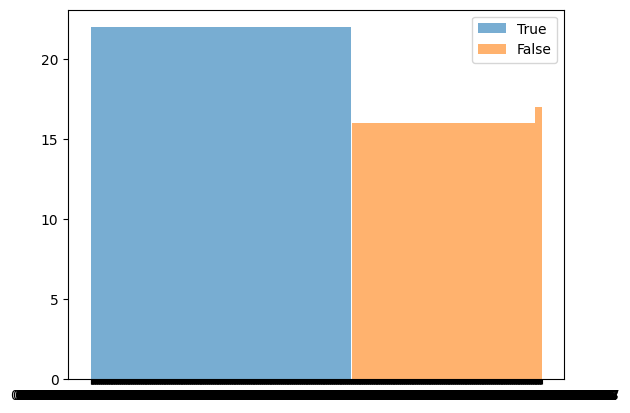

In [4]:
import matplotlib.pyplot as plt

df = df_fact.copy()
df["y"] = df["label"].map({"True":1,"False":0})

plt.hist(df[df.y==1]["p_true_mix"], bins=30, alpha=0.6, label="True")
plt.hist(df[df.y==0]["p_true_mix"], bins=30, alpha=0.6, label="False")
plt.legend()
plt.show()


Score-basierte Ensembles saturieren wegen Label-Ambiguität

Thresholds optimieren nur marginal

Symbolische Verifikation (Judge) ist notwendig

Top-2 Routing erhöht Robustheit, nicht Trennschärfe

## Test auf anderem Dataset

In [2]:
SUPER_LABELS_8 = [
    "economy","health_social","foreign_security","law_rights",
    "politics_government","environment_energy","society_culture","misc",
]
df_test = predict_on_test_with_thresholds(
    test_path="Datasets/politifact_test_dataset_combined.tsv",
    base_model_id="meta-llama/Llama-3.1-8B-Instruct",
    router_lora_dir="./Multi_Agent_Models/llama-liar-statement-domain-lora_8Classes",
    expert_root="./Multi_Agent_Models/experts",
    super_labels=SUPER_LABELS_8,
    thresholds_path="Results/domain_thresholds_val_macro_f1.json",
    out_path="Results/test_predictions_with_val_thresholds_macro_f1_top_2_experts_politifact.csv",
    sep="\t",
    use_judge=False,  # empfehle: aus lassen, bis thresholds stabil sind
)


PREDICT (TEST) + APPLY THRESHOLDS

📦 Thresholds geladen von: Results/domain_thresholds_val_macro_f1.json
Default threshold: 0.5
Domains: ['economy', 'environment_energy', 'foreign_security', 'health_social', 'law_rights', 'politics_government', 'society_culture']

Dataset: Datasets/politifact_test_dataset_combined.tsv
Size (nach Initial-Filtern): 1056
Super-Domain-Verteilung (true):
Series([], Name: count, dtype: int64)

=== Checkability-Gate: Welche Claims sind überhaupt prüfbar? ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
🔎 Checkability: 100%|██████████| 1056/1056 [06:03<00:00,  2.91it/s]



Checkability-Kategorien:
checkability_category
non_claim               507
fact_checkable          465
opinion_or_ambiguous     57
sensitive_selfharm       27
Name: count, dtype: int64

Bewertbare Claims (fact_checkable): 465
Ausgeschlossene Claims (nicht fact_checkable): 591


...

Device set to use cuda:0
🧠 society_culture: 100%|██████████| 14/14 [03:41<00:00, 15.80s/it]



=== Expert fact-check: 'misc' (n=69) ===


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0
🧠 misc: 100%|██████████| 69/69 [12:36<00:00, 10.97s/it]



✅ Verdict Accuracy (fact_checkable): 0.770

Classification report (True/False, fact_checkable):
              precision    recall  f1-score   support

        True       0.81      0.69      0.75       226
       False       0.74      0.84      0.79       239

    accuracy                           0.77       465
   macro avg       0.77      0.77      0.77       465
weighted avg       0.77      0.77      0.77       465

Confusion matrix [rows=true, cols=pred] (True, False):
[[157  69]
 [ 38 201]]

===== Per-Domain Verdict-Accuracy (nach true super_domain, fact_checkable) =====

💾 Predictions gespeichert unter:
Results/test_predictions_with_val_thresholds_macro_f1_top_2_experts_politifact.csv
